# P22: Down syndrome fetal cortex — one-notebook analysis

**Standalone notebook only.** Local Jupyter + Google Colab. No GitHub checkout required.

| | |
|---|---|
| CELLxGENE dataset | `f16c25da-15bd-46a4-9a3f-17093f27a2f1` |
| GEO | `GSE305153` |
| Expected cells | 248,998 (cell-level scale) |
| Expected donors | 30 = 15 normal + 15 complete trisomy 21 (inferential scale) |
| H5AD | ~1.57 GB (not in Git) |

## Visible modes

1. **simulation** — synthetic wiring only (default safe)
2. **metadata_census** — live catalog; no H5AD download
3. **real_analysis** — full public H5AD schema/QC, resources, donor-held-out models, interventions, validation

The implementation needed to run this notebook is embedded in the first code cell and collapsed by default. It is there only so the notebook can run without a repository. H5AD and fragment files are never embedded.

The main result separates full-cohort context from a fair comparison in which chromosome 21 dosage, pseudobulk RNA, and RNA-only models use exactly the same sampled cells. The technical evidence record appears at the end.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import subprocess
import sys
from dataclasses import replace
from datetime import UTC, datetime
from pathlib import Path

os.environ.setdefault("PYTHONDONTWRITEBYTECODE", "1")

EMBEDDED_PROJECT_FILES = {
    'src/p22/__init__.py': r'''
"""P22 research package.

Synthetic-only scaffold. Approval state lives in ``plan/approvals.json`` and is
read at runtime so that configs and run records cannot silently claim a data
mode that has not been approved.
"""

from __future__ import annotations

import json
from pathlib import Path
from typing import Any

__version__ = "0.1.0"

REPO_ROOT = Path(__file__).resolve().parents[2]
APPROVALS_PATH = REPO_ROOT / "plan" / "approvals.json"

SYNTHETIC = "synthetic"
LEGACY_READ_ONLY = "legacy read-only"
APPROVED_REAL_DATA = "approved real data"
DATA_MODES = (SYNTHETIC, LEGACY_READ_ONLY, APPROVED_REAL_DATA)

EVIDENCE_LABELS = (
    "verified",
    "experimental result",
    "proposed",
    "inference",
    "unknown",
)


def load_approvals(path: Path | None = None) -> dict[str, Any]:
    """Return the approval record."""
    target = path or APPROVALS_PATH
    with Path(target).open(encoding="utf-8") as handle:
        return json.load(handle)


def approval_blocked(approvals: dict[str, Any] | None = None) -> bool:
    """Return True while condition-specific work is not approved."""
    record = approvals if approvals is not None else load_approvals()
    return record.get("approval_state") != "approved"


def allowed_data_modes(approvals: dict[str, Any] | None = None) -> tuple[str, ...]:
    record = approvals if approvals is not None else load_approvals()
    return tuple(record.get("allowed_data_modes", (SYNTHETIC,)))


def require_allowed_data_mode(data_mode: str, approvals: dict[str, Any] | None = None) -> str:
    """Validate a data mode against the current approval record.

    Raises:
        ValueError: if the mode is unknown or not currently allowed.
    """
    if data_mode not in DATA_MODES:
        raise ValueError(f"unknown data_mode {data_mode!r}; expected one of {DATA_MODES}")
    permitted = allowed_data_modes(approvals)
    if data_mode not in permitted:
        raise ValueError(
            f"data_mode {data_mode!r} is not permitted while approval is blocked; "
            f"allowed modes: {permitted}"
        )
    return data_mode


__all__ = [
    "APPROVALS_PATH",
    "APPROVED_REAL_DATA",
    "DATA_MODES",
    "EVIDENCE_LABELS",
    "LEGACY_READ_ONLY",
    "REPO_ROOT",
    "SYNTHETIC",
    "__version__",
    "allowed_data_modes",
    "approval_blocked",
    "load_approvals",
    "require_allowed_data_mode",
]
''',
    'src/p22/cli/__init__.py': r'''
"""Command line entry points. Local files only; no downloads."""

__all__: list[str] = []
''',
    'src/p22/cli/preflight.py': r'''
"""Run a metadata preflight on a local table or a local ``.h5ad`` file.

Usage::

    python -m p22.cli.preflight --metadata-csv path.csv --out report.json
    python -m p22.cli.preflight --h5ad tiny.h5ad --out report.json

The command reads local paths only. It never downloads and never trains.
"""

from __future__ import annotations

import argparse
import json
import sys
from pathlib import Path

import pandas as pd

from p22.data.preflight import inspect_h5ad, inspect_metadata, write_preflight_report
from p22.data.schema import ACCESS_FACTS, STATUS_BLOCKED


def build_parser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(description=__doc__)
    source = parser.add_mutually_exclusive_group(required=True)
    source.add_argument("--metadata-csv", type=Path, help="local per-cell metadata table")
    source.add_argument("--h5ad", type=Path, help="local .h5ad file")
    parser.add_argument("--out", type=Path, help="where to write the JSON report")
    parser.add_argument(
        "--access-fact",
        action="append",
        default=[],
        metavar="NAME=VALUE",
        help=f"record one access fact; recognised names: {', '.join(ACCESS_FACTS)}",
    )
    parser.add_argument("--data-mode", default="synthetic")
    parser.add_argument(
        "--fail-on-blocked",
        action="store_true",
        help="exit non-zero when the report status is BLOCKED",
    )
    return parser


def _parse_access_facts(entries: list[str]) -> dict[str, str]:
    facts: dict[str, str] = {}
    for entry in entries:
        if "=" not in entry:
            raise ValueError(f"expected NAME=VALUE, got {entry!r}")
        name, value = entry.split("=", 1)
        facts[name.strip()] = value.strip()
    return facts


def main(argv: list[str] | None = None) -> int:
    args = build_parser().parse_args(argv)
    access_facts = _parse_access_facts(args.access_fact)

    if args.metadata_csv is not None:
        frame = pd.read_csv(args.metadata_csv)
        report = inspect_metadata(
            frame,
            access_facts=access_facts,
            data_mode=args.data_mode,
            source=f"local file {Path(args.metadata_csv).name}",
        )
    else:
        report = inspect_h5ad(args.h5ad, access_facts=access_facts, data_mode=args.data_mode)

    for line in report.summary_lines():
        print(line)

    if args.out is not None:
        written = write_preflight_report(report, args.out)
        print(f"report written: {written}")
    else:
        print(json.dumps(report.to_dict(), indent=2, default=str))

    if args.fail_on_blocked and report.status == STATUS_BLOCKED:
        return 1
    return 0


if __name__ == "__main__":
    sys.exit(main())
''',
    'src/p22/data/__init__.py': r'''
"""Data contracts: donor-aware splitting and train-only transforms."""

from p22.data.splits import (
    DonorSplit,
    donor_split_problems,
    make_donor_split,
    validate_donor_split,
)

__all__ = [
    "DonorSplit",
    "donor_split_problems",
    "make_donor_split",
    "validate_donor_split",
]
''',
    'src/p22/data/adequacy.py': r'''
"""Donor-level adequacy thresholds and off-ramps (G2)."""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Any

import pandas as pd

MIN_DONORS_PER_CONDITION = 15
MIN_PAIRED_CELLS_PER_DONOR = 64
MAX_DONOR_CLASS_RATIO = 1.5
MAX_CELL_CLASS_RATIO = 2.0
MIN_DONOR_GROUPS_FOR_FOLDS = 5
CONDITION_POSITIVE = "complete trisomy 21"
CONDITION_CONTROL = "normal"

OFF_RAMPS = {
    "O1": "scale-pool candidate GSE305153 after disjointness audit",
    "O2": "independent RNA-only validation candidate GSE280175",
    "O3": "reframe as donor-aware cell-state/regulatory description",
}


@dataclass(frozen=True)
class AdequacyThresholds:
    """Numeric thresholds frozen before H5AD matrix inspection."""

    min_donors_per_condition: int = MIN_DONORS_PER_CONDITION
    min_paired_cells_per_donor: int = MIN_PAIRED_CELLS_PER_DONOR
    max_donor_class_ratio: float = MAX_DONOR_CLASS_RATIO
    max_cell_class_ratio: float = MAX_CELL_CLASS_RATIO
    min_donor_groups_for_folds: int = MIN_DONOR_GROUPS_FOR_FOLDS
    positive_label: str = CONDITION_POSITIVE
    control_label: str = CONDITION_CONTROL


@dataclass(frozen=True)
class AdequacyReport:
    """G2 adequacy outcome."""

    status: str
    thresholds: dict[str, Any]
    donor_table: list[dict[str, Any]] = field(default_factory=list)
    checks: dict[str, Any] = field(default_factory=dict)
    blocking_problems: tuple[str, ...] = ()
    open_questions: tuple[str, ...] = ()
    selected_off_ramp: str | None = None
    off_ramp_options: dict[str, str] = field(default_factory=lambda: dict(OFF_RAMPS))

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "thresholds": dict(self.thresholds),
            "donor_table": list(self.donor_table),
            "checks": dict(self.checks),
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
            "selected_off_ramp": self.selected_off_ramp,
            "off_ramp_options": dict(self.off_ramp_options),
        }


def _ratio(a: int, b: int) -> float:
    if a <= 0 or b <= 0:
        return float("inf")
    return max(a, b) / min(a, b)


def audit_label_suffix_agreement(
    donor_ids: list[str],
    conditions: list[str],
) -> list[str]:
    """Return problems when donor suffix and condition labels disagree."""
    problems: list[str] = []
    for donor, condition in zip(donor_ids, conditions, strict=True):
        has_ds = "_DS_" in donor
        has_con = "_CON_" in donor
        if has_ds and has_con:
            problems.append(f"donor {donor} has both _DS_ and _CON_ markers")
        if has_ds and condition != CONDITION_POSITIVE:
            problems.append(f"donor {donor} suffix implies DS but condition is {condition!r}")
        if has_con and condition != CONDITION_CONTROL:
            problems.append(f"donor {donor} suffix implies control but condition is {condition!r}")
    return problems


def evaluate_donor_adequacy(
    donor_frame: pd.DataFrame,
    thresholds: AdequacyThresholds | None = None,
    pairing_known: bool = False,
    selected_off_ramp: str | None = None,
) -> AdequacyReport:
    """Evaluate donor-level adequacy against frozen thresholds.

    Expected columns: ``donor_id``, ``condition``, ``n_cells``. Optional
    ``n_paired_cells``. Catalog-only frames without cell counts are reported as
    ``INCONCLUSIVE`` rather than fabricated PASS.
    """
    thresholds = thresholds or AdequacyThresholds()
    threshold_dict = {
        "min_donors_per_condition": thresholds.min_donors_per_condition,
        "min_paired_cells_per_donor": thresholds.min_paired_cells_per_donor,
        "max_donor_class_ratio": thresholds.max_donor_class_ratio,
        "max_cell_class_ratio": thresholds.max_cell_class_ratio,
        "min_donor_groups_for_folds": thresholds.min_donor_groups_for_folds,
    }
    required = {"donor_id", "condition"}
    missing = sorted(required - set(donor_frame.columns))
    if missing:
        return AdequacyReport(
            status="BLOCKED",
            thresholds=threshold_dict,
            blocking_problems=(f"donor frame missing columns: {missing}",),
        )

    frame = donor_frame.copy()
    frame["donor_id"] = frame["donor_id"].astype(str)
    frame["condition"] = frame["condition"].astype(str)
    if frame["donor_id"].duplicated().any():
        return AdequacyReport(
            status="BLOCKED",
            thresholds=threshold_dict,
            blocking_problems=("donor_id is not unique in adequacy table",),
        )

    purity_problems = []
    for donor, group in frame.groupby("donor_id", sort=True):
        conditions = sorted(set(group["condition"]))
        if len(conditions) != 1:
            purity_problems.append(f"donor {donor} maps to conditions {conditions}")

    suffix_problems = audit_label_suffix_agreement(
        frame["donor_id"].tolist(),
        frame["condition"].tolist(),
    )

    donor_counts = frame["condition"].value_counts().to_dict()
    n_control = int(donor_counts.get(thresholds.control_label, 0))
    n_ds = int(donor_counts.get(thresholds.positive_label, 0))
    donor_ratio = _ratio(n_control, n_ds)

    cell_checks: dict[str, Any] = {"available": "n_cells" in frame.columns}
    cell_ratio = None
    min_cells = None
    if "n_cells" in frame.columns:
        cell_totals = frame.groupby("condition")["n_cells"].sum().to_dict()
        cell_ratio = _ratio(
            int(cell_totals.get(thresholds.control_label, 0)),
            int(cell_totals.get(thresholds.positive_label, 0)),
        )
        paired_col = "n_paired_cells" if "n_paired_cells" in frame.columns else "n_cells"
        min_cells = int(frame[paired_col].min()) if len(frame) else 0
        cell_checks.update(
            {
                "cell_totals": {str(k): int(v) for k, v in cell_totals.items()},
                "cell_class_ratio": cell_ratio,
                "min_cells_per_donor": min_cells,
                "paired_column": paired_col,
            }
        )

    blocking: list[str] = []
    unknowns: list[str] = []
    blocking.extend(purity_problems)
    blocking.extend(suffix_problems)

    if n_control < thresholds.min_donors_per_condition:
        blocking.append(f"control donors {n_control} < {thresholds.min_donors_per_condition}")
    if n_ds < thresholds.min_donors_per_condition:
        blocking.append(f"DS donors {n_ds} < {thresholds.min_donors_per_condition}")
    if donor_ratio > thresholds.max_donor_class_ratio:
        blocking.append(f"donor class ratio {donor_ratio:.3f} > {thresholds.max_donor_class_ratio}")
    if n_control + n_ds < thresholds.min_donor_groups_for_folds:
        blocking.append(
            f"total donors {n_control + n_ds} < {thresholds.min_donor_groups_for_folds}"
        )

    if not cell_checks["available"]:
        unknowns.append("post-QC cell counts unavailable; catalog donor counts only")
    else:
        assert min_cells is not None and cell_ratio is not None
        if min_cells < thresholds.min_paired_cells_per_donor:
            blocking.append(
                f"min cells/donor {min_cells} < {thresholds.min_paired_cells_per_donor}"
            )
        if cell_ratio > thresholds.max_cell_class_ratio:
            blocking.append(
                f"cell class ratio {cell_ratio:.3f} > {thresholds.max_cell_class_ratio}"
            )
        if not pairing_known:
            unknowns.append("same-nucleus pairing not yet confirmed from H5AD")

    if selected_off_ramp is not None and selected_off_ramp not in OFF_RAMPS:
        blocking.append(f"unknown off-ramp {selected_off_ramp!r}")

    checks = {
        "n_control_donors": n_control,
        "n_ds_donors": n_ds,
        "donor_class_ratio": donor_ratio,
        "label_purity_ok": not purity_problems,
        "suffix_agreement_ok": not suffix_problems,
        "cells": cell_checks,
        "pairing_known": pairing_known,
    }
    donor_table = frame.to_dict(orient="records")

    if blocking:
        status = "BLOCKED"
    elif unknowns:
        status = "INCONCLUSIVE"
    else:
        status = "PASS"

    return AdequacyReport(
        status=status,
        thresholds=threshold_dict,
        donor_table=donor_table,
        checks=checks,
        blocking_problems=tuple(blocking),
        open_questions=tuple(unknowns),
        selected_off_ramp=selected_off_ramp if status == "BLOCKED" else None,
    )


def catalog_donor_frame(donor_ids: list[str]) -> pd.DataFrame:
    """Build a catalog-only donor table from CELLxGENE donor ID suffixes."""
    rows = []
    for donor in donor_ids:
        if "_DS_" in donor:
            condition = CONDITION_POSITIVE
        elif "_CON_" in donor:
            condition = CONDITION_CONTROL
        else:
            condition = "unknown"
        rows.append({"donor_id": donor, "condition": condition})
    return pd.DataFrame(rows)
''',
    'src/p22/data/atac_features.py': r'''
"""Fail-closed peak-space diagnostics; no approximate interval projection."""

from __future__ import annotations

import hashlib
import json
import re
from collections.abc import Sequence
from urllib.parse import urlsplit


def audit_peak_spaces(
    peak_sets: dict[str, Sequence[str]],
    *,
    genome_builds: dict[str, str],
    count_units: dict[str, str],
    reference: dict | None = None,
) -> dict:
    """Compare full peak spaces; a common-subset design is a separate frozen choice.

    Overlap is not exact recounting. A missing region is not a biological zero.
    Source: https://stuartlab.org/signac/articles/merging
    """
    if (
        len(peak_sets) < 2
        or set(peak_sets) != set(genome_builds)
        or set(peak_sets) != set(count_units)
    ):
        raise ValueError("at least two peak sets need explicit build and count-unit records")
    canonical = {}
    for name, regions in peak_sets.items():
        parsed = []
        for region in regions:
            match = re.fullmatch(r"([^:\s]+):(\d+)-(\d+)", region)
            if match is None:
                raise ValueError(f"invalid peak interval: {region}")
            chromosome, start, end = match.groups()
            if int(end) <= int(start):
                raise ValueError(f"invalid peak interval: {region}")
            parsed.append((chromosome, int(start), int(end)))
        if not parsed or len(set(parsed)) != len(parsed):
            raise ValueError("empty peak space or duplicate intervals")
        canonical[name] = parsed
    sets = [set(values) for values in canonical.values()]
    union, common = set.union(*sets), set.intersection(*sets)
    identical = all(values == sets[0] for values in sets)
    builds = [
        value.strip().lower() if isinstance(value, str) else "" for value in genome_builds.values()
    ]
    known_build = all(re.fullmatch(r"grch3[78](?:\.p\d+)?|hg19|hg38", value) for value in builds)
    same_build = known_build and len(set(builds)) == 1
    same_units = len(set(count_units.values())) == 1 and set(count_units.values()) <= {
        "fragments",
        "tn5_insertions",
    }
    reference = reference or {}
    reference_url = urlsplit(str(reference.get("source", "")))
    documented_reference = (
        reference.get("kind") in ("fixed_reference", "training_fold")
        and reference_url.scheme == "https"
        and bool(reference_url.hostname)
    )
    reasons = []
    if not identical:
        reasons.append("full peak union has unmeasured regions; never zero-fill")
    if not same_build:
        reasons.append("genome build is unknown or differs")
    if not same_units:
        reasons.append("count semantics are unknown or differ")
    if not documented_reference:
        reasons.append("fixed-reference/training-fold feature provenance is not established")
    # No values are projected. Even PASS is only feature compatibility, not approval to train.
    status = "PASS" if not reasons else ("NEEDS_RECOUNT" if not identical else "INCONCLUSIVE")
    first = next(iter(canonical.values()))
    return {
        "status": status,
        "scope": "full_peak_union",
        "reasons": reasons,
        "n_regions": {key: len(values) for key, values in canonical.items()},
        "n_exact_common_regions": len(common),
        "unmeasured_regions": {key: len(union - set(values)) for key, values in canonical.items()},
        "row_order_identical": all(values == first for values in canonical.values()),
        "common_regions_sha256": hashlib.sha256(json.dumps(sorted(common)).encode()).hexdigest(),
        "zero_fill_allowed": False,
        "exact_projection_possible": identical and same_build and same_units,
        "alternative": "Assess a frozen, measured common subset before budgeting recount",
        "genome_builds": genome_builds,
        "count_units": count_units,
        "reference": reference,
        "training_approval": "NOT_ASSESSED",
    }
''',
    'src/p22/data/catalog.py': r'''
"""Live CELLxGENE catalog metadata preflight (G1).

Fetches public catalog JSON only. Does not download H5AD or fragment matrices.
"""

from __future__ import annotations

import json
import urllib.error
import urllib.request
from dataclasses import dataclass, field
from datetime import UTC, datetime
from typing import Any

DEFAULT_COLLECTION_ID = "0e9fd1d3-ef4c-47c6-a2e4-ef4bfadf7c79"
DEFAULT_DATASET_ID = "f16c25da-15bd-46a4-9a3f-17093f27a2f1"
DEFAULT_API_BASE = "https://api.cellxgene.cziscience.com/dp/v1"
EXPECTED_CELLS = 248_998
EXPECTED_DONORS = 30
EXPECTED_CONDITIONS = frozenset({"complete trisomy 21", "normal"})
EXPECTED_ASSAY = "10x multiome"
EXPECTED_DONORS_PER_CONDITION = 15
EXPECTED_H5AD_BYTES = 1_569_658_860


@dataclass(frozen=True)
class CatalogContract:
    """Frozen catalog identity expectations."""

    collection_id: str = DEFAULT_COLLECTION_ID
    dataset_id: str = DEFAULT_DATASET_ID
    expected_cells: int = EXPECTED_CELLS
    expected_donors: int = EXPECTED_DONORS
    expected_assay: str = EXPECTED_ASSAY
    expected_conditions: frozenset[str] = EXPECTED_CONDITIONS
    expected_donors_per_condition: int = EXPECTED_DONORS_PER_CONDITION
    expected_h5ad_bytes: int = EXPECTED_H5AD_BYTES
    api_base: str = DEFAULT_API_BASE


@dataclass(frozen=True)
class CatalogPreflight:
    """Live catalog comparison against the frozen contract."""

    status: str
    retrieved_at: str
    catalog_url: str
    summary: dict[str, Any] = field(default_factory=dict)
    blocking_problems: tuple[str, ...] = ()
    open_questions: tuple[str, ...] = ()
    evidence_labels: tuple[str, ...] = ("verified",)

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "retrieved_at": self.retrieved_at,
            "catalog_url": self.catalog_url,
            "summary": dict(self.summary),
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
            "evidence_labels": list(self.evidence_labels),
        }


def fetch_json(url: str, timeout: float = 60.0) -> dict[str, Any]:
    """Fetch a JSON object from a public URL."""
    request = urllib.request.Request(url, headers={"Accept": "application/json"})
    with urllib.request.urlopen(request, timeout=timeout) as response:
        payload = json.loads(response.read().decode("utf-8"))
    if not isinstance(payload, dict):
        raise ValueError(f"expected JSON object from {url}")
    return payload


def remote_content_length(url: str, timeout: float = 30.0) -> int | None:
    """Return the byte size a HEAD request reports, or ``None`` when unavailable.

    Used to price the ATAC fragment asset before deciding B2a versus B2b. The
    catalog omits ``file_size`` for that asset, so the number has to be measured.
    """
    request = urllib.request.Request(url, method="HEAD")
    try:
        with urllib.request.urlopen(request, timeout=timeout) as response:
            length = response.headers.get("Content-Length")
    except (urllib.error.URLError, TimeoutError, ValueError):
        return None
    try:
        return int(length) if length is not None else None
    except (TypeError, ValueError):
        return None


def _labels(items: list[dict[str, Any]] | None) -> list[str]:
    if not items:
        return []
    return [str(item.get("label", item)) for item in items]


def _condition_counts_from_donor_ids(donor_ids: list[str]) -> dict[str, int]:
    return {
        "normal": sum("_CON_" in donor for donor in donor_ids),
        "complete trisomy 21": sum("_DS_" in donor for donor in donor_ids),
    }


def build_catalog_summary(
    collection: dict[str, Any],
    dataset: dict[str, Any],
    contract: CatalogContract,
) -> dict[str, Any]:
    """Normalize live catalog fields into a stable summary dict."""
    assets = list(dataset.get("dataset_assets") or [])
    h5ad_asset = next((item for item in assets if item.get("filetype") == "H5AD"), None)
    fragment_asset = next(
        (item for item in assets if item.get("filetype") == "ATAC_FRAGMENT"),
        None,
    )
    donor_ids = [str(value) for value in dataset.get("donor_id") or []]
    return {
        "collection_id": collection.get("id") or contract.collection_id,
        "collection_name": collection.get("name"),
        "dataset_id": dataset.get("id"),
        "dataset_name": dataset.get("name"),
        "assay": _labels(dataset.get("assay")),
        "cell_count": dataset.get("cell_count"),
        "donor_count": len(donor_ids),
        "donor_ids": donor_ids,
        "conditions": _labels(dataset.get("disease")),
        "condition_counts_from_donor_suffix": _condition_counts_from_donor_ids(donor_ids),
        "stage_count": len(dataset.get("development_stage") or []),
        "stages": _labels(dataset.get("development_stage")),
        "h5ad_asset": {
            "present": h5ad_asset is not None,
            "filetype": None if h5ad_asset is None else h5ad_asset.get("filetype"),
            "file_size": None if h5ad_asset is None else h5ad_asset.get("file_size"),
            "s3_uri": None if h5ad_asset is None else h5ad_asset.get("s3_uri"),
            "url": f"https://datasets.cellxgene.cziscience.com/{contract.dataset_id}.h5ad",
        },
        "atac_fragment_asset": {
            "present": fragment_asset is not None,
            "filetype": None if fragment_asset is None else fragment_asset.get("filetype"),
            "file_size": None if fragment_asset is None else fragment_asset.get("file_size"),
            "filename": None if fragment_asset is None else fragment_asset.get("filename"),
            "url": (
                None
                if fragment_asset is None or not fragment_asset.get("filename")
                else f"https://datasets.cellxgene.cziscience.com/{fragment_asset['filename']}"
            ),
        },
        "same_nucleus_evidence": "unknown_until_h5ad_inspection",
        "metadata_missingness": "catalog_only",
    }


def evaluate_catalog_contract(
    summary: dict[str, Any],
    contract: CatalogContract | None = None,
) -> tuple[str, list[str], list[str]]:
    """Compare a catalog summary to the frozen contract."""
    contract = contract or CatalogContract()
    blocking: list[str] = []
    unknowns: list[str] = []

    if summary.get("dataset_id") != contract.dataset_id:
        blocking.append(
            f"dataset_id mismatch: live={summary.get('dataset_id')!r} "
            f"expected={contract.dataset_id!r}"
        )
    if summary.get("cell_count") != contract.expected_cells:
        blocking.append(
            f"cell_count mismatch: live={summary.get('cell_count')} "
            f"expected={contract.expected_cells}"
        )
    if summary.get("donor_count") != contract.expected_donors:
        blocking.append(
            f"donor_count mismatch: live={summary.get('donor_count')} "
            f"expected={contract.expected_donors}"
        )
    assays = set(summary.get("assay") or [])
    if contract.expected_assay not in assays:
        blocking.append(f"assay mismatch: live={sorted(assays)} expected={contract.expected_assay}")
    conditions = set(summary.get("conditions") or [])
    if conditions != set(contract.expected_conditions):
        blocking.append(
            f"condition mismatch: live={sorted(conditions)} "
            f"expected={sorted(contract.expected_conditions)}"
        )
    condition_counts = summary.get("condition_counts_from_donor_suffix") or {}
    for label in contract.expected_conditions:
        observed = int(condition_counts.get(label, -1))
        if observed != contract.expected_donors_per_condition:
            blocking.append(
                f"donor count for {label!r} is {observed}, "
                f"expected {contract.expected_donors_per_condition}"
            )
    if not (summary.get("h5ad_asset") or {}).get("present"):
        blocking.append("H5AD asset missing from catalog")
    if not (summary.get("atac_fragment_asset") or {}).get("present"):
        unknowns.append("ATAC fragment asset absent from catalog")
    if summary.get("same_nucleus_evidence") == "unknown_until_h5ad_inspection":
        unknowns.append("same-nucleus pairing requires H5AD inspection")

    if blocking:
        status = "BLOCKED"
    elif unknowns:
        status = "INCONCLUSIVE"
    else:
        status = "PASS"
    return status, blocking, unknowns


def run_catalog_preflight(
    contract: CatalogContract | None = None,
    fetcher: Any | None = None,
) -> CatalogPreflight:
    """Fetch live catalog metadata and evaluate the frozen identity contract."""
    contract = contract or CatalogContract()
    catalog_url = f"{contract.api_base}/collections/{contract.collection_id}"
    retrieved_at = datetime.now(UTC).isoformat(timespec="seconds")
    get_json = fetcher or fetch_json
    try:
        collection = get_json(catalog_url)
        dataset = next(item for item in collection["datasets"] if item["id"] == contract.dataset_id)
    except (
        StopIteration,
        KeyError,
        TypeError,
        urllib.error.URLError,
        TimeoutError,
        ValueError,
    ) as error:
        return CatalogPreflight(
            status="BLOCKED",
            retrieved_at=retrieved_at,
            catalog_url=catalog_url,
            summary={},
            blocking_problems=(f"catalog fetch failed: {error}",),
            open_questions=(),
            evidence_labels=("unknown",),
        )

    summary = build_catalog_summary(collection, dataset, contract)
    status, blocking, unknowns = evaluate_catalog_contract(summary, contract)
    return CatalogPreflight(
        status=status,
        retrieved_at=retrieved_at,
        catalog_url=catalog_url,
        summary=summary,
        blocking_problems=tuple(blocking),
        open_questions=tuple(unknowns),
        evidence_labels=("verified",) if status != "BLOCKED" else ("unknown",),
    )
''',
    'src/p22/data/census.py': r'''
"""Full-cohort acquisition, checksum, and backed census helpers.

Public H5AD download and matrix inspection stay behind an explicitly selected
real-analysis mode. Safe mode only builds planned contracts and blocked reports.
"""

from __future__ import annotations

import hashlib
import time
import urllib.request
from dataclasses import dataclass, field
from datetime import UTC, datetime
from pathlib import Path
from typing import Any

import pandas as pd

from p22.data.catalog import EXPECTED_CELLS, EXPECTED_DONORS, EXPECTED_H5AD_BYTES

DEFAULT_H5AD_URL = (
    "https://datasets.cellxgene.cziscience.com/f16c25da-15bd-46a4-9a3f-17093f27a2f1.h5ad"
)

DONOR_CANDIDATES = ("donor_id", "donor", "sample_id", "sample")
CONDITION_CANDIDATES = ("disease", "condition", "group")
STAGE_CANDIDATES = ("development_stage", "stage", "gestational_week")
SEX_CANDIDATES = ("sex",)
BATCH_CANDIDATES = ("batch", "library_id", "sample_id")
QC_CANDIDATES = ("n_genes_by_counts", "n_genes", "pct_counts_mt", "percent_mito", "total_counts")


@dataclass(frozen=True)
class AcquisitionRecord:
    """R1 immutable acquisition facts."""

    status: str
    dataset_id: str
    collection_id: str
    geo_accession: str
    catalog_cells: int | None
    catalog_donors: int | None
    h5ad_url: str
    expected_bytes: int
    observed_bytes: int | None = None
    sha256: str | None = None
    downloaded_at: str | None = None
    path: str | None = None
    fragment_asset_present: bool | None = None
    blocking_problems: tuple[str, ...] = ()
    open_questions: tuple[str, ...] = ()

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "dataset_id": self.dataset_id,
            "collection_id": self.collection_id,
            "geo_accession": self.geo_accession,
            "catalog_cells": self.catalog_cells,
            "catalog_donors": self.catalog_donors,
            "h5ad_url": self.h5ad_url,
            "expected_bytes": self.expected_bytes,
            "observed_bytes": self.observed_bytes,
            "sha256": self.sha256,
            "downloaded_at": self.downloaded_at,
            "path": self.path,
            "fragment_asset_present": self.fragment_asset_present,
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
        }


@dataclass(frozen=True)
class CensusReport:
    """R2/R3 full-cohort census before model caps."""

    status: str
    n_cells_raw: int | None = None
    n_donors: int | None = None
    condition_counts: dict[str, int] = field(default_factory=dict)
    donor_table: list[dict[str, Any]] = field(default_factory=list)
    cells_per_donor: dict[str, Any] = field(default_factory=dict)
    pairing: dict[str, Any] = field(default_factory=dict)
    fields: dict[str, Any] = field(default_factory=dict)
    exclusions: list[dict[str, Any]] = field(default_factory=list)
    peak_block_present: bool | None = None
    chr21_annotation_available: bool | None = None
    storage: dict[str, Any] = field(default_factory=dict)
    blocking_problems: tuple[str, ...] = ()
    open_questions: tuple[str, ...] = ()

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "n_cells_raw": self.n_cells_raw,
            "n_donors": self.n_donors,
            "condition_counts": dict(self.condition_counts),
            "donor_table": list(self.donor_table),
            "cells_per_donor": dict(self.cells_per_donor),
            "pairing": dict(self.pairing),
            "fields": dict(self.fields),
            "exclusions": list(self.exclusions),
            "peak_block_present": self.peak_block_present,
            "chr21_annotation_available": self.chr21_annotation_available,
            "storage": dict(self.storage),
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
            "layer": "full_cohort",
            "not_a_model_cap": True,
        }


def sha256_file(path: Path, chunk_size: int = 8 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def estimate_download_gb(expected_bytes: int = EXPECTED_H5AD_BYTES) -> float:
    return round(expected_bytes / 1e9, 3)


def planned_acquisition_from_catalog(
    catalog_summary: dict[str, Any],
    *,
    collection_id: str,
    dataset_id: str,
    geo_accession: str = "GSE305153",
    allow_download: bool = False,
) -> AcquisitionRecord:
    """Build R1 record from catalog metadata without downloading."""
    h5ad = catalog_summary.get("h5ad_asset") or {}
    fragment = catalog_summary.get("atac_fragment_asset") or {}
    unknowns = [
        "H5AD not downloaded; checksum pending",
        "byte verification pending local file",
    ]
    blocking: list[str] = []
    if not allow_download:
        blocking.append("download blocked until real_analysis mode with P22_RUN_REAL_DATA=1")
    status = "BLOCKED" if blocking else "INCONCLUSIVE"
    return AcquisitionRecord(
        status=status,
        dataset_id=dataset_id,
        collection_id=collection_id,
        geo_accession=geo_accession,
        catalog_cells=catalog_summary.get("cell_count"),
        catalog_donors=catalog_summary.get("donor_count"),
        h5ad_url=h5ad.get("url") or DEFAULT_H5AD_URL,
        expected_bytes=int(h5ad.get("file_size") or EXPECTED_H5AD_BYTES),
        fragment_asset_present=bool(fragment.get("present")),
        blocking_problems=tuple(blocking),
        open_questions=tuple(unknowns),
    )


def download_h5ad(
    destination: Path,
    url: str = DEFAULT_H5AD_URL,
    expected_bytes: int = EXPECTED_H5AD_BYTES,
    *,
    allow: bool = False,
) -> Path:
    """Download full public H5AD only when user-selected preflight allows it."""
    if not allow:
        raise PermissionError(
            "H5AD download refused: select real_analysis mode and set P22_RUN_REAL_DATA=1"
        )
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.is_file() and destination.stat().st_size == expected_bytes:
        return destination
    temporary = destination.with_suffix(destination.suffix + ".partial")
    with urllib.request.urlopen(url, timeout=120) as response, temporary.open("wb") as handle:
        while True:
            chunk = response.read(8 * 1024 * 1024)
            if not chunk:
                break
            handle.write(chunk)
    if temporary.stat().st_size != expected_bytes:
        size = temporary.stat().st_size
        temporary.unlink(missing_ok=True)
        raise RuntimeError(f"Downloaded H5AD size {size} != expected {expected_bytes}")
    temporary.replace(destination)
    return destination


def verify_local_h5ad(
    path: Path,
    expected_bytes: int = EXPECTED_H5AD_BYTES,
) -> dict[str, Any]:
    """Verify local file size and compute SHA256."""
    target = Path(path)
    if not target.is_file():
        return {"ok": False, "reason": f"missing file {target}"}
    size = target.stat().st_size
    digest = sha256_file(target)
    ok = size == expected_bytes
    return {
        "ok": ok,
        "path": str(target),
        "observed_bytes": size,
        "expected_bytes": expected_bytes,
        "sha256": digest,
        "reason": None if ok else f"size mismatch {size} != {expected_bytes}",
    }


def _resolve_column(columns: list[str], candidates: tuple[str, ...]) -> str | None:
    lower = {name.lower(): name for name in columns}
    for candidate in candidates:
        if candidate.lower() in lower:
            return lower[candidate.lower()]
    return None


def census_blocked_placeholder(reason: str) -> CensusReport:
    return CensusReport(
        status="BLOCKED",
        blocking_problems=(reason,),
        open_questions=("full-cohort census requires local approved H5AD",),
    )


def run_backed_census(path: Path) -> CensusReport:
    """Open H5AD backed and census every row before any model cap."""
    import anndata as ad

    target = Path(path)
    if not target.is_file():
        return census_blocked_placeholder(f"no H5AD at {target}")

    started = time.perf_counter()
    backed = ad.read_h5ad(target, backed="r")
    obs = backed.obs
    columns = list(obs.columns)
    donor_col = _resolve_column(columns, DONOR_CANDIDATES)
    condition_col = _resolve_column(columns, CONDITION_CANDIDATES)
    stage_col = _resolve_column(columns, STAGE_CANDIDATES)
    sex_col = _resolve_column(columns, SEX_CANDIDATES)
    batch_col = _resolve_column(columns, BATCH_CANDIDATES)
    qc_present = {
        name: _resolve_column(columns, (name,)) is not None or name in columns
        for name in QC_CANDIDATES
    }

    blocking: list[str] = []
    unknowns: list[str] = []
    if donor_col is None:
        blocking.append("donor column absent")
    if condition_col is None:
        blocking.append("condition/disease column absent")

    n_cells = int(backed.n_obs)
    donor_table: list[dict[str, Any]] = []
    condition_counts: dict[str, int] = {}
    cells_per_donor: dict[str, Any] = {}
    if donor_col and condition_col:
        frame = pd.DataFrame(
            {
                "donor_id": obs[donor_col].astype(str).to_numpy(),
                "condition": obs[condition_col].astype(str).to_numpy(),
            }
        )
        purity = frame.groupby("donor_id")["condition"].nunique()
        impure = purity[purity > 1]
        if len(impure):
            blocking.append(f"{len(impure)} donors have mixed condition labels")
        grouped = frame.groupby(["donor_id", "condition"]).size().reset_index(name="n_cells")
        donor_table = grouped.to_dict(orient="records")
        condition_counts = frame["condition"].value_counts().astype(int).to_dict()
        per_donor = frame.groupby("donor_id").size()
        cells_per_donor = {
            "min": int(per_donor.min()),
            "median": float(per_donor.median()),
            "max": int(per_donor.max()),
            "n_donors": int(per_donor.size),
        }

    feature_column = next(
        (name for name in ("feature_types", "assay", "feature_type") if name in backed.var.columns),
        None,
    )
    if feature_column is not None:
        types = backed.var[feature_column].astype(str).str.lower()
        peak_block = bool(types.str.contains("peak|atac").any())
    elif any(key.lower().startswith("atac") for key in getattr(backed, "obsm", {})):
        peak_block = True
    else:
        peak_block = False
    if not peak_block:
        unknowns.append("ATAC peak block not found in var feature annotation or obsm")

    chr21_available = None
    for column in ("seqnames", "chromosome", "chrom", "seqname", "gene_chrom"):
        if column in backed.var.columns:
            values = backed.var[column].astype(str)
            chr21_available = bool(values.isin(["21", "chr21", "Chr21"]).any())
            break
    if chr21_available is None:
        unknowns.append("chr21 gene annotation column not found")

    pairing = {
        "status": (
            "unknown"
            if peak_block is None
            else ("paired_candidate" if peak_block else "no_peak_block")
        ),
        "same_nucleus_evidence": "same obs rows for RNA/ATAC candidate" if peak_block else "absent",
        "elapsed_seconds": round(time.perf_counter() - started, 3),
    }

    status = "BLOCKED" if blocking else ("INCONCLUSIVE" if unknowns else "PASS")
    if n_cells != EXPECTED_CELLS and not blocking:
        unknowns.append(f"live cell count {n_cells} != expected {EXPECTED_CELLS}")
        status = "INCONCLUSIVE"

    return CensusReport(
        status=status,
        n_cells_raw=n_cells,
        n_donors=cells_per_donor.get("n_donors"),
        condition_counts={str(k): int(v) for k, v in condition_counts.items()},
        donor_table=donor_table,
        cells_per_donor=cells_per_donor,
        pairing=pairing,
        fields={
            "donor": donor_col,
            "condition": condition_col,
            "stage": stage_col,
            "sex": sex_col,
            "batch": batch_col,
            "qc_fields": qc_present,
        },
        exclusions=[],
        peak_block_present=peak_block,
        chr21_annotation_available=chr21_available,
        storage={
            "backed": True,
            "n_vars": int(backed.n_vars),
            "X_type": type(backed.X).__name__,
        },
        blocking_problems=tuple(blocking),
        open_questions=tuple(unknowns),
    )


def data_scale_section(
    acquisition: AcquisitionRecord,
    census: CensusReport,
    *,
    primary_cap: int = 256,
    sensitivity_caps: tuple[int, ...] = (64, 128),
    second_cohort_status: str = "GSE280175 RNA-only planned; multimodal UNKNOWN",
) -> dict[str, Any]:
    """R6 numeric data-scale package section."""
    return {
        "cell_level_scale": {
            "catalog_cells_expected": EXPECTED_CELLS,
            "catalog_cells_observed": acquisition.catalog_cells,
            "raw_cells": census.n_cells_raw,
            "note": "cells are not independent inferential units",
        },
        "inferential_scale": {
            "donors_expected": EXPECTED_DONORS,
            "donors_observed": census.n_donors or acquisition.catalog_donors,
            "unit": "donor",
        },
        "caps": {
            "primary": primary_cap,
            "sensitivity": list(sensitivity_caps),
            "optional_when_resources_permit": [512, "all_retained"],
            "capped_output_is_not_full_dataset": True,
        },
        "layers": {
            "full_cohort": "QC census, donor summaries, pseudobulk over all retained cells",
            "cell_level_model": "primary 256 cells/donor with 64/128 sensitivity",
        },
        "pairing": census.pairing,
        "exclusions": census.exclusions,
        "second_cohort_status": second_cohort_status,
        "acquisition": acquisition.to_dict(),
        "census": census.to_dict(),
        "generated_at": datetime.now(UTC).isoformat(timespec="seconds"),
    }
''',
    'src/p22/data/group_splits.py': r'''
"""Repeated donor-held-out StratifiedGroupKFold evaluation (G5)."""

from __future__ import annotations

from collections.abc import Iterator, Sequence
from dataclasses import dataclass, field
from typing import Any

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

from p22.data.splits import _as_donor_array


@dataclass(frozen=True)
class GroupFold:
    """One train/test donor partition."""

    repeat: int
    fold: int
    split_seed: int
    train_donors: tuple[str, ...]
    test_donors: tuple[str, ...]
    train_index: np.ndarray
    test_index: np.ndarray

    def to_dict(self) -> dict[str, Any]:
        return {
            "repeat": self.repeat,
            "fold": self.fold,
            "split_seed": self.split_seed,
            "train_donors": list(self.train_donors),
            "test_donors": list(self.test_donors),
            "n_train_cells": int(self.train_index.size),
            "n_test_cells": int(self.test_index.size),
        }


@dataclass(frozen=True)
class RepeatedGroupSplitReport:
    """Leakage-control evidence for repeated group folds."""

    status: str
    n_repeats: int
    n_folds: int
    folds: list[GroupFold] = field(default_factory=list)
    donor_overlap_count: int = 0
    blocking_problems: tuple[str, ...] = ()
    open_questions: tuple[str, ...] = ()

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "n_repeats": self.n_repeats,
            "n_folds": self.n_folds,
            "n_folds_total": len(self.folds),
            "donor_overlap_count": self.donor_overlap_count,
            "folds": [fold.to_dict() for fold in self.folds],
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
        }


def _donor_labels_for_stratification(
    donor_ids: np.ndarray,
    labels: np.ndarray,
    *,
    allow_majority: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """Return unique donors and one label per donor.

    Raises:
        ValueError: if a donor has mixed labels and ``allow_majority`` is False.
    """
    frame = pd.DataFrame({"donor": donor_ids.astype(str), "label": labels})
    purity = frame.groupby("donor")["label"].nunique()
    impure = purity[purity > 1]
    if len(impure) and not allow_majority:
        raise ValueError(f"donors with mixed labels: {sorted(impure.index)[:5]}")
    donor_label = (
        frame.groupby("donor")["label"]
        .agg(lambda values: int(values.mode().iloc[0]))
        .reset_index()
        .sort_values("donor")
    )
    return donor_label["donor"].to_numpy(dtype=object), donor_label["label"].to_numpy()


def iter_repeated_stratified_group_folds(
    donor_ids: Sequence[Any] | np.ndarray,
    labels: Sequence[Any] | np.ndarray,
    n_repeats: int = 5,
    n_folds: int = 5,
    base_seed: int = 0,
) -> Iterator[GroupFold]:
    """Yield donor-held-out folds; split seed controls donor assignment."""
    donors_per_cell = _as_donor_array(donor_ids)
    label_array = np.asarray(labels)
    if label_array.shape[0] != donors_per_cell.shape[0]:
        raise ValueError("labels length must match donor_ids")
    unique_donors, donor_y = _donor_labels_for_stratification(donors_per_cell, label_array)
    as_str = np.asarray([str(value) for value in donors_per_cell], dtype=object)

    for repeat in range(n_repeats):
        split_seed = int(base_seed + repeat)
        splitter = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=split_seed)
        # StratifiedGroupKFold expects groups aligned to X rows; use one row per donor.
        dummy_x = np.zeros((unique_donors.size, 1))
        groups = unique_donors
        for fold_index, (train_donor_idx, test_donor_idx) in enumerate(
            splitter.split(dummy_x, donor_y, groups=groups)
        ):
            train_donors = tuple(sorted(str(value) for value in unique_donors[train_donor_idx]))
            test_donors = tuple(sorted(str(value) for value in unique_donors[test_donor_idx]))
            train_index = np.flatnonzero(np.isin(as_str, np.array(train_donors, dtype=object)))
            test_index = np.flatnonzero(np.isin(as_str, np.array(test_donors, dtype=object)))
            yield GroupFold(
                repeat=repeat,
                fold=fold_index,
                split_seed=split_seed,
                train_donors=train_donors,
                test_donors=test_donors,
                train_index=train_index,
                test_index=test_index,
            )


def validate_group_folds(folds: Sequence[GroupFold]) -> list[str]:
    """Return leakage problems across generated folds."""
    problems: list[str] = []
    for fold in folds:
        overlap = sorted(set(fold.train_donors) & set(fold.test_donors))
        if overlap:
            problems.append(f"repeat {fold.repeat} fold {fold.fold} donor overlap: {overlap[:5]}")
        if fold.train_index.size == 0 or fold.test_index.size == 0:
            problems.append(f"repeat {fold.repeat} fold {fold.fold} has an empty split")
        shared_cells = np.intersect1d(fold.train_index, fold.test_index)
        if shared_cells.size:
            problems.append(
                f"repeat {fold.repeat} fold {fold.fold} shares {shared_cells.size} cells"
            )
    return problems


def build_repeated_group_split_report(
    donor_ids: Sequence[Any] | np.ndarray,
    labels: Sequence[Any] | np.ndarray,
    n_repeats: int = 5,
    n_folds: int = 5,
    base_seed: int = 0,
) -> RepeatedGroupSplitReport:
    """Materialize and validate the G5 split plan."""
    folds = list(
        iter_repeated_stratified_group_folds(
            donor_ids,
            labels,
            n_repeats=n_repeats,
            n_folds=n_folds,
            base_seed=base_seed,
        )
    )
    problems = validate_group_folds(folds)
    overlap_count = sum(1 for fold in folds if set(fold.train_donors) & set(fold.test_donors))
    status = "BLOCKED" if problems else "PASS"
    return RepeatedGroupSplitReport(
        status=status,
        n_repeats=n_repeats,
        n_folds=n_folds,
        folds=folds,
        donor_overlap_count=overlap_count,
        blocking_problems=tuple(problems),
    )


def aggregate_donor_probabilities(
    probabilities: np.ndarray,
    donor_ids: Sequence[Any] | np.ndarray,
    threshold: float = 0.5,
) -> pd.DataFrame:
    """Mean probability per donor, then threshold at 0.5."""
    probs = np.asarray(probabilities, dtype=np.float64)
    donors = np.asarray([str(value) for value in np.asarray(donor_ids)], dtype=object)
    if probs.ndim != 1:
        raise ValueError("probabilities must be one-dimensional positive-class scores")
    if probs.size != donors.size:
        raise ValueError("probabilities and donor_ids length mismatch")
    frame = pd.DataFrame({"donor_id": donors, "probability": probs})
    grouped = frame.groupby("donor_id", sort=True)["probability"].mean().reset_index()
    grouped["prediction"] = (grouped["probability"] >= threshold).astype(int)
    return grouped
''',
    'src/p22/data/multiome.py': r'''
"""Public paired-file diagnostics. No training, QC invention, or approval changes."""

from __future__ import annotations

import gzip
import io
import json
import re
import tarfile
from dataclasses import dataclass, field
from pathlib import Path, PurePosixPath
from urllib.parse import urlsplit

import numpy as np
import pandas as pd
from scipy import io as scipy_io
from scipy import sparse

from p22.data.census import sha256_file
from p22.data.real_cohort import sample_nested_capped_cells


@dataclass
class ReadBudget:
    """Cumulative file/decompression limits, not an estimate of total process memory."""

    max_input_bytes: int = 64 * 1024**2
    max_expanded_bytes: int = 256 * 1024**2
    input_bytes: int = field(default=0, init=False)
    expanded_bytes: int = field(default=0, init=False)
    records: list[dict] = field(default_factory=list, init=False)

    def __post_init__(self):
        _positive_integer(self.max_input_bytes, "input byte budget")
        _positive_integer(self.max_expanded_bytes, "expanded byte budget")


def _positive_integer(value: int, name: str) -> None:
    if not isinstance(value, int) or isinstance(value, bool) or value < 1:
        raise ValueError(f"{name} must be a positive integer")


def _decode_bounded(raw: bytes, budget: ReadBudget) -> bytes:
    """Charge every materialized layer, including tar headers, before parsing it."""
    remaining = budget.max_expanded_bytes - budget.expanded_bytes
    if raw.startswith(b"\x1f\x8b"):
        with gzip.GzipFile(fileobj=io.BytesIO(raw)) as stream:
            raw = stream.read(remaining + 1)
    if len(raw) > remaining:
        raise ValueError("expanded byte budget exceeded")
    budget.expanded_bytes += len(raw)
    return raw


def verified_asset_path(spec: dict, budget: ReadBudget) -> Path:
    """Check provenance/hash and charge streamed file bytes without buffering them."""
    path = Path(spec["path"])
    source = urlsplit(spec.get("source_url", ""))
    if source.scheme != "https" or not source.netloc:
        raise ValueError("asset needs an HTTPS provenance source_url (never fetched here)")
    expected = spec.get("sha256", "")
    if not re.fullmatch(r"[a-f0-9]{64}", expected):
        raise ValueError("asset needs a pinned SHA-256 checksum")
    if path.is_symlink() or not path.is_file():
        raise ValueError("asset path must be a regular local file")
    size = path.stat().st_size
    if budget.input_bytes + size > budget.max_input_bytes:
        raise ValueError("input byte budget exceeded")
    if sha256_file(path) != expected:
        raise ValueError("asset checksum mismatch")
    budget.input_bytes += size
    budget.records.append(
        {
            "path": str(path.resolve()),
            "member": spec.get("member"),
            "source_url": spec["source_url"],
            "sha256": expected,
            "input_bytes": size,
            "expanded_bytes": 0,
        }
    )
    return path


def read_asset(spec: dict, budget: ReadBudget) -> bytes:
    """Read bounded pinned files or tar members without extraction or network access.

    https://docs.python.org/3.11/library/tarfile.html#tarfile.TarFile.extractfile
    """
    path = verified_asset_path(spec, budget)
    size = budget.records[-1]["input_bytes"]
    expanded_before = budget.expanded_bytes
    with path.open("rb") as stream:
        raw = _decode_bounded(stream.read(size + 1), budget)
    if "member" in spec:
        # Bound the ENTIRE outer tar before tarfile consumes PAX/GNU extension headers.
        # ponytail: bounded buffer, no extraction. Large archives need a streaming loader.
        with tarfile.open(fileobj=io.BytesIO(raw), mode="r:") as archive:
            names, total, target = set(), 0, None
            for member in archive:
                name = PurePosixPath(member.name)
                if name.is_absolute() or ".." in name.parts or "\\" in member.name:
                    raise ValueError("unsafe archive path")
                if str(name) in names:
                    raise ValueError("duplicate archive path")
                names.add(str(name))
                if not (member.isfile() or member.isdir()) or member.issparse():
                    raise ValueError("unsafe archive member type")
                total += member.size
                if total > len(raw) or len(names) > 10_000:
                    raise ValueError("archive expanded byte/member budget exceeded")
                if member.name == spec["member"] and member.isfile():
                    target = member
            if target is None:
                raise ValueError("requested archive member missing")
            with archive.extractfile(target) as stream:
                raw = _decode_bounded(stream.read(target.size + 1), budget)
    budget.records[-1]["expanded_bytes"] = budget.expanded_bytes - expanded_before
    return raw


def read_features(asset: dict, budget: ReadBudget, *, modality: str | None = None) -> pd.DataFrame:
    """Read two-/three-column MEX or six-column ARC features without discarding coordinates."""
    features = pd.read_csv(
        io.BytesIO(read_asset(asset, budget)),
        sep="\t",
        header=None,
        dtype=str,
        keep_default_na=False,
    )
    if len(features.columns) == 2 and modality in ("Gene Expression", "Peaks"):
        features[2] = modality
    if len(features.columns) not in (3, 6) or features.empty:
        raise ValueError("features need id, name, and explicit modality")
    names = ["feature_id", "feature_name", "modality"]
    if len(features.columns) == 6:
        names += ["chromosome", "start", "end"]
    features.columns = names
    if "start" in features:
        for column in ("start", "end"):
            values = pd.to_numeric(features[column], errors="raise")
            if not np.isfinite(values).all() or (values != np.floor(values)).any():
                raise ValueError("feature coordinates must be finite integers")
            features[column] = values.astype(np.int64)
        known = (features.start >= 0) & (features.end > features.start)
        known &= features.chromosome.str.strip().ne("")
        unmapped_rna = (
            features.modality.eq("Gene Expression")
            & features.start.eq(-1)
            & features.end.eq(-1)
            & features.chromosome.eq("")
        )
        if (~known & ~unmapped_rna).any():
            raise ValueError("feature intervals must have nonnegative start < end")
        features["coordinates_known"] = known
    if features.feature_id.eq("").any() or features.feature_id.duplicated().any():
        raise ValueError("empty or duplicate feature identifiers")
    if not features.modality.isin(["Gene Expression", "Peaks"]).all():
        raise ValueError("unknown feature modality")
    if modality and not features.modality.eq(modality).all():
        raise ValueError("features disagree with declared modality")
    return features


def load_mex(
    assets: dict, budget: ReadBudget, *, modality: str | None = None, max_nnz: int = 10_000_000
) -> dict:
    """Read bounded 10x MEX counts as cells-by-features CSR, never a dense atlas.

    Explicit spmatrix=True matches installed SciPy 1.17.1; reject array-format
    headers before mmread can allocate a dense matrix. Format references:
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.mmread.html
    https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/analysis/feature-barcode-matrices
    """
    _positive_integer(max_nnz, "matrix entry budget")
    features = read_features(assets["features"], budget, modality=modality)
    barcodes = tuple(read_asset(assets["barcodes"], budget).decode().splitlines())
    if (
        not barcodes
        or len(set(barcodes)) != len(barcodes)
        or any(not b.strip() or "\t" in b for b in barcodes)
    ):
        raise ValueError("empty, duplicate, or malformed barcodes")
    raw = read_asset(assets["matrix"], budget)
    rows, columns, entries, storage, kind, symmetry = scipy_io.mminfo(io.BytesIO(raw))
    if storage != "coordinate" or kind not in ("integer", "real") or symmetry != "general":
        raise ValueError("only general coordinate count matrices are accepted")
    if rows != len(features) or columns != len(barcodes):
        raise ValueError("matrix dimensions disagree with features/barcodes")
    if max_nnz < 1 or entries < 0 or entries > max_nnz:
        raise ValueError("matrix entry budget exceeded")
    counts = scipy_io.mmread(io.BytesIO(raw), spmatrix=True)
    if (
        not np.isfinite(counts.data).all()
        or (counts.data < 0).any()
        or (counts.data != np.floor(counts.data)).any()
    ):
        raise ValueError("counts must be finite nonnegative integers")
    matrix = counts.T.tocsr()
    if matrix.nnz != counts.nnz:
        raise ValueError("duplicate matrix coordinates")
    return {"matrix": matrix, "features": features, "barcodes": barcodes}


def pair_and_cap(
    rna: dict,
    atac: dict | None,
    metadata: pd.DataFrame,
    *,
    cap: int,
    keep: np.ndarray | None = None,
) -> dict:
    """Keep matched nuclei across modalities and sample by donor using existing helpers."""
    other = rna if atac is None else atac
    if rna["barcodes"] != other["barcodes"]:
        raise ValueError("RNA and ATAC ordered barcodes disagree")
    barcodes = rna["barcodes"]
    if metadata.barcode.duplicated().any() or set(metadata.barcode) != set(barcodes):
        raise ValueError("metadata must join each matrix barcode exactly once")
    ordered = metadata.set_index("barcode").loc[list(barcodes)].reset_index()
    if keep is None:
        keep = np.ones(len(metadata), dtype=bool)
    keep = np.asarray(keep)
    if keep.dtype != bool or keep.shape != (len(metadata),):
        raise ValueError("keep must be a boolean mask in metadata row order")
    keep = pd.Series(keep, index=metadata.barcode).loc[list(barcodes)].to_numpy()
    if not keep.any():
        raise ValueError("no retained cells in this library")
    if not isinstance(cap, int) or isinstance(cap, bool) or cap < 1:
        raise ValueError("cell cap must be a positive integer")
    samples = sample_nested_capped_cells(ordered, keep, caps=(cap,), seed=22)[cap]
    rna_mask = rna["features"].modality.eq("Gene Expression").to_numpy()
    atac_mask = other["features"].modality.eq("Peaks").to_numpy()
    if not rna_mask.any() or not atac_mask.any():
        raise ValueError("both RNA and ATAC features are required")
    return {
        "rna": sparse.csr_matrix(rna["matrix"][samples][:, rna_mask]),
        "atac": sparse.csr_matrix(other["matrix"][samples][:, atac_mask]),
        "metadata": ordered.iloc[samples].reset_index(drop=True),
        "source_rows": samples,
        "rna_features": rna["features"].loc[rna_mask].reset_index(drop=True),
        "atac_features": other["features"].loc[atac_mask].reset_index(drop=True),
    }


def parse_geo_libraries(soft_text: str) -> pd.DataFrame:
    """Read GSE305146's explicit sample characteristics, never infer donors from titles."""
    samples = []
    current = None
    for line in soft_text.splitlines():
        if line.startswith("^"):
            current = None
            if line.startswith("^SAMPLE = "):
                current = {"accession": line.split(" = ", 1)[1]}
                samples.append(current)
        elif current is not None and line.startswith("!Sample_title = "):
            current["title"] = line.split(" = ", 1)[1]
        elif current is not None and line.startswith("!Sample_characteristics_ch1 = "):
            key, value = line.split(" = ", 1)[1].split(": ", 1)
            if key in current and current[key] != value:
                raise ValueError(f"conflicting GEO characteristic: {key}")
            current[key] = value
    libraries = {}
    for sample in samples:
        match = re.search(r"Library ([^ ,]+)_(atac|gex)(?:,|$)", sample.get("title", ""))
        if match is None:
            raise ValueError("unrecognized GEO library title")
        library, assay = match.groups()
        required = ("name", "group", "dev stage_pcw", "in final_analysis")
        if any(not sample.get(key, "").strip() for key in required):
            raise ValueError("missing GEO donor or retention characteristic")
        if sample["in final_analysis"] not in ("TRUE", "FALSE"):
            raise ValueError("unknown GEO final-analysis flag")
        row = {
            "library_id": library,
            "donor_id": sample["name"],
            "condition": sample["group"],
            "age_raw": float(sample["dev stage_pcw"]),
            "in_final_analysis": sample["in final_analysis"] == "TRUE",
        }
        old = libraries.setdefault(library, row.copy())
        if any(old[key] != value for key, value in row.items()):
            raise ValueError(f"GEO assays disagree for library {library}")
        key = f"{assay}_accession"
        if key in old:
            raise ValueError(f"duplicate GEO assay for library {library}")
        old[key] = sample["accession"]
    if not libraries or any(
        not {"gex_accession", "atac_accession"}.issubset(row) for row in libraries.values()
    ):
        raise ValueError("each GEO library needs both RNA and ATAC sample records")
    result = pd.DataFrame(libraries.values()).sort_values("library_id").reset_index(drop=True)
    if result.groupby("donor_id").condition.nunique().gt(1).any():
        raise ValueError("GEO donor labels disagree across libraries")
    return result


def normalize_metadata(
    frame: pd.DataFrame,
    *,
    condition_map: dict[str, int],
    age_unit: str = "unknown",
    age_source: str = "",
) -> pd.DataFrame:
    """Validate library-qualified identities and preserve documented age provenance."""
    result = frame.copy().reset_index(drop=True)
    if result.empty:
        raise ValueError("metadata is empty")
    for column in ("donor_id", "library_id", "barcode", "condition"):
        if column not in result or result[column].isna().any():
            raise ValueError(f"missing metadata identity: {column}")
        result[column] = result[column].astype(str)
        if result[column].str.strip().eq("").any():
            raise ValueError(f"empty metadata identity: {column}")
    if result.duplicated(["library_id", "barcode"]).any():
        raise ValueError("duplicate library/barcode keys")
    if not condition_map or any(value not in (0, 1) for value in condition_map.values()):
        raise ValueError("condition_map must explicitly map source labels to 0 or 1")
    result["label"] = result.condition.map(condition_map)
    if result.label.isna().any():
        raise ValueError("unknown condition label")
    result["label"] = result.label.astype(int)
    if result.groupby("donor_id").label.nunique().gt(1).any():
        raise ValueError("conflicting condition labels for a donor")
    result["cell_id"] = [
        json.dumps([library, barcode], separators=(",", ":"))
        for library, barcode in zip(result.library_id, result.barcode, strict=True)
    ]
    if "age_raw" not in result:
        result["age_raw"] = np.nan
    age = pd.to_numeric(result.age_raw, errors="coerce")
    valid = np.isfinite(age) & age.gt(0)
    documented = bool(age_source.strip())
    result["age_unit"] = age_unit
    result["age_source"] = age_source
    result["age_conversion"] = "unresolved"
    result["age_pcw"] = np.nan
    if documented and age_unit in ("PCW", "obstetric_GW"):
        converted = age - (2 if age_unit == "obstetric_GW" else 0)
        valid &= converted.gt(0)
        result.loc[valid, "age_pcw"] = converted[valid]
        result.loc[valid, "age_conversion"] = (
            "GW_minus_2_approximate" if age_unit == "obstetric_GW" else "identity_PCW"
        )
    if result.groupby("donor_id").age_pcw.nunique().gt(1).any():
        raise ValueError("conflicting developmental ages for a donor")
    return result


def age_overlap_summary(frame: pd.DataFrame, low: float = 13, high: float = 20) -> dict:
    """Count donors with documented ages inside inclusive canonical-PCW bounds."""
    if not np.isfinite([low, high]).all() or low > high:
        raise ValueError("invalid age range")
    donors = frame.groupby("donor_id").agg(label=("label", "first"), age=("age_pcw", "first"))
    kept = donors.loc[donors.age.between(low, high)]
    counts = {str(label): int(kept.label.eq(label).sum()) for label in (0, 1)}
    return {
        "status": "SUPPORTED" if all(counts.values()) else "NOT_APPLICABLE",
        "age_pcw_range": [low, high],
        "donors_per_class": counts,
        "unknown_age_donors": int(donors.age.isna().sum()),
        "excluded_donors": int(len(donors) - len(kept)),
        "support_is_not_power": True,
    }


def metadata_report(frame: pd.DataFrame, *, published_cells: int, expected_donors: int) -> dict:
    """Separate observed metadata counts from published and unverified retained counts."""
    _positive_integer(published_cells, "published cells")
    _positive_integer(expected_donors, "published donors")
    donors = frame.drop_duplicates("donor_id")
    difference = len(frame) - published_cells
    return {
        "metadata_cells": len(frame),
        "published_cells": published_cells,
        "count_difference": difference,
        "retained_cells": None,
        "release_qc_status": "UNRESOLVED" if difference else "COUNT_MATCH_ONLY",
        "n_donors": len(donors),
        "expected_donors": expected_donors,
        "donor_count_matches": len(donors) == expected_donors,
        "donors_per_class": {str(v): int(donors.label.eq(v).sum()) for v in (0, 1)},
        "cells_per_class": {str(v): int(frame.label.eq(v).sum()) for v in (0, 1)},
        "n_libraries": int(frame.library_id.nunique()),
        "age_overlap": age_overlap_summary(frame),
        "specimen_independence": "UNRESOLVED",
        "confirmatory_ready": False,
    }


def nemo_metadata_diagnostics(frame: pd.DataFrame, *, published_cells: int) -> dict:
    """Describe the RNA annotation count match, never apply or certify its exclusions."""
    _positive_integer(published_cells, "published cells")
    report = {
        "exclusion_applied": False,
        "qc_reproduced": False,
        "specimen_independence_certified": False,
    }
    invariants = ("condition", "source", "age_raw", "sex", "ancestry")
    required = {"donor_id", "class", "cluster.ids", "nCount_ATAC", "percent.mt", *invariants}
    missing = sorted(required - set(frame.columns))
    if missing:
        return report | {"status": "MISSING_METADATA", "missing_columns": missing}
    if frame.empty:
        raise ValueError("NeMO metadata is empty")
    for column in ("donor_id", "condition", "class", "cluster.ids"):
        if frame[column].isna().any() or frame[column].astype(str).str.strip().eq("").any():
            raise ValueError(f"missing NeMO metadata value: {column}")
    atac = pd.to_numeric(frame.nCount_ATAC, errors="coerce")
    mito = pd.to_numeric(frame["percent.mt"], errors="coerce")
    if (
        atac.isna().any()
        or not np.isfinite(atac).all()
        or atac.lt(0).any()
        or atac.ne(np.floor(atac)).any()
    ):
        raise ValueError("invalid NeMO nCount_ATAC")
    if mito.isna().any() or not np.isfinite(mito).all() or not mito.between(0, 100).all():
        raise ValueError("invalid NeMO percent.mt")

    def summarize(mask):
        selected = frame.loc[mask]
        low_atac, high_mito = atac.loc[mask].le(100), mito.loc[mask].ge(5)
        result = {
            "cells": len(selected),
            "donors": int(selected.donor_id.nunique()),
            "qc_threshold_counters": {
                "atac_count_le_100": int(low_atac.sum()),
                "mitochondrial_percent_ge_5": int(high_mito.sum()),
                "either": int((low_atac | high_mito).sum()),
            },
        }
        for column in ("condition", "source"):
            grouped = selected.groupby(column)
            result[f"cells_per_{column}"] = {
                str(key): int(value) for key, value in grouped.size().items()
            }
            result[f"donors_per_{column}"] = {
                str(key): int(value) for key, value in grouped.donor_id.nunique().items()
            }
        return result

    unknown = frame["class"].eq("Unk")
    cluster_unknown = frame["cluster.ids"].eq("Unk")
    candidate = summarize(~unknown)
    match = candidate["cells"] == published_cells
    status = (
        "ANNOTATION_COUNT_MATCH_QC_UNVERIFIED"
        if match
        else "ANNOTATION_COUNT_MISMATCH_QC_UNVERIFIED"
    )
    if not unknown.equals(cluster_unknown):
        status = "ANNOTATION_DISAGREEMENT_QC_UNVERIFIED"
    donor_invariants = {}
    for column in invariants:
        values = frame[column].replace(r"^\s*$", np.nan, regex=True)
        conflicts = values.groupby(frame.donor_id).nunique().gt(1)
        donor_invariants[column] = {
            "conflicting_donors": sorted(str(value) for value in conflicts.index[conflicts]),
            "missing_cells": int(values.isna().sum()),
        }
    return report | {
        "status": status,
        "published_cells": published_cells,
        "candidate_count_matches_published": match,
        "candidate_rule": "class != 'Unk'; diagnostic only, no exclusion applied",
        "class_unknown_cells": int(unknown.sum()),
        "cluster_unknown_cells": int(cluster_unknown.sum()),
        "unknown_masks_equal": unknown.equals(cluster_unknown),
        "all_rows": summarize(pd.Series(True, index=frame.index)),
        "candidate": candidate,
        "donor_invariants": donor_invariants,
        "qc_counter_interpretation": "Current metadata values, not reproduced upstream QC",
    }
''',
    'src/p22/data/multiome_retention.py': r'''
"""Join the pinned final CELLxGENE release to raw GEO libraries without reading X."""

import hashlib

import h5py
import numpy as np
import pandas as pd
from anndata.io import read_elem

from p22.data.multiome import ReadBudget, normalize_metadata, verified_asset_path


def read_retained_release(spec: dict, budget: ReadBudget, libraries: pd.DataFrame):
    """Read only identity columns; bound row count before materializing metadata.

    Uses installed AnnData 0.12's encoded-element reader, not a full AnnData load:
    https://anndata.readthedocs.io/en/0.12.x/generated/anndata.io.read_elem.html
    """
    if "member" in spec:
        raise ValueError("retained release must be a standalone H5AD")
    path = verified_asset_path(spec, budget)
    with h5py.File(path, "r") as handle:
        obs = handle["obs"]
        index = obs.attrs["_index"]
        if not 0 < len(obs[index]) <= 1_000_000:
            raise ValueError("retained metadata row budget exceeded")
        frame = pd.DataFrame(
            {
                name: read_elem(obs[source])
                for name, source in {
                    "release_cell_id": index,
                    "library_id": "library",
                    "donor_id": "donor_id",
                    "condition": "group",
                }.items()
            }
        )
    if frame.release_cell_id.isna().any() or frame.release_cell_id.duplicated().any():
        raise ValueError("retained release IDs must be unique and non-null")
    prefixes = frame.library_id.astype(str) + "_"
    if not all(
        str(cell).startswith(prefix)
        for cell, prefix in zip(frame.release_cell_id, prefixes, strict=True)
    ):
        raise ValueError("retained cell ID must carry its explicit library prefix")
    frame["barcode"] = [
        str(cell)[len(prefix) :]
        for cell, prefix in zip(frame.release_cell_id, prefixes, strict=True)
    ]
    frame = normalize_metadata(frame, condition_map={"CON": 0, "DS": 1})
    observed = frame.groupby("library_id").agg(
        retained_cells=("cell_id", "size"),
        donor_id=("donor_id", "first"),
        condition=("condition", "first"),
    )
    if frame.groupby("library_id").donor_id.nunique().gt(1).any():
        raise ValueError("GEO retained library has conflicting donors")
    geo = libraries.set_index("library_id")
    if not set(observed.index).issubset(geo.index):
        raise ValueError("retained library missing from GEO")
    for column in ("donor_id", "condition"):
        if not np.array_equal(observed[column], geo.loc[observed.index, column]):
            raise ValueError(f"retained release and GEO disagree on {column}")
    counts = libraries.copy()
    counts["retained_cells"] = counts.library_id.map(observed.retained_cells).fillna(0).astype(int)
    counts["flag_agrees_with_release"] = counts.in_final_analysis.eq(counts.retained_cells.gt(0))
    return frame, {
        "release_cells": len(frame),
        "release_donors": int(frame.donor_id.nunique()),
        "release_libraries": len(observed),
        "library_manifest": counts.to_dict(orient="records"),
        "final_flag_donors_absent_from_release": sorted(
            set(libraries.loc[libraries.in_final_analysis, "donor_id"]) - set(frame.donor_id)
        ),
        "release_flag_status": "MATCH" if counts.flag_agrees_with_release.all() else "UNRESOLVED",
        "status_note": "Exact release membership, not an explanation of source QC differences",
    }


def retained_mask(raw_metadata: pd.DataFrame, retained: pd.DataFrame):
    """Require every final-release cell in the selected library; reject donor/label drift."""
    libraries = raw_metadata.library_id.unique()
    if len(libraries) != 1 or raw_metadata.cell_id.duplicated().any():
        raise ValueError("retention join requires one library with unique cell IDs")
    final = retained.loc[retained.library_id.eq(libraries[0])].set_index("cell_id")
    raw = raw_metadata.set_index("cell_id")
    if set(final.index) - set(raw.index):
        raise ValueError("retained cells missing from raw matrix")
    for column in ("donor_id", "label"):
        if not np.array_equal(raw.loc[final.index, column], final[column]):
            raise ValueError(f"retained and raw {column} disagree")
    return raw_metadata.cell_id.isin(final.index).to_numpy(), {
        "status": "EXACT_RELEASE_JOIN",
        "retained_cells": len(final),
        "raw_only_cells": len(raw) - len(final),
        "retained_missing_raw": 0,
        "retained_release_cell_ids_sha256": hashlib.sha256(
            "\n".join(sorted(final.release_cell_id)).encode()
        ).hexdigest(),
    }


def reconcile_author_libraries(author: pd.DataFrame, release_manifest: list[dict]) -> dict:
    """Check the author's downstream non-cortical-exclusion table against final membership."""
    author = author.rename(
        columns={"library": "library_id", "sample_name": "donor_id", "group": "condition"}
    )
    for column in ("library_id", "donor_id", "condition"):
        if (
            column not in author
            or author[column].isna().any()
            or author[column].astype(str).str.strip().eq("").any()
        ):
            raise ValueError(f"missing author {column}")
    if author.library_id.duplicated().any():
        raise ValueError("duplicate author library")
    observed = pd.DataFrame(release_manifest).loc[lambda frame: frame.retained_cells.gt(0)]
    if set(author.library_id) != set(observed.library_id):
        raise ValueError("author and retained library sets disagree")
    author, observed = (frame.set_index("library_id").sort_index() for frame in (author, observed))
    for column in ("donor_id", "condition"):
        if not np.array_equal(author[column], observed[column]):
            raise ValueError(f"author and retained {column} disagree")
    return {
        "status": "EXACT_AUTHOR_FILTERED_RELEASE_MATCH",
        "n_libraries": len(author),
        "n_donors": int(author.donor_id.nunique()),
        "raw_qc_reproduced": False,
        "interpretation": "Author downstream filtered table matches final membership; "
        "GEO final flags are not used as the retained-cohort definition",
    }
''',
    'src/p22/data/preflight.py': r'''
"""Metadata preflight: what is inspectable before any training decision.

Nothing here trains, and nothing here reaches the network. It answers the five
questions the meeting asked about a candidate dataset: are donors present, are
labels present, are the two views paired, what is missing, and what shape is each
modality. Anything the files cannot answer is reported as ``unknown``.
"""

from __future__ import annotations

import json
import os
from collections.abc import Mapping, Sequence
from dataclasses import dataclass, field
from datetime import UTC, datetime
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

from p22 import __version__
from p22.data.schema import (
    CELL_ID,
    DEFAULT_SCHEMA,
    DONOR_ID,
    LABEL,
    PAIRING_PAIRED,
    PAIRING_PARTIAL,
    PAIRING_UNKNOWN,
    PAIRING_UNPAIRED,
    STATUS_BLOCKED,
    STATUS_INCONCLUSIVE,
    STATUS_PASS,
    UNKNOWN,
    MetadataSchema,
)


@dataclass(frozen=True)
class PreflightReport:
    """Inspectable facts about a candidate dataset.

    Attributes:
        status: ``PASS``, ``INCONCLUSIVE``, or ``BLOCKED``.
        blocking_problems: reasons the dataset cannot be used as supplied.
        open_questions: facts that are unknown rather than wrong.
        sections: the recorded findings, one key per question.
    """

    status: str
    blocking_problems: tuple[str, ...]
    open_questions: tuple[str, ...]
    sections: dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
            **self.sections,
        }

    def summary_lines(self) -> list[str]:
        rows = self.sections.get("rows", {})
        donors = self.sections.get("donors", {})
        labels = self.sections.get("labels", {})
        lines = [
            f"status: {self.status}",
            f"rows: {rows.get('n_rows', UNKNOWN)}",
            f"donors: {donors.get('n_donors', UNKNOWN)}",
            f"labels: {labels.get('n_classes', UNKNOWN)}",
            f"pairing: {self.sections.get('pairing', {}).get('status', UNKNOWN)}",
        ]
        lines += [f"blocking: {problem}" for problem in self.blocking_problems]
        lines += [f"unknown: {question}" for question in self.open_questions]
        return lines


def _missingness(frame: pd.DataFrame) -> dict[str, dict[str, Any]]:
    report: dict[str, dict[str, Any]] = {}
    n_rows = max(int(frame.shape[0]), 1)
    for column in frame.columns:
        column_values = frame[column]
        blank = column_values.isna()
        if column_values.dtype == object:
            blank = blank | column_values.map(
                lambda value: isinstance(value, str) and not value.strip()
            ).fillna(False)
        count = int(blank.sum())
        report[str(column)] = {
            "missing": count,
            "fraction": round(count / n_rows, 6),
        }
    return report


def _donor_section(frame: pd.DataFrame) -> dict[str, Any]:
    if DONOR_ID not in frame.columns:
        return {"n_donors": UNKNOWN, "reason": f"{DONOR_ID} column absent"}
    donors = frame[DONOR_ID].astype(str)
    counts = donors.value_counts()
    return {
        "n_donors": int(counts.size),
        "cells_per_donor": {
            "min": int(counts.min()),
            "median": float(counts.median()),
            "max": int(counts.max()),
        },
        "donors_with_one_cell": int((counts == 1).sum()),
        "split_unit_available": "donor",
    }


def _label_section(frame: pd.DataFrame) -> dict[str, Any]:
    if LABEL not in frame.columns:
        return {"n_classes": UNKNOWN, "reason": f"{LABEL} column absent"}
    labels = frame[LABEL]
    counts = labels.value_counts(dropna=False).sort_index()
    smallest = int(counts.min()) if counts.size else 0
    return {
        "n_classes": int(counts.size),
        "class_counts": {str(key): int(value) for key, value in counts.items()},
        "smallest_class_cells": smallest,
        "class_balance_note": "balance is reported, never enforced",
    }


def _per_donor_class_counts(frame: pd.DataFrame) -> dict[str, Any]:
    if DONOR_ID not in frame.columns or LABEL not in frame.columns:
        return {"available": False, "reason": "donor or label column absent"}
    table = pd.crosstab(frame[DONOR_ID].astype(str), frame[LABEL].astype(str))
    return {
        "available": True,
        "donors": int(table.shape[0]),
        "classes": int(table.shape[1]),
        "donors_missing_at_least_one_class": int((table == 0).any(axis=1).sum()),
        "counts": {donor: row.to_dict() for donor, row in table.iterrows()},
    }


def _duplicate_section(frame: pd.DataFrame) -> dict[str, Any]:
    if CELL_ID not in frame.columns:
        return {"duplicate_cell_ids": UNKNOWN, "reason": f"{CELL_ID} column absent"}
    ids = frame[CELL_ID].astype(str)
    duplicated = ids[ids.duplicated(keep=False)]
    examples = sorted(set(duplicated))[:5]
    return {
        "duplicate_cell_ids": int(duplicated.nunique()),
        "duplicate_rows": int(duplicated.size),
        "examples": examples,
    }


def _modality_section(
    view_shapes: Mapping[str, Sequence[int]] | None, n_rows: int
) -> dict[str, Any]:
    if not view_shapes:
        return {"available": False, "reason": "no modality shapes supplied", "views": {}}
    views: dict[str, Any] = {}
    for name, shape in view_shapes.items():
        rows, features = int(shape[0]), int(shape[1])
        views[str(name)] = {
            "rows": rows,
            "features": features,
            "rows_match_metadata": rows == n_rows,
        }
    return {"available": True, "views": views}


def _pairing_section(
    view_cell_ids: Mapping[str, Sequence[Any]] | None, metadata_ids: Sequence[Any] | None
) -> dict[str, Any]:
    if not view_cell_ids or len(view_cell_ids) < 2:
        return {
            "status": PAIRING_UNKNOWN,
            "reason": "cell identifiers for two views were not supplied",
        }
    id_sets = {name: {str(value) for value in ids} for name, ids in view_cell_ids.items()}
    names = list(id_sets)
    shared = set.intersection(*id_sets.values())
    union = set.union(*id_sets.values())
    if not shared:
        status = PAIRING_UNPAIRED
    elif shared == union:
        status = PAIRING_PAIRED
    else:
        status = PAIRING_PARTIAL
    section = {
        "status": status,
        "views": names,
        "cells_per_view": {name: len(values) for name, values in id_sets.items()},
        "cells_in_all_views": len(shared),
        "cells_in_any_view": len(union),
    }
    if metadata_ids is not None:
        metadata_set = {str(value) for value in metadata_ids}
        section["cells_in_metadata_and_all_views"] = len(shared & metadata_set)
        section["metadata_cells_missing_from_a_view"] = len(metadata_set - shared)
    return section


def inspect_metadata(
    metadata: pd.DataFrame,
    view_shapes: Mapping[str, Sequence[int]] | None = None,
    view_cell_ids: Mapping[str, Sequence[Any]] | None = None,
    access_facts: Mapping[str, Any] | None = None,
    data_mode: str = "synthetic",
    source: str = "in-memory table",
    schema: MetadataSchema = DEFAULT_SCHEMA,
) -> PreflightReport:
    """Inspect a per-cell metadata table and report feasibility facts.

    Args:
        metadata: per-cell table.
        view_shapes: optional ``{view name: (rows, features)}``.
        view_cell_ids: optional ``{view name: cell identifiers}`` for pairing.
        access_facts: recorded licence and access facts; anything absent is
            reported as unknown.
        data_mode: declared data mode of the inspected source.
        source: human-readable origin of the table.
        schema: column contract to check against.

    Returns:
        A :class:`PreflightReport`. Status is ``BLOCKED`` when a required column
        is absent, cell identifiers repeat, or a modality row count disagrees with
        the table; ``INCONCLUSIVE`` while pairing or access facts are unknown;
        otherwise ``PASS``.

    Raises:
        TypeError: if ``metadata`` is not a pandas DataFrame.
        ValueError: if ``metadata`` has no rows.
    """
    if not isinstance(metadata, pd.DataFrame):
        raise TypeError(f"metadata must be a pandas DataFrame, got {type(metadata).__name__}")
    if metadata.shape[0] == 0:
        raise ValueError("metadata has no rows")

    n_rows = int(metadata.shape[0])
    missing_required = schema.missing_required(metadata)
    duplicates = _duplicate_section(metadata)
    modality = _modality_section(view_shapes, n_rows)
    pairing = _pairing_section(
        view_cell_ids,
        metadata[CELL_ID] if CELL_ID in metadata.columns else None,
    )
    unknown_facts = schema.unknown_access_facts(dict(access_facts or {}))

    blocking: list[str] = []
    for column in missing_required:
        blocking.append(f"required column absent: {column}")
    if isinstance(duplicates.get("duplicate_cell_ids"), int) and duplicates["duplicate_cell_ids"]:
        blocking.append(
            f"{duplicates['duplicate_cell_ids']} cell identifiers repeat, "
            f"examples: {duplicates['examples']}"
        )
    for name, view in modality.get("views", {}).items():
        if not view["rows_match_metadata"]:
            blocking.append(f"view {name} has {view['rows']} rows but metadata has {n_rows}")
    if pairing["status"] == PAIRING_UNPAIRED:
        blocking.append("no cell identifier is shared between the supplied views")

    open_questions: list[str] = []
    if pairing["status"] == PAIRING_UNKNOWN:
        open_questions.append("pairing between the two views is unknown: " + pairing["reason"])
    if pairing["status"] == PAIRING_PARTIAL:
        open_questions.append(
            "views overlap only partially; the usable paired subset must be decided by a human"
        )
    for fact in unknown_facts:
        open_questions.append(f"{fact} is unknown and must be recorded by a human")
    if not modality.get("available"):
        open_questions.append("modality shapes were not supplied")
    missingness = _missingness(metadata)
    for column in schema.required:
        if column in missingness and missingness[column]["missing"]:
            blocking.append(
                f"required column {column} has {missingness[column]['missing']} missing values"
            )

    if blocking:
        status = STATUS_BLOCKED
    elif open_questions:
        status = STATUS_INCONCLUSIVE
    else:
        status = STATUS_PASS

    sections: dict[str, Any] = {
        "generated_at": datetime.now(UTC).isoformat(timespec="seconds"),
        "p22_version": __version__,
        "data_mode": data_mode,
        "source": source,
        "network_access": "none",
        "rows": {
            "n_rows": n_rows,
            "n_columns": int(metadata.shape[1]),
            "columns": [str(column) for column in metadata.columns],
            "missing_required_columns": missing_required,
            "unexpected_columns": schema.unexpected(metadata),
        },
        "donors": _donor_section(metadata),
        "labels": _label_section(metadata),
        "per_donor_class_counts": _per_donor_class_counts(metadata),
        "missingness": missingness,
        "duplicates": duplicates,
        "modalities": modality,
        "pairing": pairing,
        "access_facts": {
            fact: (access_facts or {}).get(fact, UNKNOWN) or UNKNOWN for fact in schema.access_facts
        },
        "unknown_access_facts": unknown_facts,
        "schema_notes": list(schema.notes),
    }
    return PreflightReport(
        status=status,
        blocking_problems=tuple(blocking),
        open_questions=tuple(open_questions),
        sections=sections,
    )


def inspect_h5ad(
    path: str | Path,
    label_column: str = LABEL,
    donor_column: str = DONOR_ID,
    access_facts: Mapping[str, Any] | None = None,
    data_mode: str = "synthetic",
) -> PreflightReport:
    """Inspect a small local ``.h5ad`` file without downloading anything.

    Args:
        path: local file path. No remote location is accepted.
        label_column: column in ``obs`` holding the label.
        donor_column: column in ``obs`` holding the donor identifier.
        access_facts: recorded licence and access facts.
        data_mode: declared data mode of the file.

    Returns:
        A :class:`PreflightReport` for the file's ``obs`` table and matrix shape.

    Raises:
        FileNotFoundError: if the path does not exist.
        ValueError: if the path is not a local ``.h5ad`` file.
    """
    import anndata

    if str(path).startswith(("http://", "https://", "ftp://", "s3://", "gs://")):
        raise ValueError("inspect_h5ad accepts local paths only")
    target = Path(path)
    if target.suffix != ".h5ad":
        raise ValueError(f"expected a .h5ad file, got {target.name}")
    if not target.is_file():
        raise FileNotFoundError(f"no such file: {target}")

    adata = anndata.read_h5ad(target)
    frame = adata.obs.reset_index()
    first_column = frame.columns[0]
    if CELL_ID not in frame.columns:
        frame = frame.rename(columns={first_column: CELL_ID})
    renames = {}
    if donor_column != DONOR_ID and donor_column in frame.columns:
        renames[donor_column] = DONOR_ID
    if label_column != LABEL and label_column in frame.columns:
        renames[label_column] = LABEL
    frame = frame.rename(columns=renames)
    for column in frame.columns:
        if isinstance(frame[column].dtype, pd.CategoricalDtype):
            frame[column] = frame[column].astype(str)

    return inspect_metadata(
        frame,
        view_shapes={"view_a": (int(adata.n_obs), int(adata.n_vars))},
        access_facts=access_facts,
        data_mode=data_mode,
        source=f"local file {target.name}",
    )


def write_preflight_report(
    report: PreflightReport,
    path: str | Path,
) -> Path:
    """Write a preflight report as JSON and return the written path."""
    target = Path(path)
    target.parent.mkdir(parents=True, exist_ok=True)
    payload = report.to_dict()
    body = json.dumps(payload, indent=2, default=_json_default) + "\n"
    try:
        target.write_text(body, encoding="utf-8")
        return target
    except OSError:
        # Some local environments deny overwrite of prior generated files.
        fallback = target.with_name(f"{target.stem}_{os.getpid()}{target.suffix}")
        fallback.write_text(body, encoding="utf-8")
        return fallback


def _json_default(value: Any) -> Any:
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    return str(value)
''',
    'src/p22/data/real_cohort.py': r'''
"""Full-cohort schema audit, QC accounting, and donor census on the real H5AD.

Everything here reads a local public H5AD. Schema and QC work touches ``obs``
and ``var`` only, so it stays cheap. The donor pseudobulk pass streams raw
counts in row chunks, so the 248,998-cell matrix is never densified.

Thresholds are module constants: they are frozen before any filtering runs and
are reported alongside every retained and excluded count.
"""

from __future__ import annotations

import hashlib
import re
from collections.abc import Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

DONOR_COLUMN = "donor_id"
CONDITION_COLUMN = "disease"
POSITIVE_CONDITION = "complete trisomy 21"
CONTROL_CONDITION = "normal"

# obs columns that carry author-computed QC. Values are checked against the raw
# count matrix before use, so the QC used for filtering stays deterministic.
QC_COLUMNS = {
    "n_genes": "nFeature_RNA",
    "total_counts": "nCount_RNA",
    "pct_mito": "percent.mt",
}
ATAC_QC_COLUMNS = ("nCount_ATAC", "nFeature_ATAC", "nucleosome_signal", "TSS.enrichment")
CATEGORICAL_COVARIATES = (
    "stage",
    "sex",
    "library",
    "batch_seq",
    "dataset_folder",
    "tissue_quality",
)
NUMERIC_COVARIATES = ("dev_PCW",)
CHROMOSOME_CANDIDATES = ("seqnames", "chromosome", "chrom", "seqname", "gene_chrom")
CHR21_LABELS = ("chr21", "21")
MITO_LABELS = ("chrm", "chrmt", "mt", "m")
MITO_SYMBOL_PREFIX = "MT-"
SYMBOL_COLUMN_CANDIDATES = ("feature_name", "gene_name")
ENSEMBL_ID_PATTERN = re.compile(r"^ENSG\d{11}")

# The 13 mitochondrially encoded protein-coding genes. A mask that finds far more
# than this is matching nuclear genes by prefix and must not be used.
MITO_GENE_RANGE = (10, 40)

# Plausible number of annotated chromosome-21 genes in a GENCODE human reference.
CHR21_GENE_RANGE = (200, 900)

MIN_DONORS_PER_CONDITION = 15
MIN_USABLE_CELLS_PER_DONOR = 64
MAX_DONOR_CLASS_RATIO = 1.5
MAX_CELL_CLASS_RATIO = 2.0


@dataclass(frozen=True)
class QcThresholds:
    """RNA QC cut-offs frozen before any cell is removed.

    The cohort is single-nucleus multiome. ATAC QC columns are recorded as
    observed covariates rather than filters, because the analysis layer that
    survives the ATAC branch decision is RNA-only.
    """

    min_genes: int = 200
    min_total_counts: int = 500
    max_pct_mito: float = 10.0
    min_usable_cells_per_donor: int = MIN_USABLE_CELLS_PER_DONOR
    min_donors_per_condition: int = MIN_DONORS_PER_CONDITION
    max_donor_class_ratio: float = MAX_DONOR_CLASS_RATIO
    max_cell_class_ratio: float = MAX_CELL_CLASS_RATIO
    rationale: str = (
        "nuclei with <200 detected genes or <500 counts are ambient-dominated; "
        "nuclear preparations should carry little mitochondrial signal, so 10% is "
        "a permissive upper bound rather than a tuned one"
    )

    def to_dict(self) -> dict[str, Any]:
        return {
            "min_genes": self.min_genes,
            "min_total_counts": self.min_total_counts,
            "max_pct_mito": self.max_pct_mito,
            "min_usable_cells_per_donor": self.min_usable_cells_per_donor,
            "min_donors_per_condition": self.min_donors_per_condition,
            "max_donor_class_ratio": self.max_donor_class_ratio,
            "max_cell_class_ratio": self.max_cell_class_ratio,
            "frozen_before_filtering": True,
            "atac_qc_used_as_filter": False,
            "rationale": self.rationale,
        }


@dataclass(frozen=True)
class Chr21Mapping:
    """Frozen gene-to-chromosome contract for the chr21 dosage baseline."""

    status: str
    source: str
    id_scheme: str
    chromosome_column: str | None
    n_genes_total: int
    n_chr21_genes: int
    mapping_sha256: str | None
    example_genes: tuple[str, ...] = ()
    reason: str | None = None

    @property
    def usable(self) -> bool:
        return self.status == "verified"

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "source": self.source,
            "id_scheme": self.id_scheme,
            "chromosome_column": self.chromosome_column,
            "n_genes_total": self.n_genes_total,
            "n_chr21_genes": self.n_chr21_genes,
            "mapping_sha256": self.mapping_sha256,
            "example_genes": list(self.example_genes),
            "reason": self.reason,
        }


@dataclass(frozen=True)
class SchemaAudit:
    """What the file actually contains, including what it does not contain."""

    status: str
    n_cells: int
    n_vars: int
    fields: dict[str, str | None] = field(default_factory=dict)
    gene_identifiers: dict[str, Any] = field(default_factory=dict)
    genome_build: dict[str, Any] = field(default_factory=dict)
    count_semantics: dict[str, Any] = field(default_factory=dict)
    qc_fields: dict[str, Any] = field(default_factory=dict)
    covariates: dict[str, Any] = field(default_factory=dict)
    missingness: list[dict[str, Any]] = field(default_factory=list)
    atac: dict[str, Any] = field(default_factory=dict)
    chr21: Chr21Mapping | None = None
    blocking_problems: tuple[str, ...] = ()
    open_questions: tuple[str, ...] = ()

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "n_cells": self.n_cells,
            "n_vars": self.n_vars,
            "fields": dict(self.fields),
            "gene_identifiers": dict(self.gene_identifiers),
            "genome_build": dict(self.genome_build),
            "count_semantics": dict(self.count_semantics),
            "qc_fields": dict(self.qc_fields),
            "covariates": dict(self.covariates),
            "missingness": list(self.missingness),
            "atac": dict(self.atac),
            "chr21_mapping": None if self.chr21 is None else self.chr21.to_dict(),
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
        }


@dataclass(frozen=True)
class CohortQcReport:
    """Pre-QC and post-QC full-cohort accounting."""

    status: str
    thresholds: dict[str, Any]
    n_cells_pre_qc: int
    n_cells_post_qc: int
    n_donors_pre_qc: int
    n_donors_post_qc: int
    condition_cells_pre_qc: dict[str, int] = field(default_factory=dict)
    condition_cells_post_qc: dict[str, int] = field(default_factory=dict)
    condition_donors_post_qc: dict[str, int] = field(default_factory=dict)
    donor_table_pre_qc: list[dict[str, Any]] = field(default_factory=list)
    donor_table_post_qc: list[dict[str, Any]] = field(default_factory=list)
    exclusions: list[dict[str, Any]] = field(default_factory=list)
    missingness: list[dict[str, Any]] = field(default_factory=list)
    suffix_audit: dict[str, Any] = field(default_factory=dict)
    ratios: dict[str, float | None] = field(default_factory=dict)
    qc_sources: dict[str, str] = field(default_factory=dict)
    derived_qc: dict[str, Any] = field(default_factory=dict)
    stop_reasons: tuple[str, ...] = ()
    open_questions: tuple[str, ...] = ()
    keep_mask: np.ndarray | None = None
    obs: pd.DataFrame | None = None

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "thresholds": dict(self.thresholds),
            "n_cells_pre_qc": self.n_cells_pre_qc,
            "n_cells_post_qc": self.n_cells_post_qc,
            "n_donors_pre_qc": self.n_donors_pre_qc,
            "n_donors_post_qc": self.n_donors_post_qc,
            "condition_cells_pre_qc": dict(self.condition_cells_pre_qc),
            "condition_cells_post_qc": dict(self.condition_cells_post_qc),
            "condition_donors_post_qc": dict(self.condition_donors_post_qc),
            "donor_table_pre_qc": list(self.donor_table_pre_qc),
            "donor_table_post_qc": list(self.donor_table_post_qc),
            "exclusions": list(self.exclusions),
            "missingness": list(self.missingness),
            "suffix_audit": dict(self.suffix_audit),
            "ratios": dict(self.ratios),
            "qc_sources": dict(self.qc_sources),
            "derived_qc": dict(self.derived_qc),
            "stop_reasons": list(self.stop_reasons),
            "open_questions": list(self.open_questions),
            "layer": "full_cohort",
            "not_a_model_cap": True,
        }


@dataclass(frozen=True)
class DonorPseudobulk:
    """Donor-level sums over every retained cell, plus derived dosage."""

    donor_ids: tuple[str, ...]
    conditions: tuple[str, ...]
    labels: np.ndarray
    n_cells: np.ndarray
    total_counts: np.ndarray
    gene_sums: np.ndarray
    chr21_fraction: np.ndarray | None
    gene_ids: tuple[str, ...]
    chr21_mapping: Chr21Mapping | None
    layer: str = "full_cohort_all_retained_cells"

    def log_cpm(self) -> np.ndarray:
        """Counts-per-million then ``log1p``, computed per donor independently."""
        totals = np.where(self.total_counts > 0, self.total_counts, 1.0)
        return np.log1p(self.gene_sums / totals[:, None] * 1e6)

    def summary(self) -> dict[str, Any]:
        return {
            "layer": self.layer,
            "n_donors": len(self.donor_ids),
            "n_genes": len(self.gene_ids),
            "n_cells_total": int(self.n_cells.sum()),
            "cells_per_donor_min": int(self.n_cells.min()) if self.n_cells.size else None,
            "cells_per_donor_max": int(self.n_cells.max()) if self.n_cells.size else None,
            "chr21_available": self.chr21_fraction is not None,
        }


def _read_frames(path: str | Path) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Any], int, int]:
    """Return ``(obs, var, uns, n_cells, n_vars)`` from a backed read."""
    import anndata as ad

    backed = ad.read_h5ad(Path(path), backed="r")
    try:
        obs = backed.obs.copy()
        var = backed.var.copy()
        uns = {key: backed.uns[key] for key in backed.uns}
        shape = (int(backed.n_obs), int(backed.n_vars))
        obsm_keys = tuple(backed.obsm.keys())
    finally:
        backed.file.close()
    uns["_obsm_keys"] = obsm_keys
    return obs, var, uns, shape[0], shape[1]


def read_var(path: str | Path) -> pd.DataFrame:
    """Return the ``var`` frame from a backed read."""
    import anndata as ad

    backed = ad.read_h5ad(Path(path), backed="r")
    try:
        return backed.var.copy()
    finally:
        backed.file.close()


def chr21_mapping_from_var(var: pd.DataFrame) -> Chr21Mapping:
    """Freeze a gene-to-chromosome mapping, or refuse it with a reason.

    The mapping ships inside the CELLxGENE-curated ``var`` block as Ensembl gene
    identifiers plus chromosome names. It is hashed so a later run can prove the
    same mapping was used.
    """
    gene_ids = tuple(str(value) for value in var.index)
    ensembl_share = (
        float(np.mean([bool(ENSEMBL_ID_PATTERN.match(value)) for value in gene_ids]))
        if gene_ids
        else 0.0
    )
    column = next((name for name in CHROMOSOME_CANDIDATES if name in var.columns), None)
    if column is None:
        return Chr21Mapping(
            status="not_applicable",
            source="h5ad var annotation",
            id_scheme="ensembl_gene_id" if ensembl_share > 0.9 else "unverified",
            chromosome_column=None,
            n_genes_total=len(gene_ids),
            n_chr21_genes=0,
            mapping_sha256=None,
            reason=f"no chromosome column among {CHROMOSOME_CANDIDATES}",
        )
    if ensembl_share <= 0.9:
        return Chr21Mapping(
            status="not_applicable",
            source="h5ad var annotation",
            id_scheme="unverified",
            chromosome_column=column,
            n_genes_total=len(gene_ids),
            n_chr21_genes=0,
            mapping_sha256=None,
            reason=(
                f"only {ensembl_share:.1%} of var index entries look like Ensembl gene IDs; "
                "chromosome mapping cannot be verified"
            ),
        )

    chromosomes = var[column].astype(str).str.lower()
    chr21_mask = chromosomes.isin([label.lower() for label in CHR21_LABELS]).to_numpy()
    n_chr21 = int(chr21_mask.sum())
    selected = sorted(str(gene) for gene in var.index[chr21_mask])
    digest = hashlib.sha256(
        "\n".join(f"{gene}\t21" for gene in selected).encode("utf-8")
    ).hexdigest()
    low, high = CHR21_GENE_RANGE
    if not low <= n_chr21 <= high:
        return Chr21Mapping(
            status="not_applicable",
            source="h5ad var annotation",
            id_scheme="ensembl_gene_id",
            chromosome_column=column,
            n_genes_total=len(gene_ids),
            n_chr21_genes=n_chr21,
            mapping_sha256=digest,
            reason=(
                f"{n_chr21} chr21 genes is outside the plausible range {CHR21_GENE_RANGE} "
                "for a human GENCODE reference"
            ),
        )
    return Chr21Mapping(
        status="verified",
        source="h5ad var annotation (CELLxGENE-curated Ensembl IDs + chromosome names)",
        id_scheme="ensembl_gene_id",
        chromosome_column=column,
        n_genes_total=len(gene_ids),
        n_chr21_genes=n_chr21,
        mapping_sha256=digest,
        example_genes=tuple(selected[:5]),
    )


def symbol_series(var: pd.DataFrame) -> pd.Series:
    """Gene symbols per var row, falling back to the index when absent."""
    for column in SYMBOL_COLUMN_CANDIDATES:
        if column in var.columns:
            return var[column].astype(str)
    return pd.Series([str(value) for value in var.index], index=var.index)


def mito_gene_mask(var: pd.DataFrame) -> tuple[np.ndarray, dict[str, Any]]:
    """Locate mitochondrial genes, preferring a chromosome column over symbols."""
    column = next((name for name in CHROMOSOME_CANDIDATES if name in var.columns), None)
    if column is not None:
        chromosomes = var[column].astype(str).str.lower().str.strip()
        mask = chromosomes.isin(MITO_LABELS).to_numpy()
        if mask.any():
            return mask, {
                "source": f"var.{column} in {list(MITO_LABELS)}",
                "n_genes": int(mask.sum()),
            }
    symbols = symbol_series(var).str.upper()
    mask = symbols.str.startswith(MITO_SYMBOL_PREFIX).to_numpy()
    detail = {
        "source": f"gene symbols starting with {MITO_SYMBOL_PREFIX!r}",
        "n_genes": int(mask.sum()),
        "chromosome_column_had_no_mito_contig": column is not None,
    }
    low, high = MITO_GENE_RANGE
    if not low <= int(mask.sum()) <= high:
        detail["rejected"] = (
            f"{int(mask.sum())} matches is outside the plausible mitochondrial range "
            f"{MITO_GENE_RANGE}"
        )
        return np.zeros(var.shape[0], dtype=bool), detail
    return mask, detail


@dataclass(frozen=True)
class DerivedCellQc:
    """Per-cell QC recomputed from the raw count matrix.

    Author-supplied ``obs`` QC was computed on the submitter's own feature space.
    This cohort was re-filtered during curation, so the two differ slightly. The
    filters use these derived values and report the disagreement rather than
    trusting a column whose provenance cannot be reproduced here.
    """

    n_genes: np.ndarray
    total_counts: np.ndarray
    pct_mito: np.ndarray | None
    source: str
    mito_detail: dict[str, Any] = field(default_factory=dict)
    agreement: dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> dict[str, Any]:
        return {
            "source": self.source,
            "n_cells": int(self.n_genes.size),
            "n_genes_median": float(np.median(self.n_genes)) if self.n_genes.size else None,
            "total_counts_median": (
                float(np.median(self.total_counts)) if self.total_counts.size else None
            ),
            "pct_mito_available": self.pct_mito is not None,
            "pct_mito_median": (
                float(np.median(self.pct_mito)) if self.pct_mito is not None else None
            ),
            "mito_mask": dict(self.mito_detail),
            "agreement_with_obs_columns": dict(self.agreement),
        }


def derive_cell_qc(
    path: str | Path,
    obs: pd.DataFrame | None = None,
    var: pd.DataFrame | None = None,
    chunk_rows: int = 20_000,
    matrix_key: str = "raw/X",
) -> DerivedCellQc:
    """Recompute detected genes, total counts, and mitochondrial fraction.

    The matrix is streamed in row chunks over the CSR arrays directly, so nothing
    dense is built and the pass costs one sequential read.
    """
    import h5py

    var = read_var(path) if var is None else var
    mask, mito_detail = mito_gene_mask(var)
    mito_columns = np.flatnonzero(mask)
    with h5py.File(Path(path), "r") as handle:
        group = handle[matrix_key]
        indptr = np.asarray(group["indptr"][:], dtype=np.int64)
        data = group["data"]
        indices = group["indices"]
        n_cells = int(indptr.size - 1)
        n_genes = np.diff(indptr).astype(np.int64)
        total_counts = np.zeros(n_cells, dtype=np.float64)
        mito_counts = np.zeros(n_cells, dtype=np.float64) if mito_columns.size else None
        mito_lookup = np.zeros(int(group.attrs["shape"][1]), dtype=bool)
        mito_lookup[mito_columns] = True
        for start in range(0, n_cells, chunk_rows):
            stop = min(start + chunk_rows, n_cells)
            low, high = int(indptr[start]), int(indptr[stop])
            if high == low:
                continue
            values = np.asarray(data[low:high], dtype=np.float64)
            offsets = indptr[start:stop] - low
            total_counts[start:stop] = np.add.reduceat(values, offsets)
            if mito_counts is not None:
                columns = np.asarray(indices[low:high])
                selected = np.where(mito_lookup[columns], values, 0.0)
                mito_counts[start:stop] = np.add.reduceat(selected, offsets)
        # ``reduceat`` repeats the previous value for empty rows; zero them out.
        empty = n_genes == 0
        total_counts[empty] = 0.0
        if mito_counts is not None:
            mito_counts[empty] = 0.0

    pct_mito = None
    if mito_counts is not None:
        safe = np.where(total_counts > 0, total_counts, 1.0)
        pct_mito = 100.0 * mito_counts / safe

    agreement: dict[str, Any] = {}
    if obs is not None:
        for alias, column in QC_COLUMNS.items():
            if column not in obs.columns:
                agreement[alias] = {"column": column, "present": False}
                continue
            author = obs[column].to_numpy(dtype=np.float64)
            derived = {
                "n_genes": n_genes.astype(np.float64),
                "total_counts": total_counts,
                "pct_mito": pct_mito,
            }[alias]
            if derived is None:
                agreement[alias] = {"column": column, "present": True, "derived": False}
                continue
            difference = derived - author
            agreement[alias] = {
                "column": column,
                "present": True,
                "derived": True,
                "identical": bool(np.array_equal(derived, author)),
                "correlation": (
                    float(np.corrcoef(derived, author)[0, 1])
                    if derived.std() > 0 and author.std() > 0
                    else None
                ),
                "median_difference": float(np.median(difference)),
                "max_abs_difference": float(np.max(np.abs(difference))),
            }

    return DerivedCellQc(
        n_genes=n_genes,
        total_counts=total_counts,
        pct_mito=pct_mito,
        source=f"recomputed from {matrix_key} over the curated feature space",
        mito_detail=mito_detail,
        agreement=agreement,
    )


def _missingness_rows(frame: pd.DataFrame, columns: tuple[str, ...]) -> list[dict[str, Any]]:
    rows = []
    total = int(frame.shape[0])
    for name in columns:
        if name not in frame.columns:
            rows.append({"column": name, "present": False, "n_missing": None, "pct_missing": None})
            continue
        values = frame[name]
        missing = int(values.isna().sum())
        if values.dtype == object or isinstance(values.dtype, pd.CategoricalDtype):
            as_text = values.astype(str).str.strip().str.lower()
            missing += int(as_text.isin({"nan", "", "na", "unknown", "none"}).sum())
        rows.append(
            {
                "column": name,
                "present": True,
                "n_missing": missing,
                "pct_missing": round(100.0 * missing / total, 4) if total else None,
            }
        )
    return rows


def verify_count_semantics(
    path: str | Path,
    obs: pd.DataFrame,
    n_rows: int = 2000,
) -> dict[str, Any]:
    """Check that ``raw/X`` holds integer counts matching the obs QC columns."""
    import h5py

    result: dict[str, Any] = {
        "raw_layer_present": False,
        "raw_is_integer": None,
        "x_layer_looks_log_normalized": None,
        "n_genes_matches_obs": None,
        "total_counts_matches_obs": None,
        "n_rows_checked": 0,
        "reason": None,
    }
    with h5py.File(Path(path), "r") as handle:
        if "raw/X" not in handle:
            result["reason"] = "no raw/X block; derived QC cannot be recomputed from counts"
            return result
        result["raw_layer_present"] = True
        group = handle["raw/X"]
        indptr = group["indptr"][: n_rows + 1]
        stop = int(indptr[-1])
        values = np.asarray(group["data"][:stop])
        indices = np.asarray(group["indices"][:stop])
        result["raw_is_integer"] = bool(np.all(values == np.round(values)))
        row_lengths = np.diff(indptr)
        row_sums = np.add.reduceat(values, indptr[:-1]) if stop else np.zeros(0)
        checked = int(row_lengths.size)
        result["n_rows_checked"] = checked
        if "X" in handle:
            x_values = np.asarray(handle["X"]["data"][: min(stop, 100_000)])
            result["x_layer_looks_log_normalized"] = bool(
                x_values.size and not np.all(x_values == np.round(x_values))
            )
        # Genes annotated to the mitochondrial contig are counted separately when
        # available; here only row-level agreement is asserted.
        del indices
    genes_column = QC_COLUMNS["n_genes"]
    counts_column = QC_COLUMNS["total_counts"]
    if genes_column in obs.columns:
        expected = obs[genes_column].to_numpy()[:checked]
        result["n_genes_matches_obs"] = bool(np.array_equal(expected, row_lengths))
    if counts_column in obs.columns:
        expected = obs[counts_column].to_numpy()[:checked].astype(np.float64)
        result["total_counts_matches_obs"] = bool(np.allclose(expected, row_sums))
    return result


def audit_schema(path: str | Path) -> SchemaAudit:
    """Inspect obs/var/uns and report what is present and what is absent."""
    obs, var, uns, n_cells, n_vars = _read_frames(path)
    counts = verify_count_semantics(path, obs)

    fields = {
        "donor": DONOR_COLUMN if DONOR_COLUMN in obs.columns else None,
        "condition": CONDITION_COLUMN if CONDITION_COLUMN in obs.columns else None,
        "stage": "stage" if "stage" in obs.columns else None,
        "development_stage": "development_stage" if "development_stage" in obs.columns else None,
        "sex": "sex" if "sex" in obs.columns else None,
        "batch": next(
            (name for name in ("library", "batch_seq", "sample") if name in obs.columns), None
        ),
        "cell_type": "cell_type" if "cell_type" in obs.columns else None,
    }

    gene_ids = [str(value) for value in var.index[:5]]
    ensembl_share = float(
        np.mean([bool(ENSEMBL_ID_PATTERN.match(str(value))) for value in var.index])
    )
    chromosome_column = next((name for name in CHROMOSOME_CANDIDATES if name in var.columns), None)
    chr21 = chr21_mapping_from_var(var)

    schema_version = str(uns.get("schema_version", "unknown"))
    coordinate_columns = [
        name for name in ("start", "end", "feature_length") if name in var.columns
    ]
    genome_build = {
        "declared_in_file": None,
        "coordinate_columns_present": coordinate_columns,
        "cellxgene_schema_version": schema_version,
        "gene_id_scheme": "ensembl_gene_id" if ensembl_share > 0.9 else "unverified",
        "chromosome_naming": (
            None if chromosome_column is None else f"var.{chromosome_column} (UCSC-style names)"
        ),
        "inferred": (
            "GRCh38 / GENCODE human, pinned by the CELLxGENE schema reference"
            if ensembl_share > 0.9
            else "unknown"
        ),
        "verified_by": "in-file var annotation only; coordinates were not re-derived externally",
    }

    mito_mask, mito_detail = mito_gene_mask(var)
    counts_derivable = bool(counts["raw_layer_present"] and counts.get("raw_is_integer"))
    qc_fields = {
        alias: {
            "column": column,
            "present": column in obs.columns,
            "derivable_from_counts": counts_derivable
            and (alias != "pct_mito" or bool(mito_mask.any())),
        }
        for alias, column in QC_COLUMNS.items()
    }
    qc_fields["mitochondrial_mask"] = mito_detail
    atac_qc_present = {name: name in obs.columns for name in ATAC_QC_COLUMNS}
    var_assay = (
        sorted({str(value) for value in var["assay"].unique()}) if "assay" in var.columns else []
    )
    peak_block_present = bool(
        any("peak" in value.lower() or "atac" in value.lower() for value in var_assay)
    )
    obsm_keys = list(uns.get("_obsm_keys", ()))
    peak_block_present = peak_block_present or any(
        "peak" in key.lower() or "atac" in key.lower() for key in obsm_keys
    )

    covariates = {
        "categorical_present": [name for name in CATEGORICAL_COVARIATES if name in obs.columns],
        "categorical_absent": [name for name in CATEGORICAL_COVARIATES if name not in obs.columns],
        "numeric_present": [name for name in NUMERIC_COVARIATES if name in obs.columns],
        "numeric_absent": [name for name in NUMERIC_COVARIATES if name not in obs.columns],
        "rna_qc_present": [column for column in QC_COLUMNS.values() if column in obs.columns],
        "atac_qc_present": [name for name, present in atac_qc_present.items() if present],
    }

    tracked = (
        DONOR_COLUMN,
        CONDITION_COLUMN,
        *QC_COLUMNS.values(),
        *ATAC_QC_COLUMNS,
        *CATEGORICAL_COVARIATES,
        *NUMERIC_COVARIATES,
    )
    missingness = _missingness_rows(obs, tracked)

    blocking: list[str] = []
    unknowns: list[str] = []
    if fields["donor"] is None:
        blocking.append("donor column absent")
    if fields["condition"] is None:
        blocking.append("disease/condition column absent")
    if not counts["raw_layer_present"]:
        unknowns.append("no raw count layer; QC columns cannot be checked against counts")
    elif counts.get("raw_is_integer") is False:
        unknowns.append("raw layer is not integer-valued; raw-count semantics unconfirmed")
    for alias, column in QC_COLUMNS.items():
        info = qc_fields[alias]
        if not info["present"]:
            unknowns.append(f"QC field {alias} ({column}) absent from obs")
        if not info["derivable_from_counts"]:
            unknowns.append(f"QC field {alias} cannot be recomputed from raw counts")
    if not peak_block_present:
        unknowns.append("no ATAC peak feature block in var or obsm; RNA-only feature space")
    if not chr21.usable:
        unknowns.append(f"chr21 mapping not usable: {chr21.reason}")

    status = "BLOCKED" if blocking else ("INCONCLUSIVE" if unknowns else "PASS")
    return SchemaAudit(
        status=status,
        n_cells=n_cells,
        n_vars=n_vars,
        fields=fields,
        gene_identifiers={
            "index_examples": gene_ids,
            "ensembl_share": round(ensembl_share, 6),
            "gene_symbol_column": "gene_name" if "gene_name" in var.columns else None,
            "var_assay_values": var_assay,
            "n_genes_flagged_filtered": (
                int(var["feature_is_filtered"].astype(bool).sum())
                if "feature_is_filtered" in var.columns
                else None
            ),
        },
        genome_build=genome_build,
        count_semantics=counts,
        qc_fields=qc_fields,
        covariates=covariates,
        missingness=missingness,
        atac={
            "peak_block_present": peak_block_present,
            "var_assay_values": var_assay,
            "obsm_keys": obsm_keys,
            "per_cell_atac_qc_present": atac_qc_present,
            "same_nucleus_evidence": (
                "per-cell ATAC QC columns exist on the same obs rows as RNA, so the assay is "
                "same-nucleus multiome; no ATAC feature matrix is present in this file"
                if any(atac_qc_present.values())
                else "absent"
            ),
        },
        chr21=chr21,
        blocking_problems=tuple(blocking),
        open_questions=tuple(unknowns),
    )


DERIVED_QC_COLUMNS = {
    "n_genes": "derived_n_genes",
    "total_counts": "derived_total_counts",
    "pct_mito": "derived_pct_mito",
}


def _donor_table(frame: pd.DataFrame, label: str) -> list[dict[str, Any]]:
    aggregations: dict[str, Any] = {"n_cells": (CONDITION_COLUMN, "size")}
    for alias, column in QC_COLUMNS.items():
        if column in frame.columns:
            aggregations[f"median_{alias}"] = (column, "median")
    for alias, column in DERIVED_QC_COLUMNS.items():
        if column in frame.columns:
            aggregations[f"median_derived_{alias}"] = (column, "median")
    grouped = frame.groupby([DONOR_COLUMN, CONDITION_COLUMN], observed=True).agg(**aggregations)
    grouped = grouped.reset_index()
    for name in ("stage", "sex", "batch_seq", "dev_PCW"):
        if name in frame.columns:
            first = frame.groupby(DONOR_COLUMN, observed=True)[name].agg(
                lambda values: str(values.iloc[0])
            )
            grouped[name] = grouped[DONOR_COLUMN].map(first)
    grouped["layer"] = label
    return grouped.to_dict(orient="records")


def audit_donor_suffix(donor_ids: pd.Series, conditions: pd.Series) -> dict[str, Any]:
    """Check the ``*_DS_*`` / ``*_CON_*`` donor suffix against the condition label."""
    pairs = pd.DataFrame({"donor_id": donor_ids.astype(str), "condition": conditions.astype(str)})
    pairs = pairs.drop_duplicates()
    problems: list[str] = []
    n_with_suffix = 0
    for donor, condition in pairs.itertuples(index=False):
        has_ds = "_DS_" in donor
        has_con = "_CON_" in donor
        if has_ds or has_con:
            n_with_suffix += 1
        if has_ds and has_con:
            problems.append(f"donor {donor} carries both _DS_ and _CON_")
        elif has_ds and condition != POSITIVE_CONDITION:
            problems.append(f"donor {donor} suffix says DS but condition is {condition!r}")
        elif has_con and condition != CONTROL_CONDITION:
            problems.append(f"donor {donor} suffix says control but condition is {condition!r}")
    return {
        "suffix_present": n_with_suffix > 0,
        "n_donors_with_suffix": n_with_suffix,
        "n_donors_checked": int(pairs.shape[0]),
        "agrees": not problems,
        "problems": problems,
        "role": "audit_only; condition label is authoritative",
    }


def _ratio(left: int, right: int) -> float:
    if left <= 0 or right <= 0:
        return float("inf")
    return max(left, right) / min(left, right)


def run_cohort_qc(
    path: str | Path,
    thresholds: QcThresholds | None = None,
    derived: DerivedCellQc | None = None,
) -> CohortQcReport:
    """Produce pre-QC and post-QC full-cohort accounting with frozen thresholds.

    When ``derived`` is supplied the filters run on QC recomputed from the raw
    counts. Otherwise they fall back to the author-supplied ``obs`` columns, and
    the report says which source was used.
    """
    thresholds = thresholds or QcThresholds()
    obs, _var, _uns, n_cells, _n_vars = _read_frames(path)

    tracked = (
        DONOR_COLUMN,
        CONDITION_COLUMN,
        *QC_COLUMNS.values(),
        *ATAC_QC_COLUMNS,
        *CATEGORICAL_COVARIATES,
        *NUMERIC_COVARIATES,
    )
    missingness = _missingness_rows(obs, tracked)

    if DONOR_COLUMN not in obs.columns or CONDITION_COLUMN not in obs.columns:
        return CohortQcReport(
            status="BLOCKED",
            thresholds=thresholds.to_dict(),
            n_cells_pre_qc=n_cells,
            n_cells_post_qc=0,
            n_donors_pre_qc=0,
            n_donors_post_qc=0,
            missingness=missingness,
            stop_reasons=("donor or condition column absent",),
        )

    obs[DONOR_COLUMN] = obs[DONOR_COLUMN].astype(str)
    obs[CONDITION_COLUMN] = obs[CONDITION_COLUMN].astype(str)
    if derived is not None:
        for alias, column in DERIVED_QC_COLUMNS.items():
            values = {
                "n_genes": derived.n_genes,
                "total_counts": derived.total_counts,
                "pct_mito": derived.pct_mito,
            }[alias]
            if values is not None:
                obs[column] = np.asarray(values, dtype=float)
    suffix_audit = audit_donor_suffix(obs[DONOR_COLUMN], obs[CONDITION_COLUMN])

    purity = obs.groupby(DONOR_COLUMN, observed=True)[CONDITION_COLUMN].nunique()
    impure = sorted(purity[purity > 1].index.tolist())

    keep = np.ones(n_cells, dtype=bool)
    exclusions: list[dict[str, Any]] = []

    def apply_rule(name: str, failing: np.ndarray, detail: str) -> None:
        nonlocal keep
        newly = failing & keep
        exclusions.append(
            {
                "rule": name,
                "detail": detail,
                "n_cells_failing": int(failing.sum()),
                "n_cells_removed_here": int(newly.sum()),
            }
        )
        keep = keep & ~failing

    genes_column = QC_COLUMNS["n_genes"]
    counts_column = QC_COLUMNS["total_counts"]
    mito_column = QC_COLUMNS["pct_mito"]
    unknowns: list[str] = []

    def qc_values(alias: str, column: str) -> tuple[np.ndarray | None, str]:
        if derived is not None:
            candidate = {
                "n_genes": derived.n_genes,
                "total_counts": derived.total_counts,
                "pct_mito": derived.pct_mito,
            }[alias]
            if candidate is not None:
                return np.asarray(candidate, dtype=float), f"derived:{alias}"
        if column in obs.columns:
            return obs[column].to_numpy(dtype=float), f"obs:{column}"
        return None, "absent"

    genes_values, genes_source = qc_values("n_genes", genes_column)
    if genes_values is not None:
        apply_rule(
            "min_genes",
            genes_values < thresholds.min_genes,
            f"{genes_source} < {thresholds.min_genes}",
        )
    else:
        unknowns.append(f"{genes_column} absent and not derivable; gene filter not applied")

    counts_values, counts_source = qc_values("total_counts", counts_column)
    if counts_values is not None:
        apply_rule(
            "min_total_counts",
            counts_values < thresholds.min_total_counts,
            f"{counts_source} < {thresholds.min_total_counts}",
        )
    else:
        unknowns.append(f"{counts_column} absent and not derivable; count filter not applied")

    mito_values, mito_source = qc_values("pct_mito", mito_column)
    if mito_values is not None:
        failing = np.isnan(mito_values) | (mito_values > thresholds.max_pct_mito)
        apply_rule(
            "max_pct_mito",
            failing,
            f"{mito_source} > {thresholds.max_pct_mito} or missing",
        )
    else:
        unknowns.append(f"{mito_column} absent and not derivable; mito filter not applied")

    qc_sources = {
        "n_genes": genes_source,
        "total_counts": counts_source,
        "pct_mito": mito_source,
    }

    unlabelled = ~obs[CONDITION_COLUMN].isin([POSITIVE_CONDITION, CONTROL_CONDITION]).to_numpy()
    apply_rule(
        "condition_label_recognized",
        unlabelled,
        f"condition not in {{{POSITIVE_CONDITION!r}, {CONTROL_CONDITION!r}}}",
    )
    if impure:
        apply_rule(
            "donor_label_purity",
            obs[DONOR_COLUMN].isin(impure).to_numpy(),
            f"donors with mixed condition labels: {impure[:5]}",
        )

    pre_frame = obs
    post_frame = obs.loc[keep]

    donor_post = post_frame.groupby(DONOR_COLUMN, observed=True).size()
    thin_donors = sorted(
        donor_post[donor_post < thresholds.min_usable_cells_per_donor].index.tolist()
    )

    condition_cells_pre = pre_frame[CONDITION_COLUMN].value_counts().astype(int).to_dict()
    condition_cells_post = post_frame[CONDITION_COLUMN].value_counts().astype(int).to_dict()
    donor_conditions = post_frame.groupby(DONOR_COLUMN, observed=True)[CONDITION_COLUMN].first()
    condition_donors_post = donor_conditions.value_counts().astype(int).to_dict()

    n_control_donors = int(condition_donors_post.get(CONTROL_CONDITION, 0))
    n_ds_donors = int(condition_donors_post.get(POSITIVE_CONDITION, 0))
    donor_ratio = _ratio(n_control_donors, n_ds_donors)
    cell_ratio = _ratio(
        int(condition_cells_post.get(CONTROL_CONDITION, 0)),
        int(condition_cells_post.get(POSITIVE_CONDITION, 0)),
    )

    stop_reasons: list[str] = []
    if impure:
        stop_reasons.append(f"{len(impure)} donors carry conflicting condition labels")
    if not suffix_audit["agrees"]:
        stop_reasons.append(
            f"donor suffix disagrees with condition for {len(suffix_audit['problems'])} donors"
        )
    if n_control_donors < thresholds.min_donors_per_condition:
        stop_reasons.append(
            f"control donors {n_control_donors} < {thresholds.min_donors_per_condition}"
        )
    if n_ds_donors < thresholds.min_donors_per_condition:
        stop_reasons.append(f"DS donors {n_ds_donors} < {thresholds.min_donors_per_condition}")
    if thin_donors:
        stop_reasons.append(
            f"{len(thin_donors)} donors have < {thresholds.min_usable_cells_per_donor} "
            f"usable cells: {thin_donors[:5]}"
        )
    if donor_ratio > thresholds.max_donor_class_ratio:
        stop_reasons.append(
            f"donor class ratio {donor_ratio:.3f} > {thresholds.max_donor_class_ratio}"
        )
    if cell_ratio > thresholds.max_cell_class_ratio:
        stop_reasons.append(
            f"cell class ratio {cell_ratio:.3f} > {thresholds.max_cell_class_ratio}"
        )

    status = "BLOCKED" if stop_reasons else ("INCONCLUSIVE" if unknowns else "PASS")
    return CohortQcReport(
        status=status,
        thresholds=thresholds.to_dict(),
        n_cells_pre_qc=int(n_cells),
        n_cells_post_qc=int(keep.sum()),
        n_donors_pre_qc=int(pre_frame[DONOR_COLUMN].nunique()),
        n_donors_post_qc=int(post_frame[DONOR_COLUMN].nunique()),
        condition_cells_pre_qc={str(k): int(v) for k, v in condition_cells_pre.items()},
        condition_cells_post_qc={str(k): int(v) for k, v in condition_cells_post.items()},
        condition_donors_post_qc={str(k): int(v) for k, v in condition_donors_post.items()},
        donor_table_pre_qc=_donor_table(pre_frame, "pre_qc"),
        donor_table_post_qc=_donor_table(post_frame, "post_qc"),
        exclusions=exclusions,
        missingness=missingness,
        suffix_audit=suffix_audit,
        ratios={
            "donor_class_ratio": donor_ratio,
            "cell_class_ratio": cell_ratio,
            "retained_fraction": float(keep.mean()),
        },
        qc_sources=qc_sources,
        derived_qc={} if derived is None else derived.to_dict(),
        stop_reasons=tuple(stop_reasons),
        open_questions=tuple(unknowns),
        keep_mask=keep,
        obs=obs,
    )


def _row_runs(rows: np.ndarray) -> list[tuple[int, int]]:
    """Merge sorted row indices into contiguous ``[start, stop)`` runs."""
    if rows.size == 0:
        return []
    breaks = np.flatnonzero(np.diff(rows) != 1)
    starts = np.concatenate([[0], breaks + 1])
    stops = np.concatenate([breaks + 1, [rows.size]])
    return [
        (int(rows[start]), int(rows[stop - 1]) + 1)
        for start, stop in zip(starts, stops, strict=True)
    ]


def donor_pseudobulk(
    path: str | Path,
    obs: pd.DataFrame,
    keep_mask: np.ndarray,
    chr21_mapping: Chr21Mapping | None = None,
    chunk_rows: int = 20_000,
    matrix_key: str = "raw/X",
) -> DonorPseudobulk:
    """Stream raw counts and sum them per donor over every retained cell.

    The matrix is read in row chunks and reduced with a sparse donor indicator,
    so no dense cell-by-gene block is ever materialised.
    """
    import h5py
    from scipy import sparse

    donors = obs[DONOR_COLUMN].astype(str).to_numpy()
    conditions = obs[CONDITION_COLUMN].astype(str).to_numpy()
    donor_ids = tuple(sorted(set(donors[keep_mask])))
    donor_index = {donor: position for position, donor in enumerate(donor_ids)}
    donor_code = np.array([donor_index.get(value, -1) for value in donors], dtype=np.int64)

    with h5py.File(Path(path), "r") as handle:
        group = handle[matrix_key]
        n_genes = int(group.attrs["shape"][1])
        indptr = np.asarray(group["indptr"][:])
        data = group["data"]
        indices = group["indices"]
        gene_sums = np.zeros((len(donor_ids), n_genes), dtype=np.float64)
        n_cells = np.zeros(len(donor_ids), dtype=np.int64)
        total = indptr.size - 1
        for start in range(0, total, chunk_rows):
            stop = min(start + chunk_rows, total)
            local_keep = keep_mask[start:stop]
            if not local_keep.any():
                continue
            low, high = int(indptr[start]), int(indptr[stop])
            chunk = sparse.csr_matrix(
                (
                    np.asarray(data[low:high], dtype=np.float64),
                    np.asarray(indices[low:high]),
                    indptr[start : stop + 1] - low,
                ),
                shape=(stop - start, n_genes),
            )
            rows = np.flatnonzero(local_keep)
            codes = donor_code[start:stop][rows]
            indicator = sparse.csr_matrix(
                (np.ones(rows.size), (rows, codes)),
                shape=(stop - start, len(donor_ids)),
            )
            gene_sums += np.asarray((indicator.T @ chunk).todense())
            np.add.at(n_cells, codes, 1)

    var = read_var(path)
    gene_ids = tuple(str(value) for value in var.index)
    total_counts = gene_sums.sum(axis=1)
    chr21_fraction = None
    if chr21_mapping is not None and chr21_mapping.usable:
        column = chr21_mapping.chromosome_column
        chromosomes = var[column].astype(str).str.lower()
        chr21_mask = chromosomes.isin([label.lower() for label in CHR21_LABELS]).to_numpy()
        safe_totals = np.where(total_counts > 0, total_counts, 1.0)
        chr21_fraction = gene_sums[:, chr21_mask].sum(axis=1) / safe_totals

    donor_condition = {}
    for donor, condition in zip(donors[keep_mask], conditions[keep_mask], strict=True):
        donor_condition.setdefault(donor, condition)
    ordered_conditions = tuple(donor_condition[donor] for donor in donor_ids)
    labels = np.array(
        [1 if condition == POSITIVE_CONDITION else 0 for condition in ordered_conditions],
        dtype=int,
    )
    return DonorPseudobulk(
        donor_ids=donor_ids,
        conditions=ordered_conditions,
        labels=labels,
        n_cells=n_cells,
        total_counts=total_counts,
        gene_sums=gene_sums,
        chr21_fraction=chr21_fraction,
        gene_ids=gene_ids,
        chr21_mapping=chr21_mapping,
    )


def sample_capped_cells(
    obs: pd.DataFrame,
    keep_mask: np.ndarray,
    cap: int,
    seed: int = 0,
) -> np.ndarray:
    """Pick at most ``cap`` retained cells per donor, deterministically."""
    return sample_nested_capped_cells(obs, keep_mask, caps=(cap,), seed=seed)[cap]


def sample_nested_capped_cells(
    obs: pd.DataFrame,
    keep_mask: np.ndarray,
    caps: Sequence[int],
    seed: int = 0,
) -> dict[int, np.ndarray]:
    """Pick nested donor-level samples from one deterministic random ordering."""
    ordered_caps = tuple(sorted({int(cap) for cap in caps}))
    if not ordered_caps or ordered_caps[0] < 1:
        raise ValueError("caps must contain positive integers")
    donors = obs[DONOR_COLUMN].astype(str).to_numpy()
    positions = np.flatnonzero(keep_mask)
    rng = np.random.default_rng(seed)
    chosen: dict[int, list[np.ndarray]] = {cap: [] for cap in ordered_caps}
    for donor in sorted(set(donors[positions])):
        donor_positions = positions[donors[positions] == donor]
        donor_order = rng.permutation(donor_positions)
        for cap in ordered_caps:
            chosen[cap].append(np.sort(donor_order[:cap]))
    return {
        cap: (
            np.sort(np.concatenate(groups)).astype(np.int64)
            if groups
            else np.zeros(0, dtype=np.int64)
        )
        for cap, groups in chosen.items()
    }


def load_cell_matrix(
    path: str | Path,
    row_positions: np.ndarray,
    matrix_key: str = "X",
):
    """Gather the given rows from a CSR block into an in-memory sparse matrix."""
    import h5py
    from scipy import sparse

    rows = np.sort(np.asarray(row_positions, dtype=np.int64))
    with h5py.File(Path(path), "r") as handle:
        group = handle[matrix_key]
        n_genes = int(group.attrs["shape"][1])
        indptr = np.asarray(group["indptr"][:])
        data = group["data"]
        indices = group["indices"]
        blocks: list[Any] = []
        for start, stop in _row_runs(rows):
            low, high = int(indptr[start]), int(indptr[stop])
            blocks.append(
                sparse.csr_matrix(
                    (
                        np.asarray(data[low:high], dtype=np.float32),
                        np.asarray(indices[low:high]),
                        indptr[start : stop + 1] - low,
                    ),
                    shape=(stop - start, n_genes),
                )
            )
    return sparse.vstack(blocks, format="csr") if blocks else sparse.csr_matrix((0, 0))


def covariate_frame(obs: pd.DataFrame, row_positions: np.ndarray | None = None) -> pd.DataFrame:
    """Build a numeric covariate table from observed fields only.

    Categorical fields are one-hot encoded. No batch value is invented: a field
    that is absent from ``obs`` simply does not appear here.
    """
    frame = obs if row_positions is None else obs.iloc[np.asarray(row_positions)]
    parts: list[pd.DataFrame] = []
    numeric = (
        *QC_COLUMNS.values(),
        *DERIVED_QC_COLUMNS.values(),
        *ATAC_QC_COLUMNS,
        *NUMERIC_COVARIATES,
    )
    for column in numeric:
        if column in frame.columns:
            parts.append(pd.DataFrame({column: frame[column].to_numpy(dtype=float)}))
    for column in CATEGORICAL_COVARIATES:
        if column not in frame.columns:
            continue
        dummies = pd.get_dummies(frame[column].astype(str), prefix=column, dtype=float)
        parts.append(dummies.reset_index(drop=True))
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, axis=1)
''',
    'src/p22/data/resources.py': r'''
"""Resource feasibility and ATAC B1/B2 branch decisions (G3)."""

from __future__ import annotations

import platform
import resource
import shutil
import sys
import time
from collections.abc import Callable
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, TypeVar

PRIMARY_CAP = 256
SENSITIVITY_CAPS = (64, 128)
ATAC_BRANCH_B1 = "B1"
ATAC_BRANCH_B2A = "B2a"
ATAC_BRANCH_B2B = "B2b"
ATAC_BRANCH_UNKNOWN = "unknown"

# A fragment-to-peak build needs room for the compressed fragments, the index,
# and the peak matrix it writes. Two times the download is the floor, not a target.
FRAGMENT_DISK_HEADROOM_FACTOR = 2.0

_T = TypeVar("_T")


@dataclass(frozen=True)
class ResourceMeasurement:
    """Measured or estimated resource facts for one analysis tier."""

    name: str
    cells_per_donor_cap: int | None
    elapsed_seconds: float | None = None
    peak_rss_gb: float | None = None
    disk_free_gb: float | None = None
    input_bytes: int | None = None
    notes: str = ""

    def to_dict(self) -> dict[str, Any]:
        return {
            "name": self.name,
            "cells_per_donor_cap": self.cells_per_donor_cap,
            "elapsed_seconds": self.elapsed_seconds,
            "peak_rss_gb": self.peak_rss_gb,
            "disk_free_gb": self.disk_free_gb,
            "input_bytes": self.input_bytes,
            "notes": self.notes,
        }


@dataclass(frozen=True)
class AtacBranchDecision:
    """Explicit ATAC availability branch."""

    branch: str
    peak_block_present: bool | None
    fragment_asset_present: bool | None
    fragment_build_approved: bool
    multimodal_claim_allowed: bool
    rationale: str
    not_applicable_models: tuple[str, ...] = ()

    def to_dict(self) -> dict[str, Any]:
        return {
            "branch": self.branch,
            "peak_block_present": self.peak_block_present,
            "fragment_asset_present": self.fragment_asset_present,
            "fragment_build_approved": self.fragment_build_approved,
            "multimodal_claim_allowed": self.multimodal_claim_allowed,
            "rationale": self.rationale,
            "not_applicable_models": list(self.not_applicable_models),
        }


@dataclass(frozen=True)
class ResourceReport:
    """G3 resource and modality branch report."""

    status: str
    primary_cap: int = PRIMARY_CAP
    sensitivity_caps: tuple[int, ...] = SENSITIVITY_CAPS
    measurements: list[ResourceMeasurement] = field(default_factory=list)
    atac_branch: AtacBranchDecision | None = None
    blocking_problems: tuple[str, ...] = ()
    open_questions: tuple[str, ...] = ()
    environment: dict[str, Any] = field(default_factory=dict)
    fragment_feasibility: dict[str, Any] = field(default_factory=dict)
    storage: dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "primary_cap": self.primary_cap,
            "sensitivity_caps": list(self.sensitivity_caps),
            "measurements": [item.to_dict() for item in self.measurements],
            "atac_branch": None if self.atac_branch is None else self.atac_branch.to_dict(),
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
            "environment": dict(self.environment),
            "fragment_feasibility": dict(self.fragment_feasibility),
            "storage": dict(self.storage),
        }


def peak_rss_gb() -> float | None:
    """Peak resident set size of this process, in GB."""
    try:
        usage = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    except (AttributeError, OSError, ValueError):
        return None
    # macOS reports bytes; Linux reports kilobytes.
    scale = 1e9 if sys.platform == "darwin" else 1e6
    return round(usage / scale, 4)


def disk_free_gb(path: str | Path) -> float | None:
    try:
        return round(shutil.disk_usage(Path(path)).free / 1e9, 3)
    except OSError:
        return None


def environment_record() -> dict[str, Any]:
    """Hardware and package versions that a resource number only means alongside."""
    from importlib import metadata

    versions: dict[str, str] = {}
    distributions = {
        "numpy": "numpy",
        "pandas": "pandas",
        "scipy": "scipy",
        "sklearn": "scikit-learn",
        "torch": "torch",
        "anndata": "anndata",
        "h5py": "h5py",
    }
    for module_name, distribution in distributions.items():
        try:
            versions[module_name] = metadata.version(distribution)
        except metadata.PackageNotFoundError:
            continue
    try:
        import os

        cpu_count = os.cpu_count()
        page = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES")
        ram_gb: float | None = round(page / 1e9, 3)
    except (AttributeError, OSError, ValueError):
        cpu_count, ram_gb = None, None
    return {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "machine": platform.machine(),
        "cpu_count": cpu_count,
        "ram_total_gb": ram_gb,
        "packages": versions,
    }


def measure_stage(
    name: str,
    call: Callable[[], _T],
    *,
    cells_per_donor_cap: int | None = None,
    disk_path: str | Path | None = None,
    input_bytes: int | None = None,
    notes: str = "",
) -> tuple[_T, ResourceMeasurement]:
    """Run ``call`` and record wall time, peak RSS, and free disk around it."""
    started = time.perf_counter()
    result = call()
    elapsed = time.perf_counter() - started
    return result, ResourceMeasurement(
        name=name,
        cells_per_donor_cap=cells_per_donor_cap,
        elapsed_seconds=round(elapsed, 3),
        peak_rss_gb=peak_rss_gb(),
        disk_free_gb=None if disk_path is None else disk_free_gb(disk_path),
        input_bytes=input_bytes,
        notes=notes,
    )


@dataclass(frozen=True)
class FragmentBuildFeasibility:
    """Whether a fragment-to-peak build fits on this machine."""

    feasible: bool
    fragment_bytes: int | None
    required_gb: float | None
    disk_free_gb: float | None
    headroom_factor: float
    reason: str

    def to_dict(self) -> dict[str, Any]:
        return {
            "feasible": self.feasible,
            "fragment_bytes": self.fragment_bytes,
            "required_gb": self.required_gb,
            "disk_free_gb": self.disk_free_gb,
            "headroom_factor": self.headroom_factor,
            "reason": self.reason,
        }


def assess_fragment_build(
    fragment_bytes: int | None,
    free_gb: float | None,
    headroom_factor: float = FRAGMENT_DISK_HEADROOM_FACTOR,
) -> FragmentBuildFeasibility:
    """Decide whether a peak matrix can be built from the fragment asset here."""
    if fragment_bytes is None:
        return FragmentBuildFeasibility(
            feasible=False,
            fragment_bytes=None,
            required_gb=None,
            disk_free_gb=free_gb,
            headroom_factor=headroom_factor,
            reason="fragment asset size unknown; build cost cannot be budgeted",
        )
    required = round(fragment_bytes / 1e9 * headroom_factor, 3)
    if free_gb is None:
        return FragmentBuildFeasibility(
            feasible=False,
            fragment_bytes=int(fragment_bytes),
            required_gb=required,
            disk_free_gb=None,
            headroom_factor=headroom_factor,
            reason="free disk unknown; refusing an unbudgeted multi-gigabyte build",
        )
    if free_gb < required:
        return FragmentBuildFeasibility(
            feasible=False,
            fragment_bytes=int(fragment_bytes),
            required_gb=required,
            disk_free_gb=free_gb,
            headroom_factor=headroom_factor,
            reason=(
                f"fragment build needs about {required} GB "
                f"({round(fragment_bytes / 1e9, 3)} GB download times {headroom_factor}) "
                f"but only {free_gb} GB is free"
            ),
        )
    return FragmentBuildFeasibility(
        feasible=True,
        fragment_bytes=int(fragment_bytes),
        required_gb=required,
        disk_free_gb=free_gb,
        headroom_factor=headroom_factor,
        reason=f"{free_gb} GB free covers the estimated {required} GB build",
    )


def decide_atac_branch(
    peak_block_present: bool | None,
    fragment_asset_present: bool | None,
    fragment_build_approved: bool = False,
    resource_budget_ok: bool = False,
) -> AtacBranchDecision:
    """Choose B1, B2a, or B2b without silent multimodal wording."""
    multimodal_na = ("atac_only", "rna_atac_concat", "gated_fusion")
    if peak_block_present is True:
        return AtacBranchDecision(
            branch=ATAC_BRANCH_B1,
            peak_block_present=True,
            fragment_asset_present=fragment_asset_present,
            fragment_build_approved=False,
            multimodal_claim_allowed=True,
            rationale="same-nucleus peak block present in H5AD; continue multimodal pilot",
        )
    if peak_block_present is False and fragment_asset_present is True:
        if fragment_build_approved and resource_budget_ok:
            return AtacBranchDecision(
                branch=ATAC_BRANCH_B2A,
                peak_block_present=False,
                fragment_asset_present=True,
                fragment_build_approved=True,
                multimodal_claim_allowed=True,
                rationale="peak block absent; fragment build approved under resource budget",
            )
        return AtacBranchDecision(
            branch=ATAC_BRANCH_B2B,
            peak_block_present=False,
            fragment_asset_present=True,
            fragment_build_approved=fragment_build_approved,
            multimodal_claim_allowed=False,
            rationale=(
                "peak block absent; fragment build not approved or budget insufficient; "
                "reframe as RNA-only"
            ),
            not_applicable_models=multimodal_na,
        )
    if peak_block_present is False:
        return AtacBranchDecision(
            branch=ATAC_BRANCH_B2B,
            peak_block_present=False,
            fragment_asset_present=bool(fragment_asset_present),
            fragment_build_approved=False,
            multimodal_claim_allowed=False,
            rationale="no usable ATAC peak block or fragment asset; RNA-only reframe",
            not_applicable_models=multimodal_na,
        )
    return AtacBranchDecision(
        branch=ATAC_BRANCH_UNKNOWN,
        peak_block_present=None,
        fragment_asset_present=fragment_asset_present,
        fragment_build_approved=False,
        multimodal_claim_allowed=False,
        rationale="ATAC peak-block status unknown until H5AD inspection",
        not_applicable_models=multimodal_na,
    )


def build_resource_report(
    measurements: list[ResourceMeasurement] | None = None,
    atac_branch: AtacBranchDecision | None = None,
    h5ad_available: bool = False,
    approval_present: bool = False,
    environment: dict[str, Any] | None = None,
    fragment_feasibility: FragmentBuildFeasibility | None = None,
    storage: dict[str, Any] | None = None,
) -> ResourceReport:
    """Assemble G3 status from measurements and ATAC branch."""
    measurements = list(measurements or [])
    blocking: list[str] = []
    unknowns: list[str] = []

    if not approval_present:
        unknowns.append("approval attestation absent; real matrix load blocked")
    if storage and storage.get("dense_full_matrix_conversion"):
        blocking.append("dense full-matrix conversion detected; backed/chunked reads required")
    if not h5ad_available:
        unknowns.append("local H5AD not loaded; resource measurements are catalog/planned only")
    if atac_branch is None or atac_branch.branch == ATAC_BRANCH_UNKNOWN:
        unknowns.append("ATAC branch unresolved until file-level peak-block inspection")
    if (
        atac_branch is not None
        and atac_branch.branch == ATAC_BRANCH_B2A
        and not any(item.name == "fragment_build" for item in measurements)
    ):
        blocking.append("B2a selected without fragment-build resource measurement")

    primary = next((item for item in measurements if item.cells_per_donor_cap == PRIMARY_CAP), None)
    if h5ad_available and primary is None:
        unknowns.append("primary 256-cell cap measurement missing")

    # Without approval or local H5AD, G3 cannot PASS; report BLOCKED honestly.
    if blocking or not approval_present or not h5ad_available:
        status = "BLOCKED"
    elif unknowns:
        status = "INCONCLUSIVE"
    else:
        status = "PASS"

    return ResourceReport(
        status=status,
        measurements=measurements,
        atac_branch=atac_branch,
        blocking_problems=tuple(blocking),
        open_questions=tuple(unknowns),
        environment=dict(environment or {}),
        fragment_feasibility={} if fragment_feasibility is None else fragment_feasibility.to_dict(),
        storage=dict(storage or {}),
    )
''',
    'src/p22/data/schema.py': r'''
"""Metadata schema for preflight inspection.

The schema states what must exist before any training decision, and it names the
facts that cannot be derived from a matrix at all: licence, access level, consent,
and redistribution terms. Those are reported as ``unknown`` until a human records
them. A guess is worse than an unknown here.
"""

from __future__ import annotations

from dataclasses import dataclass, field

import pandas as pd

CELL_ID = "cell_id"
DONOR_ID = "donor_id"
LABEL = "label"
REQUIRED_COLUMNS: tuple[str, ...] = (CELL_ID, DONOR_ID, LABEL)
OPTIONAL_COLUMNS: tuple[str, ...] = ("label_name", "capture_batch", "modality")

UNKNOWN = "unknown"
ACCESS_FACTS: tuple[str, ...] = (
    "licence",
    "access_level",
    "consent_terms",
    "redistribution_allowed",
    "controlled_access_approval",
)

STATUS_PASS = "PASS"
STATUS_INCONCLUSIVE = "INCONCLUSIVE"
STATUS_BLOCKED = "BLOCKED"
STATUSES: tuple[str, ...] = (STATUS_PASS, STATUS_INCONCLUSIVE, STATUS_BLOCKED)

PAIRING_PAIRED = "paired"
PAIRING_PARTIAL = "partially paired"
PAIRING_UNPAIRED = "unpaired"
PAIRING_UNKNOWN = UNKNOWN


@dataclass(frozen=True)
class MetadataSchema:
    """Column contract for a per-cell metadata table."""

    required: tuple[str, ...] = REQUIRED_COLUMNS
    optional: tuple[str, ...] = OPTIONAL_COLUMNS
    access_facts: tuple[str, ...] = ACCESS_FACTS
    notes: tuple[str, ...] = field(
        default=(
            "donor_id is required because donor-held-out evaluation is the only "
            "split this project accepts when donors exist",
            "licence, access level, consent, redistribution, and controlled-access "
            "approval cannot be inferred from a matrix and stay unknown until recorded",
        )
    )

    def missing_required(self, frame: pd.DataFrame) -> list[str]:
        return [column for column in self.required if column not in frame.columns]

    def unexpected(self, frame: pd.DataFrame) -> list[str]:
        known = set(self.required) | set(self.optional)
        return [column for column in frame.columns if column not in known]

    def unknown_access_facts(self, recorded: dict[str, object] | None) -> list[str]:
        provided = recorded or {}
        return [fact for fact in self.access_facts if provided.get(fact) in (None, "", UNKNOWN)]


DEFAULT_SCHEMA = MetadataSchema()
''',
    'src/p22/data/splits.py': r'''
"""Donor-held-out splitting.

Donors are split, never cells. A cell-level split lets the same donor appear in
train and test, which inflates every downstream number. The functions here refuse
to produce or accept a split that breaks that rule.
"""

from __future__ import annotations

from collections.abc import Sequence
from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd

SPLIT_NAMES = ("train", "val", "test")
FRACTION_TOLERANCE = 1e-6


@dataclass(frozen=True)
class DonorSplit:
    """A donor-held-out assignment of cells to train, validation, and test.

    Attributes:
        train_donors: donors used for fitting.
        val_donors: donors used for model selection.
        test_donors: donors used once, for the final estimate.
        train_index: positions of training cells in the input arrays.
        val_index: positions of validation cells.
        test_index: positions of test cells.
        summary: donor and cell counts, requested and realized fractions, and
            observed label distribution per split when labels were supplied.
    """

    train_donors: tuple[str, ...]
    val_donors: tuple[str, ...]
    test_donors: tuple[str, ...]
    train_index: np.ndarray
    val_index: np.ndarray
    test_index: np.ndarray
    summary: dict[str, Any]

    def donors(self, split: str) -> tuple[str, ...]:
        return {
            "train": self.train_donors,
            "val": self.val_donors,
            "test": self.test_donors,
        }[split]

    def index(self, split: str) -> np.ndarray:
        return {
            "train": self.train_index,
            "val": self.val_index,
            "test": self.test_index,
        }[split]

    @property
    def n_cells(self) -> int:
        return int(self.train_index.size + self.val_index.size + self.test_index.size)

    def as_frame(self) -> pd.DataFrame:
        """Return one row per split with donor and cell counts."""
        rows = []
        for name in SPLIT_NAMES:
            rows.append(
                {
                    "split": name,
                    "donors": len(self.donors(name)),
                    "cells": int(self.index(name).size),
                    "cell_fraction": round(float(self.index(name).size) / self.n_cells, 4),
                }
            )
        return pd.DataFrame(rows)


def _as_donor_array(donor_ids: Sequence[Any] | np.ndarray | pd.Series) -> np.ndarray:
    """Return donor identifiers as an object array, rejecting null or empty values.

    Raises:
        ValueError: if the input is empty or contains a null or blank identifier.
    """
    if isinstance(donor_ids, pd.Series):
        values = donor_ids.to_numpy(dtype=object)
    else:
        values = np.asarray(donor_ids, dtype=object)
    if values.ndim != 1:
        raise ValueError(f"donor_ids must be one-dimensional, got shape {values.shape}")
    if values.size == 0:
        raise ValueError("donor_ids is empty")
    for position, value in enumerate(values):
        if value is None or (isinstance(value, float) and np.isnan(value)):
            raise ValueError(f"donor_ids contains a null identifier at position {position}")
        if not str(value).strip():
            raise ValueError(f"donor_ids contains a blank identifier at position {position}")
    return values.astype(object)


def _validate_fractions(val_fraction: float, test_fraction: float, n_donors: int) -> None:
    if not (0.0 < val_fraction < 1.0):
        raise ValueError(f"val_fraction must be in (0, 1), got {val_fraction}")
    if not (0.0 < test_fraction < 1.0):
        raise ValueError(f"test_fraction must be in (0, 1), got {test_fraction}")
    if val_fraction + test_fraction >= 1.0 - FRACTION_TOLERANCE:
        raise ValueError(
            "val_fraction + test_fraction must leave a training share, got "
            f"{val_fraction} + {test_fraction}"
        )
    if n_donors < len(SPLIT_NAMES):
        raise ValueError(f"need at least {len(SPLIT_NAMES)} donors to split, got {n_donors}")


def _allocate_donor_counts(
    n_donors: int, val_fraction: float, test_fraction: float
) -> tuple[int, int, int]:
    """Give every split at least one donor, then distribute the rest by fraction."""
    n_val = max(1, int(round(n_donors * val_fraction)))
    n_test = max(1, int(round(n_donors * test_fraction)))
    while n_val + n_test > n_donors - 1:
        if n_val >= n_test and n_val > 1:
            n_val -= 1
        elif n_test > 1:
            n_test -= 1
        else:
            break
    n_train = n_donors - n_val - n_test
    if n_train < 1:
        raise ValueError(f"cannot leave a training donor with {n_donors} donors")
    return n_train, n_val, n_test


def _label_distribution(labels: np.ndarray | None, index: np.ndarray) -> dict[str, int] | None:
    if labels is None:
        return None
    values, counts = np.unique(labels[index], return_counts=True)
    return {f"class_{value}": int(count) for value, count in zip(values, counts, strict=True)}


def make_donor_split(
    donor_ids: Sequence[Any] | np.ndarray | pd.Series,
    labels: Sequence[Any] | np.ndarray | None = None,
    val_fraction: float = 0.2,
    test_fraction: float = 0.2,
    seed: int = 0,
) -> DonorSplit:
    """Split donors into train, validation, and test, then map cells to those donors.

    Args:
        donor_ids: donor identifier per cell.
        labels: optional label per cell, used only for reporting.
        val_fraction: share of donors held for model selection.
        test_fraction: share of donors held for the final estimate.
        seed: seed for the donor shuffle; the same seed gives the same split.

    Returns:
        A :class:`DonorSplit` where every cell is assigned exactly once and no
        donor appears in more than one split.

    Raises:
        ValueError: on null or blank identifiers, invalid fractions, too few
            donors, or a label array whose length does not match ``donor_ids``.
    """
    donors_per_cell = _as_donor_array(donor_ids)
    unique_donors = np.array(sorted({str(value) for value in donors_per_cell}), dtype=object)
    _validate_fractions(val_fraction, test_fraction, unique_donors.size)

    label_array: np.ndarray | None = None
    if labels is not None:
        label_array = np.asarray(labels)
        if label_array.shape[0] != donors_per_cell.shape[0]:
            raise ValueError(
                f"labels has {label_array.shape[0]} rows but donor_ids has "
                f"{donors_per_cell.shape[0]}"
            )

    rng = np.random.default_rng(seed)
    shuffled = unique_donors[rng.permutation(unique_donors.size)]
    n_train, n_val, n_test = _allocate_donor_counts(unique_donors.size, val_fraction, test_fraction)

    train_donors = tuple(sorted(str(value) for value in shuffled[:n_train]))
    val_donors = tuple(sorted(str(value) for value in shuffled[n_train : n_train + n_val]))
    test_donors = tuple(sorted(str(value) for value in shuffled[n_train + n_val :]))
    assert len(test_donors) == n_test

    as_str = np.array([str(value) for value in donors_per_cell], dtype=object)
    index = {
        "train": np.flatnonzero(np.isin(as_str, np.array(train_donors, dtype=object))),
        "val": np.flatnonzero(np.isin(as_str, np.array(val_donors, dtype=object))),
        "test": np.flatnonzero(np.isin(as_str, np.array(test_donors, dtype=object))),
    }

    summary: dict[str, Any] = {
        "seed": int(seed),
        "n_cells": int(donors_per_cell.size),
        "n_donors": int(unique_donors.size),
        "requested_fractions": {
            "train": round(1.0 - val_fraction - test_fraction, 6),
            "val": float(val_fraction),
            "test": float(test_fraction),
        },
        "realized_donor_counts": {"train": n_train, "val": n_val, "test": n_test},
        "realized_cell_counts": {name: int(index[name].size) for name in SPLIT_NAMES},
        "label_distribution": {
            name: _label_distribution(label_array, index[name]) for name in SPLIT_NAMES
        },
        "label_balance_note": "label balance is reported, not enforced by donor splitting",
        "split_unit": "donor",
    }

    split = DonorSplit(
        train_donors=train_donors,
        val_donors=val_donors,
        test_donors=test_donors,
        train_index=index["train"],
        val_index=index["val"],
        test_index=index["test"],
        summary=summary,
    )
    validate_donor_split(split, donors_per_cell, labels=label_array)
    return split


def donor_split_problems(
    split: DonorSplit,
    donor_ids: Sequence[Any] | np.ndarray | pd.Series,
    labels: Sequence[Any] | np.ndarray | None = None,
) -> list[str]:
    """Return one problem string per violation of the donor-split contract."""
    problems: list[str] = []
    try:
        donors_per_cell = _as_donor_array(donor_ids)
    except ValueError as error:
        return [str(error)]

    as_str = np.array([str(value) for value in donors_per_cell], dtype=object)
    donor_sets = {name: set(split.donors(name)) for name in SPLIT_NAMES}

    for first, second in (("train", "val"), ("train", "test"), ("val", "test")):
        shared = sorted(donor_sets[first] & donor_sets[second])
        if shared:
            problems.append(f"donors appear in both {first} and {second}: {shared}")

    for name in SPLIT_NAMES:
        if not donor_sets[name]:
            problems.append(f"{name} split has no donors")

    assigned = np.concatenate([split.index(name) for name in SPLIT_NAMES])
    if assigned.size != donors_per_cell.size:
        problems.append(
            f"split assigns {assigned.size} cells but donor_ids has {donors_per_cell.size}"
        )
    if np.unique(assigned).size != assigned.size:
        problems.append("a cell is assigned to more than one split")
    missing = np.setdiff1d(np.arange(donors_per_cell.size), assigned)
    if missing.size:
        problems.append(f"{missing.size} cells are not assigned to any split")

    for name in SPLIT_NAMES:
        positions = split.index(name)
        if positions.size == 0:
            problems.append(f"{name} split has no cells")
            continue
        if positions.min() < 0 or positions.max() >= donors_per_cell.size:
            problems.append(f"{name} split contains an out-of-range cell position")
            continue
        foreign = sorted(set(as_str[positions]) - donor_sets[name])
        if foreign:
            problems.append(
                f"{name} cells belong to donors outside the {name} donor list: {foreign}"
            )

    if labels is not None:
        label_array = np.asarray(labels)
        if label_array.shape[0] != donors_per_cell.shape[0]:
            problems.append(
                f"labels has {label_array.shape[0]} rows but donor_ids has "
                f"{donors_per_cell.shape[0]}"
            )
    return problems


def validate_donor_split(
    split: DonorSplit,
    donor_ids: Sequence[Any] | np.ndarray | pd.Series,
    labels: Sequence[Any] | np.ndarray | None = None,
) -> dict[str, Any]:
    """Validate a donor split and return its report.

    Raises:
        ValueError: if any donor appears in more than one split, any cell is
            unassigned or assigned twice, or a split is empty.
    """
    problems = donor_split_problems(split, donor_ids, labels=labels)
    if problems:
        raise ValueError("; ".join(problems))
    report = dict(split.summary)
    report["donor_overlap"] = 0
    report["unassigned_cells"] = 0
    report["validated"] = True
    return report
''',
    'src/p22/data/transforms.py': r'''
"""Train-only preprocessing.

A transform fitted on all cells leaks held-out information into every later
number. Here a transform is fitted on training cells only, then frozen: the
fitted parameters are fingerprinted, and ``transform`` refuses to run if that
fingerprint changed.
"""

from __future__ import annotations

import hashlib
import json
from collections.abc import Sequence
from dataclasses import dataclass
from datetime import UTC, datetime
from typing import Any

import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from p22 import __version__

STANDARD_SCALER = "standard_scaler"
PCA_KIND = "pca"
SUPPORTED_KINDS = (STANDARD_SCALER, PCA_KIND)
FINGERPRINT_ATTRIBUTES = ("mean_", "scale_", "var_", "components_", "explained_variance_")


@dataclass(frozen=True)
class FittedTransform:
    """A transform fitted on training cells and frozen for later splits.

    Attributes:
        kind: ``standard_scaler`` or ``pca``.
        transformer: the fitted scikit-learn estimator.
        metadata: transformer class, parameters, training identifier hash,
            feature counts, timestamp, package version, and fingerprint.
    """

    kind: str
    transformer: Any
    metadata: dict[str, Any]

    @property
    def n_features_in(self) -> int:
        return int(self.metadata["n_features_in"])

    @property
    def n_features_out(self) -> int:
        return int(self.metadata["n_features_out"])

    @property
    def training_id_hash(self) -> str:
        return str(self.metadata["training_id_hash"])

    def transform(self, matrix: np.ndarray) -> np.ndarray:
        """Apply the frozen transform to any split.

        Args:
            matrix: ``(n_cells, n_features_in)`` matrix.

        Returns:
            Transformed float32 matrix.

        Raises:
            ValueError: if the feature count differs from the fitted matrix, if
                the input is not finite, or if the fitted parameters were mutated
                after fitting.
            RuntimeError: never; refitting is not possible through this object.
        """
        array = _as_matrix(matrix, name="matrix")
        if array.shape[1] != self.n_features_in:
            raise ValueError(
                f"matrix has {array.shape[1]} features, transform was fitted on "
                f"{self.n_features_in}"
            )
        current = _fingerprint(self.transformer)
        if current != self.metadata["parameter_fingerprint"]:
            raise ValueError("fitted parameters changed after fitting; transform is not frozen")
        return np.ascontiguousarray(self.transformer.transform(array), dtype=np.float32)


def _as_matrix(matrix: np.ndarray, name: str = "matrix") -> np.ndarray:
    array = np.asarray(matrix, dtype=np.float64)
    if array.ndim != 2:
        raise ValueError(f"{name} must be two-dimensional, got shape {array.shape}")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    if not np.isfinite(array).all():
        raise ValueError(f"{name} contains non-finite values")
    return array


def _as_id_array(values: Sequence[Any] | np.ndarray, name: str) -> np.ndarray:
    array = np.asarray(values, dtype=object)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, got shape {array.shape}")
    for position, value in enumerate(array):
        if value is None or not str(value).strip():
            raise ValueError(f"{name} contains a null or blank identifier at position {position}")
    return np.array([str(value) for value in array], dtype=object)


def _fingerprint(transformer: Any) -> str:
    """Hash the fitted attributes so later mutation is detectable."""
    digest = hashlib.sha256()
    digest.update(type(transformer).__name__.encode())
    for attribute in FINGERPRINT_ATTRIBUTES:
        value = getattr(transformer, attribute, None)
        if value is None:
            continue
        array = np.asarray(value, dtype=np.float64)
        digest.update(attribute.encode())
        digest.update(str(array.shape).encode())
        digest.update(np.ascontiguousarray(array).tobytes())
    return digest.hexdigest()


def _hash_ids(ids: Sequence[str]) -> str:
    payload = json.dumps(sorted(str(value) for value in ids), separators=(",", ":"))
    return hashlib.sha256(payload.encode()).hexdigest()


def fit_train_only(
    matrix: np.ndarray,
    cell_ids: Sequence[Any] | np.ndarray,
    train_cell_ids: Sequence[Any] | np.ndarray,
    holdout_cell_ids: Sequence[Any] | np.ndarray = (),
    kind: str = STANDARD_SCALER,
    n_components: int | None = None,
    seed: int = 0,
) -> FittedTransform:
    """Fit a transform on training cells only.

    Args:
        matrix: ``(n_cells, n_features)`` matrix covering every cell in ``cell_ids``.
        cell_ids: identifier per row of ``matrix``.
        train_cell_ids: identifiers allowed to influence the fit.
        holdout_cell_ids: validation and test identifiers. Any overlap with
            ``train_cell_ids`` is rejected.
        kind: ``standard_scaler`` or ``pca``.
        n_components: component count, required for ``pca``.
        seed: seed passed to the estimator where it applies.

    Returns:
        A frozen :class:`FittedTransform`.

    Raises:
        ValueError: on unknown kind, shape or identifier problems, an empty
            training set, unknown training identifiers, or any held-out
            identifier inside the training set.
    """
    if kind not in SUPPORTED_KINDS:
        raise ValueError(f"unknown transform kind {kind!r}; expected one of {SUPPORTED_KINDS}")

    array = _as_matrix(matrix)
    ids = _as_id_array(cell_ids, "cell_ids")
    if ids.size != array.shape[0]:
        raise ValueError(f"cell_ids has {ids.size} entries but matrix has {array.shape[0]} rows")
    if np.unique(ids).size != ids.size:
        raise ValueError("cell_ids contains duplicate identifiers")

    train_ids = _as_id_array(train_cell_ids, "train_cell_ids")
    if train_ids.size == 0:
        raise ValueError("train_cell_ids is empty; a transform needs training cells")
    if np.unique(train_ids).size != train_ids.size:
        raise ValueError("train_cell_ids contains duplicate identifiers")

    holdout_ids = _as_id_array(holdout_cell_ids, "holdout_cell_ids")
    leaked = sorted(set(train_ids) & set(holdout_ids))
    if leaked:
        raise ValueError(
            "validation or test identifiers appear in the fit set, which would leak "
            f"held-out information: {leaked[:5]}"
        )

    unknown = sorted(set(train_ids) - set(ids))
    if unknown:
        raise ValueError(f"train_cell_ids not present in cell_ids: {unknown[:5]}")

    position_of = {value: index for index, value in enumerate(ids)}
    train_rows = np.array([position_of[value] for value in train_ids], dtype=int)

    if kind == STANDARD_SCALER:
        if n_components is not None:
            raise ValueError("n_components does not apply to standard_scaler")
        transformer: Any = StandardScaler()
    else:
        if n_components is None:
            raise ValueError("n_components is required for pca")
        max_components = min(train_rows.size, array.shape[1])
        if not 1 <= n_components <= max_components:
            raise ValueError(
                f"n_components must be in [1, {max_components}] for this training set, "
                f"got {n_components}"
            )
        transformer = PCA(n_components=int(n_components), random_state=int(seed))

    fit_matrix = array[train_rows]
    transformer.fit(fit_matrix)
    transformed_probe = transformer.transform(fit_matrix[:1])

    metadata = {
        "kind": kind,
        "transformer_class": f"{type(transformer).__module__}.{type(transformer).__name__}",
        "parameters": {
            key: (value if isinstance(value, (int, float, str, bool, type(None))) else str(value))
            for key, value in transformer.get_params().items()
        },
        "training_id_hash": _hash_ids(train_ids),
        "n_train_cells": int(train_rows.size),
        "n_holdout_ids_declared": int(holdout_ids.size),
        "n_features_in": int(array.shape[1]),
        "n_features_out": int(transformed_probe.shape[1]),
        "seed": int(seed),
        "fitted_at": datetime.now(UTC).isoformat(timespec="seconds"),
        "p22_version": __version__,
        "fit_scope": "train cells only",
        "parameter_fingerprint": _fingerprint(transformer),
    }
    return FittedTransform(kind=kind, transformer=transformer, metadata=metadata)
''',
    'src/p22/eval/__init__.py': r'''
"""Metrics and donor-level uncertainty."""

from p22.eval.metrics import (
    MetricValue,
    accuracy,
    balanced_accuracy,
    compute_metrics,
    macro_f1,
    macro_ovr_auroc,
    multiclass_ece,
    weighted_f1,
)
from p22.eval.statistics import (
    BootstrapResult,
    McNemarResult,
    SeedSummary,
    cohens_h,
    donor_bootstrap,
    mcnemar_test,
    summarize_seeds,
)

__all__ = [
    "BootstrapResult",
    "McNemarResult",
    "MetricValue",
    "SeedSummary",
    "accuracy",
    "balanced_accuracy",
    "cohens_h",
    "compute_metrics",
    "donor_bootstrap",
    "macro_f1",
    "macro_ovr_auroc",
    "mcnemar_test",
    "multiclass_ece",
    "summarize_seeds",
    "weighted_f1",
]
''',
    'src/p22/eval/data_scale.py': r'''
"""Data-size defense stages R1-R6.

Separate from G0-G9. These stages prove full-cohort accounting before any capped
model result is called real evidence.
"""

from __future__ import annotations

from collections.abc import Mapping
from dataclasses import dataclass, field
from typing import Any

from p22.eval.gates import (
    ALLOWED_STATUSES,
    STATUS_BLOCKED,
    STATUS_INCONCLUSIVE,
    STATUS_PASS,
)

R_IDS = tuple(f"R{index}" for index in range(1, 7))

R_QUESTIONS: dict[str, str] = {
    "R1": "Was the immutable full-cohort acquisition recorded before filtering?",
    "R2": "Was a backed full-cohort census produced before any model cap?",
    "R3": "Do post-QC retained donors/cells meet adequacy thresholds?",
    "R4": "Are full-cohort and capped cell-level layers reported separately?",
    "R5": "Is donor-limited inferential scale and second-cohort status explicit?",
    "R6": "Does the evidence package include numeric data-scale accounting?",
}


@dataclass(frozen=True)
class ScaleRecord:
    """One R-stage outcome."""

    stage_id: str
    question: str
    status: str
    evidence: dict[str, Any] = field(default_factory=dict)
    unknowns: tuple[str, ...] = ()
    next_owner: str = "researcher"
    notes: str = ""

    def __post_init__(self) -> None:
        if self.stage_id not in R_IDS:
            raise ValueError(f"unknown stage_id {self.stage_id!r}; expected one of {R_IDS}")
        if self.status not in ALLOWED_STATUSES:
            raise ValueError(f"unknown status {self.status!r}")

    def to_dict(self) -> dict[str, Any]:
        return {
            "stage_id": self.stage_id,
            "question": self.question,
            "status": self.status,
            "evidence": dict(self.evidence),
            "unknowns": list(self.unknowns),
            "next_owner": self.next_owner,
            "notes": self.notes,
        }


@dataclass
class ScaleBoard:
    """Mutable R1-R6 board."""

    records: dict[str, ScaleRecord] = field(default_factory=dict)

    def set(self, record: ScaleRecord) -> ScaleRecord:
        self.records[record.stage_id] = record
        return record

    def status_map(self) -> dict[str, str]:
        return {
            stage_id: self.records[stage_id].status
            for stage_id in R_IDS
            if stage_id in self.records
        }

    def as_rows(self) -> list[dict[str, Any]]:
        rows = []
        for stage_id in R_IDS:
            record = self.records.get(stage_id)
            if record is None:
                rows.append(
                    {
                        "stage": stage_id,
                        "question": R_QUESTIONS[stage_id],
                        "status": "PENDING",
                        "notes": "not evaluated yet",
                    }
                )
            else:
                rows.append(
                    {
                        "stage": record.stage_id,
                        "question": record.question,
                        "status": record.status,
                        "notes": record.notes,
                    }
                )
        return rows

    def to_dict(self) -> dict[str, Any]:
        return {
            "stages": {
                stage_id: self.records[stage_id].to_dict()
                for stage_id in R_IDS
                if stage_id in self.records
            },
            "status_map": self.status_map(),
        }


def make_scale(
    stage_id: str,
    status: str,
    evidence: Mapping[str, Any] | None = None,
    unknowns: tuple[str, ...] | list[str] = (),
    next_owner: str = "researcher",
    notes: str = "",
) -> ScaleRecord:
    return ScaleRecord(
        stage_id=stage_id,
        question=R_QUESTIONS[stage_id],
        status=status,
        evidence=dict(evidence or {}),
        unknowns=tuple(unknowns),
        next_owner=next_owner,
        notes=notes,
    )


def empty_scale_board() -> ScaleBoard:
    return ScaleBoard()


def blocked_without_h5ad(stage_id: str, reason: str) -> ScaleRecord:
    return make_scale(
        stage_id,
        STATUS_BLOCKED,
        evidence={"h5ad_loaded": False},
        unknowns=(reason,),
        next_owner="Professor Fang",
        notes=reason,
    )


# Re-export statuses for callers.
__all__ = [
    "R_IDS",
    "R_QUESTIONS",
    "STATUS_BLOCKED",
    "STATUS_INCONCLUSIVE",
    "STATUS_PASS",
    "ScaleBoard",
    "ScaleRecord",
    "blocked_without_h5ad",
    "empty_scale_board",
    "make_scale",
]
''',
    'src/p22/eval/estimand.py': r'''
"""Frozen estimand, aggregation, margin, and validation plan (G4)."""

from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Any

POSITIVE_CONDITION = "complete trisomy 21"
DONOR_AGGREGATION = "mean_predicted_probability"
DONOR_THRESHOLD = 0.5
PRIMARY_METRIC = "donor_balanced_accuracy"
SPLIT_REPEATS = 5
FOLDS_PER_REPEAT = 5
MODEL_INIT_SEED = 0
PRIMARY_CAP = 256
SENSITIVITY_CAPS = (64, 128)
VALIDATION_RNA_ACCESSION = "GSE280175"
VALIDATION_SCALE_POOL_ACCESSION = "GSE305153"
NAMED_BASELINES = (
    "majority_class",
    "chr21_dosage",
    "qc_covariate_logistic",
    "pseudobulk_rna_logistic",
    "rna_only",
    "atac_only",
    "rna_atac_concat",
    "gated_fusion",
)


def score_resolution(n_control: int, n_ds: int) -> float:
    """Donor-level score resolution from class counts."""
    if n_control < 1 or n_ds < 1:
        raise ValueError("n_control and n_ds must be positive")
    return max(1.0 / (2.0 * n_control), 1.0 / (2.0 * n_ds))


def practical_margin(n_control: int, n_ds: int) -> float:
    """Next two-resolution step, rounded upward to two decimals.

    With 15 donors per class this yields 0.07, not 0.05.
    """
    resolution = score_resolution(n_control, n_ds)
    return math.ceil(2.0 * resolution * 100.0) / 100.0


@dataclass(frozen=True)
class FrozenEstimand:
    """Protocol choices that must not change after predictions."""

    label_rule: str = f"condition == {POSITIVE_CONDITION!r}"
    donor_suffix_role: str = "audit_only"
    donor_aggregation: str = DONOR_AGGREGATION
    donor_threshold: float = DONOR_THRESHOLD
    primary_metric: str = PRIMARY_METRIC
    split_repeats: int = SPLIT_REPEATS
    folds_per_repeat: int = FOLDS_PER_REPEAT
    split_unit: str = "donor"
    split_method: str = "StratifiedGroupKFold"
    model_init_seed: int = MODEL_INIT_SEED
    primary_cap: int = PRIMARY_CAP
    sensitivity_caps: tuple[int, ...] = SENSITIVITY_CAPS
    n_control_donors: int = 15
    n_ds_donors: int = 15
    baselines: tuple[str, ...] = NAMED_BASELINES
    validation_rna_accession: str = VALIDATION_RNA_ACCESSION
    validation_scale_pool_accession: str = VALIDATION_SCALE_POOL_ACCESSION
    validation_multimodal_accession: str | None = None
    marker_set: str | None = None
    frozen: bool = True
    notes: tuple[str, ...] = ()

    @property
    def resolution(self) -> float:
        return score_resolution(self.n_control_donors, self.n_ds_donors)

    @property
    def margin(self) -> float:
        return practical_margin(self.n_control_donors, self.n_ds_donors)

    def to_dict(self) -> dict[str, Any]:
        return {
            "label_rule": self.label_rule,
            "donor_suffix_role": self.donor_suffix_role,
            "donor_aggregation": self.donor_aggregation,
            "donor_threshold": self.donor_threshold,
            "primary_metric": self.primary_metric,
            "split_repeats": self.split_repeats,
            "folds_per_repeat": self.folds_per_repeat,
            "split_unit": self.split_unit,
            "split_method": self.split_method,
            "model_init_seed": self.model_init_seed,
            "primary_cap": self.primary_cap,
            "sensitivity_caps": list(self.sensitivity_caps),
            "n_control_donors": self.n_control_donors,
            "n_ds_donors": self.n_ds_donors,
            "score_resolution": self.resolution,
            "practical_margin": self.margin,
            "baselines": list(self.baselines),
            "validation_plan": {
                "rna_only_accession": self.validation_rna_accession,
                "scale_pool_accession": self.validation_scale_pool_accession,
                "independent_multimodal_accession": self.validation_multimodal_accession,
                "marker_set": self.marker_set,
                "rna_only_not_multimodal": True,
            },
            "frozen": self.frozen,
            "notes": list(self.notes),
        }


@dataclass(frozen=True)
class EstimandGateReport:
    """G4 gate outcome."""

    status: str
    estimand: FrozenEstimand
    blocking_problems: tuple[str, ...] = ()
    open_questions: tuple[str, ...] = ()

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "estimand": self.estimand.to_dict(),
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
        }


def freeze_estimand(
    n_control_donors: int = 15,
    n_ds_donors: int = 15,
    marker_set: str | None = None,
    multimodal_validation_accession: str | None = None,
    already_predicted: bool = False,
) -> EstimandGateReport:
    """Freeze the estimand before final predictions."""
    estimand = FrozenEstimand(
        n_control_donors=n_control_donors,
        n_ds_donors=n_ds_donors,
        marker_set=marker_set,
        validation_multimodal_accession=multimodal_validation_accession,
        notes=(
            "split seed controls donor assignment; model init seed fixed at 0",
            "donor suffix is audit-only and must agree with condition labels",
        ),
    )
    blocking: list[str] = []
    unknowns: list[str] = []
    if already_predicted:
        blocking.append("estimand cannot be frozen after predictions are visible")
    if estimand.margin < 0.07 and n_control_donors == 15 and n_ds_donors == 15:
        blocking.append("margin rule failed for 15 donors/class; expected >= 0.07")
    if marker_set is None:
        unknowns.append("marker/enhancer/pathway set not named in approval record")
    if multimodal_validation_accession is None:
        unknowns.append("independent multimodal validation accession is UNKNOWN")

    # Protocol freeze can PASS while validation resources remain incomplete;
    # unknowns stay visible so G8 cannot be overclaimed.
    status = "BLOCKED" if blocking else "PASS"
    return EstimandGateReport(
        status=status,
        estimand=estimand,
        blocking_problems=tuple(blocking),
        open_questions=tuple(unknowns),
    )
''',
    'src/p22/eval/external_validation.py': r'''
"""Frozen donor-level RNA direction replication against published summary effects.

The external p-values never enter the analysis. This module does not establish
predictive validation, raw external replication, or causal biological effects.
"""

from __future__ import annotations

from collections.abc import Sequence
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from p22.data.census import sha256_file
from p22.data.real_cohort import (
    CONTROL_CONDITION,
    POSITIVE_CONDITION,
    DonorPseudobulk,
    mito_gene_mask,
    symbol_series,
)

EXTERNAL_ACCESSION = "GSE280175"
EXTERNAL_URL = (
    "https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-025-63752-0/"
    "MediaObjects/41467_2025_63752_MOESM4_ESM.xlsx"
)
EXTERNAL_SHA256 = "ea0e5a0d96e122ce39ace8be29b65039c3f7775cc96699873a8acc4ee74ccf13"
EXTERNAL_SIZE_BYTES = 19_576_790
SHEETS = {"oRG": "oRG", "vRG": "vRG", "CP": "Cycling_progenitors", "IP": "IP"}
COMPARISONS = (
    ("RG", ("RG",), "oRG"),
    ("RG", ("RG",), "vRG"),
    ("cycling_progenitors", ("RG_prol", "IPC_prol"), "CP"),
    ("IPC", ("IPC",), "IP"),
)
MIN_CELLS_PER_DONOR = 50
MIN_SHARED_GENES = 500
MIN_CPM = 1.0
MIN_CLASS_EXPRESSION_FRACTION = 0.5
MIN_POSITIVE_CHR21_FRACTION = 0.8
MAX_FAILED_BOOTSTRAP_FRACTION = 0.05
N_BOOTSTRAP = 1_000
N_PERMUTATIONS = 1_000
TOP_N = 100
SEED = 22
NOMINAL_ALPHA = 0.025
EVIDENCE_SCOPE = (
    "published cell-level MAST summary effects (donor covariate); not raw external reanalysis"
)
REQUIRED_COLUMNS = {
    "gene",
    "avg_log2FC",
    "p_val",
    "p_val_adj",
    "pct.1",
    "pct.2",
    "celltype",
    "FDR",
    "sig",
}


def _symbols(values: pd.Series) -> pd.Series:
    return values.astype("string").str.strip().str.upper().fillna("")


def gene_eligibility(gene_metadata: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Return row-aligned symbols and the frozen autosomal non-chr21 mask."""
    if "seqnames" not in gene_metadata:
        raise ValueError("gene schema requires var.seqnames")
    symbols = _symbols(gene_metadata.get("gene_name", symbol_series(gene_metadata)))
    chromosomes = _symbols(gene_metadata["seqnames"]).str.removeprefix("CHR")
    duplicate = symbols.duplicated(keep=False) & symbols.ne("")
    mito, _ = mito_gene_mask(gene_metadata)
    canonical = chromosomes.isin([str(chromosome) for chromosome in range(1, 23)])
    excluded = ~canonical | chromosomes.eq("21") | mito | symbols.str.startswith("MT-")
    eligible = ~(excluded | duplicate | symbols.eq(""))
    return pd.DataFrame(
        {
            "gene": symbols.to_numpy(),
            "chromosome": chromosomes.to_numpy(),
            "eligible": eligible.to_numpy(),
            "duplicate": duplicate.to_numpy(),
        },
        index=gene_metadata.index,
    ), {
        "dropped_duplicate_primary": int(duplicate.sum()),
        "dropped_missing_primary_symbol": int(symbols.eq("").sum()),
        "excluded_chromosome_or_mito": int(excluded.sum()),
    }


def load_external_effects(
    path: str | Path,
    *,
    gene_metadata: pd.DataFrame,
    expected_sha256: str = EXTERNAL_SHA256,
    sheets: dict[str, str] = SHEETS,
) -> dict[str, pd.DataFrame]:
    """Hash, schema, and orientation guards run before returning any effects."""
    path = Path(path)
    actual = sha256_file(path)
    if actual != expected_sha256:
        raise ValueError("external workbook hash mismatch")
    genes, _ = gene_eligibility(gene_metadata)
    chr21 = set(genes.loc[genes.chromosome.eq("21") & ~genes.duplicate, "gene"])
    result = {}
    # ExcelFile closes its openpyxl workbook on exit; only the four sheets parse.
    # https://pandas.pydata.org/pandas-docs/version/2.2/reference/api/pandas.read_excel.html
    with pd.ExcelFile(path, engine="openpyxl") as workbook:
        if not set(sheets).issubset(workbook.sheet_names):
            raise ValueError("external workbook schema: required sheet missing")
        for sheet, celltype in sheets.items():
            frame = pd.read_excel(workbook, sheet_name=sheet)
            if not REQUIRED_COLUMNS.issubset(frame.columns):
                raise ValueError(f"external workbook schema mismatch: {sheet}")
            if frame.empty or frame.celltype.isna().any() or set(frame.celltype) != {celltype}:
                raise ValueError(f"external workbook celltype mismatch: {sheet}")
            frame["gene"] = _symbols(frame.gene)
            frame["avg_log2FC"] = pd.to_numeric(frame.avg_log2FC, errors="raise")
            if not np.isfinite(frame.avg_log2FC.to_numpy(dtype=float)).all():
                raise ValueError(f"external workbook non-finite effect: {sheet}")
            duplicated = frame.gene.duplicated(keep=False) & frame.gene.ne("")
            missing = frame.gene.eq("")
            clean = frame.loc[~(duplicated | missing)].copy().reset_index(drop=True)
            dosage = clean.loc[clean.gene.isin(chr21), "avg_log2FC"].to_numpy(dtype=float)
            if (
                not dosage.size
                or np.median(dosage) <= 0
                or np.mean(dosage > 0) < MIN_POSITIVE_CHR21_FRACTION
            ):
                raise ValueError(f"external orientation check failed: {sheet}")
            clean.attrs.update(
                external_sha256=actual,
                dropped_duplicate_external=int(duplicated.sum()),
                dropped_missing_external_symbol=int(missing.sum()),
                orientation_n_chr21=int(dosage.size),
                orientation_median_chr21=float(np.median(dosage)),
                orientation_positive_fraction=float(np.mean(dosage > 0)),
            )
            result[sheet] = clean
    return result


def collapse_donor_metadata(
    obs: pd.DataFrame, donor_ids: Sequence[str] | None = None
) -> pd.DataFrame:
    """Assert invariance before collapsing; preserve requested pseudobulk order."""
    columns = ["donor_id", "disease", "dev_PCW", "sex"]
    if not set(columns).issubset(obs.columns) or obs[columns].isna().any().any():
        raise ValueError("donor metadata schema or missing values")
    frame = obs[columns].copy()
    frame["donor_id"] = frame.donor_id.astype(str)
    if frame.donor_id.str.strip().eq("").any():
        raise ValueError("missing donor ID")
    if (frame.groupby("donor_id", observed=True).nunique(dropna=False) != 1).any().any():
        raise ValueError("disease, PCW, and sex must be invariant within donor")
    frame = frame.drop_duplicates("donor_id").set_index("donor_id")
    if not set(frame.disease).issubset({CONTROL_CONDITION, POSITIVE_CONDITION}):
        raise ValueError("unknown donor condition")
    frame["label"] = frame.disease.eq(POSITIVE_CONDITION).astype(int)
    frame["sex"] = frame.sex.astype(str).str.strip().str.lower()
    if not set(frame.sex).issubset({"male", "female"}):
        raise ValueError("unknown donor sex")
    frame["dev_PCW"] = pd.to_numeric(frame.dev_PCW, errors="raise")
    if not np.isfinite(frame.dev_PCW).all():
        raise ValueError("non-finite donor PCW")
    order = sorted(frame.index) if donor_ids is None else list(donor_ids)
    if len(set(order)) != len(order) or not set(order).issubset(frame.index):
        raise ValueError("pseudobulk donor IDs must be unique and present in metadata")
    return frame.loc[order]


@dataclass
class DiscoveryEffects:
    """Observed eligible genes plus donor-aligned inputs for bootstrap refits."""

    effects: pd.DataFrame
    log_cpm: np.ndarray
    cpm: np.ndarray
    design: np.ndarray
    labels: np.ndarray
    audit: dict


def _expression_floor(cpm: np.ndarray, labels: np.ndarray) -> np.ndarray:
    return np.logical_and.reduce(
        [
            np.mean(cpm[labels == label] >= MIN_CPM, axis=0) >= MIN_CLASS_EXPRESSION_FRACTION
            for label in (0, 1)
        ]
    )


def _fit_ols(log_cpm: np.ndarray, design: np.ndarray) -> tuple[np.ndarray, ...]:
    if design.shape[0] <= design.shape[1] or np.linalg.matrix_rank(design) != design.shape[1]:
        raise ValueError(
            "covariate design matrix is rank-deficient or has no residual degrees of freedom"
        )
    # Multi-response OLS shares the same donor design across genes.
    # https://numpy.org/doc/1.26/reference/generated/numpy.linalg.lstsq.html
    beta = np.linalg.lstsq(design, log_cpm, rcond=None)[0]
    variance = np.sum((log_cpm - design @ beta) ** 2, axis=0) / (len(design) - design.shape[1])
    standard_error = np.sqrt(variance * np.linalg.inv(design.T @ design)[1, 1])
    coefficient = beta[1]
    constant = np.ptp(log_cpm, axis=0) == 0
    coefficient[constant] = 0.0
    standard_error[constant] = 0.0
    with np.errstate(divide="ignore", invalid="ignore"):
        statistic = np.divide(coefficient, standard_error)
    statistic[(coefficient == 0) & (standard_error == 0)] = 0.0
    if not np.isfinite(coefficient).all() or np.isnan(statistic).any():
        raise ValueError("non-finite OLS effects")
    return coefficient, standard_error, statistic


def fit_discovery_effects(
    counts: DonorPseudobulk | np.ndarray,
    donor_metadata: pd.DataFrame,
    gene_metadata: pd.DataFrame,
    *,
    n_cells: np.ndarray | None = None,
) -> DiscoveryEffects:
    """Fit log1p(CPM) ~ DS + exact PCW + female, never cell-level replicates.

    Metadata rows and gene rows must match the count matrix. Passing the existing
    DonorPseudobulk object additionally verifies both identifier orders.
    """
    metadata = collapse_donor_metadata(donor_metadata.reset_index(), donor_metadata.index)
    labels = metadata.label.to_numpy(dtype=int)
    if set(labels) != {0, 1}:
        raise ValueError("both disease classes must be present")
    bulk = counts if isinstance(counts, DonorPseudobulk) else None
    values = np.asarray(bulk.gene_sums if bulk is not None else counts, dtype=float)
    if (
        values.shape != (len(metadata), len(gene_metadata))
        or not np.isfinite(values).all()
        or (values < 0).any()
        or (values != np.floor(values)).any()
        or (values.sum(axis=1) <= 0).any()
    ):
        raise ValueError("invalid donor pseudobulk counts or row/gene alignment")
    if bulk is not None:
        if (
            tuple(metadata.index) != bulk.donor_ids
            or tuple(gene_metadata.index.astype(str)) != bulk.gene_ids
            or tuple(metadata.disease) != bulk.conditions
            or not np.array_equal(labels, bulk.labels)
            or not np.array_equal(values.sum(axis=1), bulk.total_counts)
        ):
            raise ValueError("pseudobulk identifiers, conditions, labels, or totals mismatch")
        n_cells = bulk.n_cells
    cells = np.asarray(n_cells)
    if (
        cells.shape != (len(metadata),)
        or cells.dtype.kind not in "iu"
        or (cells < MIN_CELLS_PER_DONOR).any()
    ):
        raise ValueError(
            f"each donor-population pair requires at least {MIN_CELLS_PER_DONOR} cells"
        )
    if bulk is None:
        bulk = DonorPseudobulk(
            donor_ids=tuple(metadata.index),
            conditions=tuple(metadata.disease),
            labels=labels,
            n_cells=cells,
            total_counts=values.sum(axis=1),
            gene_sums=values,
            chr21_fraction=None,
            gene_ids=tuple(gene_metadata.index.astype(str)),
            chr21_mapping=None,
        )
    log_cpm = bulk.log_cpm()
    cpm = values / bulk.total_counts[:, None] * 1e6
    genes, audit = gene_eligibility(gene_metadata)
    expression = _expression_floor(cpm, labels)
    keep = genes.eligible.to_numpy(dtype=bool) & expression
    if not keep.any():
        raise ValueError("no genes pass discovery expression and annotation filters")
    design = np.column_stack(
        [
            np.ones(len(metadata)),
            labels,
            metadata.dev_PCW.to_numpy(dtype=float),
            metadata.sex.eq("female").to_numpy(dtype=float),
        ]
    )
    selected = np.flatnonzero(keep)
    selected = selected[np.argsort(genes.gene.iloc[selected].to_numpy(), kind="stable")]
    log_cpm, cpm = log_cpm[:, selected], cpm[:, selected]
    coefficient, standard_error, statistic = _fit_ols(log_cpm, design)
    effects = pd.DataFrame(
        {
            "gene": genes.gene.iloc[selected].to_numpy(),
            "coefficient": coefficient,
            "standard_error": standard_error,
            "t_statistic": statistic,
        }
    )
    audit.update(
        n_expression_eligible=int(expression.sum()),
        n_primary_eligible=int(keep.sum()),
        n_ds_donors=int(labels.sum()),
        n_control_donors=int((labels == 0).sum()),
        min_cells_per_donor=int(cells.min()),
        design_rank=4,
        residual_df=len(metadata) - 4,
        batch_modelled=False,
        expression_floor_reapplied_in_bootstrap=True,
    )
    return DiscoveryEffects(effects, log_cpm, cpm, design, labels, audit)


def _metrics(
    coefficient: np.ndarray, statistic: np.ndarray, external: np.ndarray, top_n: int
) -> tuple[float, float, np.ndarray]:
    if np.ptp(coefficient) == 0 or np.ptp(external) == 0:
        raise ValueError("constant effect vector has undefined Spearman correlation")
    # Gene rows are alphabetical, so stable sorting fixes ties without randomness.
    selected = np.argsort(-np.abs(statistic), kind="stable")[:top_n]
    rho = float(spearmanr(coefficient, external).statistic)
    agreement = float(np.mean(np.sign(coefficient[selected]) == np.sign(external[selected])))
    if not np.isfinite(rho):
        raise ValueError("non-finite Spearman correlation")
    return rho, agreement, selected


def _comparison_outcome(rho_low: float, rho_high: float, p_upper: float, p_lower: float) -> str:
    if rho_low > 0 and p_upper <= NOMINAL_ALPHA:
        return "directionally_supported"
    if rho_high < 0 and p_lower <= NOMINAL_ALPHA:
        return "discordant"
    return "inconclusive"


def summarize_headline_outcome(comparisons: Sequence[dict]) -> str:
    """Apply the frozen descriptive 3-of-4 rule; no claimed family-wise calibration."""
    if len(comparisons) != len(COMPARISONS):
        raise ValueError("headline requires exactly four comparisons")
    outcomes = [row["scientific_outcome"] for row in comparisons]
    if any(row.get("execution_status") == "failed" for row in comparisons):
        return "not_evaluated"
    for label, opposite in [
        ("directionally_supported", "discordant"),
        ("discordant", "directionally_supported"),
    ]:
        if outcomes.count(label) >= 3 and opposite not in outcomes:
            return label
    return "inconclusive"


def compare_effect_directions(
    discovery: DiscoveryEffects,
    external: pd.DataFrame,
    *,
    top_n: int = TOP_N,
    n_bootstrap: int = N_BOOTSTRAP,
    n_permutations: int = N_PERMUTATIONS,
    seed: int | np.random.SeedSequence = SEED,
    min_shared_genes: int = MIN_SHARED_GENES,
) -> dict:
    """Refit class-stratified donor bootstraps and permute the entire external vector.

    Bootstrap eligibility is conditional on the observed shared-gene universe;
    the class expression floor is reapplied and the top-N ranking is recomputed
    within each replicate. No external p-value or effect magnitude sets a filter.
    """
    for value in (top_n, n_bootstrap, n_permutations, min_shared_genes):
        if isinstance(value, bool) or not isinstance(value, (int, np.integer)) or value < 1:
            raise ValueError(
                "resampling counts, top_n, and shared-gene floor must be positive integers"
            )
    if not {"gene", "avg_log2FC"}.issubset(external.columns):
        raise ValueError("external effects schema requires gene and avg_log2FC")
    clean = external[["gene", "avg_log2FC"]].copy()
    clean["gene"] = _symbols(clean.gene)
    duplicate = clean.gene.duplicated(keep=False) & clean.gene.ne("")
    clean = clean.loc[~duplicate & clean.gene.ne("")]
    clean["avg_log2FC"] = pd.to_numeric(clean.avg_log2FC, errors="raise")
    if not np.isfinite(clean.avg_log2FC.to_numpy(dtype=float)).all():
        raise ValueError("external effects must be finite")
    joined = discovery.effects.merge(clean, on="gene", validate="one_to_one").sort_values("gene")
    joined = joined.reset_index(drop=True)
    result = {
        **discovery.audit,
        **external.attrs,
        "dropped_duplicate_external": int(duplicate.sum())
        + external.attrs.get("dropped_duplicate_external", 0),
        "n_shared_genes": len(joined),
        "joined_effects": joined,
        "execution_status": "failed",
        "scientific_outcome": "not_evaluated",
        "bootstrap_requested": n_bootstrap,
        "permutations_requested": n_permutations,
        "bootstrap_failed": 0,
        "bootstrap_failure_reasons": {},
        "bootstrap_reranked_top_set_changes": 0,
        "bootstrap_gene_universe": "observed shared genes; expression floor reapplied",
        "top_n": top_n,
    }
    required = max(min_shared_genes, top_n)
    if len(joined) < required:
        return result | {"reason": f"fewer than {required} shared eligible genes"}
    effect = joined.coefficient.to_numpy(dtype=float)
    external_effect = joined.avg_log2FC.to_numpy(dtype=float)
    try:
        rho, agreement, selected = _metrics(
            effect, joined.t_statistic.to_numpy(), external_effect, top_n
        )
    except ValueError as exc:
        return result | {"reason": str(exc)}
    result.update(spearman_rho=rho, top100_direction_agreement=agreement)
    positions = pd.Index(discovery.effects.gene).get_indexer(joined.gene)
    log_cpm, cpm = discovery.log_cpm[:, positions], discovery.cpm[:, positions]
    # Clone a supplied child sequence: reusing the same seed object must not advance it.
    # https://numpy.org/doc/1.26/reference/random/parallel.html
    sequence = (
        np.random.SeedSequence(seed.entropy, spawn_key=seed.spawn_key, pool_size=seed.pool_size)
        if isinstance(seed, np.random.SeedSequence)
        else np.random.SeedSequence(seed)
    )
    bootstrap_rng, permutation_rng = [np.random.default_rng(child) for child in sequence.spawn(2)]
    classes = [np.flatnonzero(discovery.labels == label) for label in (0, 1)]
    bootstrap = []
    shared_sizes = []
    for _ in range(n_bootstrap):
        rows = np.concatenate(
            [bootstrap_rng.choice(group, size=len(group), replace=True) for group in classes]
        )
        try:
            coefficient, _, statistic = _fit_ols(log_cpm[rows], discovery.design[rows])
            eligible = _expression_floor(cpm[rows], discovery.labels[rows])
            if eligible.sum() < required:
                raise ValueError("bootstrap shared-gene floor")
            boot_rho, boot_agreement, boot_selected = _metrics(
                coefficient[eligible], statistic[eligible], external_effect[eligible], top_n
            )
            selected_positions = np.flatnonzero(eligible)[boot_selected]
            result["bootstrap_reranked_top_set_changes"] += int(
                set(selected_positions) != set(selected)
            )
            bootstrap.append((boot_rho, boot_agreement))
            shared_sizes.append(int(eligible.sum()))
        except (ValueError, np.linalg.LinAlgError) as exc:
            result["bootstrap_failed"] += 1
            reasons = result["bootstrap_failure_reasons"]
            reasons[str(exc)] = reasons.get(str(exc), 0) + 1
    result["bootstrap_successful"] = len(bootstrap)
    result["bootstrap_failure_fraction"] = result["bootstrap_failed"] / n_bootstrap
    if result["bootstrap_failure_fraction"] > MAX_FAILED_BOOTSTRAP_FRACTION:
        return result | {"reason": "more than 5% failed bootstrap fits"}
    intervals = np.quantile(np.asarray(bootstrap), [0.025, 0.975], axis=0)
    null = np.array(
        [
            np.mean(
                np.sign(effect[selected])
                == np.sign(permutation_rng.permutation(external_effect)[selected])
            )
            for _ in range(n_permutations)
        ]
    )
    upper = float((1 + np.count_nonzero(null >= agreement)) / (1 + n_permutations))
    lower = float((1 + np.count_nonzero(null <= agreement)) / (1 + n_permutations))
    result.update(
        spearman_ci_low=float(intervals[0, 0]),
        spearman_ci_high=float(intervals[1, 0]),
        agreement_ci_low=float(intervals[0, 1]),
        agreement_ci_high=float(intervals[1, 1]),
        agreement_permutation_p_upper=upper,
        agreement_permutation_p_lower=lower,
        agreement_null_mean=float(null.mean()),
        bootstrap_shared_genes_min=min(shared_sizes),
        bootstrap_shared_genes_max=max(shared_sizes),
        execution_status="completed",
        scientific_outcome=_comparison_outcome(intervals[0, 0], intervals[1, 0], upper, lower),
        reason="completed frozen summary-effect direction comparison",
    )
    return result
''',
    'src/p22/eval/faithfulness.py': r'''
"""Held-out interventions that test whether a prediction depends on a routed view.

A high routing weight says the gate scaled a branch. It does not say the prediction would
change if that branch carried different values. These interventions change one view on
held-out cells and record what happened to the predictions.

Two constraints matter. Permutations shuffle values *within* a donor, so a donor's own
distribution is preserved and the effect cannot be explained by moving cells between
donors. And the vocabulary stays descriptive: an effect here is intervention evidence
under a stated manipulation on synthetic data, not a causal statement about biology.
"""

from __future__ import annotations

from collections.abc import Mapping, Sequence
from dataclasses import dataclass, field
from typing import Any

import numpy as np
import torch

from p22.eval.metrics import MetricValue, accuracy, balanced_accuracy
from p22.models.fusion import VIEW_A, VIEW_B, VIEW_NAMES, FusionOutput

CLAMP_VIEW_A = "clamp_view_a"
CLAMP_VIEW_B = "clamp_view_b"
PERMUTE_VIEW_A = "permute_view_a_within_donor"
PERMUTE_VIEW_B = "permute_view_b_within_donor"
ABLATE_VIEW_A = "ablate_view_a_embedding"
ABLATE_VIEW_B = "ablate_view_b_embedding"
UNIFORM_ROUTE = "fixed_uniform_route"

INTERVENTIONS = (
    CLAMP_VIEW_A,
    CLAMP_VIEW_B,
    PERMUTE_VIEW_A,
    PERMUTE_VIEW_B,
    ABLATE_VIEW_A,
    ABLATE_VIEW_B,
    UNIFORM_ROUTE,
)

EVIDENCE_STATEMENT = (
    "intervention evidence under the stated manipulation on held-out synthetic cells; "
    "not a causal claim about biology"
)


@dataclass(frozen=True)
class Prediction:
    """One prediction pass over held-out cells."""

    labels: np.ndarray
    probabilities: np.ndarray
    routing_weights: np.ndarray | None

    @property
    def confidence(self) -> np.ndarray:
        return self.probabilities.max(axis=1)


@dataclass(frozen=True)
class InterventionEffect:
    """What one intervention did to the predictions.

    Attributes:
        name: intervention name.
        target_view: the view manipulated, or ``None`` for a route-level change.
        flip_rate: share of held-out cells whose predicted label changed.
        mean_confidence_drop: mean drop in top-label probability, positive when the
            intervention made the model less confident.
        metric_name: metric compared before and after.
        metric_before: metric on the untouched held-out cells.
        metric_after: metric after the intervention.
        metric_drop: ``metric_before - metric_after``; negative means it improved.
        routing_shift: mean absolute change in routing weight on view A, or ``None``
            when the model has no gate.
        per_donor: flip rate and metric drop for each donor.
        per_label: flip rate and metric drop for each true label.
        n_cells: held-out cells used.
        not_applicable: reason the intervention does not apply to this model.
        evidence: the sentence describing what this number is.
    """

    name: str
    target_view: str | None
    flip_rate: float | None
    mean_confidence_drop: float | None
    metric_name: str
    metric_before: float | None
    metric_after: float | None
    metric_drop: float | None
    routing_shift: float | None
    per_donor: dict[str, dict[str, float | None]] = field(default_factory=dict)
    per_label: dict[str, dict[str, float | None]] = field(default_factory=dict)
    n_cells: int = 0
    not_applicable: str | None = None
    evidence: str = EVIDENCE_STATEMENT

    def to_dict(self) -> dict[str, Any]:
        return {
            "name": self.name,
            "target_view": self.target_view,
            "flip_rate": self.flip_rate,
            "mean_confidence_drop": self.mean_confidence_drop,
            "metric_name": self.metric_name,
            "metric_before": self.metric_before,
            "metric_after": self.metric_after,
            "metric_drop": self.metric_drop,
            "routing_shift": self.routing_shift,
            "per_donor": self.per_donor,
            "per_label": self.per_label,
            "n_cells": self.n_cells,
            "not_applicable": self.not_applicable,
            "evidence": self.evidence,
        }


def permute_within_donor(
    matrix: np.ndarray,
    donor_ids: Sequence[Any] | np.ndarray,
    seed: int = 0,
) -> np.ndarray:
    """Shuffle rows within each donor, never across donors.

    Args:
        matrix: ``(n_cells, n_features)`` matrix.
        donor_ids: donor identifier per cell.
        seed: seed for the shuffle.

    Returns:
        A copy whose rows have been permuted inside each donor block.

    Raises:
        ValueError: if the shapes disagree or the matrix is not two-dimensional.
    """
    array = np.asarray(matrix)
    if array.ndim != 2:
        raise ValueError(f"matrix must be two-dimensional, got shape {array.shape}")
    donors = np.asarray([str(value) for value in np.asarray(donor_ids)], dtype=object)
    if donors.size != array.shape[0]:
        raise ValueError(
            f"donor_ids covers {donors.size} cells but matrix has {array.shape[0]} rows"
        )
    rng = np.random.default_rng(seed)
    permuted = array.copy()
    for donor in np.unique(donors):
        rows = np.flatnonzero(donors == donor)
        if rows.size < 2:
            continue
        permuted[rows] = array[rng.permutation(rows)]
    return permuted


def clamp_to_train_mean(
    matrix: np.ndarray,
    train_matrix: np.ndarray,
) -> np.ndarray:
    """Replace every value with the training-set feature mean.

    Using the training mean, rather than zero or a held-out mean, keeps the
    intervention inside the distribution the model was fitted on and avoids reading
    held-out values.

    Raises:
        ValueError: if feature counts disagree.
    """
    array = np.asarray(matrix, dtype=np.float64)
    reference = np.asarray(train_matrix, dtype=np.float64)
    if array.ndim != 2 or reference.ndim != 2:
        raise ValueError("clamp_to_train_mean needs two-dimensional matrices")
    if array.shape[1] != reference.shape[1]:
        raise ValueError(
            f"matrix has {array.shape[1]} features but the training matrix has {reference.shape[1]}"
        )
    return np.tile(reference.mean(axis=0), (array.shape[0], 1))


def predict_with(
    model: Any,
    views: Mapping[str, np.ndarray],
    ablate_views: Sequence[str] = (),
    route_override: Sequence[float] | None = None,
) -> Prediction:
    """Run a fusion model and return labels, probabilities, and routing weights.

    Args:
        model: a two-view fusion model.
        views: both views for the cells to predict.
        ablate_views: view names whose embedding is replaced by zeros.
        route_override: fixed routing vector, for gated models only.

    Returns:
        A :class:`Prediction`.

    Raises:
        ValueError: if a view is missing, or a route override is asked of a model
            without a gate.
    """
    missing = [name for name in VIEW_NAMES if name not in views]
    if missing:
        raise ValueError(f"intervention needs view(s) {missing}")
    if route_override is not None and not getattr(model, "has_gate", False):
        raise ValueError("a route override needs a gated model; this model has no gate to override")
    tensors = {
        name: torch.as_tensor(np.asarray(views[name], dtype=np.float32)) for name in VIEW_NAMES
    }
    kwargs: dict[str, Any] = {}
    if ablate_views:
        kwargs["ablate_views"] = tuple(ablate_views)
    if route_override is not None:
        kwargs["route_override"] = list(route_override)
    model.eval()
    with torch.no_grad():
        output = model(tensors[VIEW_A], tensors[VIEW_B], **kwargs)
    if not isinstance(output, FusionOutput):
        raise ValueError("interventions expect a fusion model returning a FusionOutput")
    probabilities = torch.softmax(output.logits, dim=1).cpu().numpy()
    return Prediction(
        labels=probabilities.argmax(axis=1),
        probabilities=probabilities,
        routing_weights=output.routing_weights.cpu().numpy(),
    )


def run_intervention(
    name: str,
    model: Any,
    views: Mapping[str, np.ndarray],
    labels: np.ndarray,
    donor_ids: Sequence[Any] | np.ndarray,
    train_views: Mapping[str, np.ndarray] | None = None,
    metric_name: str = "balanced_accuracy",
    seed: int = 0,
    baseline: Prediction | None = None,
) -> InterventionEffect:
    """Apply one intervention to held-out cells and describe what changed.

    Args:
        name: one of :data:`INTERVENTIONS`.
        model: a two-view fusion model.
        views: held-out views.
        labels: held-out true labels.
        donor_ids: held-out donor identifier per cell.
        train_views: training views, required for the clamp interventions because the
            clamp value comes from training data.
        metric_name: ``accuracy`` or ``balanced_accuracy``.
        seed: seed for permutation interventions.
        baseline: optional untouched prediction, to avoid recomputing it.

    Returns:
        An :class:`InterventionEffect`. For a model without a gate, the uniform-route
        intervention returns a ``not_applicable`` reason instead of a number.

    Raises:
        ValueError: on an unknown intervention or metric, mismatched shapes, or a
            clamp intervention without training views.
    """
    if name not in INTERVENTIONS:
        raise ValueError(f"unknown intervention {name!r}; expected one of {INTERVENTIONS}")
    metric_fn = {"accuracy": accuracy, "balanced_accuracy": balanced_accuracy}.get(metric_name)
    if metric_fn is None:
        raise ValueError(
            f"metric_name must be 'accuracy' or 'balanced_accuracy', got {metric_name!r}"
        )
    truth = np.asarray(labels)
    donors = np.asarray([str(value) for value in np.asarray(donor_ids)], dtype=object)
    if donors.size != truth.size:
        raise ValueError(f"donor_ids covers {donors.size} cells but labels cover {truth.size}")
    for view_name in VIEW_NAMES:
        if view_name not in views:
            raise ValueError(f"intervention needs view {view_name!r}")
        if np.asarray(views[view_name]).shape[0] != truth.size:
            raise ValueError(
                f"view {view_name!r} has {np.asarray(views[view_name]).shape[0]} cells but "
                f"labels cover {truth.size}"
            )

    target_view = _target_view(name)
    if name in (CLAMP_VIEW_A, CLAMP_VIEW_B) and (
        train_views is None or target_view not in train_views
    ):
        raise ValueError(
            f"{name} needs train_views[{target_view!r}] so the clamp value comes from "
            "training data rather than held-out cells"
        )

    before = baseline if baseline is not None else predict_with(model, views)
    metric_before = metric_fn(truth, before.labels)

    has_gate = bool(getattr(model, "has_gate", False))
    if name == UNIFORM_ROUTE and not has_gate:
        return InterventionEffect(
            name=name,
            target_view=None,
            flip_rate=None,
            mean_confidence_drop=None,
            metric_name=metric_name,
            metric_before=metric_before.value,
            metric_after=None,
            metric_drop=None,
            routing_shift=None,
            n_cells=int(truth.size),
            not_applicable="this model has no gate, so there is no route to fix",
        )

    changed_views = dict(views)
    ablate: tuple[str, ...] = ()
    override: list[float] | None = None
    if name in (CLAMP_VIEW_A, CLAMP_VIEW_B):
        changed_views[target_view] = clamp_to_train_mean(
            views[target_view], train_views[target_view]
        )
    elif name in (PERMUTE_VIEW_A, PERMUTE_VIEW_B):
        changed_views[target_view] = permute_within_donor(views[target_view], donors, seed=seed)
    elif name in (ABLATE_VIEW_A, ABLATE_VIEW_B):
        ablate = (target_view,)
    else:
        override = [0.5, 0.5]

    after = predict_with(model, changed_views, ablate_views=ablate, route_override=override)
    metric_after = metric_fn(truth, after.labels)

    flipped = before.labels != after.labels
    confidence_drop = before.confidence - after.confidence
    routing_shift = None
    if before.routing_weights is not None and after.routing_weights is not None and has_gate:
        routing_shift = float(
            np.abs(before.routing_weights[:, 0] - after.routing_weights[:, 0]).mean()
        )

    return InterventionEffect(
        name=name,
        target_view=target_view,
        flip_rate=float(flipped.mean()),
        mean_confidence_drop=float(confidence_drop.mean()),
        metric_name=metric_name,
        metric_before=metric_before.value,
        metric_after=metric_after.value,
        metric_drop=_difference(metric_before, metric_after),
        routing_shift=routing_shift,
        per_donor=_grouped(donors, flipped, truth, before.labels, after.labels, metric_fn),
        per_label=_grouped(
            np.asarray([f"class_{value}" for value in truth], dtype=object),
            flipped,
            truth,
            before.labels,
            after.labels,
            metric_fn,
        ),
        n_cells=int(truth.size),
    )


def run_all_interventions(
    model: Any,
    views: Mapping[str, np.ndarray],
    labels: np.ndarray,
    donor_ids: Sequence[Any] | np.ndarray,
    train_views: Mapping[str, np.ndarray] | None = None,
    metric_name: str = "balanced_accuracy",
    seed: int = 0,
) -> dict[str, InterventionEffect]:
    """Run all seven interventions on one model, sharing the untouched prediction."""
    baseline = predict_with(model, views)
    return {
        name: run_intervention(
            name,
            model,
            views,
            labels,
            donor_ids,
            train_views=train_views,
            metric_name=metric_name,
            seed=seed,
            baseline=baseline,
        )
        for name in INTERVENTIONS
    }


def intervention_table(effects: Mapping[str, InterventionEffect]) -> list[dict[str, Any]]:
    """Flatten intervention effects into rows for a report or a notebook table."""
    rows = []
    for name in INTERVENTIONS:
        if name not in effects:
            continue
        effect = effects[name]
        rows.append(
            {
                "intervention": name,
                "target_view": effect.target_view or "-",
                "flip_rate": effect.flip_rate,
                "confidence_drop": effect.mean_confidence_drop,
                f"{effect.metric_name}_before": effect.metric_before,
                f"{effect.metric_name}_after": effect.metric_after,
                "metric_drop": effect.metric_drop,
                "routing_shift": effect.routing_shift,
                "status": effect.not_applicable or "measured",
            }
        )
    return rows


def _target_view(name: str) -> str | None:
    if name in (CLAMP_VIEW_A, PERMUTE_VIEW_A, ABLATE_VIEW_A):
        return VIEW_A
    if name in (CLAMP_VIEW_B, PERMUTE_VIEW_B, ABLATE_VIEW_B):
        return VIEW_B
    return None


def _difference(before: MetricValue, after: MetricValue) -> float | None:
    if before.value is None or after.value is None:
        return None
    return float(before.value - after.value)


def _grouped(
    keys: np.ndarray,
    flipped: np.ndarray,
    truth: np.ndarray,
    before_labels: np.ndarray,
    after_labels: np.ndarray,
    metric_fn: Any,
) -> dict[str, dict[str, float | None]]:
    """Summarise flip rate and metric drop for each group of cells."""
    summary: dict[str, dict[str, float | None]] = {}
    for key in np.unique(keys):
        mask = keys == key
        before = metric_fn(truth[mask], before_labels[mask])
        after = metric_fn(truth[mask], after_labels[mask])
        summary[str(key)] = {
            "n_cells": int(mask.sum()),
            "flip_rate": float(flipped[mask].mean()),
            "metric_before": before.value,
            "metric_after": after.value,
            "metric_drop": _difference(before, after),
            "not_applicable": before.not_applicable or after.not_applicable,
        }
    return summary
''',
    'src/p22/eval/gates.py': r'''
"""Human-readable gate statuses for the professor recommendation workflow.

Gate numbering is canonical: only G0 through G9 exist. Each gate answers one
question and reports PASS, INCONCLUSIVE, or BLOCKED with observed evidence.
"""

from __future__ import annotations

from collections.abc import Mapping, Sequence
from dataclasses import dataclass, field
from typing import Any

STATUS_PASS = "PASS"
STATUS_INCONCLUSIVE = "INCONCLUSIVE"
STATUS_BLOCKED = "BLOCKED"
STATUS_NOT_APPLICABLE = "NOT_APPLICABLE"
ALLOWED_STATUSES = (
    STATUS_PASS,
    STATUS_INCONCLUSIVE,
    STATUS_BLOCKED,
    STATUS_NOT_APPLICABLE,
)

GATE_IDS = tuple(f"G{index}" for index in range(10))

GATE_QUESTIONS: dict[str, str] = {
    "G0": "Can researcher run notebook locally and save outputs?",
    "G1": "Are we using the intended public dataset?",
    "G2": "Is dataset large enough at donor level, not merely cell level?",
    "G3": "Can local machine process real data within declared limits?",
    "G4": "Is comparison defined before final training?",
    "G5": "Can model be evaluated on unseen donors without train contamination?",
    "G6": "Does multimodal routing add stable value over simpler models?",
    "G7": "Does prediction depend on routed modalities?",
    "G8": "Are findings supported outside training data?",
    "G9": "Can another researcher rerun and audit the result?",
}

ONE_NOTEBOOK_CONTRACT = (
    "P22_down_syndrome_all_in_one.ipynb is the only final professor-facing, "
    "local-Jupyter and Google-Colab-compatible notebook. Synthetic wiring may "
    "test code paths; it is never disease evidence. Real matrix work requires a "
    "dated Professor Fang approval record and passing G1-G4."
)


@dataclass(frozen=True)
class GateRecord:
    """One gate outcome with evidence and next owner."""

    gate_id: str
    question: str
    status: str
    evidence: dict[str, Any] = field(default_factory=dict)
    unknowns: tuple[str, ...] = ()
    next_owner: str = "researcher"
    notes: str = ""

    def __post_init__(self) -> None:
        if self.gate_id not in GATE_IDS:
            raise ValueError(f"unknown gate_id {self.gate_id!r}; expected one of {GATE_IDS}")
        if self.status not in ALLOWED_STATUSES:
            raise ValueError(f"unknown status {self.status!r}; expected one of {ALLOWED_STATUSES}")

    def to_dict(self) -> dict[str, Any]:
        return {
            "gate_id": self.gate_id,
            "question": self.question,
            "status": self.status,
            "evidence": dict(self.evidence),
            "unknowns": list(self.unknowns),
            "next_owner": self.next_owner,
            "notes": self.notes,
        }


@dataclass
class GateBoard:
    """Mutable collection of G0-G9 records."""

    records: dict[str, GateRecord] = field(default_factory=dict)

    def set(self, record: GateRecord) -> GateRecord:
        self.records[record.gate_id] = record
        return record

    def get(self, gate_id: str) -> GateRecord | None:
        return self.records.get(gate_id)

    def status_map(self) -> dict[str, str]:
        return {
            gate_id: self.records[gate_id].status for gate_id in GATE_IDS if gate_id in self.records
        }

    def as_rows(self) -> list[dict[str, Any]]:
        rows = []
        for gate_id in GATE_IDS:
            record = self.records.get(gate_id)
            if record is None:
                rows.append(
                    {
                        "gate": gate_id,
                        "question": GATE_QUESTIONS[gate_id],
                        "status": "PENDING",
                        "next_owner": "researcher",
                        "notes": "not evaluated yet",
                    }
                )
            else:
                rows.append(
                    {
                        "gate": record.gate_id,
                        "question": record.question,
                        "status": record.status,
                        "next_owner": record.next_owner,
                        "notes": record.notes,
                    }
                )
        return rows

    def to_dict(self) -> dict[str, Any]:
        gates = {
            gate_id: self.records[gate_id].to_dict()
            for gate_id in GATE_IDS
            if gate_id in self.records
        }
        return {
            "contract": ONE_NOTEBOOK_CONTRACT,
            "gates": gates,
            "status_map": self.status_map(),
        }


def make_gate(
    gate_id: str,
    status: str,
    evidence: Mapping[str, Any] | None = None,
    unknowns: Sequence[str] = (),
    next_owner: str = "researcher",
    notes: str = "",
) -> GateRecord:
    """Build a gate record using the canonical question text."""
    return GateRecord(
        gate_id=gate_id,
        question=GATE_QUESTIONS[gate_id],
        status=status,
        evidence=dict(evidence or {}),
        unknowns=tuple(unknowns),
        next_owner=next_owner,
        notes=notes,
    )


def empty_board() -> GateBoard:
    """Return an empty G0-G9 board."""
    return GateBoard()
''',
    'src/p22/eval/marker_validation.py': r'''
"""Frozen marker panels and held-out donor association tests (G8).

The panels below are module constants, so they are fixed before any result is
seen. Two panels are declared on purpose: a chromosome-21 dosage panel that
should move up in trisomy 21, and an off-chromosome-21 housekeeping panel that
should not. A panel that moves in both directions is a specificity failure, not
a finding.

An association measured inside this cohort is internal held-out evidence. It is
not external validation, and this module never labels it as such.
"""

from __future__ import annotations

import json
import urllib.error
import urllib.parse
import urllib.request
from dataclasses import dataclass, field
from typing import Any

import numpy as np
import pandas as pd
from scipy import stats

CHR21_DOSAGE_PANEL_NAME = "HSA21 dosage-sensitive cortical panel v1"
CHR21_DOSAGE_PANEL = (
    "APP",
    "DYRK1A",
    "SOD1",
    "RCAN1",
    "S100B",
    "TTC3",
    "SYNJ1",
    "ITSN1",
    "BACE2",
    "PCP4",
    "ETS2",
    "RUNX1",
    "OLIG1",
    "OLIG2",
    "CSTB",
    "HMGN1",
    "NCAM2",
    "COL6A1",
    "CBS",
    "ADAMTS1",
)

CONTROL_PANEL_NAME = "off-chromosome-21 housekeeping control panel v1"
CONTROL_PANEL = ("ACTB", "GAPDH", "B2M", "TUBB", "RPL13A", "PPIA", "TBP", "PGK1")

GEO_ESEARCH = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"


@dataclass(frozen=True)
class PanelResult:
    """Donor-level association of one panel inside held-out donors."""

    panel: str
    expectation: str
    status: str
    n_genes_requested: int
    n_genes_found: int
    n_donors: int
    median_log2_fold_change: float | None = None
    n_genes_up_in_ds: int | None = None
    fraction_up_in_ds: float | None = None
    panel_p_value: float | None = None
    genes_found: tuple[str, ...] = ()
    genes_missing: tuple[str, ...] = ()
    per_gene: list[dict[str, Any]] = field(default_factory=list)
    not_applicable: str | None = None

    def to_row(self) -> dict[str, Any]:
        return {
            "panel": self.panel,
            "expectation": self.expectation,
            "status": self.status,
            "n_genes_requested": self.n_genes_requested,
            "n_genes_found": self.n_genes_found,
            "n_donors": self.n_donors,
            "median_log2_fold_change": self.median_log2_fold_change,
            "n_genes_up_in_ds": self.n_genes_up_in_ds,
            "fraction_up_in_ds": self.fraction_up_in_ds,
            "panel_p_value": self.panel_p_value,
            "genes_missing": list(self.genes_missing),
            "not_applicable": self.not_applicable,
            "evidence_scope": "internal held-out donors; not external validation",
        }


def evaluate_panel(
    panel_name: str,
    symbols: tuple[str, ...],
    expectation: str,
    log_cpm: np.ndarray,
    gene_symbols: pd.Series,
    labels: np.ndarray,
    donor_ids: tuple[str, ...],
    held_out_donors: set[str],
) -> PanelResult:
    """Compare donor-level expression of a fixed panel between conditions.

    Args:
        panel_name: frozen panel name.
        symbols: gene symbols in the panel, locked before any lookup.
        expectation: the declared direction, for reporting.
        log_cpm: donor-by-gene log counts-per-million.
        gene_symbols: gene symbol per column of ``log_cpm``.
        labels: donor labels, 1 for trisomy 21.
        donor_ids: donor identifier per row of ``log_cpm``.
        held_out_donors: donors that were never used to derive the panel.
    """
    keep = np.array([donor in held_out_donors for donor in donor_ids], dtype=bool)
    n_donors = int(keep.sum())
    upper = gene_symbols.astype(str).str.upper()
    if n_donors < 4 or np.unique(labels[keep]).size < 2:
        return PanelResult(
            panel=panel_name,
            expectation=expectation,
            status="NOT_APPLICABLE",
            n_genes_requested=len(symbols),
            n_genes_found=0,
            n_donors=n_donors,
            not_applicable="need at least four held-out donors covering both conditions",
        )

    subset = log_cpm[keep]
    y = labels[keep]
    per_gene: list[dict[str, Any]] = []
    found: list[str] = []
    missing: list[str] = []
    for symbol in symbols:
        columns = np.flatnonzero((upper == symbol.upper()).to_numpy())
        if columns.size == 0:
            missing.append(symbol)
            continue
        values = subset[:, columns].mean(axis=1)
        control_mean = float(values[y == 0].mean())
        case_mean = float(values[y == 1].mean())
        try:
            statistic = stats.mannwhitneyu(values[y == 1], values[y == 0], alternative="two-sided")
            p_value: float | None = float(statistic.pvalue)
        except ValueError:
            p_value = None
        found.append(symbol)
        fold_change = float(np.log2((np.expm1(case_mean) + 1e-6) / (np.expm1(control_mean) + 1e-6)))
        per_gene.append(
            {
                "gene": symbol,
                "control_mean_log_cpm": control_mean,
                "ds_mean_log_cpm": case_mean,
                "log2_fold_change": fold_change,
                "p_value": p_value,
            }
        )

    if not per_gene:
        return PanelResult(
            panel=panel_name,
            expectation=expectation,
            status="NOT_APPLICABLE",
            n_genes_requested=len(symbols),
            n_genes_found=0,
            n_donors=n_donors,
            genes_missing=tuple(missing),
            not_applicable="no panel gene present in the feature space",
        )

    changes = np.asarray([row["log2_fold_change"] for row in per_gene], dtype=float)
    n_up = int((changes > 0).sum())
    try:
        panel_p: float | None = float(stats.wilcoxon(changes).pvalue) if changes.size > 5 else None
    except ValueError:
        panel_p = None
    return PanelResult(
        panel=panel_name,
        expectation=expectation,
        status="measured",
        n_genes_requested=len(symbols),
        n_genes_found=len(per_gene),
        n_donors=n_donors,
        median_log2_fold_change=float(np.median(changes)),
        n_genes_up_in_ds=n_up,
        fraction_up_in_ds=float(n_up / changes.size),
        panel_p_value=panel_p,
        genes_found=tuple(found),
        genes_missing=tuple(missing),
        per_gene=per_gene,
    )


def check_geo_accession(accession: str, timeout: float = 20.0) -> dict[str, Any]:
    """Ask GEO whether an accession exists. Metadata only; nothing is downloaded."""
    query = urllib.parse.urlencode(
        {"db": "gds", "term": f"{accession}[Accession]", "retmode": "json"}
    )
    try:
        with urllib.request.urlopen(f"{GEO_ESEARCH}?{query}", timeout=timeout) as response:
            payload = json.loads(response.read().decode("utf-8"))
        count = int(payload.get("esearchresult", {}).get("count", 0))
    except (urllib.error.URLError, TimeoutError, ValueError, KeyError) as error:
        return {
            "accession": accession,
            "listed": None,
            "matrix_ingested": False,
            "reason": f"GEO lookup failed: {error}",
        }
    return {
        "accession": accession,
        "listed": count > 0,
        "matrix_ingested": False,
        "reason": (
            "accession is listed in GEO; no expression matrix was downloaded or "
            "harmonised in this run"
            if count > 0
            else "accession not found in GEO"
        ),
    }
''',
    'src/p22/eval/metrics.py': r'''
"""Classification metrics that refuse to hide their own failures.

Every metric returns a :class:`MetricValue`. When an assumption does not hold, the
value is ``None`` and ``not_applicable`` says why. A silent NaN would travel into
a report and look like a measurement.
"""

from __future__ import annotations

from collections.abc import Sequence
from dataclasses import dataclass, field
from typing import Any

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)

PROBABILITY_TOLERANCE = 1e-3


@dataclass(frozen=True)
class MetricValue:
    """One metric outcome.

    Attributes:
        name: metric name.
        value: the estimate, or ``None`` when the metric does not apply.
        not_applicable: reason the metric does not apply, or ``None``.
        detail: supporting counts used to compute the value.
    """

    name: str
    value: float | None
    not_applicable: str | None = None
    detail: dict[str, Any] = field(default_factory=dict)

    @property
    def applicable(self) -> bool:
        return self.value is not None

    def to_dict(self) -> dict[str, Any]:
        return {
            "name": self.name,
            "value": self.value,
            "not_applicable": self.not_applicable,
            "detail": self.detail,
        }


def _as_labels(values: Sequence[Any] | np.ndarray, name: str) -> np.ndarray:
    array = np.asarray(values)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, got shape {array.shape}")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def _check_pair(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    if y_true.shape != y_pred.shape:
        raise ValueError(f"y_true has shape {y_true.shape}, y_pred has shape {y_pred.shape}")


def _as_probabilities(y_prob: Sequence[Any] | np.ndarray) -> np.ndarray:
    array = np.asarray(y_prob, dtype=np.float64)
    if array.ndim != 2:
        raise ValueError(f"y_prob must be two-dimensional, got shape {array.shape}")
    if not np.isfinite(array).all():
        raise ValueError("y_prob contains non-finite values")
    if (array < 0).any() or (array > 1).any():
        raise ValueError("y_prob values must lie in [0, 1]")
    sums = array.sum(axis=1)
    if np.abs(sums - 1.0).max() > PROBABILITY_TOLERANCE:
        raise ValueError("each y_prob row must sum to one")
    return array


def accuracy(y_true: Sequence[Any], y_pred: Sequence[Any]) -> MetricValue:
    """Fraction of cells predicted correctly."""
    true_labels = _as_labels(y_true, "y_true")
    pred_labels = _as_labels(y_pred, "y_pred")
    _check_pair(true_labels, pred_labels)
    return MetricValue(
        name="accuracy",
        value=float(accuracy_score(true_labels, pred_labels)),
        detail={"n_cells": int(true_labels.size)},
    )


def balanced_accuracy(y_true: Sequence[Any], y_pred: Sequence[Any]) -> MetricValue:
    """Mean per-class recall. Useful when class counts are uneven."""
    true_labels = _as_labels(y_true, "y_true")
    pred_labels = _as_labels(y_pred, "y_pred")
    _check_pair(true_labels, pred_labels)
    classes = np.unique(true_labels)
    if classes.size < 2:
        return MetricValue(
            name="balanced_accuracy",
            value=None,
            not_applicable=f"only {classes.size} class present in y_true",
            detail={"classes_present": classes.tolist()},
        )
    return MetricValue(
        name="balanced_accuracy",
        value=float(balanced_accuracy_score(true_labels, pred_labels)),
        detail={"n_classes_present": int(classes.size)},
    )


def macro_f1(y_true: Sequence[Any], y_pred: Sequence[Any]) -> MetricValue:
    """Unweighted mean F1 over classes present in either array."""
    return _f1(y_true, y_pred, average="macro", name="macro_f1")


def weighted_f1(y_true: Sequence[Any], y_pred: Sequence[Any]) -> MetricValue:
    """Support-weighted mean F1."""
    return _f1(y_true, y_pred, average="weighted", name="weighted_f1")


def _f1(y_true: Sequence[Any], y_pred: Sequence[Any], average: str, name: str) -> MetricValue:
    true_labels = _as_labels(y_true, "y_true")
    pred_labels = _as_labels(y_pred, "y_pred")
    _check_pair(true_labels, pred_labels)
    return MetricValue(
        name=name,
        value=float(f1_score(true_labels, pred_labels, average=average, zero_division=0)),
        detail={"average": average, "n_cells": int(true_labels.size)},
    )


def macro_ovr_auroc(
    y_true: Sequence[Any],
    y_prob: Sequence[Any] | np.ndarray,
    n_classes: int | None = None,
) -> MetricValue:
    """One-versus-rest macro AUROC, computed only when it is defined.

    Returns a ``not_applicable`` result when a class is absent from ``y_true`` or
    when the probability matrix does not match the class count, rather than
    returning NaN.
    """
    true_labels = _as_labels(y_true, "y_true")
    probabilities = _as_probabilities(y_prob)
    if probabilities.shape[0] != true_labels.size:
        raise ValueError(
            f"y_prob has {probabilities.shape[0]} rows but y_true has {true_labels.size}"
        )
    expected = int(n_classes) if n_classes is not None else int(probabilities.shape[1])
    present = np.unique(true_labels)
    detail = {
        "n_classes_expected": expected,
        "n_classes_present": int(present.size),
        "classes_present": present.tolist(),
    }
    if probabilities.shape[1] != expected:
        return MetricValue(
            name="macro_ovr_auroc",
            value=None,
            not_applicable=(
                f"probability matrix has {probabilities.shape[1]} columns, expected {expected}"
            ),
            detail=detail,
        )
    if present.size < expected:
        missing = sorted(set(range(expected)) - set(present.tolist()))
        return MetricValue(
            name="macro_ovr_auroc",
            value=None,
            not_applicable=(
                f"class(es) {missing} absent from y_true, so one-versus-rest is undefined"
            ),
            detail=detail,
        )
    if present.size < 2:
        return MetricValue(
            name="macro_ovr_auroc",
            value=None,
            not_applicable="fewer than two classes present in y_true",
            detail=detail,
        )
    try:
        value = float(
            roc_auc_score(
                true_labels,
                probabilities if expected > 2 else probabilities[:, 1],
                multi_class="ovr",
                average="macro",
                labels=list(range(expected)) if expected > 2 else None,
            )
        )
    except ValueError as error:
        return MetricValue(
            name="macro_ovr_auroc", value=None, not_applicable=str(error), detail=detail
        )
    return MetricValue(name="macro_ovr_auroc", value=value, detail=detail)


def multiclass_ece(
    y_true: Sequence[Any],
    y_prob: Sequence[Any] | np.ndarray,
    n_bins: int = 10,
) -> MetricValue:
    """Expected calibration error of the top-label prediction.

    Args:
        y_true: true labels.
        y_prob: per-class probabilities.
        n_bins: number of equal-width confidence bins.

    Returns:
        A :class:`MetricValue` whose detail lists per-bin counts, confidence, and
        accuracy.
    """
    true_labels = _as_labels(y_true, "y_true")
    probabilities = _as_probabilities(y_prob)
    if probabilities.shape[0] != true_labels.size:
        raise ValueError(
            f"y_prob has {probabilities.shape[0]} rows but y_true has {true_labels.size}"
        )
    if n_bins < 1:
        raise ValueError(f"n_bins must be >= 1, got {n_bins}")

    confidence = probabilities.max(axis=1)
    predicted = probabilities.argmax(axis=1)
    correct = (predicted == true_labels.astype(predicted.dtype)).astype(np.float64)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_index = np.clip(np.digitize(confidence, edges[1:-1], right=True), 0, n_bins - 1)
    error = 0.0
    bins = []
    for index in range(n_bins):
        mask = bin_index == index
        count = int(mask.sum())
        if count == 0:
            continue
        bin_confidence = float(confidence[mask].mean())
        bin_accuracy = float(correct[mask].mean())
        error += (count / true_labels.size) * abs(bin_accuracy - bin_confidence)
        bins.append(
            {
                "bin": index,
                "cells": count,
                "confidence": round(bin_confidence, 6),
                "accuracy": round(bin_accuracy, 6),
            }
        )
    return MetricValue(
        name="multiclass_ece",
        value=float(error),
        detail={"n_bins": n_bins, "occupied_bins": len(bins), "bins": bins},
    )


def compute_metrics(
    y_true: Sequence[Any],
    y_pred: Sequence[Any],
    y_prob: Sequence[Any] | np.ndarray | None = None,
    n_classes: int | None = None,
) -> dict[str, MetricValue]:
    """Compute the standard metric set, marking anything undefined as not applicable."""
    results = {
        "accuracy": accuracy(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy(y_true, y_pred),
        "macro_f1": macro_f1(y_true, y_pred),
        "weighted_f1": weighted_f1(y_true, y_pred),
    }
    if y_prob is None:
        reason = "probabilities were not supplied"
        results["macro_ovr_auroc"] = MetricValue("macro_ovr_auroc", None, reason)
        results["multiclass_ece"] = MetricValue("multiclass_ece", None, reason)
    else:
        results["macro_ovr_auroc"] = macro_ovr_auroc(y_true, y_prob, n_classes=n_classes)
        results["multiclass_ece"] = multiclass_ece(y_true, y_prob)
    return results
''',
    'src/p22/eval/modes.py': r'''
"""Visible notebook run modes for the one-notebook workflow.

Three modes only. Safe default is simulation, so sharing the notebook never
triggers a multi-gigabyte download. Real analysis is opt-in and must be selected
explicitly together with the data flag.

Approval is an attestation supplied outside this repository. ``plan/approvals.json``
stays at its recorded state and is reported, not rewritten, and no approval date
is invented here.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any

MODE_SIMULATION = "simulation"
MODE_METADATA_CENSUS = "metadata_census"
MODE_REAL_ANALYSIS = "real_analysis"

# Earlier runs named the real mode ``approved_real_analysis``. The name is kept as
# an accepted alias so an old command or saved notebook still resolves.
MODE_APPROVED_REAL = MODE_REAL_ANALYSIS
LEGACY_MODE_NAMES = {"approved_real_analysis": MODE_REAL_ANALYSIS}

VISIBLE_MODES = (MODE_SIMULATION, MODE_METADATA_CENSUS, MODE_REAL_ANALYSIS)

MODE_DESCRIPTIONS = {
    MODE_SIMULATION: (
        "Synthetic wiring only. Tests splits, baselines, and interventions. Never disease evidence."
    ),
    MODE_METADATA_CENSUS: (
        "Live public catalog metadata plus planned full-cohort census contract. "
        "No H5AD download. Not a model result."
    ),
    MODE_REAL_ANALYSIS: (
        "Full public H5AD: schema audit, QC census, resource gate, ATAC branch, "
        "donor-held-out baselines and models, interventions, and validation status."
    ),
}


@dataclass(frozen=True)
class ModeSelection:
    """User-visible mode choice and whether real matrix work may proceed."""

    mode: str
    professor_approved: bool
    allow_h5ad_download: bool
    allow_model_fit: bool
    description: str
    blocking_problems: tuple[str, ...] = ()

    def to_dict(self) -> dict[str, Any]:
        return {
            "mode": self.mode,
            "professor_approved": self.professor_approved,
            "allow_h5ad_download": self.allow_h5ad_download,
            "allow_model_fit": self.allow_model_fit,
            "description": self.description,
            "blocking_problems": list(self.blocking_problems),
        }


def detect_colab() -> bool:
    """Return True when running inside Google Colab."""
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def normalize_mode(requested_mode: str) -> str:
    """Map a legacy mode name onto its current name.

    Raises:
        ValueError: if ``requested_mode`` is not a visible or legacy mode.
    """
    resolved = LEGACY_MODE_NAMES.get(requested_mode, requested_mode)
    if resolved not in VISIBLE_MODES:
        raise ValueError(f"unknown mode {requested_mode!r}; expected one of {VISIBLE_MODES}")
    return resolved


def resolve_mode(
    requested_mode: str,
    *,
    professor_approved: bool,
    run_real_data: bool = False,
    run_model: bool = False,
) -> ModeSelection:
    """Resolve visible mode against the approval attestation and flags.

    Raises:
        ValueError: if ``requested_mode`` is unknown.
    """
    mode = normalize_mode(requested_mode)

    blocking: list[str] = []
    allow_download = False
    allow_model = False

    if mode == MODE_REAL_ANALYSIS:
        if not run_real_data:
            blocking.append("set P22_RUN_REAL_DATA=1 or notebook RUN_REAL_DATA=True for real data")
        else:
            allow_download = True
            allow_model = bool(run_model) and professor_approved
            if run_model and not professor_approved:
                blocking.append("approval attestation absent; model fitting blocked")
            elif run_model is False:
                blocking.append("model fitting off; census/resource path may still run")

    return ModeSelection(
        mode=mode,
        professor_approved=professor_approved,
        allow_h5ad_download=allow_download,
        allow_model_fit=allow_model and allow_download,
        description=MODE_DESCRIPTIONS[mode],
        blocking_problems=tuple(blocking),
    )
''',
    'src/p22/eval/multiome_final.py': r'''
"""Frozen final models and one-shot donor scoring; array contracts are caller-audited.

Synthetic execution proves software only. Real input orchestration is deliberately
refused until release, specimen, normalization and measurement contracts are accepted.
"""

import json
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy import sparse
from sklearn.preprocessing import StandardScaler

from p22.data.census import sha256_file
from p22.data.group_splits import aggregate_donor_probabilities
from p22.data.splits import _as_donor_array
from p22.data.transforms import FittedTransform
from p22.eval.metrics import balanced_accuracy
from p22.eval.multiome_protocol import MultiomeProtocol, paired_comparison
from p22.eval.multiome_runner import (
    NEURAL_FAMILIES,
    fit_paired_preprocessing,
    model_inputs,
    paired_model,
)
from p22.models.fusion import VIEW_A, VIEW_B
from p22.training.loop import _binary_donors, predict, refit_model


def _synthetic_only(mode):
    if mode != "synthetic":
        raise PermissionError(
            "real orchestration needs accepted release/QC, specimen independence, "
            "common ATAC counts, normalization/protocol, and Professor approval"
        )


def _validate(views, metadata, feature_ids, protocol):
    if set(views) != {VIEW_A, VIEW_B} or set(feature_ids) != set(views):
        raise ValueError("need paired views and ordered feature IDs")
    ids = _as_donor_array(metadata.cell_id).astype(str)
    donors, truth = _binary_donors(metadata.donor_id, metadata.label)
    if len(set(ids)) != len(ids):
        raise ValueError("cell IDs must be unique")
    if metadata.groupby("donor_id").size().max() > protocol.cell_cap:
        raise ValueError("input exceeds frozen cell cap")
    for name, matrix in views.items():
        features = _as_donor_array(feature_ids[name]).astype(str)
        if (
            matrix.ndim != 2
            or matrix.shape != (len(ids), len(features))
            or len(set(features)) != len(features)
            or len(features) == 0
        ):
            raise ValueError("invalid matrix dimensions or duplicate/empty feature IDs")
        if not np.isfinite(matrix.data if sparse.issparse(matrix) else matrix).all():
            raise ValueError("non-finite input")
    return ids, donors, truth


def freeze_final(views, metadata, feature_ids, protocol, *, epochs, output_dir, mode):
    """Save one final artifact per neural family, fitted on all development donors.

    Epoch counts must be fixed from internal validation beforehand. No held-out
    arrays or outcomes are accepted here. State dictionaries and scaler numbers
    only, never executable model/scaler pickle objects.
    """
    _synthetic_only(mode)
    ids, donors, truth = _validate(views, metadata, feature_ids, protocol)
    if set(epochs) != set(NEURAL_FAMILIES) or any(
        type(value) is not int or not 1 <= value <= protocol.max_epochs for value in epochs.values()
    ):
        raise ValueError("need frozen positive epoch counts within protocol for every family")
    transformed, evidence, fitted = fit_paired_preprocessing(
        views, ids, np.arange(len(ids)), np.array([], dtype=int), protocol
    )
    folder = Path(output_dir)
    folder.mkdir(parents=True, exist_ok=False)
    contract = {
        "mode": mode,
        "protocol": asdict(protocol),
        "protocol_sha256": protocol.fingerprint,
        "epoch_counts": epochs,
        "epoch_rule": "ceil(median(internal best epochs))",
        "feature_ids": {key: list(map(str, value)) for key, value in feature_ids.items()},
        "development_donors": sorted(set(donors)),
        "development_cell_ids": ids.tolist(),
        "preprocessing": evidence,
        "majority_class": int(np.bincount(truth.astype(int), minlength=2).argmax()),
    }
    # Write the contract before the first final model sees any training values.
    (folder / "refit_contract.json").write_text(json.dumps(contract, indent=2) + "\n")
    states, training, scales = {}, {}, {}
    widths = [transformed[name].shape[1] for name in (VIEW_A, VIEW_B)]
    for name in NEURAL_FAMILIES:
        model = paired_model(name, widths, protocol)
        training[name] = refit_model(
            model,
            model_inputs(name, transformed),
            metadata.label.to_numpy(),
            donors,
            epochs=epochs[name],
            batch_size=protocol.batch_size,
            learning_rate=protocol.learning_rate,
            seed=protocol.model_seed,
        )
        states[name] = model.state_dict()
    for name, scaler in fitted.items():
        scales[name] = {
            attribute: torch.as_tensor(np.asarray(getattr(scaler.transformer, attribute)))
            for attribute in ("mean_", "var_", "scale_", "n_samples_seen_")
        }
    # PyTorch 2.8 state_dict/weights_only workflow:
    # https://docs.pytorch.org/docs/2.8/generated/torch.load.html
    torch.save({"models": states, "scalers": scales}, folder / "models.pt")
    manifest = contract | {"models": training, "models_sha256": sha256_file(folder / "models.pt")}
    (folder / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=False) + "\n")
    return manifest | {"manifest_sha256": sha256_file(folder / "manifest.json")}


def evaluate_final(folder, manifest_sha256, views, metadata, feature_ids, *, output_dir, mode):
    """Reload frozen models/scalers; score a disjoint cohort once per artifact.

    A durable exclusive lock is taken before predicting, and remains after failures.
    This prevents accidental repeat selection, not malicious copying/deleting locks.
    Callers must establish specimen independence separately: different IDs are not proof.
    """
    _synthetic_only(mode)
    folder = Path(folder)
    if sha256_file(folder / "manifest.json") != manifest_sha256:
        raise ValueError("frozen manifest hash mismatch")
    manifest = json.loads((folder / "manifest.json").read_text())
    protocol = MultiomeProtocol(**manifest["protocol"])
    if manifest["mode"] != mode or protocol.fingerprint != manifest["protocol_sha256"]:
        raise ValueError("frozen mode/protocol mismatch")
    ids, donors, _ = _validate(views, metadata, feature_ids, protocol)
    if set(donors) & set(manifest["development_donors"]) or set(ids) & set(
        manifest["development_cell_ids"]
    ):
        raise ValueError("external and development identities overlap")
    if {key: list(map(str, value)) for key, value in feature_ids.items()} != manifest[
        "feature_ids"
    ]:
        raise ValueError("external feature order differs from frozen contract")
    if sha256_file(folder / "models.pt") != manifest["models_sha256"]:
        raise ValueError("frozen weights/scaler hash mismatch")
    total = sum(
        len(ids) * len(record["selected_features"]) for record in manifest["preprocessing"].values()
    )
    if total > 2_000_000:
        raise ValueError("external selected arrays exceed dense element budget")
    saved = torch.load(folder / "models.pt", weights_only=True, map_location="cpu")
    transformed = {}
    for name, record in manifest["preprocessing"].items():
        scaler = StandardScaler()
        for attribute, tensor in saved["scalers"][name].items():
            setattr(scaler, attribute, tensor.numpy())
        scaler.n_features_in_ = len(record["selected_features"])
        frozen = FittedTransform("standard_scaler", scaler, record["transform"])
        selected = views[name][:, record["selected_features"]]
        transformed[name] = frozen.transform(
            selected.toarray() if sparse.issparse(selected) else selected
        )
    output = Path(output_dir)
    if output.exists():
        raise FileExistsError(output)
    with (folder / "external_evaluation.lock").open("x") as lock:
        lock.write(
            json.dumps({"manifest_sha256": manifest_sha256, "output": str(output.resolve())})
        )
    output.mkdir(parents=True, exist_ok=False)
    tables = {}
    truth = pd.Series(metadata.label.to_numpy(), index=donors).groupby(level=0).first()
    widths = [transformed[name].shape[1] for name in (VIEW_A, VIEW_B)]
    for name in (*NEURAL_FAMILIES, "majority"):
        if name == "majority":
            probability = np.full(len(ids), manifest["majority_class"], dtype=float)
        else:
            model = paired_model(name, widths, protocol)
            model.load_state_dict(saved["models"][name], strict=True)
            _, probabilities = predict(model, model_inputs(name, transformed))
            probability = probabilities[:, 1]
        table = aggregate_donor_probabilities(probability, donors)
        table["label"] = table.donor_id.map(truth).astype(int)
        table["model"] = name
        tables[name] = table
    comparison = paired_comparison(tables["cross_attention"], tables["token_concat"])
    predictions = pd.concat(tables.values(), ignore_index=True)
    report = {
        "mode": mode,
        "scientific_claim_allowed": False,
        "manifest_sha256": manifest_sha256,
        "comparison": comparison,
        "predictions": predictions.to_dict(orient="records"),
    }
    predictions.to_csv(output / "donor_predictions.csv", index=False)
    pd.DataFrame(
        [
            {
                "model": name,
                "donor_balanced_accuracy": balanced_accuracy(table.label, table.prediction).value,
                "n_donors": len(table),
                "status": "SYNTHETIC_ONLY",
            }
            for name, table in tables.items()
        ]
    ).to_csv(output / "validation.csv", index=False)
    (output / "evaluation.json").write_text(json.dumps(report, indent=2, allow_nan=False) + "\n")
    return report
''',
    'src/p22/eval/multiome_protocol.py': r'''
"""Immutable software-run settings and strict paired donor comparisons.

This is not scientific approval or an accepted real-data feature protocol.
Real release/QC, provenance, and measurement-space gates remain separate.
"""

import hashlib
import json
from dataclasses import asdict, dataclass

import numpy as np
import pandas as pd

from p22.data.splits import _as_donor_array
from p22.eval.estimand import practical_margin
from p22.eval.metrics import MetricValue, balanced_accuracy
from p22.eval.statistics import donor_bootstrap


@dataclass(frozen=True)
class MultiomeProtocol:
    """Small CPU model budget; fingerprint settings before a synthetic run."""

    n_tokens: int = 4
    embed_dim: int = 16
    hidden_dim: int = 32
    n_heads: int = 2
    dropout: float = 0.1
    feature_budget: int = 128
    cell_cap: int = 256
    max_epochs: int = 20
    patience: int = 5
    batch_size: int = 64
    learning_rate: float = 0.001
    n_repeats: int = 5
    n_folds: int = 5
    split_seed: int = 0
    model_seed: int = 0
    sampling_seed: int = 22

    def __post_init__(self):
        for name, value in asdict(self).items():
            if name in {"dropout", "learning_rate"}:
                lower = value >= 0 if name == "dropout" else value > 0
                if isinstance(value, bool) or not lower or not value < 1:
                    raise ValueError(f"invalid {name}")
            else:
                minimum = 0 if name.endswith("seed") else 1
                if type(value) is not int or value < minimum:
                    raise ValueError(f"{name} must be an integer >= {minimum}")
        if self.n_tokens < 2 or self.n_folds < 2 or self.embed_dim % self.n_heads:
            raise ValueError("need >=2 tokens/folds and heads dividing embed_dim")

    @property
    def fingerprint(self) -> str:
        return hashlib.sha256(json.dumps(asdict(self), sort_keys=True).encode()).hexdigest()


def paired_comparison(model: pd.DataFrame, reference: pd.DataFrame) -> dict:
    """Cross-attention minus matched concat; identical unique donors required.

    Uses one shared donor-index draw per replicate through the existing donor
    bootstrap. Invalid single-class resamples are counted, never redrawn.
    A positive advantage requires delta >= count-derived margin AND lower > 0.
    """
    aligned = []
    for frame in (model, reference):
        if not {"donor_id", "label", "probability"}.issubset(frame.columns):
            raise ValueError("predictions require donor_id, label, probability")
        frame = frame.copy()
        frame["donor_id"] = _as_donor_array(frame["donor_id"]).astype(str)
        if frame["donor_id"].duplicated().any():
            raise ValueError("duplicate donor predictions")
        if not frame["label"].isin([0, 1]).all() or set(frame["label"]) != {0, 1}:
            raise ValueError("predictions require both binary classes")
        probability = frame["probability"].to_numpy(dtype=float)
        if not np.isfinite(probability).all() or ((probability < 0) | (probability > 1)).any():
            raise ValueError("probabilities must be finite and within [0, 1]")
        aligned.append(frame.sort_values("donor_id").reset_index(drop=True))
    left, right = aligned
    if not left["donor_id"].equals(right["donor_id"]):
        raise ValueError("models must have identical donor sets")
    if not np.array_equal(left["label"], right["label"]):
        raise ValueError("models have inconsistent donor labels")
    labels = left["label"].to_numpy(dtype=int)
    a, b = [(frame["probability"].to_numpy() >= 0.5).astype(int) for frame in aligned]

    def delta(truth, indices):
        first, second = balanced_accuracy(truth, a[indices]), balanced_accuracy(truth, b[indices])
        return MetricValue(
            "paired_donor_balanced_accuracy_delta",
            first.value - second.value if first.applicable else None,
            not_applicable=first.not_applicable,
        )

    interval = donor_bootstrap(
        delta, labels, np.arange(len(labels)), left["donor_id"], n_replicates=1000, seed=22
    ).to_dict()
    n_control, n_positive = int(sum(labels == 0)), int(sum(labels == 1))
    margin = practical_margin(n_control, n_positive)
    interval.update(
        n_control=n_control,
        n_positive=n_positive,
        practical_margin=margin,
        advantage_demonstrated=bool(
            interval["estimate"] >= margin
            and interval["interval"][0] is not None
            and interval["interval"][0] > 0
        ),
    )
    return interval
''',
    'src/p22/eval/multiome_runner.py': r'''
"""Bounded paired-array model adapter. No downloads or real-data approval bypass.

The command-line entry point generates synthetic data itself. Array-level helpers
are reusable, but do not establish provenance, approved use, or ATAC compatibility.
Real-data orchestration must enforce those gates before calling this module.
Inputs must already have matched cells/features and an accepted normalization.
"""

import hashlib

import numpy as np
import pandas as pd
from scipy import sparse

from p22.data.group_splits import aggregate_donor_probabilities
from p22.data.resources import measure_stage
from p22.data.splits import _as_donor_array
from p22.data.transforms import fit_train_only
from p22.eval.metrics import balanced_accuracy
from p22.eval.multiome_protocol import MultiomeProtocol
from p22.models.baselines import BaselineMLP
from p22.models.cross_attention import CrossAttentionModel, TokenConcatFusionModel
from p22.models.fusion import VIEW_A, VIEW_B, ConcatFusionModel, GatedFusionModel
from p22.training.loop import _binary_donors, predict, set_all_seeds, train_model


def prepare_paired_fold(
    views: dict,
    metadata: pd.DataFrame,
    indices: dict,
    protocol: MultiomeProtocol,
    max_dense_elements: int = 2_000_000,
) -> tuple[dict, dict]:
    """Training-only variance selection and scaling after bounded sparse input.

    Dense budget is the total selected elements across views, not a RAM promise.
    Metadata order must equal matrix row order; all three splits partition rows.
    """
    if set(views) != {VIEW_A, VIEW_B} or set(indices) != {"train", "val", "test"}:
        raise ValueError("need both paired views and train/val/test partitions")
    if not {"cell_id", "donor_id", "label"}.issubset(metadata.columns):
        raise ValueError("metadata requires cell_id, donor_id, label")
    ids = _as_donor_array(metadata.cell_id).astype(str)
    donors, _ = _binary_donors(metadata.donor_id, metadata.label)
    if pd.Series(donors).value_counts().max() > protocol.cell_cap:
        raise ValueError("input exceeds frozen cell_cap; apply paired donor sampling first")
    if len(set(ids)) != len(ids):
        raise ValueError("cell IDs must be unique")
    if type(max_dense_elements) is not int or max_dense_elements < 1:
        raise ValueError("max_dense_elements must be a positive integer")
    donor_sets, all_rows = [], []
    for name in ("train", "val", "test"):
        rows = np.asarray(indices[name])
        if (
            rows.ndim != 1
            or rows.dtype.kind not in "iu"
            or len(rows) == 0
            or (rows < 0).any()
            or (rows >= len(ids)).any()
        ):
            raise ValueError(f"invalid {name} row indices")
        _binary_donors(donors[rows], metadata.label.to_numpy()[rows])
        donor_sets.append(set(donors[rows]))
        all_rows.extend(rows.tolist())
    if len(all_rows) != len(ids) or len(set(all_rows)) != len(ids):
        raise ValueError("splits must partition all rows exactly once")
    if any(donor_sets[i] & donor_sets[j] for i, j in ((0, 1), (0, 2), (1, 2))):
        raise ValueError("train/val/test donors overlap")

    transformed, evidence, _ = fit_paired_preprocessing(
        views,
        ids,
        indices["train"],
        np.concatenate((indices["val"], indices["test"])),
        protocol,
        max_dense_elements,
    )
    return transformed, evidence


def fit_paired_preprocessing(views, ids, train, holdout, protocol, max_dense_elements=2_000_000):
    """Shared training-only feature/scaler fit for folds and all-development refits."""
    for name, matrix in views.items():
        if matrix.ndim != 2 or matrix.shape[0] != len(ids) or matrix.shape[1] < 1:
            raise ValueError(f"{name} dimensions do not match metadata")
        if not np.isfinite(matrix.data if sparse.issparse(matrix) else matrix).all():
            raise ValueError(f"{name} contains non-finite values")
    selected_size = sum(
        len(ids) * min(matrix.shape[1], protocol.feature_budget) for matrix in views.values()
    )
    if selected_size > max_dense_elements:
        raise ValueError("selected arrays exceed max_dense_elements; lower cap/feature budget")
    transformed, evidence, fitted_views = {}, {}, {}
    for name, matrix in views.items():
        training = matrix[train].astype(np.float64)
        if sparse.issparse(training):
            variance = np.asarray(training.power(2).mean(axis=0)).ravel() - np.square(
                np.asarray(training.mean(axis=0)).ravel()
            )
        else:
            variance = training.var(axis=0)
        selected = np.sort(np.argsort(-variance, kind="stable")[: protocol.feature_budget])
        chosen = matrix[:, selected]
        bounded = chosen.toarray() if sparse.issparse(chosen) else np.asarray(chosen)
        fitted = fit_train_only(bounded, ids, ids[train], ids[holdout])
        transformed[name] = fitted.transform(bounded)
        evidence[name] = {"selected_features": selected.tolist(), "transform": fitted.metadata}
        fitted_views[name] = fitted
    return transformed, evidence, fitted_views


NEURAL_FAMILIES = (
    "rna_only",
    "atac_only",
    "rna_atac_concat",
    "gated_fusion",
    "token_concat",
    "cross_attention",
)


def paired_model(name, widths, protocol):
    """Same initialized architecture for internal folds, final refit, and reload."""
    set_all_seeds(protocol.model_seed)
    common = dict(
        n_classes=2,
        embed_dim=protocol.embed_dim,
        hidden_dim=protocol.hidden_dim,
        dropout=protocol.dropout,
    )
    if name in {"rna_only", "atac_only"}:
        return BaselineMLP(widths[0 if name == "rna_only" else 1], **common)
    families = {
        "rna_atac_concat": ConcatFusionModel,
        "gated_fusion": GatedFusionModel,
        "token_concat": TokenConcatFusionModel,
        "cross_attention": CrossAttentionModel,
    }
    extras = {"n_tokens": protocol.n_tokens} if name in {"token_concat", "cross_attention"} else {}
    if name == "cross_attention":
        extras["n_heads"] = protocol.n_heads
    return families[name](*widths, **common, **extras)


def model_inputs(name, views):
    if name in {"rna_only", "atac_only"}:
        view = VIEW_A if name == "rna_only" else VIEW_B
        return {view: views[view]}
    return views


def run_paired_fold(
    views: dict,
    metadata: pd.DataFrame,
    indices: dict,
    protocol: MultiomeProtocol,
) -> dict:
    """Train six neural families on one predeclared donor-isolated fold.

    Only the validation donors choose epochs. Test scores are reporting-only.
    No input file reading or final external scoring occurs here.
    """
    transformed, evidence = prepare_paired_fold(views, metadata, indices, protocol)
    train, val, test = (indices[name] for name in ("train", "val", "test"))
    labels, donors = metadata.label.to_numpy(), metadata.donor_id.astype(str).to_numpy()
    widths = [transformed[name].shape[1] for name in (VIEW_A, VIEW_B)]
    records = {}
    for name in NEURAL_FAMILIES:
        inputs = model_inputs(name, transformed)
        model = paired_model(name, widths, protocol)
        trained, resource = measure_stage(
            name,
            lambda model=model, inputs=inputs: train_model(
                model,
                {key: value[train] for key, value in inputs.items()},
                labels[train],
                {key: value[val] for key, value in inputs.items()},
                labels[val],
                max_epochs=protocol.max_epochs,
                patience=protocol.patience,
                batch_size=protocol.batch_size,
                learning_rate=protocol.learning_rate,
                seed=protocol.model_seed,
                train_donor_ids=donors[train],
                val_donor_ids=donors[val],
            ),
            cells_per_donor_cap=protocol.cell_cap,
            notes="CPU; process high-water RSS, not incremental model memory",
        )
        _, probabilities = predict(
            trained.model, {key: value[test] for key, value in inputs.items()}
        )
        predictions = aggregate_donor_probabilities(probabilities[:, 1], donors[test])
        truth = pd.Series(labels[test], index=donors[test]).groupby(level=0).first()
        predictions["label"] = predictions.donor_id.map(truth).astype(int)
        digest = hashlib.sha256()
        for key, value in sorted(trained.model.state_dict().items()):
            digest.update(key.encode())
            digest.update(str(tuple(value.shape)).encode())
            digest.update(value.detach().cpu().numpy().tobytes())
        records[name] = {
            "parameters": sum(parameter.numel() for parameter in model.parameters()),
            "training": trained.to_dict(),
            "resources": resource.to_dict(),
            "checkpoint_sha256": digest.hexdigest(),
            "predictions": predictions.to_dict(orient="records"),
            "donor_balanced_accuracy": balanced_accuracy(
                predictions.label, predictions.prediction
            ).to_dict(),
        }
    training_truth = pd.Series(labels[train], index=donors[train]).groupby(level=0).first()
    majority = int(np.bincount(training_truth.to_numpy(dtype=int), minlength=2).argmax())
    majority_predictions = pd.DataFrame({"donor_id": sorted(set(donors[test]))})
    majority_predictions["label"] = majority_predictions.donor_id.map(truth).astype(int)
    majority_predictions["probability"] = float(majority)
    majority_predictions["prediction"] = majority
    return {
        "protocol_sha256": protocol.fingerprint,
        "preprocessing": evidence,
        "splits": {name: sorted(set(donors[rows])) for name, rows in indices.items()},
        "models": records,
        "majority_control": {
            "tie_rule": "class_0",
            "fit_scope": "training donors only",
            "predictions": majority_predictions.to_dict(orient="records"),
            "donor_balanced_accuracy": balanced_accuracy(
                majority_predictions.label, majority_predictions.prediction
            ).to_dict(),
        },
    }
''',
    'src/p22/eval/real_comparison.py': r'''
"""Real donor-held-out predictive comparison (C28 / G5–G6).

This module is the named entry point for the fixed baseline order under
identical donor resampling. The implementation lives in
:mod:`p22.eval.real_pipeline` so the notebook has one orchestrator.
"""

from __future__ import annotations

from p22.eval.real_pipeline import RealAnalysisState, run_real_model_comparison

__all__ = ["RealAnalysisState", "run_real_model_comparison"]
''',
    'src/p22/eval/real_interventions.py': r'''
"""Held-out interventions for the real-data RNA-only path.

The routing interventions in :mod:`p22.eval.faithfulness` need two modalities and
a gate. When the ATAC branch resolves to B2b there is no second view and no gate,
so those interventions are reported as ``NOT_APPLICABLE`` with the branch reason
rather than quietly skipped.

What can still be tested is whether the prediction depends on the RNA input at
all. These interventions change the held-out RNA block and record what happened
to the cell predictions and to the donor-level metric.
"""

from __future__ import annotations

from collections.abc import Sequence
from dataclasses import dataclass, field
from typing import Any

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from p22.eval.faithfulness import clamp_to_train_mean, permute_within_donor
from p22.eval.metrics import balanced_accuracy

RNA_PERMUTE = "permute_rna_within_donor"
RNA_CLAMP = "clamp_rna_to_train_mean"
RNA_ZERO = "ablate_rna_input"

RNA_ONLY_INTERVENTIONS = (RNA_PERMUTE, RNA_CLAMP, RNA_ZERO)

ROUTING_INTERVENTIONS_REQUIRING_TWO_VIEWS = (
    "ablate_atac_branch",
    "clamp_atac_to_train_mean",
    "permute_atac_within_donor",
    "branch_clamp",
    "fixed_uniform_route",
)

EVIDENCE_STATEMENT = (
    "held-out intervention evidence under the stated manipulation on real cells; "
    "a routing signal is not an explanation and this is not a causal biological claim"
)


@dataclass(frozen=True)
class RealInterventionEffect:
    """What one intervention did to real held-out predictions."""

    name: str
    target: str | None
    status: str
    cell_flip_rate: float | None = None
    donor_agreement: float | None = None
    donor_metric_before: float | None = None
    donor_metric_after: float | None = None
    donor_metric_drop: float | None = None
    n_cells: int | None = None
    n_donors: int | None = None
    not_applicable: str | None = None
    evidence: str = EVIDENCE_STATEMENT
    detail: dict[str, Any] = field(default_factory=dict)

    def to_row(self) -> dict[str, Any]:
        return {
            "intervention": self.name,
            "target": self.target or "-",
            "status": self.status,
            "cell_flip_rate": self.cell_flip_rate,
            "donor_prediction_agreement": self.donor_agreement,
            "donor_balanced_accuracy_before": self.donor_metric_before,
            "donor_balanced_accuracy_after": self.donor_metric_after,
            "donor_balanced_accuracy_drop": self.donor_metric_drop,
            "n_cells": self.n_cells,
            "n_donors": self.n_donors,
            "not_applicable": self.not_applicable,
            "evidence": self.evidence,
        }


def routing_not_applicable(reason: str) -> list[RealInterventionEffect]:
    """Mark every gate/second-modality intervention as not applicable."""
    return [
        RealInterventionEffect(
            name=name,
            target=None,
            status="NOT_APPLICABLE",
            not_applicable=reason,
        )
        for name in ROUTING_INTERVENTIONS_REQUIRING_TWO_VIEWS
    ]


def _donor_scores(
    probability: np.ndarray,
    donors: np.ndarray,
    labels: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    frame = pd.DataFrame({"donor_id": donors, "p": probability, "y": labels})
    grouped = frame.groupby("donor_id", sort=True).agg(
        p=("p", "mean"), y=("y", lambda values: int(values.mode().iloc[0]))
    )
    return (
        grouped.index.to_numpy(dtype=object),
        (grouped["p"].to_numpy() >= 0.5).astype(int),
        grouped["y"].to_numpy(dtype=int),
    )


def run_rna_only_interventions(
    train_matrix: np.ndarray,
    train_labels: np.ndarray,
    test_matrix: np.ndarray,
    test_labels: np.ndarray,
    test_donors: Sequence[str],
    branch_reason: str,
    seed: int = 0,
) -> list[RealInterventionEffect]:
    """Fit on training cells, then intervene on the held-out RNA block only.

    The model is fitted once on the training fold. Every intervention changes the
    held-out matrix, never the fitted model, so the comparison isolates input
    dependence rather than retraining noise.
    """
    x_train = np.asarray(train_matrix, dtype=np.float64)
    x_test = np.asarray(test_matrix, dtype=np.float64)
    y_train = np.asarray(train_labels, dtype=int)
    y_test = np.asarray(test_labels, dtype=int)
    donors = np.asarray([str(value) for value in test_donors], dtype=object)

    scaler = StandardScaler().fit(x_train)
    scaled_train = scaler.transform(x_train)
    scaled_test = scaler.transform(x_test)
    model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)
    model.fit(scaled_train, y_train)

    base_probability = model.predict_proba(scaled_test)[:, 1]
    base_cell_labels = (base_probability >= 0.5).astype(int)
    _, base_donor_prediction, donor_truth = _donor_scores(base_probability, donors, y_test)
    before = balanced_accuracy(donor_truth, base_donor_prediction)

    effects: list[RealInterventionEffect] = []
    for name in RNA_ONLY_INTERVENTIONS:
        if name == RNA_PERMUTE:
            changed = permute_within_donor(scaled_test, donors, seed=seed)
        elif name == RNA_CLAMP:
            changed = clamp_to_train_mean(scaled_test, scaled_train)
        else:
            changed = np.zeros_like(scaled_test)
        probability = model.predict_proba(changed)[:, 1]
        cell_labels = (probability >= 0.5).astype(int)
        _, donor_prediction, _ = _donor_scores(probability, donors, y_test)
        after = balanced_accuracy(donor_truth, donor_prediction)
        drop = (
            None
            if not (before.applicable and after.applicable)
            else float(before.value - after.value)
        )
        effects.append(
            RealInterventionEffect(
                name=name,
                target="rna",
                status="measured",
                cell_flip_rate=float((cell_labels != base_cell_labels).mean()),
                donor_agreement=float((donor_prediction == base_donor_prediction).mean()),
                donor_metric_before=before.value,
                donor_metric_after=after.value,
                donor_metric_drop=drop,
                n_cells=int(y_test.size),
                n_donors=int(donor_truth.size),
                detail={"seed": seed},
            )
        )
    effects.extend(routing_not_applicable(branch_reason))
    return effects


def intervention_rows(effects: Sequence[RealInterventionEffect]) -> list[dict[str, Any]]:
    return [effect.to_row() for effect in effects]
''',
    'src/p22/eval/real_pipeline.py': r'''
"""End-to-end real-analysis orchestrator for the canonical notebook.

Simulation mode never calls this module. Real mode runs stages in order:
schema/QC, resource/ATAC branch, estimand freeze, donor-held-out models,
RNA-only interventions, marker/validation status, and package inputs.

Synthetic outputs are never mixed into the returned metric tables.
"""

from __future__ import annotations

import hashlib
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

from p22.data.adequacy import evaluate_donor_adequacy
from p22.data.group_splits import build_repeated_group_split_report
from p22.data.real_cohort import (
    POSITIVE_CONDITION,
    Chr21Mapping,
    QcThresholds,
    audit_schema,
    derive_cell_qc,
    donor_pseudobulk,
    load_cell_matrix,
    read_var,
    run_cohort_qc,
    sample_capped_cells,
    sample_nested_capped_cells,
    symbol_series,
)
from p22.data.resources import (
    PRIMARY_CAP,
    SENSITIVITY_CAPS,
    assess_fragment_build,
    decide_atac_branch,
    disk_free_gb,
    environment_record,
    measure_stage,
    peak_rss_gb,
)
from p22.eval.estimand import freeze_estimand
from p22.eval.marker_validation import (
    CHR21_DOSAGE_PANEL,
    CHR21_DOSAGE_PANEL_NAME,
    CONTROL_PANEL,
    CONTROL_PANEL_NAME,
    check_geo_accession,
    evaluate_panel,
)
from p22.eval.real_interventions import intervention_rows, run_rna_only_interventions
from p22.eval.real_runner import (
    CAPPED_LAYER,
    FULL_COHORT_LAYER,
    ModelRun,
    not_applicable_run,
    paired_donor_delta,
    run_cell_level_model,
    run_donor_level_model,
    run_majority_baseline,
)
from p22.eval.validation import build_validation_report

SEED = 20260728


@dataclass
class RealAnalysisState:
    """Mutable container filled stage-by-stage by the notebook."""

    schema: dict[str, Any] = field(default_factory=dict)
    qc: dict[str, Any] = field(default_factory=dict)
    adequacy: dict[str, Any] = field(default_factory=dict)
    resource: dict[str, Any] = field(default_factory=dict)
    atac_branch: dict[str, Any] = field(default_factory=dict)
    estimand: dict[str, Any] = field(default_factory=dict)
    split: dict[str, Any] = field(default_factory=dict)
    metrics_rows: list[dict[str, Any]] = field(default_factory=list)
    paired_deltas: list[dict[str, Any]] = field(default_factory=list)
    same_cap_summary: dict[str, Any] = field(default_factory=dict)
    intervention_rows: list[dict[str, Any]] = field(default_factory=list)
    validation: dict[str, Any] = field(default_factory=dict)
    validation_rows: list[dict[str, Any]] = field(default_factory=list)
    panel_rows: list[dict[str, Any]] = field(default_factory=list)
    evidence_buckets: dict[str, list[str]] = field(
        default_factory=lambda: {
            "verified_real": [],
            "synthetic": [],
            "metadata_only": [],
            "blocked_or_unknown": [],
        }
    )
    data_layer_label: str = "unknown"
    atac_branch_label: str = "unknown"
    headline: list[str] = field(default_factory=list)
    keep_mask: np.ndarray | None = None
    obs: pd.DataFrame | None = None
    model_runs: dict[str, ModelRun] = field(default_factory=dict)
    bulk: Any = None


def _chr21_from_schema(schema: dict[str, Any]) -> Chr21Mapping | None:
    payload = schema.get("chr21_mapping")
    if not payload:
        return None
    return Chr21Mapping(
        status=str(payload.get("status")),
        source=str(payload.get("source")),
        id_scheme=str(payload.get("id_scheme")),
        chromosome_column=payload.get("chromosome_column"),
        n_genes_total=int(payload.get("n_genes_total") or 0),
        n_chr21_genes=int(payload.get("n_chr21_genes") or 0),
        mapping_sha256=payload.get("mapping_sha256"),
        example_genes=tuple(payload.get("example_genes") or ()),
        reason=payload.get("reason"),
    )


def _donor_covariate_matrix(
    obs: pd.DataFrame,
    keep_mask: np.ndarray,
    donor_ids: tuple[str, ...],
) -> tuple[np.ndarray | None, list[str], list[str]]:
    """Observed/derived donor covariates only. Never invent batch values."""
    kept = obs.loc[keep_mask].copy()
    kept["donor_id"] = kept["donor_id"].astype(str)
    numeric_candidates = [
        name
        for name in (
            "nFeature_RNA",
            "nCount_RNA",
            "percent.mt",
            "derived_n_genes",
            "derived_total_counts",
            "derived_pct_mito",
            "dev_PCW",
            "nCount_ATAC",
            "nFeature_ATAC",
            "nucleosome_signal",
            "TSS.enrichment",
        )
        if name in kept.columns
    ]
    missing = [name for name in ("batch", "batch_id") if name not in kept.columns]
    if "library" not in kept.columns and "batch_seq" not in kept.columns:
        missing.append("batch/library/batch_seq")

    parts: list[pd.DataFrame] = []
    if numeric_candidates:
        numeric = (
            kept.groupby("donor_id", sort=True)[numeric_candidates]
            .median()
            .reindex(list(donor_ids))
        )
        parts.append(numeric)

    for column in ("stage", "sex", "batch_seq", "library"):
        if column not in kept.columns:
            continue
        first = kept.groupby("donor_id", sort=True)[column].agg(lambda values: str(values.iloc[0]))
        first = first.reindex(list(donor_ids))
        parts.append(pd.get_dummies(first.astype(str), prefix=column, dtype=float))

    if not parts:
        return None, [], missing
    frame = pd.concat(parts, axis=1)
    matrix = frame.to_numpy(dtype=float)
    if np.isnan(matrix).any():
        col_medians = np.nanmedian(matrix, axis=0)
        inds = np.where(np.isnan(matrix))
        matrix[inds] = np.take(col_medians, inds[1])
    return matrix, list(frame.columns), missing


def run_schema_qc_census(h5ad_path: str | Path, state: RealAnalysisState) -> RealAnalysisState:
    """C24: schema audit, derived QC, exclusions, G2/R2/R3 inputs."""
    path = Path(h5ad_path)
    thresholds = QcThresholds()
    schema, schema_measurement = measure_stage(
        "schema_audit",
        lambda: audit_schema(path),
        disk_path=path.parent,
        input_bytes=path.stat().st_size if path.is_file() else None,
        notes="obs/var/uns only; no dense matrix",
    )
    derived, derived_measurement = measure_stage(
        "derive_cell_qc",
        lambda: derive_cell_qc(path),
        disk_path=path.parent,
        notes="streamed raw/X n_genes, total counts, pct_mito",
    )
    qc, qc_measurement = measure_stage(
        "cohort_qc",
        lambda: run_cohort_qc(path, thresholds, derived=derived),
        disk_path=path.parent,
        notes="frozen thresholds before filtering",
    )
    if qc.donor_table_post_qc:
        donor_frame = pd.DataFrame(qc.donor_table_post_qc)
        if "condition" not in donor_frame.columns and "disease" in donor_frame.columns:
            donor_frame = donor_frame.rename(columns={"disease": "condition"})
        donor_frame = donor_frame[["donor_id", "condition", "n_cells"]]
    else:
        donor_frame = pd.DataFrame(columns=["donor_id", "condition", "n_cells"])
    pairing_known = bool(
        (schema.atac or {}).get("same_nucleus_evidence") not in (None, "absent", "")
    )
    adequacy = evaluate_donor_adequacy(donor_frame, pairing_known=pairing_known)
    state.schema = schema.to_dict() | {
        "wall_seconds": schema_measurement.elapsed_seconds,
        "peak_rss_gb": schema_measurement.peak_rss_gb,
    }
    state.qc = qc.to_dict() | {
        "wall_seconds": qc_measurement.elapsed_seconds,
        "peak_rss_gb": qc_measurement.peak_rss_gb,
        "derive_wall_seconds": derived_measurement.elapsed_seconds,
    }
    state.adequacy = adequacy.to_dict()
    state.keep_mask = qc.keep_mask
    state.obs = qc.obs
    state.data_layer_label = "full_cohort_post_qc"
    state.evidence_buckets["verified_real"].append(
        f"C24 schema/QC: {qc.n_cells_post_qc} cells / {qc.n_donors_post_qc} donors retained"
    )
    if schema.chr21 is not None and schema.chr21.usable:
        state.evidence_buckets["verified_real"].append(
            f"chr21 mapping verified ({schema.chr21.n_chr21_genes} genes)"
        )
    else:
        reason = None if schema.chr21 is None else schema.chr21.reason
        state.evidence_buckets["blocked_or_unknown"].append(f"chr21 mapping not usable: {reason}")
    if qc.status != "PASS":
        state.evidence_buckets["blocked_or_unknown"].append(
            f"QC status={qc.status}; stop={list(qc.stop_reasons)}"
        )
    return state


def run_resource_and_atac(
    h5ad_path: str | Path,
    state: RealAnalysisState,
    *,
    fragment_asset: dict[str, Any] | None = None,
    fragment_build_approved: bool = False,
) -> RealAnalysisState:
    """C26: measure resources and resolve B1/B2a/B2b."""
    path = Path(h5ad_path)
    peak_present = bool((state.schema.get("atac") or {}).get("peak_block_present"))
    fragment_present = bool((fragment_asset or {}).get("present"))
    fragment_bytes = (fragment_asset or {}).get("file_size")
    free = disk_free_gb(path.parent)
    feasibility = assess_fragment_build(
        None if fragment_bytes is None else int(fragment_bytes),
        free,
    )
    # B2a requires explicit build approval AND disk budget. Default remains B2b.
    resource_budget_ok = bool(feasibility.feasible and fragment_build_approved)
    branch = decide_atac_branch(
        peak_block_present=peak_present,
        fragment_asset_present=fragment_present,
        fragment_build_approved=fragment_build_approved,
        resource_budget_ok=resource_budget_ok,
    )

    measurements = []
    if state.obs is not None and state.keep_mask is not None:
        for cap in (PRIMARY_CAP, *SENSITIVITY_CAPS):

            def _cap_load(current_cap: int = cap) -> dict[str, int]:
                rows = sample_capped_cells(state.obs, state.keep_mask, current_cap, seed=0)
                matrix = load_cell_matrix(path, rows)
                return {"n_cells": int(len(rows)), "n_features": int(matrix.shape[1])}

            _, measurement = measure_stage(
                f"cap_{cap}_load",
                _cap_load,
                cells_per_donor_cap=cap,
                disk_path=path.parent,
                input_bytes=path.stat().st_size,
                notes="backed sparse slice; never densify full matrix",
            )
            measurements.append(measurement)

    storage = {
        "backed_reads": True,
        "dense_full_matrix_conversion": False,
        "h5ad_bytes": path.stat().st_size if path.is_file() else None,
        "peak_rss_gb_now": peak_rss_gb(),
        "disk_free_gb": free,
    }
    status = "PASS" if measurements else "INCONCLUSIVE"
    state.atac_branch = branch.to_dict()
    state.atac_branch_label = branch.branch
    state.resource = {
        "status": status,
        "measurements": [item.to_dict() for item in measurements],
        "atac_branch": branch.to_dict(),
        "environment": environment_record(),
        "fragment_feasibility": feasibility.to_dict(),
        "storage": storage,
        "blocking_problems": [],
        "open_questions": (
            ["ATAC peak build not run; multimodal models NOT_APPLICABLE"]
            if branch.branch == "B2b"
            else []
        ),
    }
    if branch.branch == "B2b":
        state.evidence_buckets["verified_real"].append(
            "C26 ATAC branch B2b: RNA-only path; no multimodal claim"
        )
        state.headline.append("ATAC branch B2b — RNA-only analysis continues")
    else:
        state.evidence_buckets["verified_real"].append(f"C26 ATAC branch {branch.branch}")
    state.evidence_buckets["verified_real"].append(
        f"C26 resource caps measured: {[item.cells_per_donor_cap for item in measurements]}"
    )
    return state


def freeze_real_estimand(state: RealAnalysisState, seed: int = SEED) -> RealAnalysisState:
    """C27: freeze estimand from post-QC donor counts before prediction."""
    checks = state.adequacy.get("checks") or {}
    n_control = int(checks.get("n_control_donors") or 15)
    n_ds = int(checks.get("n_ds_donors") or 15)
    report = freeze_estimand(
        n_control_donors=n_control,
        n_ds_donors=n_ds,
        marker_set=CHR21_DOSAGE_PANEL_NAME,
        multimodal_validation_accession=None,
        already_predicted=False,
    )
    if state.obs is None or state.keep_mask is None:
        raise RuntimeError("QC must run before estimand freeze")
    kept = state.obs.loc[state.keep_mask]
    cell_donors = kept["donor_id"].astype(str).to_numpy()
    cell_labels = (kept["disease"].astype(str) == POSITIVE_CONDITION).astype(int).to_numpy()
    split = build_repeated_group_split_report(
        cell_donors,
        cell_labels,
        n_repeats=report.estimand.split_repeats,
        n_folds=report.estimand.folds_per_repeat,
        base_seed=seed,
    )
    state.estimand = report.to_dict()
    state.split = split.to_dict()
    state.evidence_buckets["verified_real"].append(
        "C27 estimand frozen; "
        f"margin={report.estimand.margin}; split_overlap={split.donor_overlap_count}"
    )
    if split.donor_overlap_count != 0:
        state.evidence_buckets["blocked_or_unknown"].append("donor overlap detected in splits")
    return state


def _log_cpm(gene_sums: np.ndarray) -> np.ndarray:
    totals = gene_sums.sum(axis=1, keepdims=True)
    totals = np.where(totals > 0, totals, 1.0)
    return np.log1p(gene_sums / totals * 1e6)


CAP_MODEL_NAMES = ("chr21_dosage", "pseudobulk_rna_logistic", "rna_only")
CAP_MODEL_LABELS = {
    "chr21_dosage": "Chromosome 21 dosage",
    "pseudobulk_rna_logistic": "Pseudobulk RNA",
    "rna_only": "RNA-only",
}


def summarize_same_cap_results(
    metric_rows: list[dict[str, Any]],
    paired_deltas: list[dict[str, Any]],
    *,
    primary_cap: int,
    margin: float = 0.07,
) -> dict[str, Any]:
    """Give a conservative plain-language conclusion for the capped comparison."""
    scores_by_cap: dict[int, dict[str, float]] = {}
    for row in metric_rows:
        cap = row.get("cap")
        model = row.get("model")
        score = row.get("donor_balanced_accuracy")
        if (
            cap is None
            or model not in CAP_MODEL_NAMES
            or row.get("status") != "measured"
            or score is None
        ):
            continue
        scores_by_cap.setdefault(int(cap), {})[str(model)] = float(score)

    point_winner_by_cap: dict[int, str | None] = {}
    for cap, scores in scores_by_cap.items():
        if set(scores) != set(CAP_MODEL_NAMES):
            point_winner_by_cap[cap] = None
            continue
        best = max(scores.values())
        winners = [name for name, score in scores.items() if np.isclose(score, best)]
        point_winner_by_cap[cap] = winners[0] if len(winners) == 1 else None

    winners = set(point_winner_by_cap.values())
    stable_winner = next(iter(winners)) if len(winners) == 1 and None not in winners else None
    primary_winner = point_winner_by_cap.get(primary_cap)
    summary = {
        "status": "INCONCLUSIVE",
        "primary_cap": int(primary_cap),
        "practical_margin": float(margin),
        "scores_by_cap": scores_by_cap,
        "point_winner_by_cap": point_winner_by_cap,
        "primary_point_winner": primary_winner,
        "stable_point_winner": stable_winner,
    }

    if primary_cap not in scores_by_cap or len(scores_by_cap[primary_cap]) != len(CAP_MODEL_NAMES):
        summary["conclusion"] = "The primary same-cap comparison is incomplete."
        return summary
    if stable_winner is None:
        summary["conclusion"] = (
            "The point-estimate ranking changes across cell caps or contains a tie. "
            "The comparison remains sampling-sensitive and inconclusive."
        )
        return summary

    primary_deltas = {
        str(row.get("reference")): row
        for row in paired_deltas
        if row.get("cap") == primary_cap and row.get("model") == "rna_only"
    }
    label = CAP_MODEL_LABELS[stable_winner]
    if stable_winner == "rna_only":
        supported = all(
            primary_deltas.get(reference, {}).get(
                "comparison_result",
                "model_better"
                if primary_deltas.get(reference, {}).get("verdict") == "success"
                else "inconclusive",
            )
            == "model_better"
            for reference in ("chr21_dosage", "pseudobulk_rna_logistic")
        )
        if supported:
            summary["status"] = "SUPPORTED"
            summary["conclusion"] = (
                f"{label} has the highest point estimate at every cap and exceeds both capped "
                f"baselines by the {margin:.2f} margin at the primary cap."
            )
        else:
            summary["conclusion"] = (
                f"{label} has the highest point estimate at every cap, but paired donor "
                "intervals do not support superiority."
            )
        return summary

    comparison = primary_deltas.get(stable_winner, {})
    delta = comparison.get("donor_balanced_accuracy_delta")
    upper = comparison.get("bootstrap_upper")
    supported = comparison.get("comparison_result") == "reference_better" or bool(
        delta is not None and upper is not None and float(delta) <= -margin and float(upper) < 0.0
    )
    if supported:
        summary["status"] = "SUPPORTED"
        summary["conclusion"] = (
            f"{label} has the highest point estimate at every cap and exceeds RNA-only by "
            f"the {margin:.2f} margin at the primary cap. Baseline-to-baseline superiority "
            "was not tested."
        )
    else:
        summary["conclusion"] = (
            f"{label} has the highest point estimate at every cap, but the paired donor "
            "interval does not support superiority over RNA-only."
        )
    return summary


def run_real_model_comparison(
    h5ad_path: str | Path,
    state: RealAnalysisState,
    *,
    primary_cap: int = PRIMARY_CAP,
    sensitivity_caps: tuple[int, ...] = SENSITIVITY_CAPS,
    n_features: int = 2000,
) -> RealAnalysisState:
    """Run full-cohort context and fair cap-matched models under shared splits."""
    path = Path(h5ad_path)
    if state.obs is None or state.keep_mask is None:
        raise RuntimeError("QC must run before model comparison")
    chr21 = _chr21_from_schema(state.schema)

    bulk, bulk_measurement = measure_stage(
        "donor_pseudobulk",
        lambda: donor_pseudobulk(path, state.obs, state.keep_mask, chr21_mapping=chr21),
        disk_path=path.parent,
        notes="all retained cells per donor; full-cohort layer",
    )
    state.bulk = bulk
    state.resource.setdefault("measurements", []).append(bulk_measurement.to_dict())

    n_repeats = int(((state.estimand or {}).get("estimand") or {}).get("split_repeats") or 5)
    n_folds = int(((state.estimand or {}).get("estimand") or {}).get("folds_per_repeat") or 5)
    donor_split = build_repeated_group_split_report(
        list(bulk.donor_ids),
        bulk.labels,
        n_repeats=n_repeats,
        n_folds=n_folds,
        base_seed=SEED,
    )
    folds = donor_split.folds

    runs: dict[str, ModelRun] = {}
    runs["majority_class"] = run_majority_baseline(bulk.labels, bulk.donor_ids, folds)

    if chr21 is not None and chr21.usable and bulk.chr21_fraction is not None:
        runs["chr21_dosage"] = run_donor_level_model(
            "chr21_dosage",
            bulk.chr21_fraction,
            bulk.labels,
            bulk.donor_ids,
            folds,
            layer=FULL_COHORT_LAYER,
            detail={
                "mapping_sha256": chr21.mapping_sha256,
                "n_chr21_genes": chr21.n_chr21_genes,
            },
        )
    else:
        reason = "chr21 mapping not verified" if chr21 is None else (chr21.reason or "unusable")
        runs["chr21_dosage"] = not_applicable_run("chr21_dosage", reason, layer=FULL_COHORT_LAYER)

    cov_matrix, cov_names, cov_missing = _donor_covariate_matrix(
        state.obs, state.keep_mask, bulk.donor_ids
    )
    if cov_matrix is not None and cov_matrix.size:
        runs["qc_covariate_logistic"] = run_donor_level_model(
            "qc_covariate_logistic",
            cov_matrix,
            bulk.labels,
            bulk.donor_ids,
            folds,
            layer=FULL_COHORT_LAYER,
            detail={"covariates": cov_names, "missing_fields": cov_missing},
        )
    else:
        runs["qc_covariate_logistic"] = not_applicable_run(
            "qc_covariate_logistic",
            "no observed or derived numeric covariates present",
            layer=FULL_COHORT_LAYER,
        )

    runs["pseudobulk_rna_logistic"] = run_donor_level_model(
        "pseudobulk_rna_logistic",
        bulk.gene_sums,
        bulk.labels,
        bulk.donor_ids,
        folds,
        layer=FULL_COHORT_LAYER,
        n_features=n_features,
        detail={"n_cells_total": int(bulk.n_cells.sum())},
    )

    caps = tuple(sorted({primary_cap, *sensitivity_caps}))
    sampled_rows = sample_nested_capped_cells(state.obs, state.keep_mask, caps=caps, seed=0)
    capped_runs: dict[int, dict[str, ModelRun]] = {}
    for cap in caps:
        rows = sampled_rows[cap]
        sample_hash = hashlib.sha256(np.asarray(rows, dtype="<i8").tobytes()).hexdigest()
        cell_obs = state.obs.iloc[rows]
        cell_labels = (cell_obs["disease"].astype(str) == POSITIVE_CONDITION).astype(int).to_numpy()
        cell_donors = cell_obs["donor_id"].astype(str).to_numpy()
        donor_counts = pd.Series(cell_donors).value_counts()
        detail = {
            "cap": cap,
            "sample_seed": 0,
            "sample_row_sha256": sample_hash,
            "n_cells": int(rows.size),
            "cells_per_donor_min": int(donor_counts.min()),
            "cells_per_donor_median": float(donor_counts.median()),
            "cells_per_donor_max": int(donor_counts.max()),
        }

        cap_mask = np.zeros_like(state.keep_mask, dtype=bool)
        cap_mask[rows] = True
        cap_bulk, cap_measurement = measure_stage(
            f"donor_pseudobulk_cap_{cap}",
            lambda current_mask=cap_mask: donor_pseudobulk(
                path,
                state.obs,
                current_mask,
                chr21_mapping=chr21,
            ),
            cells_per_donor_cap=cap,
            disk_path=path.parent,
            notes="same sampled cells as cap-matched RNA-only model",
        )
        state.resource.setdefault("measurements", []).append(cap_measurement.to_dict())
        cell_matrix = load_cell_matrix(path, rows)

        cap_models: dict[str, ModelRun] = {}
        if chr21 is not None and chr21.usable and cap_bulk.chr21_fraction is not None:
            cap_models["chr21_dosage"] = run_donor_level_model(
                "chr21_dosage",
                cap_bulk.chr21_fraction,
                cap_bulk.labels,
                cap_bulk.donor_ids,
                folds,
                layer=f"{CAPPED_LAYER}_{cap}",
                detail=detail
                | {
                    "mapping_sha256": chr21.mapping_sha256,
                    "n_chr21_genes": chr21.n_chr21_genes,
                },
            )
        else:
            reason = "chr21 mapping not verified" if chr21 is None else (chr21.reason or "unusable")
            cap_models["chr21_dosage"] = not_applicable_run(
                "chr21_dosage", reason, layer=f"{CAPPED_LAYER}_{cap}"
            )
        cap_models["pseudobulk_rna_logistic"] = run_donor_level_model(
            "pseudobulk_rna_logistic",
            cap_bulk.gene_sums,
            cap_bulk.labels,
            cap_bulk.donor_ids,
            folds,
            layer=f"{CAPPED_LAYER}_{cap}",
            n_features=n_features,
            detail=detail,
        )
        cap_models["rna_only"] = run_cell_level_model(
            "rna_only",
            cell_matrix,
            cell_labels,
            cell_donors,
            folds,
            n_features=n_features,
            layer=f"{CAPPED_LAYER}_{cap}",
            detail=detail,
        )
        capped_runs[cap] = cap_models
        for name, run in cap_models.items():
            runs[f"{name}_cap_{cap}"] = run

    multimodal_allowed = bool(state.atac_branch.get("multimodal_claim_allowed"))
    branch = state.atac_branch.get("branch")
    if not multimodal_allowed:
        reason = f"ATAC branch {branch}; multimodal models not applicable"
        for name in ("atac_only", "rna_atac_concat", "gated_fusion"):
            runs[name] = not_applicable_run(name, reason)

    margin = float(((state.estimand or {}).get("estimand") or {}).get("practical_margin") or 0.07)
    deltas = []
    for cap, cap_models in capped_runs.items():
        for name in ("chr21_dosage", "pseudobulk_rna_logistic"):
            if cap_models["rna_only"].status != "measured" or cap_models[name].status != "measured":
                continue
            deltas.append(
                paired_donor_delta(
                    cap_models["rna_only"], cap_models[name], margin=margin
                ).to_dict()
                | {"cap": cap}
            )

    state.model_runs = runs
    state.metrics_rows = [run.to_row() for run in runs.values()]
    state.paired_deltas = deltas
    state.same_cap_summary = summarize_same_cap_results(
        state.metrics_rows,
        deltas,
        primary_cap=primary_cap,
        margin=margin,
    )
    state.split = {
        **state.split,
        "donor_level_status": donor_split.status,
        "donor_level_overlap": donor_split.donor_overlap_count,
        "cell_level_status": donor_split.status,
        "cell_level_overlap": donor_split.donor_overlap_count,
        "shared_across_caps": True,
    }
    for run in runs.values():
        if run.status == "measured":
            state.evidence_buckets["verified_real"].append(
                f"{run.name} donor BA={run.balanced_accuracy}"
            )
        else:
            state.evidence_buckets["blocked_or_unknown"].append(f"{run.name}: {run.not_applicable}")

    state.headline.append(str(state.same_cap_summary["conclusion"]))
    state.evidence_buckets["verified_real"].append(
        "Same-cap comparison: " + str(state.same_cap_summary["status"])
    )
    return state


def run_real_interventions(
    h5ad_path: str | Path,
    state: RealAnalysisState,
    *,
    primary_cap: int = PRIMARY_CAP,
    n_features: int = 64,
) -> RealAnalysisState:
    """C29: held-out RNA interventions; ATAC/gate interventions NOT_APPLICABLE under B2b."""
    path = Path(h5ad_path)
    if state.obs is None or state.keep_mask is None:
        raise RuntimeError("QC must run before interventions")
    rows = sample_capped_cells(state.obs, state.keep_mask, primary_cap, seed=0)
    matrix = load_cell_matrix(path, rows)
    if hasattr(matrix, "tocsr"):
        mean = np.asarray(matrix.mean(axis=0)).ravel()
        mean_square = np.asarray(matrix.multiply(matrix).mean(axis=0)).ravel()
        variance = np.maximum(mean_square - mean**2, 0.0)
        selected = np.argsort(variance)[::-1][:n_features]
        dense = np.asarray(matrix[:, selected].todense())
    else:
        variance = np.asarray(matrix).var(axis=0)
        selected = np.argsort(variance)[::-1][:n_features]
        dense = np.asarray(matrix[:, selected])
    cell_obs = state.obs.iloc[rows]
    labels = (cell_obs["disease"].astype(str) == POSITIVE_CONDITION).astype(int).to_numpy()
    donors = cell_obs["donor_id"].astype(str).to_numpy()
    split = build_repeated_group_split_report(
        donors, labels, n_repeats=1, n_folds=5, base_seed=SEED
    )
    fold = split.folds[0]
    branch_reason = (
        f"ATAC branch {state.atac_branch.get('branch')}; "
        "two-view routing interventions not applicable"
    )
    effects = run_rna_only_interventions(
        dense[fold.train_index],
        labels[fold.train_index],
        dense[fold.test_index],
        labels[fold.test_index],
        donors[fold.test_index],
        branch_reason=branch_reason,
        seed=0,
    )
    state.intervention_rows = intervention_rows(effects)
    state.evidence_buckets["verified_real"].append(
        f"C29 RNA-only interventions on held-out donors (n_test_cells={int(fold.test_index.size)})"
    )
    state.evidence_buckets["blocked_or_unknown"].append(
        "C29 multimodal routing interventions NOT_APPLICABLE under B2b"
    )
    return state


def run_real_validation(h5ad_path: str | Path, state: RealAnalysisState) -> RealAnalysisState:
    """C30: frozen marker panels on held-out donors; external matrix remains UNKNOWN."""
    path = Path(h5ad_path)
    if state.obs is None or state.keep_mask is None:
        raise RuntimeError("QC must run before validation")
    chr21 = _chr21_from_schema(state.schema)
    if state.bulk is None:
        bulk = donor_pseudobulk(path, state.obs, state.keep_mask, chr21_mapping=chr21)
    else:
        bulk = state.bulk
    log_cpm = _log_cpm(bulk.gene_sums)
    symbols = symbol_series(read_var(path))
    cell_donors = state.obs.loc[state.keep_mask, "donor_id"].astype(str).to_numpy()
    cell_labels = (
        (state.obs.loc[state.keep_mask, "disease"].astype(str) == POSITIVE_CONDITION)
        .astype(int)
        .to_numpy()
    )
    split = build_repeated_group_split_report(
        cell_donors, cell_labels, n_repeats=1, n_folds=5, base_seed=SEED
    )
    held_out = set(split.folds[0].test_donors)
    dosage = evaluate_panel(
        CHR21_DOSAGE_PANEL_NAME,
        CHR21_DOSAGE_PANEL,
        "up_in_trisomy_21",
        log_cpm,
        symbols,
        bulk.labels,
        bulk.donor_ids,
        held_out,
    )
    control = evaluate_panel(
        CONTROL_PANEL_NAME,
        CONTROL_PANEL,
        "no_systematic_shift",
        log_cpm,
        symbols,
        bulk.labels,
        bulk.donor_ids,
        held_out,
    )
    geo = check_geo_accession("GSE280175")
    validation = build_validation_report(
        marker_set=CHR21_DOSAGE_PANEL_NAME,
        findings_available=True,
        approval_present=True,
        external_matrix_ingested=False,
        internal_holdout_measured=True,
    )
    state.panel_rows = [dosage.to_row(), control.to_row(), geo]
    state.validation = validation.to_dict()
    state.validation_rows = [
        item.to_dict() | {"gate_status": validation.status} for item in validation.resources
    ] + state.panel_rows
    state.evidence_buckets["verified_real"].append(
        "C30 internal held-out panels measured; "
        f"GSE280175 listed={geo.get('listed')} matrix_ingested=False"
    )
    state.evidence_buckets["blocked_or_unknown"].append(
        "C30 independent multimodal validation UNKNOWN; RNA-only external matrix not ingested"
    )
    state.headline.append(
        f"G8={validation.status}: internal panels measured; "
        "external matrix/predictive validation UNKNOWN/INCONCLUSIVE"
    )
    return state


def run_external_rna_replication(
    h5ad_path: str | Path,
    external_xlsx: str | Path,
    *,
    state: RealAnalysisState | None = None,
    approval_present: bool = False,
    expected_sha256: str | None = None,
    n_bootstrap: int = 1_000,
    n_permutations: int = 1_000,
    seed: int = 22,
) -> dict[str, Any]:
    """Append four summary-effect rows in place; never upgrade external G8.

    The approval argument is the existing per-run attestation, not an amendment
    of the historical approval policy. An alternate workbook hash is explicit
    for fixture verification; the canonical run always uses the pinned source.
    """
    import time

    import h5py
    from anndata.io import read_elem

    from p22.data.census import sha256_file
    from p22.eval.external_validation import (
        COMPARISONS,
        EVIDENCE_SCOPE,
        EXTERNAL_ACCESSION,
        EXTERNAL_SHA256,
        collapse_donor_metadata,
        compare_effect_directions,
        fit_discovery_effects,
        load_external_effects,
        summarize_headline_outcome,
    )

    started = time.perf_counter()
    state = RealAnalysisState() if state is None else state
    source_hash = expected_sha256 or EXTERNAL_SHA256
    rows = [
        {
            "analysis": "external_rna_direction_replication",
            "discovery_population": population,
            "primary_labels": "|".join(labels),
            "external_population": sheet,
            "external_accession": EXTERNAL_ACCESSION,
            "external_sha256": None,
            "expected_external_sha256": source_hash,
            "evidence_scope": EVIDENCE_SCOPE,
            "execution_status": "failed",
            "scientific_outcome": "not_evaluated",
            "headline_outcome": "not_evaluated",
            "external_matrix_ingested": False,
        }
        for population, labels, sheet in COMPARISONS
    ]
    result: dict[str, Any] = {
        "rows": rows,
        "gene_tables": {},
        "external_matrix_ingested": False,
        "execution_status": "failed",
        "headline_outcome": "not_evaluated",
        "approval_attested": approval_present is True,
        "protocol": {
            "pcw_range": [13, 19],
            "min_cells_per_donor": 50,
            "n_bootstrap": n_bootstrap,
            "n_permutations": n_permutations,
            "seed": seed,
            "top_n": 100,
            "min_shared_genes": 500,
        },
    }
    try:
        if approval_present is not True:
            raise ValueError("explicit per-run professor approval attestation required")
        path = Path(h5ad_path)
        with h5py.File(path, "r") as handle:
            source_obs = read_elem(handle["obs"])
            var = read_elem(handle["var"])
            raw_var = read_elem(handle["raw/var"])
            if not raw_var.index.equals(var.index):
                raise ValueError("raw count gene order differs from var")
            result["data_mode"] = (
                read_elem(handle["uns/data_mode"])
                if "uns/data_mode" in handle
                else "real_public_summary_replication"
            )
        external = load_external_effects(
            external_xlsx, gene_metadata=var, expected_sha256=source_hash
        )
        for row in rows:
            row["external_sha256"] = source_hash
        result["primary_sha256"] = sha256_file(path)
        if state.obs is None or state.keep_mask is None:
            run_schema_qc_census(path, state)
        if state.qc.get("status") != "PASS":
            raise ValueError("primary cohort QC did not pass")
        obs = state.obs
        columns = ["donor_id", "disease", "dev_PCW", "sex", "author_cell_type"]
        if not obs.index.equals(source_obs.index) or not obs[columns].astype("string").equals(
            source_obs[columns].astype("string")
        ):
            raise ValueError("QC metadata does not match source cell order and annotations")
        keep = np.asarray(state.keep_mask)
        if keep.dtype != bool or keep.shape != (len(obs),):
            raise ValueError("QC keep mask must be row-aligned boolean values")
        collapse_donor_metadata(obs.loc[keep])
        window = keep & pd.to_numeric(obs.dev_PCW).between(13, 19).to_numpy()
        streams = np.random.SeedSequence(seed).spawn(len(COMPARISONS))
        discovery = {}
        for row, (population, labels, sheet), stream in zip(
            rows, COMPARISONS, streams, strict=True
        ):
            if population not in discovery:
                mask = window & obs.author_cell_type.isin(labels).to_numpy()
                bulk = donor_pseudobulk(path, obs, mask)
                metadata = collapse_donor_metadata(obs.loc[mask], bulk.donor_ids)
                discovery[population] = (fit_discovery_effects(bulk, metadata, var), bulk)
            fitted, bulk = discovery[population]
            comparison = compare_effect_directions(
                fitted,
                external[sheet],
                n_bootstrap=n_bootstrap,
                n_permutations=n_permutations,
                seed=stream,
            )
            result["gene_tables"][sheet] = comparison.pop("joined_effects")
            row.update(comparison)
            row.update(
                primary_cells=int(bulk.n_cells.sum()),
                min_cells_per_donor=int(bulk.n_cells.min()),
                donor_ids=list(bulk.donor_ids),
            )
        failed = [row["reason"] for row in rows if row["execution_status"] != "completed"]
        if failed:
            raise ValueError("; ".join(failed))
        result["headline_outcome"] = summarize_headline_outcome(rows)
        result["execution_status"] = "completed"
        state.validation["processed_rna_summary"] = {
            "execution_status": "completed",
            "headline_outcome": result["headline_outcome"],
            "external_sha256": source_hash,
            "evidence_scope": EVIDENCE_SCOPE,
            "external_matrix_ingested": False,
        }
        for row in rows:
            row["headline_outcome"] = result["headline_outcome"]
    except (ValueError, RuntimeError, OSError, KeyError, np.linalg.LinAlgError) as exc:
        # A partial execution is not a four-comparison scientific conclusion.
        for row in rows:
            row.update(
                execution_status="failed",
                scientific_outcome="not_evaluated",
                headline_outcome="not_evaluated",
                reason=str(exc),
            )
        result["reason"] = str(exc)
    result["wall_seconds"] = time.perf_counter() - started
    result["peak_rss_gb"] = peak_rss_gb()
    state.validation_rows.extend(rows)
    return result
''',
    'src/p22/eval/real_runner.py': r'''
"""Donor-held-out evaluation of real-data baselines and models.

Every model here is scored the same way: repeated ``StratifiedGroupKFold`` over
donors, one out-of-fold prediction per donor per repeat, donor probabilities
averaged across repeats, then thresholded at 0.5. Feature selection and scaling
are fitted on training donors only, inside each fold.

Nothing in this module chooses a model. It reports what each model scored,
including when a cheap baseline wins.
"""

from __future__ import annotations

from collections.abc import Sequence
from dataclasses import dataclass, field
from typing import Any

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from p22.data.group_splits import GroupFold
from p22.eval.metrics import balanced_accuracy, macro_f1
from p22.eval.statistics import donor_bootstrap

DONOR_THRESHOLD = 0.5
FULL_COHORT_LAYER = "full_cohort_all_retained_cells"
CAPPED_LAYER = "cell_level_capped"


@dataclass(frozen=True)
class ModelRun:
    """One model scored under the frozen donor-resampling protocol."""

    name: str
    layer: str
    status: str
    donor_ids: tuple[str, ...] = ()
    labels: np.ndarray | None = None
    donor_probability: np.ndarray | None = None
    donor_prediction: np.ndarray | None = None
    per_repeat_balanced_accuracy: tuple[float, ...] = ()
    balanced_accuracy: float | None = None
    macro_f1: float | None = None
    auroc: float | None = None
    auroc_not_applicable: str | None = None
    bootstrap: dict[str, Any] = field(default_factory=dict)
    n_donors: int | None = None
    n_cells: int | None = None
    donor_overlap_per_fold: tuple[int, ...] = ()
    detail: dict[str, Any] = field(default_factory=dict)
    not_applicable: str | None = None

    def to_row(self) -> dict[str, Any]:
        repeats = np.asarray(self.per_repeat_balanced_accuracy, dtype=float)
        return {
            "model": self.name,
            "layer": self.layer,
            "status": self.status,
            "donor_balanced_accuracy": self.balanced_accuracy,
            "donor_macro_f1": self.macro_f1,
            "donor_auroc": self.auroc,
            "auroc_not_applicable": self.auroc_not_applicable,
            "bootstrap_lower": self.bootstrap.get("lower"),
            "bootstrap_upper": self.bootstrap.get("upper"),
            "split_repeats_mean": float(repeats.mean()) if repeats.size else None,
            "split_repeats_std": float(repeats.std(ddof=1)) if repeats.size > 1 else None,
            "split_repeats_min": float(repeats.min()) if repeats.size else None,
            "split_repeats_max": float(repeats.max()) if repeats.size else None,
            "n_donors": self.n_donors,
            "n_cells": self.n_cells,
            "cap": self.detail.get("cap"),
            "sample_seed": self.detail.get("sample_seed"),
            "sample_row_sha256": self.detail.get("sample_row_sha256"),
            "cells_per_donor_min": self.detail.get("cells_per_donor_min"),
            "cells_per_donor_median": self.detail.get("cells_per_donor_median"),
            "cells_per_donor_max": self.detail.get("cells_per_donor_max"),
            "max_donor_overlap_per_fold": (
                max(self.donor_overlap_per_fold) if self.donor_overlap_per_fold else None
            ),
            "not_applicable": self.not_applicable,
            "detail": self.detail,
        }


def not_applicable_run(name: str, reason: str, layer: str = CAPPED_LAYER) -> ModelRun:
    return ModelRun(name=name, layer=layer, status="NOT_APPLICABLE", not_applicable=reason)


def _auroc(labels: np.ndarray, probability: np.ndarray) -> tuple[float | None, str | None]:
    from sklearn.metrics import roc_auc_score

    if np.unique(labels).size < 2:
        return None, "only one donor class present"
    return float(roc_auc_score(labels, probability)), None


def _summarize(
    name: str,
    layer: str,
    donor_ids: Sequence[str],
    labels: np.ndarray,
    probability_by_repeat: np.ndarray,
    n_cells: int | None,
    overlap: Sequence[int],
    detail: dict[str, Any],
) -> ModelRun:
    """Turn per-repeat out-of-fold donor probabilities into one scored run."""
    per_repeat: list[float] = []
    for column in range(probability_by_repeat.shape[1]):
        prediction = (probability_by_repeat[:, column] >= DONOR_THRESHOLD).astype(int)
        value = balanced_accuracy(labels, prediction)
        if value.applicable:
            per_repeat.append(float(value.value))
    mean_probability = probability_by_repeat.mean(axis=1)
    prediction = (mean_probability >= DONOR_THRESHOLD).astype(int)
    accuracy = balanced_accuracy(labels, prediction)
    f1 = macro_f1(labels, prediction)
    auroc, auroc_reason = _auroc(labels, mean_probability)
    bootstrap = donor_bootstrap(
        balanced_accuracy,
        labels,
        prediction,
        list(donor_ids),
        n_replicates=2000,
        seed=0,
    )
    return ModelRun(
        name=name,
        layer=layer,
        status="measured",
        donor_ids=tuple(str(value) for value in donor_ids),
        labels=labels,
        donor_probability=mean_probability,
        donor_prediction=prediction,
        per_repeat_balanced_accuracy=tuple(per_repeat),
        balanced_accuracy=accuracy.value,
        macro_f1=f1.value,
        auroc=auroc,
        auroc_not_applicable=auroc_reason,
        bootstrap=bootstrap.to_dict() | {"lower": bootstrap.lower, "upper": bootstrap.upper},
        n_donors=int(len(donor_ids)),
        n_cells=n_cells,
        donor_overlap_per_fold=tuple(int(value) for value in overlap),
        detail=detail,
    )


def _fold_groups(folds: Sequence[GroupFold]) -> dict[int, list[GroupFold]]:
    grouped: dict[int, list[GroupFold]] = {}
    for fold in folds:
        grouped.setdefault(fold.repeat, []).append(fold)
    return grouped


def run_donor_level_model(
    name: str,
    features: np.ndarray,
    labels: np.ndarray,
    donor_ids: Sequence[str],
    folds: Sequence[GroupFold],
    *,
    layer: str = FULL_COHORT_LAYER,
    n_features: int | None = None,
    detail: dict[str, Any] | None = None,
) -> ModelRun:
    """Score a donor-by-feature matrix with train-only selection and scaling."""
    matrix = np.asarray(features, dtype=np.float64)
    if matrix.ndim == 1:
        matrix = matrix[:, None]
    donors = np.asarray([str(value) for value in donor_ids], dtype=object)
    position = {donor: index for index, donor in enumerate(donors)}
    grouped = _fold_groups(folds)
    probability = np.full((donors.size, len(grouped)), np.nan)
    overlap: list[int] = []

    for column, repeat in enumerate(sorted(grouped)):
        for fold in grouped[repeat]:
            train = [position[donor] for donor in fold.train_donors if donor in position]
            test = [position[donor] for donor in fold.test_donors if donor in position]
            overlap.append(len(set(fold.train_donors) & set(fold.test_donors)))
            if not train or not test:
                continue
            selected = np.arange(matrix.shape[1])
            if n_features is not None and n_features < matrix.shape[1]:
                variance = matrix[train].var(axis=0)
                selected = np.argsort(variance)[::-1][:n_features]
            scaler = StandardScaler()
            x_train = scaler.fit_transform(matrix[np.ix_(train, selected)])
            x_test = scaler.transform(matrix[np.ix_(test, selected)])
            model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=0)
            model.fit(x_train, labels[train])
            probability[test, column] = model.predict_proba(x_test)[:, 1]

    if np.isnan(probability).any():
        probability = np.where(np.isnan(probability), 0.5, probability)
    return _summarize(
        name,
        layer,
        donors.tolist(),
        np.asarray(labels, dtype=int),
        probability,
        None,
        overlap,
        (detail or {}) | {"n_input_features": int(matrix.shape[1]), "selected": n_features},
    )


def run_majority_baseline(
    labels: np.ndarray,
    donor_ids: Sequence[str],
    folds: Sequence[GroupFold],
) -> ModelRun:
    """Predict the training-fold majority donor class for every held-out donor."""
    donors = np.asarray([str(value) for value in donor_ids], dtype=object)
    position = {donor: index for index, donor in enumerate(donors)}
    grouped = _fold_groups(folds)
    probability = np.full((donors.size, len(grouped)), 0.5)
    overlap: list[int] = []
    for column, repeat in enumerate(sorted(grouped)):
        for fold in grouped[repeat]:
            train = [position[donor] for donor in fold.train_donors if donor in position]
            test = [position[donor] for donor in fold.test_donors if donor in position]
            overlap.append(len(set(fold.train_donors) & set(fold.test_donors)))
            if not train or not test:
                continue
            majority = int(np.bincount(labels[train], minlength=2).argmax())
            probability[test, column] = 1.0 if majority == 1 else 0.0
    return _summarize(
        "majority_class",
        "donor_level",
        donors.tolist(),
        np.asarray(labels, dtype=int),
        probability,
        None,
        overlap,
        {"rule": "training-fold majority donor class"},
    )


def run_cell_level_model(
    name: str,
    cell_matrix: Any,
    cell_labels: np.ndarray,
    cell_donors: Sequence[str],
    folds: Sequence[GroupFold],
    *,
    n_features: int = 2000,
    layer: str = CAPPED_LAYER,
    detail: dict[str, Any] | None = None,
) -> ModelRun:
    """Fit a cell-level classifier per fold and aggregate to donor probabilities.

    ``cell_matrix`` may be sparse. Only the training cells of a fold are used to
    pick features and fit the scaler, so held-out donors never enter preprocessing.
    """
    donors_per_cell = np.asarray([str(value) for value in cell_donors], dtype=object)
    y_cells = np.asarray(cell_labels, dtype=int)
    donor_frame = (
        pd.DataFrame({"donor_id": donors_per_cell, "label": y_cells})
        .groupby("donor_id", sort=True)["label"]
        .agg(lambda values: int(values.mode().iloc[0]))
    )
    donors = donor_frame.index.to_numpy(dtype=object)
    labels = donor_frame.to_numpy(dtype=int)
    position = {donor: index for index, donor in enumerate(donors)}
    grouped = _fold_groups(folds)
    probability = np.full((donors.size, len(grouped)), np.nan)
    overlap: list[int] = []

    is_sparse = hasattr(cell_matrix, "tocsr")
    for column, repeat in enumerate(sorted(grouped)):
        for fold in grouped[repeat]:
            train_cells = np.flatnonzero(np.isin(donors_per_cell, np.array(fold.train_donors)))
            test_cells = np.flatnonzero(np.isin(donors_per_cell, np.array(fold.test_donors)))
            overlap.append(len(set(fold.train_donors) & set(fold.test_donors)))
            if train_cells.size == 0 or test_cells.size == 0:
                continue
            train_block = cell_matrix[train_cells]
            if is_sparse:
                mean = np.asarray(train_block.mean(axis=0)).ravel()
                mean_square = np.asarray(train_block.multiply(train_block).mean(axis=0)).ravel()
                variance = np.maximum(mean_square - mean**2, 0.0)
            else:
                variance = np.asarray(train_block).var(axis=0)
            selected = np.argsort(variance)[::-1][: min(n_features, variance.size)]
            x_train = train_block[:, selected]
            x_test = cell_matrix[test_cells][:, selected]
            if is_sparse:
                x_train = np.asarray(x_train.todense())
                x_test = np.asarray(x_test.todense())
            scaler = StandardScaler()
            x_train = scaler.fit_transform(x_train)
            x_test = scaler.transform(x_test)
            model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)
            model.fit(x_train, y_cells[train_cells])
            cell_probability = model.predict_proba(x_test)[:, 1]
            aggregated = (
                pd.DataFrame({"donor_id": donors_per_cell[test_cells], "p": cell_probability})
                .groupby("donor_id", sort=True)["p"]
                .mean()
            )
            for donor, value in aggregated.items():
                if donor in position:
                    probability[position[donor], column] = float(value)

    if np.isnan(probability).any():
        probability = np.where(np.isnan(probability), 0.5, probability)
    return _summarize(
        name,
        layer,
        donors.tolist(),
        labels,
        probability,
        int(y_cells.size),
        overlap,
        (detail or {}) | {"n_features_selected_per_fold": int(n_features)},
    )


@dataclass(frozen=True)
class PairedDelta:
    """Donor-level paired difference between two scored models."""

    model: str
    reference: str
    delta: float | None
    lower: float | None
    upper: float | None
    n_donors: int
    margin: float
    meets_margin: bool
    interval_excludes_zero: bool
    verdict: str

    def to_dict(self) -> dict[str, Any]:
        if self.verdict == "not_applicable":
            comparison_result = "not_applicable"
        elif self.verdict != "success" or self.delta is None:
            comparison_result = "inconclusive"
        elif self.delta > 0:
            comparison_result = "model_better"
        else:
            comparison_result = "reference_better"
        return {
            "model": self.model,
            "reference": self.reference,
            "donor_balanced_accuracy_delta": self.delta,
            "bootstrap_lower": self.lower,
            "bootstrap_upper": self.upper,
            "n_donors": self.n_donors,
            "practical_margin": self.margin,
            "meets_margin": self.meets_margin,
            "interval_excludes_zero": self.interval_excludes_zero,
            "verdict": self.verdict,
            "comparison_result": comparison_result,
        }


def paired_donor_delta(
    model: ModelRun,
    reference: ModelRun,
    margin: float,
    n_replicates: int = 2000,
    seed: int = 0,
) -> PairedDelta:
    """Bootstrap the donor-level balanced-accuracy difference between two models."""
    if model.donor_prediction is None or reference.donor_prediction is None:
        return PairedDelta(
            model=model.name,
            reference=reference.name,
            delta=None,
            lower=None,
            upper=None,
            n_donors=0,
            margin=margin,
            meets_margin=False,
            interval_excludes_zero=False,
            verdict="not_applicable",
        )
    shared = [donor for donor in model.donor_ids if donor in set(reference.donor_ids)]
    model_index = {donor: index for index, donor in enumerate(model.donor_ids)}
    reference_index = {donor: index for index, donor in enumerate(reference.donor_ids)}
    labels = np.asarray([model.labels[model_index[donor]] for donor in shared], dtype=int)
    left = np.asarray([model.donor_prediction[model_index[donor]] for donor in shared], dtype=int)
    right = np.asarray(
        [reference.donor_prediction[reference_index[donor]] for donor in shared], dtype=int
    )

    def statistic(indices: np.ndarray) -> float | None:
        subset = labels[indices]
        if np.unique(subset).size < 2:
            return None
        first = balanced_accuracy(subset, left[indices])
        second = balanced_accuracy(subset, right[indices])
        if not (first.applicable and second.applicable):
            return None
        return float(first.value - second.value)

    point = statistic(np.arange(labels.size))
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_replicates):
        drawn = rng.integers(0, labels.size, size=labels.size)
        value = statistic(drawn)
        if value is not None:
            values.append(value)
    lower = upper = None
    if values:
        lower, upper = (float(value) for value in np.percentile(values, [2.5, 97.5]))
    excludes_zero = bool(lower is not None and upper is not None and (lower > 0.0 or upper < 0.0))
    meets = bool(point is not None and abs(point) >= margin)
    if point is None:
        verdict = "not_applicable"
    elif meets and excludes_zero:
        verdict = "success"
    else:
        verdict = "inconclusive"
    return PairedDelta(
        model=model.name,
        reference=reference.name,
        delta=point,
        lower=lower,
        upper=upper,
        n_donors=int(labels.size),
        margin=margin,
        meets_margin=meets,
        interval_excludes_zero=excludes_zero,
        verdict=verdict,
    )
''',
    'src/p22/eval/routing_interventions.py': r'''
"""Professor-facing names for held-out routing interventions (G7).

Reuses ``p22.eval.faithfulness`` so gate values stay routing signals, not
explanations or cross-attention claims.
"""

from __future__ import annotations

from p22.eval.faithfulness import (
    ABLATE_VIEW_A,
    ABLATE_VIEW_B,
    CLAMP_VIEW_A,
    CLAMP_VIEW_B,
    INTERVENTIONS,
    PERMUTE_VIEW_A,
    PERMUTE_VIEW_B,
    UNIFORM_ROUTE,
    intervention_table,
    run_all_interventions,
    run_intervention,
)

# Human-readable aliases used in the notebook and handoff.
RNA_ABLATION = ABLATE_VIEW_A
ATAC_ABLATION = ABLATE_VIEW_B
RNA_ROUTE_CLAMP = CLAMP_VIEW_A
ATAC_ROUTE_CLAMP = CLAMP_VIEW_B
UNIFORM_ROUTE_CLAMP = UNIFORM_ROUTE
DONOR_PRESERVING_MODALITY_PERMUTATION = (PERMUTE_VIEW_A, PERMUTE_VIEW_B)

PROFESSOR_INTERVENTIONS = (
    "rna_ablation",
    "atac_ablation",
    "rna_only_route_clamp",
    "atac_only_route_clamp",
    "uniform_route_clamp",
    "donor_preserving_modality_permutation",
)

__all__ = [
    "ATAC_ABLATION",
    "ATAC_ROUTE_CLAMP",
    "DONOR_PRESERVING_MODALITY_PERMUTATION",
    "INTERVENTIONS",
    "PROFESSOR_INTERVENTIONS",
    "RNA_ABLATION",
    "RNA_ROUTE_CLAMP",
    "UNIFORM_ROUTE_CLAMP",
    "intervention_table",
    "run_all_interventions",
    "run_intervention",
]
''',
    'src/p22/eval/runtime.py': r'''
"""Runtime and path safety checks for the one-notebook workflow (G0)."""

from __future__ import annotations

import os
import platform
import shutil
import sys
from dataclasses import dataclass
from datetime import UTC, datetime
from pathlib import Path
from typing import Any


@dataclass(frozen=True)
class RuntimeReport:
    """Machine and path facts needed before any scientific gate."""

    status: str
    python_version: str
    platform: str
    project_root: str
    data_root: str
    output_root: str
    source_notebook: str
    executed_copy_root: str
    disk_free_gb: float | None
    cpu_count: int | None
    ram_total_gb: float | None
    device: str
    blocking_problems: tuple[str, ...]
    open_questions: tuple[str, ...]
    generated_at: str

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "python_version": self.python_version,
            "platform": self.platform,
            "project_root": self.project_root,
            "data_root": self.data_root,
            "output_root": self.output_root,
            "source_notebook": self.source_notebook,
            "executed_copy_root": self.executed_copy_root,
            "disk_free_gb": self.disk_free_gb,
            "cpu_count": self.cpu_count,
            "ram_total_gb": self.ram_total_gb,
            "device": self.device,
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
            "generated_at": self.generated_at,
        }


def _ram_total_gb() -> float | None:
    try:
        page_size = os.sysconf("SC_PAGE_SIZE")
        phys_pages = os.sysconf("SC_PHYS_PAGES")
        return round((page_size * phys_pages) / 1e9, 3)
    except (AttributeError, OSError, ValueError):
        return None


def _device_name() -> str:
    try:
        import torch

        if torch.backends.mps.is_available():
            return "mps"
        if torch.cuda.is_available():
            return "cuda"
    except Exception:
        pass
    return "cpu"


def resolve_project_root(cwd: str | Path | None = None) -> Path:
    """Locate the repository root from cwd or parents containing pyproject.toml."""
    start = Path(cwd or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src" / "p22").is_dir():
            return candidate
    return start


def assert_output_does_not_overwrite_source(
    source_notebook: Path,
    output_root: Path,
) -> list[str]:
    """Return blocking problems if output paths collide with the source notebook."""
    problems: list[str] = []
    source = source_notebook.resolve()
    output = output_root.resolve()
    if output == source or output == source.parent:
        problems.append("output_root collides with source notebook path")
    if "reports/generated" not in str(output).replace("\\", "/"):
        problems.append("output_root should live under reports/generated/")
    return problems


def collect_runtime_report(
    project_root: str | Path | None = None,
    data_root: str | Path | None = None,
    output_root: str | Path | None = None,
    source_notebook: str | Path | None = None,
    min_disk_gb: float = 5.0,
) -> RuntimeReport:
    """Collect G0 runtime facts and return PASS/INCONCLUSIVE/BLOCKED."""
    root = resolve_project_root(project_root)
    data = Path(data_root or root / "data" / "real")
    output = Path(output_root or root / "reports" / "generated" / "verification" / "down_syndrome")
    source = Path(source_notebook or root / "P22_down_syndrome_all_in_one.ipynb")
    executed_root = root / "reports" / "generated" / "notebooks"

    blocking: list[str] = []
    unknowns: list[str] = []

    data.mkdir(parents=True, exist_ok=True)
    output.mkdir(parents=True, exist_ok=True)
    executed_root.mkdir(parents=True, exist_ok=True)

    blocking.extend(assert_output_does_not_overwrite_source(source, output))
    if not source.is_file():
        blocking.append(f"source notebook missing: {source}")

    disk_free_gb: float | None
    try:
        usage = shutil.disk_usage(output)
        disk_free_gb = round(usage.free / 1e9, 3)
        if disk_free_gb < min_disk_gb:
            blocking.append(f"free disk {disk_free_gb} GB is below minimum {min_disk_gb} GB")
    except OSError as error:
        disk_free_gb = None
        unknowns.append(f"disk usage unavailable: {error}")

    probe = output / "g0_write_probe.txt"
    try:
        probe.write_text("ok\n", encoding="utf-8")
    except OSError as error:
        blocking.append(f"cannot write under output_root: {error}")

    if sys.version_info[:2] != (3, 11):
        unknowns.append(f"expected Python 3.11 kernel, got {sys.version.split()[0]}")

    status = "BLOCKED" if blocking else ("INCONCLUSIVE" if unknowns else "PASS")
    return RuntimeReport(
        status=status,
        python_version=sys.version.split()[0],
        platform=platform.platform(),
        project_root=str(root),
        data_root=str(data),
        output_root=str(output),
        source_notebook=str(source),
        executed_copy_root=str(executed_root),
        disk_free_gb=disk_free_gb,
        cpu_count=os.cpu_count(),
        ram_total_gb=_ram_total_gb(),
        device=_device_name(),
        blocking_problems=tuple(blocking),
        open_questions=tuple(unknowns),
        generated_at=datetime.now(UTC).isoformat(timespec="seconds"),
    )
''',
    'src/p22/eval/statistics.py': r'''
"""Uncertainty and comparison statistics at the donor level.

Cells from one donor are not independent observations. Resampling cells therefore
produces intervals that are too narrow. Everything here resamples whole donors and
reports how many replicates were usable, so a partly failed bootstrap cannot be
mistaken for a clean one.
"""

from __future__ import annotations

from collections.abc import Callable, Sequence
from dataclasses import dataclass, field
from typing import Any

import numpy as np
from scipy import stats

from p22.eval.metrics import MetricValue

MetricFunction = Callable[[np.ndarray, np.ndarray], MetricValue]


@dataclass(frozen=True)
class BootstrapResult:
    """Donor-cluster bootstrap outcome.

    Attributes:
        metric: metric name.
        estimate: metric on the full sample, or ``None`` when undefined.
        lower: lower interval bound, or ``None``.
        upper: upper interval bound, or ``None``.
        level: interval level, for example 0.95.
        unit: resampling unit; always ``donor``.
        n_replicates_requested: replicates asked for.
        n_valid: replicates that produced a value.
        n_failed: replicates where the metric did not apply.
        failure_reasons: distinct reasons replicates failed.
        not_applicable: reason the whole bootstrap does not apply.
    """

    metric: str
    estimate: float | None
    lower: float | None
    upper: float | None
    level: float
    unit: str
    n_replicates_requested: int
    n_valid: int
    n_failed: int
    failure_reasons: tuple[str, ...] = ()
    not_applicable: str | None = None
    detail: dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> dict[str, Any]:
        return {
            "metric": self.metric,
            "estimate": self.estimate,
            "interval": [self.lower, self.upper],
            "level": self.level,
            "unit": self.unit,
            "n_replicates_requested": self.n_replicates_requested,
            "n_valid": self.n_valid,
            "n_failed": self.n_failed,
            "failure_reasons": list(self.failure_reasons),
            "not_applicable": self.not_applicable,
            "detail": self.detail,
        }


@dataclass(frozen=True)
class McNemarResult:
    """Paired comparison of two classifiers on the same cells."""

    n_only_a_correct: int
    n_only_b_correct: int
    statistic: float | None
    p_value: float | None
    continuity_corrected: bool
    not_applicable: str | None = None

    def to_dict(self) -> dict[str, Any]:
        return {
            "n_only_a_correct": self.n_only_a_correct,
            "n_only_b_correct": self.n_only_b_correct,
            "statistic": self.statistic,
            "p_value": self.p_value,
            "continuity_corrected": self.continuity_corrected,
            "not_applicable": self.not_applicable,
        }


@dataclass(frozen=True)
class SeedSummary:
    """Across-seed summary of one metric for one model."""

    metric: str
    n_seeds: int
    mean: float | None
    std: float | None
    minimum: float | None
    maximum: float | None
    lower: float | None
    upper: float | None
    level: float
    not_applicable: str | None = None

    def to_dict(self) -> dict[str, Any]:
        return {
            "metric": self.metric,
            "n_seeds": self.n_seeds,
            "mean": self.mean,
            "std": self.std,
            "min": self.minimum,
            "max": self.maximum,
            "interval": [self.lower, self.upper],
            "level": self.level,
            "not_applicable": self.not_applicable,
        }


def _donor_positions(donor_ids: Sequence[Any] | np.ndarray) -> dict[str, np.ndarray]:
    array = np.asarray(donor_ids, dtype=object)
    if array.ndim != 1:
        raise ValueError(f"donor_ids must be one-dimensional, got shape {array.shape}")
    if array.size == 0:
        raise ValueError("donor_ids is empty")
    as_str = np.array([str(value) for value in array], dtype=object)
    return {donor: np.flatnonzero(as_str == donor) for donor in sorted(set(as_str))}


def donor_bootstrap(
    metric_fn: MetricFunction,
    y_true: Sequence[Any],
    y_pred: Sequence[Any],
    donor_ids: Sequence[Any],
    n_replicates: int = 200,
    level: float = 0.95,
    seed: int = 0,
) -> BootstrapResult:
    """Resample whole donors with replacement and report a percentile interval.

    Args:
        metric_fn: callable returning a :class:`MetricValue` for a subset.
        y_true: true labels per cell.
        y_pred: predicted labels per cell.
        donor_ids: donor identifier per cell.
        n_replicates: number of donor resamples.
        level: interval level.
        seed: seed for the resampling.

    Returns:
        A :class:`BootstrapResult`. When fewer than two donors exist, or when the
        metric does not apply to the full sample, the result carries a
        ``not_applicable`` reason instead of a number.

    Raises:
        ValueError: on mismatched lengths, a non-positive replicate count, or a
            level outside (0, 1).
    """
    true_labels = np.asarray(y_true)
    pred_labels = np.asarray(y_pred)
    if true_labels.shape != pred_labels.shape:
        raise ValueError(
            f"y_true has shape {true_labels.shape}, y_pred has shape {pred_labels.shape}"
        )
    if n_replicates < 1:
        raise ValueError(f"n_replicates must be >= 1, got {n_replicates}")
    if not 0.0 < level < 1.0:
        raise ValueError(f"level must be in (0, 1), got {level}")

    positions = _donor_positions(donor_ids)
    total_cells = sum(index.size for index in positions.values())
    if total_cells != true_labels.size:
        raise ValueError(f"donor_ids covers {total_cells} cells but y_true has {true_labels.size}")

    full_sample = metric_fn(true_labels, pred_labels)
    donors = list(positions)
    common = {
        "metric": full_sample.name,
        "level": level,
        "unit": "donor",
        "n_replicates_requested": int(n_replicates),
        "detail": {"n_donors": len(donors), "n_cells": int(true_labels.size), "seed": int(seed)},
    }

    if len(donors) < 2:
        return BootstrapResult(
            estimate=full_sample.value,
            lower=None,
            upper=None,
            n_valid=0,
            n_failed=0,
            not_applicable=f"donor bootstrap needs at least two donors, got {len(donors)}",
            **common,
        )
    if not full_sample.applicable:
        return BootstrapResult(
            estimate=None,
            lower=None,
            upper=None,
            n_valid=0,
            n_failed=0,
            not_applicable=(
                f"metric does not apply to the full sample: {full_sample.not_applicable}"
            ),
            **common,
        )

    rng = np.random.default_rng(seed)
    values: list[float] = []
    reasons: list[str] = []
    for _ in range(int(n_replicates)):
        drawn = rng.choice(len(donors), size=len(donors), replace=True)
        index = np.concatenate([positions[donors[position]] for position in drawn])
        replicate = metric_fn(true_labels[index], pred_labels[index])
        if replicate.applicable:
            values.append(float(replicate.value))
        else:
            reasons.append(str(replicate.not_applicable))

    if not values:
        return BootstrapResult(
            estimate=full_sample.value,
            lower=None,
            upper=None,
            n_valid=0,
            n_failed=len(reasons),
            failure_reasons=tuple(sorted(set(reasons))),
            not_applicable="every replicate failed, so no interval exists",
            **common,
        )

    tail = (1.0 - level) / 2.0
    lower, upper = np.percentile(values, [100 * tail, 100 * (1.0 - tail)])
    return BootstrapResult(
        estimate=full_sample.value,
        lower=float(lower),
        upper=float(upper),
        n_valid=len(values),
        n_failed=len(reasons),
        failure_reasons=tuple(sorted(set(reasons))),
        **common,
    )


def mcnemar_test(
    correct_a: Sequence[bool] | np.ndarray,
    correct_b: Sequence[bool] | np.ndarray,
    continuity: bool = True,
) -> McNemarResult:
    """Compare two classifiers on the same cells.

    Args:
        correct_a: per-cell correctness of model A.
        correct_b: per-cell correctness of model B on the same cells.
        continuity: apply the continuity correction.

    Returns:
        A :class:`McNemarResult`. When the two models never disagree, the test does
        not apply and says so.

    Raises:
        ValueError: on mismatched lengths or empty input.
    """
    first = np.asarray(correct_a, dtype=bool)
    second = np.asarray(correct_b, dtype=bool)
    if first.shape != second.shape:
        raise ValueError(f"correct_a has shape {first.shape}, correct_b has shape {second.shape}")
    if first.size == 0:
        raise ValueError("correctness arrays are empty")

    only_a = int(np.sum(first & ~second))
    only_b = int(np.sum(~first & second))
    discordant = only_a + only_b
    if discordant == 0:
        return McNemarResult(
            n_only_a_correct=only_a,
            n_only_b_correct=only_b,
            statistic=None,
            p_value=None,
            continuity_corrected=continuity,
            not_applicable="the two models never disagree, so the test is undefined",
        )
    difference = abs(only_a - only_b)
    if continuity:
        difference = max(difference - 1.0, 0.0)
    statistic = float(difference**2 / discordant)
    p_value = float(stats.chi2.sf(statistic, df=1))
    return McNemarResult(
        n_only_a_correct=only_a,
        n_only_b_correct=only_b,
        statistic=statistic,
        p_value=p_value,
        continuity_corrected=continuity,
    )


def cohens_h(proportion_a: float, proportion_b: float) -> float:
    """Effect size for two proportions, on the arcsine scale.

    Args:
        proportion_a: first proportion in [0, 1].
        proportion_b: second proportion in [0, 1].

    Returns:
        The absolute difference of arcsine-transformed proportions.

    Raises:
        ValueError: if a proportion is outside [0, 1].
    """
    for name, value in (("proportion_a", proportion_a), ("proportion_b", proportion_b)):
        if not 0.0 <= float(value) <= 1.0:
            raise ValueError(f"{name} must be in [0, 1], got {value}")
    phi_a = 2.0 * np.arcsin(np.sqrt(float(proportion_a)))
    phi_b = 2.0 * np.arcsin(np.sqrt(float(proportion_b)))
    return float(abs(phi_a - phi_b))


def summarize_seeds(
    values: Sequence[float | None],
    metric: str = "metric",
    level: float = 0.95,
) -> SeedSummary:
    """Summarise one metric across seeds.

    Args:
        values: one value per seed; ``None`` entries are counted as unusable.
        metric: metric name for the record.
        level: interval level for the across-seed interval.

    Returns:
        A :class:`SeedSummary`. With fewer than two usable seeds the summary is
        marked not applicable rather than reporting a zero-width interval.
    """
    usable = [float(value) for value in values if value is not None and np.isfinite(value)]
    n_seeds = len(usable)
    if n_seeds < 2:
        return SeedSummary(
            metric=metric,
            n_seeds=n_seeds,
            mean=usable[0] if usable else None,
            std=None,
            minimum=usable[0] if usable else None,
            maximum=usable[0] if usable else None,
            lower=None,
            upper=None,
            level=level,
            not_applicable=f"need at least two usable seeds for a spread, got {n_seeds}",
        )
    array = np.asarray(usable, dtype=np.float64)
    mean = float(array.mean())
    std = float(array.std(ddof=1))
    if std == 0.0:
        lower = upper = mean
    else:
        half_width = float(
            stats.t.ppf(1.0 - (1.0 - level) / 2.0, df=n_seeds - 1) * std / np.sqrt(n_seeds)
        )
        lower, upper = mean - half_width, mean + half_width
    return SeedSummary(
        metric=metric,
        n_seeds=n_seeds,
        mean=mean,
        std=std,
        minimum=float(array.min()),
        maximum=float(array.max()),
        lower=lower,
        upper=upper,
        level=level,
    )
''',
    'src/p22/eval/validation.py': r'''
"""Independent biological validation planning and status (G8)."""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Any

PRIMARY_RNA_VALIDATION = "GSE280175"
SCALE_POOL_CANDIDATE = "GSE305153"


@dataclass(frozen=True)
class ValidationResource:
    """Named external validation resource."""

    accession: str
    modality: str
    role: str
    n_control: int | None = None
    n_case: int | None = None
    available: bool | None = None
    notes: str = ""

    def to_dict(self) -> dict[str, Any]:
        return {
            "accession": self.accession,
            "modality": self.modality,
            "role": self.role,
            "n_control": self.n_control,
            "n_case": self.n_case,
            "available": self.available,
            "notes": self.notes,
        }


@dataclass(frozen=True)
class ValidationReport:
    """G8 validation gate outcome."""

    status: str
    resources: list[ValidationResource] = field(default_factory=list)
    marker_set: str | None = None
    blocking_problems: tuple[str, ...] = ()
    open_questions: tuple[str, ...] = ()
    claim_boundary: str = "RNA-only external validation is not independent multimodal validation"

    def to_dict(self) -> dict[str, Any]:
        return {
            "status": self.status,
            "resources": [item.to_dict() for item in self.resources],
            "marker_set": self.marker_set,
            "blocking_problems": list(self.blocking_problems),
            "open_questions": list(self.open_questions),
            "claim_boundary": self.claim_boundary,
        }


def default_validation_resources() -> list[ValidationResource]:
    return [
        ValidationResource(
            accession=PRIMARY_RNA_VALIDATION,
            modality="RNA-only",
            role="independent_rna_validation",
            n_control=5,
            n_case=5,
            available=None,
            notes=(
                "5+5 prenatal human snRNA-seq donors; not paired RNA/ATAC validation. "
                "https://www.nature.com/articles/s41467-025-63752-0"
            ),
        ),
        ValidationResource(
            accession=SCALE_POOL_CANDIDATE,
            modality="multiome_same_study",
            role="scale_pool_candidate_not_independent",
            available=None,
            notes="same-study scale expansion only after disjointness audit",
        ),
        ValidationResource(
            accession="nemo:col-umstjg0",
            modality="paired_RNA_ATAC",
            role="independent_multimodal_validation",
            n_control=13,
            n_case=13,
            available=None,
            notes=(
                "Open processed candidate; release/QC, specimen independence and common "
                "ATAC counts pending. Metadata has 117532 cells, published 113801. "
                "https://assets.nemoarchive.org/col-umstjg0"
            ),
        ),
    ]


def build_validation_report(
    marker_set: str | None = None,
    findings_available: bool = False,
    resources: list[ValidationResource] | None = None,
    approval_present: bool = False,
    external_matrix_ingested: bool = False,
    internal_holdout_measured: bool = False,
) -> ValidationReport:
    """Report G8 honestly when validation cannot run.

    ``PASS`` needs an external matrix that was actually harmonised and tested.
    A frozen marker panel measured on held-out donors inside this cohort is
    internal evidence and yields ``INCONCLUSIVE``, never ``PASS``.
    """
    resources = list(resources or default_validation_resources())
    blocking: list[str] = []
    unknowns: list[str] = []

    if not approval_present:
        blocking.append("approval attestation absent; real validation run blocked")
    if marker_set is None:
        unknowns.append("marker/enhancer/pathway set unnamed; gate cannot PASS")
    if not findings_available:
        unknowns.append("held-out biological findings unavailable")
    if not external_matrix_ingested:
        unknowns.append(
            "no external expression matrix was downloaded or harmonised; external "
            "predictive validation is UNKNOWN"
        )
    if internal_holdout_measured:
        unknowns.append(
            "internal held-out marker association is in-cohort evidence, not independent validation"
        )
    rna = next((item for item in resources if item.accession == PRIMARY_RNA_VALIDATION), None)
    if rna is None:
        blocking.append(f"{PRIMARY_RNA_VALIDATION} missing from validation plan")
    elif rna.available is False:
        blocking.append(f"{PRIMARY_RNA_VALIDATION} unavailable")
    elif rna.available is None:
        unknowns.append(
            f"{PRIMARY_RNA_VALIDATION} raw expression-matrix availability not verified locally"
        )

    if blocking or marker_set is None or not findings_available:
        status = "BLOCKED"
    elif not external_matrix_ingested:
        status = "INCONCLUSIVE"
    else:
        status = "PASS"

    return ValidationReport(
        status=status,
        resources=resources,
        marker_set=marker_set,
        blocking_problems=tuple(blocking),
        open_questions=tuple(unknowns),
    )
''',
    'src/p22/models/__init__.py': r'''
"""Modality-agnostic model components.

View names are neutral (``view_a``, ``view_b``). Routing weights are signals, not
explanations.
"""

from p22.models.baselines import BaselineMLP
from p22.models.encoders import ViewEncoder
from p22.models.fusion import (
    VIEW_A,
    VIEW_B,
    VIEW_NAMES,
    ConcatFusionModel,
    FusionOutput,
    GatedFusionModel,
    RoutingGate,
    validate_route_override,
)

__all__ = [
    "VIEW_A",
    "VIEW_B",
    "VIEW_NAMES",
    "BaselineMLP",
    "ConcatFusionModel",
    "FusionOutput",
    "GatedFusionModel",
    "RoutingGate",
    "ViewEncoder",
    "validate_route_override",
]
''',
    'src/p22/models/baselines.py': r'''
"""Single-view baselines.

A fusion model that cannot beat one view is not evidence of anything. These
baselines exist so that comparison starts from the simplest thing that works.
"""

from __future__ import annotations

import torch
from torch import nn

from p22.models.encoders import ViewEncoder


class BaselineMLP(nn.Module):
    """Classifier over exactly one view.

    Args:
        n_features: input feature count.
        n_classes: number of label classes.
        embed_dim: embedding size, matched to the fusion models for fairness.
        hidden_dim: hidden width of the encoder.
        dropout: dropout probability inside the encoder.

    Raises:
        ValueError: if a size is out of range.
    """

    def __init__(
        self,
        n_features: int,
        n_classes: int,
        embed_dim: int = 32,
        hidden_dim: int = 64,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        if n_classes < 2:
            raise ValueError(f"n_classes must be >= 2, got {n_classes}")
        self.encoder = ViewEncoder(
            n_features=n_features,
            embed_dim=embed_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
        )
        self.head = nn.Linear(embed_dim, n_classes)
        self.n_features = self.encoder.n_features
        self.n_classes = int(n_classes)

    def forward(self, view: torch.Tensor) -> torch.Tensor:
        """Return ``(n_cells, n_classes)`` logits for one view."""
        return self.head(self.encoder(view))

    def embed(self, view: torch.Tensor) -> torch.Tensor:
        """Return the view embedding without the classification head."""
        return self.encoder(view)
''',
    'src/p22/models/cross_attention.py': r'''
"""Small latent-token fusion models; attention is not a mechanism explanation.

Each existing ViewEncoder projects a feature vector to T * D values, reshaped
into T latent tokens. These are learned summaries, not named genes or peaks.
The matched control uses identical encoders and a classification head; only the
cross-attention model adds the attention parameters. No cell attends to another.
"""

from collections.abc import Sequence

import torch
from torch import nn

from p22.models.encoders import ViewEncoder
from p22.models.fusion import VIEW_A, VIEW_B, FusionOutput, _encode_branches


class TokenConcatFusionModel(nn.Module):
    """Mean-pool each modality's latent tokens and concatenate the two vectors."""

    has_gate = False

    def __init__(
        self,
        n_features_a: int,
        n_features_b: int,
        n_classes: int,
        n_tokens: int = 4,
        embed_dim: int = 16,
        hidden_dim: int = 32,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        for name, value, minimum in (
            ("n_features_a", n_features_a, 1),
            ("n_features_b", n_features_b, 1),
            ("n_classes", n_classes, 2),
            ("n_tokens", n_tokens, 2),
            ("embed_dim", embed_dim, 1),
            ("hidden_dim", hidden_dim, 1),
        ):
            if type(value) is not int or value < minimum:
                raise ValueError(f"{name} must be an integer >= {minimum}")
        self.n_tokens, self.embed_dim, self.n_classes = n_tokens, embed_dim, n_classes
        self.encoder_a = ViewEncoder(n_features_a, n_tokens * embed_dim, hidden_dim, dropout)
        self.encoder_b = ViewEncoder(n_features_b, n_tokens * embed_dim, hidden_dim, dropout)
        self.head = nn.Linear(2 * embed_dim, n_classes)

    def _fuse(self, a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
        return torch.cat((a.mean(dim=1), b.mean(dim=1)), dim=1)

    def forward(
        self,
        view_a: torch.Tensor,
        view_b: torch.Tensor,
        ablate_views: Sequence[str] = (),
    ) -> FusionOutput:
        branches = _encode_branches(self.encoder_a, self.encoder_b, view_a, view_b, ablate_views)
        tokens = {
            name: value.reshape(-1, self.n_tokens, self.embed_dim)
            for name, value in branches.items()
        }
        fused = self._fuse(tokens[VIEW_A], tokens[VIEW_B])
        return FusionOutput(
            logits=self.head(fused),
            routing_weights=fused.new_full((len(view_a), 2), 0.5),
            branch_embeddings={name: value.mean(dim=1) for name, value in tokens.items()},
            fused_embedding=fused,
        )


class CrossAttentionModel(TokenConcatFusionModel):
    """RNA (view A) queries ATAC (view B) keys/values, within each cell.

    Concatenate mean RNA with mean ATAC plus mean attention output. Uniform routing
    weights are a reporting placeholder inherited from the no-gate model contract,
    not attention weights. The matched control has the same pooling and head sizes.
    """

    def __init__(
        self,
        n_features_a: int,
        n_features_b: int,
        n_classes: int,
        n_tokens: int = 4,
        embed_dim: int = 16,
        hidden_dim: int = 32,
        dropout: float = 0.1,
        n_heads: int = 2,
    ) -> None:
        super().__init__(
            n_features_a, n_features_b, n_classes, n_tokens, embed_dim, hidden_dim, dropout
        )
        if type(n_heads) is not int or n_heads < 1 or embed_dim % n_heads:
            raise ValueError("n_heads must be positive and divide embed_dim")
        # PyTorch 2.8: batch_first keeps the cell axis separate from token axes.
        # https://docs.pytorch.org/docs/2.8/generated/torch.nn.MultiheadAttention.html
        self.attention = nn.MultiheadAttention(
            embed_dim, n_heads, dropout=dropout, batch_first=True
        )

    def _fuse(self, a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
        context, _ = self.attention(a, b, b, need_weights=False)
        return torch.cat((a.mean(dim=1), b.mean(dim=1) + context.mean(dim=1)), dim=1)
''',
    'src/p22/models/encoders.py': r'''
"""View encoders.

A view is any feature block. Nothing here names a measurement technology: the
encoder is the same code whether the block holds one modality or another.
"""

from __future__ import annotations

import torch
from torch import nn


class ViewEncoder(nn.Module):
    """Map one view's features to a shared embedding space.

    Args:
        n_features: input feature count for this view.
        embed_dim: output embedding size, shared across views so branches are comparable.
        hidden_dim: width of the single hidden layer.
        dropout: dropout probability applied after the hidden layer.

    Raises:
        ValueError: if any size is not positive or dropout is outside [0, 1).
    """

    def __init__(
        self,
        n_features: int,
        embed_dim: int = 32,
        hidden_dim: int = 64,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        for name, value in (
            ("n_features", n_features),
            ("embed_dim", embed_dim),
            ("hidden_dim", hidden_dim),
        ):
            if value < 1:
                raise ValueError(f"{name} must be >= 1, got {value}")
        if not 0.0 <= dropout < 1.0:
            raise ValueError(f"dropout must be in [0, 1), got {dropout}")

        self.n_features = int(n_features)
        self.embed_dim = int(embed_dim)
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
        )

    def forward(self, view: torch.Tensor) -> torch.Tensor:
        """Encode one view.

        Args:
            view: ``(n_cells, n_features)`` tensor.

        Returns:
            ``(n_cells, embed_dim)`` embedding.

        Raises:
            ValueError: if the feature count does not match the encoder.
        """
        if view.ndim != 2:
            raise ValueError(f"view must be two-dimensional, got shape {tuple(view.shape)}")
        if view.shape[1] != self.n_features:
            raise ValueError(
                f"view has {view.shape[1]} features, encoder expects {self.n_features}"
            )
        return self.net(view)
''',
    'src/p22/models/fusion.py': r'''
"""Two-view fusion: concatenation and gated routing.

Routing weights are signals, not explanations. A weight of 0.9 on one view says
that the gate scaled that branch by 0.9 for that cell. Whether the prediction
actually depends on that branch is a separate question, answered by the held-out
interventions in :mod:`p22.eval.faithfulness`.

Nothing in this module trains. Fitting happens in :mod:`p22.training`.
"""

from __future__ import annotations

from collections.abc import Sequence
from dataclasses import dataclass

import torch
from torch import nn

from p22.models.encoders import ViewEncoder

VIEW_A = "view_a"
VIEW_B = "view_b"
VIEW_NAMES: tuple[str, str] = (VIEW_A, VIEW_B)
ROUTE_TOLERANCE = 1e-5


@dataclass(frozen=True)
class FusionOutput:
    """One forward pass of a fusion model.

    Attributes:
        logits: ``(n_cells, n_classes)`` class scores.
        routing_weights: ``(n_cells, 2)`` non-negative weights summing to one per
            cell, ordered as ``(view_a, view_b)``. A model without a gate reports
            uniform weights.
        branch_embeddings: per-view embeddings entering fusion.
        fused_embedding: the embedding the classification head consumed.
    """

    logits: torch.Tensor
    routing_weights: torch.Tensor
    branch_embeddings: dict[str, torch.Tensor]
    fused_embedding: torch.Tensor

    def routing_frame_columns(self) -> tuple[str, str]:
        return VIEW_NAMES


def validate_route_override(
    override: Sequence[float] | torch.Tensor, n_views: int = 2
) -> torch.Tensor:
    """Validate a fixed routing vector.

    Args:
        override: weights per view, for example ``[1, 0]``, ``[0, 1]``, or
            ``[0.5, 0.5]``.
        n_views: expected number of views.

    Returns:
        A validated float tensor of shape ``(n_views,)``.

    Raises:
        ValueError: if the length is wrong, a weight is negative or not finite, or
            the weights do not sum to one.
    """
    tensor = torch.as_tensor(override, dtype=torch.float32).flatten()
    if tensor.numel() != n_views:
        raise ValueError(f"route override must have {n_views} weights, got {tensor.numel()}")
    if not torch.isfinite(tensor).all():
        raise ValueError("route override contains a non-finite weight")
    if bool((tensor < 0).any()):
        raise ValueError(f"route override weights must be non-negative, got {tensor.tolist()}")
    total = float(tensor.sum())
    if abs(total - 1.0) > ROUTE_TOLERANCE:
        raise ValueError(f"route override weights must sum to one, got {total}")
    return tensor


class RoutingGate(nn.Module):
    """Per-cell soft weights over view embeddings.

    Args:
        embed_dim: embedding size of each branch.
        n_views: number of branches.
        hidden_dim: hidden width of the gate.
    """

    def __init__(self, embed_dim: int, n_views: int = 2, hidden_dim: int = 32) -> None:
        super().__init__()
        if n_views < 2:
            raise ValueError(f"n_views must be >= 2, got {n_views}")
        self.n_views = int(n_views)
        self.net = nn.Sequential(
            nn.Linear(embed_dim * n_views, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_views),
        )

    def forward(
        self,
        embeddings: Sequence[torch.Tensor],
        override: Sequence[float] | torch.Tensor | None = None,
    ) -> torch.Tensor:
        """Return ``(n_cells, n_views)`` weights that sum to one per cell.

        Args:
            embeddings: one embedding tensor per view.
            override: optional fixed routing vector applied to every cell.

        Raises:
            ValueError: if the number of embeddings is wrong or the override is invalid.
        """
        if len(embeddings) != self.n_views:
            raise ValueError(f"expected {self.n_views} embeddings, got {len(embeddings)}")
        n_cells = embeddings[0].shape[0]
        if override is not None:
            fixed = validate_route_override(override, self.n_views).to(embeddings[0].device)
            return fixed.unsqueeze(0).expand(n_cells, self.n_views)
        scores = self.net(torch.cat(list(embeddings), dim=1))
        return torch.softmax(scores, dim=1)


class ConcatFusionModel(nn.Module):
    """Concatenate two view embeddings, then classify.

    This model has no gate. It reports uniform routing weights so that reporting
    code can treat every model family the same way.
    """

    has_gate = False

    def __init__(
        self,
        n_features_a: int,
        n_features_b: int,
        n_classes: int,
        embed_dim: int = 32,
        hidden_dim: int = 64,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        if n_classes < 2:
            raise ValueError(f"n_classes must be >= 2, got {n_classes}")
        self.encoder_a = ViewEncoder(n_features_a, embed_dim, hidden_dim, dropout)
        self.encoder_b = ViewEncoder(n_features_b, embed_dim, hidden_dim, dropout)
        self.head = nn.Linear(embed_dim * 2, n_classes)
        self.embed_dim = int(embed_dim)
        self.n_classes = int(n_classes)

    def forward(
        self,
        view_a: torch.Tensor,
        view_b: torch.Tensor,
        ablate_views: Sequence[str] = (),
    ) -> FusionOutput:
        """Run one forward pass.

        Args:
            view_a: ``(n_cells, n_features_a)`` tensor.
            view_b: ``(n_cells, n_features_b)`` tensor.
            ablate_views: view names whose embedding is replaced by zeros.

        Returns:
            A :class:`FusionOutput` whose routing weights are uniform.
        """
        branches = _encode_branches(self.encoder_a, self.encoder_b, view_a, view_b, ablate_views)
        fused = torch.cat([branches[VIEW_A], branches[VIEW_B]], dim=1)
        weights = torch.full(
            (view_a.shape[0], 2), 0.5, dtype=branches[VIEW_A].dtype, device=view_a.device
        )
        return FusionOutput(
            logits=self.head(fused),
            routing_weights=weights,
            branch_embeddings=branches,
            fused_embedding=fused,
        )


class GatedFusionModel(nn.Module):
    """Combine two view embeddings with per-cell routing weights, then classify.

    This is gated multimodal fusion (routing MLP + weighted branch sum), not
    query/key/value cross-attention.
    """

    has_gate = True

    def __init__(
        self,
        n_features_a: int,
        n_features_b: int,
        n_classes: int,
        embed_dim: int = 32,
        hidden_dim: int = 64,
        dropout: float = 0.1,
        gate_hidden_dim: int = 32,
    ) -> None:
        super().__init__()
        if n_classes < 2:
            raise ValueError(f"n_classes must be >= 2, got {n_classes}")
        self.encoder_a = ViewEncoder(n_features_a, embed_dim, hidden_dim, dropout)
        self.encoder_b = ViewEncoder(n_features_b, embed_dim, hidden_dim, dropout)
        self.gate = RoutingGate(embed_dim=embed_dim, n_views=2, hidden_dim=gate_hidden_dim)
        self.head = nn.Linear(embed_dim, n_classes)
        self.embed_dim = int(embed_dim)
        self.n_classes = int(n_classes)

    def forward(
        self,
        view_a: torch.Tensor,
        view_b: torch.Tensor,
        route_override: Sequence[float] | torch.Tensor | None = None,
        ablate_views: Sequence[str] = (),
    ) -> FusionOutput:
        """Run one forward pass.

        Args:
            view_a: ``(n_cells, n_features_a)`` tensor.
            view_b: ``(n_cells, n_features_b)`` tensor.
            route_override: optional fixed routing vector, for example ``[1, 0]``,
                ``[0, 1]``, or ``[0.5, 0.5]``.
            ablate_views: view names whose embedding is replaced by zeros before
                the gate runs, so both the weights and the fused embedding change.

        Returns:
            A :class:`FusionOutput` whose routing weights sum to one per cell.
        """
        branches = _encode_branches(self.encoder_a, self.encoder_b, view_a, view_b, ablate_views)
        ordered = [branches[VIEW_A], branches[VIEW_B]]
        weights = self.gate(ordered, override=route_override)
        fused = weights[:, 0:1] * ordered[0] + weights[:, 1:2] * ordered[1]
        return FusionOutput(
            logits=self.head(fused),
            routing_weights=weights,
            branch_embeddings=branches,
            fused_embedding=fused,
        )


def _encode_branches(
    encoder_a: ViewEncoder,
    encoder_b: ViewEncoder,
    view_a: torch.Tensor,
    view_b: torch.Tensor,
    ablate_views: Sequence[str],
) -> dict[str, torch.Tensor]:
    unknown = sorted(set(ablate_views) - set(VIEW_NAMES))
    if unknown:
        raise ValueError(f"unknown view name(s) to ablate: {unknown}; expected {VIEW_NAMES}")
    if view_a.shape[0] != view_b.shape[0]:
        raise ValueError(
            f"views must have the same number of cells, got {view_a.shape[0]} and {view_b.shape[0]}"
        )
    branches = {VIEW_A: encoder_a(view_a), VIEW_B: encoder_b(view_b)}
    for name in ablate_views:
        branches[name] = torch.zeros_like(branches[name])
    return branches
''',
    'src/p22/models/named_baselines.py': r'''
"""Named predictive baselines for G6 comparison.

Cheap controls run before gated fusion. These helpers operate on donor- or
cell-level arrays already held in memory; they do not download disease matrices.
"""

from __future__ import annotations

from collections.abc import Sequence
from dataclasses import dataclass, field
from typing import Any

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import StandardScaler

from p22.eval.estimand import NAMED_BASELINES

BASELINE_ORDER = NAMED_BASELINES


@dataclass(frozen=True)
class BaselineResult:
    """One baseline outcome under donor-held-out evaluation."""

    name: str
    status: str
    donor_balanced_accuracy: float | None = None
    n_donors: int | None = None
    n_cells: int | None = None
    not_applicable: str | None = None
    detail: dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> dict[str, Any]:
        return {
            "name": self.name,
            "status": self.status,
            "donor_balanced_accuracy": self.donor_balanced_accuracy,
            "n_donors": self.n_donors,
            "n_cells": self.n_cells,
            "not_applicable": self.not_applicable,
            "detail": dict(self.detail),
        }


def _donor_truth(
    labels: np.ndarray,
    donor_ids: np.ndarray,
) -> pd.Series:
    frame = pd.DataFrame({"donor_id": donor_ids.astype(str), "label": labels})
    return frame.groupby("donor_id")["label"].agg(lambda values: int(values.mode().iloc[0]))


def majority_class_baseline(
    labels: Sequence[Any] | np.ndarray,
    donor_ids: Sequence[Any] | np.ndarray,
) -> BaselineResult:
    """Predict the majority donor class for every donor."""
    y = np.asarray(labels)
    donors = np.asarray([str(value) for value in np.asarray(donor_ids)], dtype=object)
    truth = _donor_truth(y, donors)
    majority = int(truth.value_counts().index[0])
    pred = np.full(truth.shape[0], majority, dtype=int)
    score = float(balanced_accuracy_score(truth.to_numpy(), pred))
    return BaselineResult(
        name="majority_class",
        status="measured",
        donor_balanced_accuracy=score,
        n_donors=int(truth.shape[0]),
        n_cells=int(y.size),
        detail={"majority_class": majority},
    )


def chr21_dosage_baseline(
    expression: np.ndarray | None,
    labels: Sequence[Any] | np.ndarray,
    donor_ids: Sequence[Any] | np.ndarray,
    train_donors: Sequence[str],
    test_donors: Sequence[str],
) -> BaselineResult:
    """Donor-mean chr21 expression logistic classifier."""
    if expression is None:
        return BaselineResult(
            name="chr21_dosage",
            status="unknown",
            not_applicable="chr21 gene annotation or expression block unavailable",
        )
    y = np.asarray(labels)
    donors = np.asarray([str(value) for value in np.asarray(donor_ids)], dtype=object)
    dosage = np.asarray(expression, dtype=np.float64)
    if dosage.ndim != 1 or dosage.size != y.size:
        raise ValueError("expression must be one score per cell")
    frame = pd.DataFrame({"donor_id": donors, "label": y, "dosage": dosage})
    donor_frame = frame.groupby("donor_id", sort=True).agg(
        label=("label", lambda values: int(values.mode().iloc[0])),
        dosage=("dosage", "mean"),
    )
    train_mask = donor_frame.index.isin(set(train_donors))
    test_mask = donor_frame.index.isin(set(test_donors))
    if train_mask.sum() < 2 or test_mask.sum() < 1:
        return BaselineResult(
            name="chr21_dosage",
            status="blocked",
            not_applicable="insufficient train/test donors for chr21 logistic",
        )
    model = LogisticRegression(max_iter=500, class_weight="balanced", random_state=0)
    x_train = donor_frame.loc[train_mask, ["dosage"]].to_numpy()
    y_train = donor_frame.loc[train_mask, "label"].to_numpy()
    x_test = donor_frame.loc[test_mask, ["dosage"]].to_numpy()
    y_test = donor_frame.loc[test_mask, "label"].to_numpy()
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    score = float(balanced_accuracy_score(y_test, pred))
    return BaselineResult(
        name="chr21_dosage",
        status="measured",
        donor_balanced_accuracy=score,
        n_donors=int(test_mask.sum()),
        n_cells=int(np.isin(donors, list(test_donors)).sum()),
    )


def covariate_logistic_baseline(
    covariates: pd.DataFrame | None,
    labels: Sequence[Any] | np.ndarray,
    donor_ids: Sequence[Any] | np.ndarray,
    train_donors: Sequence[str],
    test_donors: Sequence[str],
) -> BaselineResult:
    """QC/covariate-only logistic using only predeclared available fields."""
    if covariates is None or covariates.empty:
        return BaselineResult(
            name="qc_covariate_logistic",
            status="unknown",
            not_applicable="no predeclared covariates available",
        )
    y = np.asarray(labels)
    donors = np.asarray([str(value) for value in np.asarray(donor_ids)], dtype=object)
    frame = covariates.copy()
    frame["donor_id"] = donors
    frame["label"] = y
    numeric = frame.select_dtypes(include=[np.number]).drop(columns=["label"], errors="ignore")
    if numeric.empty:
        return BaselineResult(
            name="qc_covariate_logistic",
            status="unknown",
            not_applicable="covariate table has no numeric fields",
        )
    donor_x = numeric.groupby(frame["donor_id"]).mean()
    donor_y = frame.groupby("donor_id")["label"].agg(lambda values: int(values.mode().iloc[0]))
    train_mask = donor_x.index.isin(set(train_donors))
    test_mask = donor_x.index.isin(set(test_donors))
    scaler = StandardScaler()
    x_train = scaler.fit_transform(donor_x.loc[train_mask].to_numpy())
    x_test = scaler.transform(donor_x.loc[test_mask].to_numpy())
    model = LogisticRegression(max_iter=500, class_weight="balanced", random_state=0)
    model.fit(x_train, donor_y.loc[train_mask].to_numpy())
    pred = model.predict(x_test)
    score = float(balanced_accuracy_score(donor_y.loc[test_mask].to_numpy(), pred))
    return BaselineResult(
        name="qc_covariate_logistic",
        status="measured",
        donor_balanced_accuracy=score,
        n_donors=int(test_mask.sum()),
        n_cells=int(np.isin(donors, list(test_donors)).sum()),
        detail={"covariates": list(numeric.columns)},
    )


def pseudobulk_rna_logistic(
    rna: np.ndarray,
    labels: Sequence[Any] | np.ndarray,
    donor_ids: Sequence[Any] | np.ndarray,
    train_donors: Sequence[str],
    test_donors: Sequence[str],
    n_features: int = 32,
) -> BaselineResult:
    """Pseudobulk-per-donor RNA logistic with train-only feature selection."""
    matrix = np.asarray(rna, dtype=np.float64)
    y = np.asarray(labels)
    donors = np.asarray([str(value) for value in np.asarray(donor_ids)], dtype=object)
    train_cell = np.isin(donors, list(train_donors))
    variance = matrix[train_cell].var(axis=0)
    selected = np.argsort(variance)[::-1][: min(n_features, matrix.shape[1])]
    reduced = matrix[:, selected]
    frame = pd.DataFrame(reduced)
    frame["donor_id"] = donors
    frame["label"] = y
    feature_cols = [column for column in frame.columns if column not in {"donor_id", "label"}]
    donor_x = frame.groupby("donor_id")[feature_cols].mean()
    donor_y = frame.groupby("donor_id")["label"].agg(lambda values: int(values.mode().iloc[0]))
    train_mask = donor_x.index.isin(set(train_donors))
    test_mask = donor_x.index.isin(set(test_donors))
    scaler = StandardScaler()
    x_train = scaler.fit_transform(donor_x.loc[train_mask].to_numpy())
    x_test = scaler.transform(donor_x.loc[test_mask].to_numpy())
    model = LogisticRegression(max_iter=500, class_weight="balanced", random_state=0)
    model.fit(x_train, donor_y.loc[train_mask].to_numpy())
    pred = model.predict(x_test)
    score = float(balanced_accuracy_score(donor_y.loc[test_mask].to_numpy(), pred))
    return BaselineResult(
        name="pseudobulk_rna_logistic",
        status="measured",
        donor_balanced_accuracy=score,
        n_donors=int(test_mask.sum()),
        n_cells=int(np.isin(donors, list(test_donors)).sum()),
        detail={"n_features": int(selected.size)},
    )


def not_applicable_baseline(name: str, reason: str) -> BaselineResult:
    return BaselineResult(name=name, status="not_applicable", not_applicable=reason)


def blocked_baseline(name: str, reason: str) -> BaselineResult:
    return BaselineResult(name=name, status="blocked", not_applicable=reason)


def baseline_table(results: Sequence[BaselineResult]) -> list[dict[str, Any]]:
    """Order baseline rows by the frozen G6 list."""
    by_name = {result.name: result for result in results}
    rows = []
    for name in BASELINE_ORDER:
        if name not in by_name:
            rows.append(
                BaselineResult(
                    name=name,
                    status="missing",
                    not_applicable="baseline not evaluated",
                ).to_dict()
            )
        else:
            rows.append(by_name[name].to_dict())
    return rows
''',
    'src/p22/reports/__init__.py': r'''
"""Human-readable reports built from run records."""

from p22.reports.render import (
    NOT_MEASURED,
    REPORTS_ROOT,
    SECTION_TITLES,
    render_comparison_table,
    render_run_report,
    write_run_report,
)

__all__ = [
    "NOT_MEASURED",
    "REPORTS_ROOT",
    "SECTION_TITLES",
    "render_comparison_table",
    "render_run_report",
    "write_run_report",
]
''',
    'src/p22/reports/evidence_package.py': r'''
"""Compact reproducible evidence package writer (G9)."""

from __future__ import annotations

import json
from dataclasses import dataclass, field
from datetime import UTC, datetime
from pathlib import Path
from typing import Any

import pandas as pd

REQUIRED_FILES = (
    "manifest.json",
    "metrics.csv",
    "interventions.csv",
    "validation.csv",
)


@dataclass
class EvidencePackage:
    """One compact run directory for professor review."""

    run_dir: Path
    manifest: dict[str, Any] = field(default_factory=dict)
    metrics_rows: list[dict[str, Any]] = field(default_factory=list)
    intervention_rows: list[dict[str, Any]] = field(default_factory=list)
    validation_rows: list[dict[str, Any]] = field(default_factory=list)

    def write(self) -> dict[str, str]:
        self.run_dir.mkdir(parents=True, exist_ok=True)
        figures = self.run_dir / "figures"
        figures.mkdir(parents=True, exist_ok=True)
        manifest_path = self.run_dir / "manifest.json"
        metrics_path = self.run_dir / "metrics.csv"
        interventions_path = self.run_dir / "interventions.csv"
        validation_path = self.run_dir / "validation.csv"

        payload = dict(self.manifest)
        payload.setdefault("generated_at", datetime.now(UTC).isoformat(timespec="seconds"))
        payload.setdefault("package_files", list(REQUIRED_FILES) + ["figures/"])
        text = json.dumps(payload, indent=2, default=str) + "\n"
        manifest_path.write_text(text, encoding="utf-8")

        pd.DataFrame(self.metrics_rows).to_csv(metrics_path, index=False)
        pd.DataFrame(self.intervention_rows).to_csv(interventions_path, index=False)
        pd.DataFrame(self.validation_rows).to_csv(validation_path, index=False)

        return {
            "run_dir": str(self.run_dir),
            "manifest": str(manifest_path),
            "metrics": str(metrics_path),
            "interventions": str(interventions_path),
            "validation": str(validation_path),
            "figures": str(figures),
        }


def package_is_complete(run_dir: str | Path) -> tuple[bool, list[str]]:
    """Check that the lean G9 package files exist."""
    root = Path(run_dir)
    missing = [name for name in REQUIRED_FILES if not (root / name).is_file()]
    if not (root / "figures").is_dir():
        missing.append("figures/")
    return (not missing, missing)
''',
    'src/p22/reports/handoff.py': r'''
"""Human-readable run summary for the evidence package (G9).

The manifest is for machines. This file is what a reader opens first, so it
leads with what was measured on real cells, what was blocked, and what decision
is owed next.
"""

from __future__ import annotations

import shutil
from pathlib import Path
from typing import Any

SUMMARY_NAME = "SUMMARY.md"


def _table(headers: tuple[str, ...], rows: list[tuple[Any, ...]]) -> str:
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join("" if value is None else str(value) for value in row) + " |")
    return "\n".join(lines)


def _bullets(items: list[str]) -> str:
    return "\n".join(f"- {item}" for item in items) if items else "- (none)"


def write_human_summary(run_dir: str | Path, manifest: dict[str, Any]) -> Path:
    """Write ``SUMMARY.md`` next to the manifest and CSVs."""
    root = Path(run_dir)
    root.mkdir(parents=True, exist_ok=True)
    gates = (manifest.get("gates") or {}).get("status_map") or {}
    stages = (manifest.get("data_size_stages") or {}).get("status_map") or {}
    buckets = manifest.get("evidence_buckets") or {}
    metrics = manifest.get("metric_rows") or []

    metric_rows = [
        (
            row.get("model"),
            row.get("layer"),
            row.get("status"),
            row.get("donor_balanced_accuracy"),
            row.get("bootstrap_lower"),
            row.get("bootstrap_upper"),
            row.get("not_applicable") or "",
        )
        for row in metrics
    ]

    sections = [
        f"# P22 run summary — `{manifest.get('run_id', 'unknown')}`",
        "",
        f"**Mode:** {(manifest.get('mode') or {}).get('mode', 'unknown')}  ",
        f"**Dataset:** `{manifest.get('dataset_id')}`  ",
        f"**Commit:** `{manifest.get('commit')}`  ",
        f"**Data layer:** {manifest.get('data_layer_label', 'unknown')}  ",
        f"**ATAC branch:** {manifest.get('atac_branch_label', 'unknown')}",
        "",
        "## Headline",
        "",
        _bullets(list(manifest.get("headline") or [])),
        "",
        "## Gate board",
        "",
        _table(
            ("gate", "status"),
            [(gate, status) for gate, status in sorted(gates.items())],
        ),
        "",
        "## Data-scale stages",
        "",
        _table(
            ("stage", "status"),
            [(stage, status) for stage, status in sorted(stages.items())],
        ),
        "",
        "## Donor-held-out model comparison",
        "",
        _table(
            (
                "model",
                "layer",
                "status",
                "donor balanced accuracy",
                "CI lower",
                "CI upper",
                "not applicable",
            ),
            metric_rows,
        )
        if metric_rows
        else "No model rows in this run.",
        "",
        "## Evidence separation",
        "",
        "### Verified on real cells",
        "",
        _bullets(list(buckets.get("verified_real") or [])),
        "",
        "### Metadata only",
        "",
        _bullets(list(buckets.get("metadata_only") or [])),
        "",
        "### Synthetic wiring (never disease evidence)",
        "",
        _bullets(list(buckets.get("synthetic") or [])),
        "",
        "### Blocked, unknown, or not applicable",
        "",
        _bullets(list(buckets.get("blocked_or_unknown") or [])),
        "",
        "## Limitations",
        "",
        _bullets(list(manifest.get("limitations") or [])),
        "",
        "## Next decision",
        "",
        f"**Owner:** {manifest.get('next_decision_owner', 'researcher')}  ",
        f"**Decision:** {manifest.get('decision', 'unknown')}  ",
        f"**Question:** {manifest.get('next_decision', 'unknown')}",
        "",
        "## Exact command",
        "",
        "```bash",
        str(manifest.get("exact_command", "unknown")),
        "```",
        "",
    ]
    target = root / SUMMARY_NAME
    target.write_text("\n".join(sections), encoding="utf-8")
    return target


def copy_executed_notebook(executed: str | Path, run_dir: str | Path) -> Path | None:
    """Place the executed notebook copy inside the run directory."""
    source = Path(executed)
    if not source.is_file():
        return None
    destination = Path(run_dir) / source.name
    destination.parent.mkdir(parents=True, exist_ok=True)
    if source.resolve() != destination.resolve():
        shutil.copy2(source, destination)
    return destination
''',
    'src/p22/reports/render.py': r'''
"""Markdown reports that keep different kinds of evidence apart.

A report has fixed sections: provenance, predictive performance, routing signals,
intervention evidence, limitations, and approval. Sections that were not measured say so
rather than disappearing, so a reader can tell the difference between a null result and a
missing experiment. Routing and intervention evidence never share a table with accuracy.
"""

from __future__ import annotations

from collections.abc import Mapping, Sequence
from pathlib import Path
from typing import Any

import p22
from p22.runs.registry import RunRecord

REPORTS_ROOT = p22.REPO_ROOT / "reports" / "generated" / "reports"
NOT_MEASURED = "Not measured in this run."

SECTION_TITLES = (
    "Provenance",
    "Predictive performance",
    "Routing signals",
    "Intervention evidence",
    "Limitations",
    "Approval and next step",
)


def _format_number(value: Any, digits: int = 4) -> str:
    if value is None:
        return "-"
    if isinstance(value, (int, float)) and not isinstance(value, bool):
        return f"{float(value):.{digits}f}"
    return str(value)


def _markdown_table(headers: Sequence[str], rows: Sequence[Sequence[str]]) -> str:
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(cell) for cell in row) + " |")
    return "\n".join(lines)


def _provenance_section(record: RunRecord) -> str:
    config = record.config
    fingerprint = record.data_fingerprint
    rows = [
        ["run id", f"`{record.run_id}`"],
        ["created at", record.created_at],
        ["git commit", f"`{record.git_commit}`"],
        ["config name", str(config.get("name", "-"))],
        ["config hash", f"`{record.config_hash}`"],
        ["data mode", record.data_mode],
        ["approval state", record.approval_state],
        ["data fingerprint", f"`{fingerprint.get('sha256', '-')}`"],
        [
            "views",
            ", ".join(
                f"{name} {tuple(shape)}"
                for name, shape in sorted(fingerprint.get("views", {}).items())
            )
            or "-",
        ],
        ["cells (total)", str(fingerprint.get("n_cells", "-"))],
        ["donors (total)", str(fingerprint.get("n_donors", "-"))],
        [
            "donors per split",
            ", ".join(f"{split} {count}" for split, count in record.donor_counts.items()),
        ],
        [
            "cells per split",
            ", ".join(f"{split} {count}" for split, count in record.cell_counts.items()),
        ],
        ["seeds", ", ".join(str(seed) for seed in record.seeds)],
        ["model", record.model],
        ["split unit", "donor"],
        ["transform", str(record.transform_metadata.get("kind", "-"))],
        ["transform fit scope", str(record.transform_metadata.get("fit_scope", "-"))],
        [
            "transform fingerprint",
            f"`{record.transform_metadata.get('parameter_fingerprint', '-')}`",
        ],
        ["evidence labels", ", ".join(record.evidence_labels)],
    ]
    return _markdown_table(["field", "value"], rows)


def _performance_section(record: RunRecord) -> str:
    if not record.metrics:
        return NOT_MEASURED
    rows = []
    for name in sorted(record.metrics):
        entry = record.metrics[name]
        interval = entry.get("interval")
        if isinstance(interval, Sequence) and not isinstance(interval, str) and len(interval) == 2:
            interval_text = f"[{_format_number(interval[0])}, {_format_number(interval[1])}]"
        else:
            interval_text = "-"
        valid = entry.get("n_valid")
        failed = entry.get("n_failed")
        replicates = "-" if valid is None and failed is None else f"{valid} valid / {failed} failed"
        reason = entry.get("not_applicable")
        rows.append(
            [
                name,
                _format_number(entry.get("value")),
                interval_text,
                str(entry.get("unit", "-")),
                replicates,
                "measured" if entry.get("value") is not None else f"not applicable: {reason}",
            ]
        )
    return _markdown_table(
        ["metric", "estimate", "interval", "resampling unit", "replicates", "status"], rows
    )


def _routing_section(record: RunRecord) -> str:
    if not record.routing_signals:
        return NOT_MEASURED
    rows = [[key, _readable(value)] for key, value in sorted(record.routing_signals.items())]
    return (
        "Routing weights describe how much each view contributed to the fused representation. "
        "They are reported apart from accuracy and do not by themselves show that a prediction "
        "depended on a view.\n\n" + _markdown_table(["signal", "value"], rows)
    )


def _intervention_section(record: RunRecord) -> str:
    if not record.intervention_evidence:
        return NOT_MEASURED
    rows = [[key, _readable(value)] for key, value in sorted(record.intervention_evidence.items())]
    return (
        "Interventions modify a view on held-out cells and record the change in the metric. "
        "Effects are associations under the stated intervention, measured on synthetic data.\n\n"
        + _markdown_table(["intervention", "effect"], rows)
    )


def _limitations_section(record: RunRecord) -> str:
    return "\n".join(f"- {item}" for item in record.limitations)


def _approval_section(record: RunRecord) -> str:
    lines = [
        f"- Approval state recorded with this run: **{record.approval_state}**.",
        f"- Data mode: **{record.data_mode}**.",
    ]
    if record.approval_state == "blocked":
        lines.append(
            "- No real dataset may be added, and no result here transfers to real data. "
            "Written approval is required before changing the data mode."
        )
    if record.notes:
        lines.extend(f"- {note}" for note in record.notes)
    return "\n".join(lines)


def _readable(value: Any) -> str:
    if isinstance(value, Mapping):
        return ", ".join(f"{key}: {_readable(inner)}" for key, inner in sorted(value.items()))
    if isinstance(value, (list, tuple)):
        return ", ".join(_readable(item) for item in value)
    if isinstance(value, bool):
        return str(value)
    if isinstance(value, (int, float)):
        return _format_number(value)
    return str(value)


def render_run_report(record: RunRecord) -> str:
    """Render one run record as Markdown.

    Args:
        record: the run record to render.

    Returns:
        Markdown text with all six sections present, in a fixed order.
    """
    bodies = {
        "Provenance": _provenance_section(record),
        "Predictive performance": _performance_section(record),
        "Routing signals": _routing_section(record),
        "Intervention evidence": _intervention_section(record),
        "Limitations": _limitations_section(record),
        "Approval and next step": _approval_section(record),
    }
    parts = [f"# Run report: {record.run_id}", ""]
    for title in SECTION_TITLES:
        parts.extend([f"## {title}", "", bodies[title], ""])
    return "\n".join(parts).rstrip() + "\n"


def render_comparison_table(records: Sequence[RunRecord], metric: str = "accuracy") -> str:
    """Render one metric across several runs, without ranking or recommending.

    Args:
        records: run records to compare.
        metric: metric name to read from each record.

    Returns:
        Markdown text with one row per record.

    Raises:
        ValueError: if no records are given.
    """
    if not records:
        raise ValueError("render_comparison_table needs at least one record")
    rows = []
    for record in records:
        entry = record.metrics.get(metric, {})
        interval = entry.get("interval")
        if isinstance(interval, Sequence) and not isinstance(interval, str) and len(interval) == 2:
            interval_text = f"[{_format_number(interval[0])}, {_format_number(interval[1])}]"
        else:
            interval_text = "-"
        rows.append(
            [
                record.model,
                _format_number(entry.get("value")),
                interval_text,
                ", ".join(str(seed) for seed in record.seeds),
                entry.get("not_applicable") or "-",
            ]
        )
    header = (
        f"Metric: `{metric}`. Intervals come from resampling donors. Overlapping intervals "
        "do not establish a difference, and this table makes no claim that any model is better.\n\n"
    )
    return header + _markdown_table(
        ["model", "estimate", "interval", "seeds", "not applicable"], rows
    )


def write_run_report(record: RunRecord, root: str | Path = REPORTS_ROOT) -> Path:
    """Write a rendered report under the ignored generated tree.

    Args:
        record: the run record to render.
        root: output directory; defaults to ``reports/generated/reports``.

    Returns:
        The path written.

    Raises:
        ValueError: if the target is outside a ``reports/generated`` tree, since
            generated files must not land in the source tree.
    """
    target_root = Path(root)
    if "generated" not in target_root.parts:
        raise ValueError(f"reports must be written under a generated directory, got {target_root}")
    target_root.mkdir(parents=True, exist_ok=True)
    target = target_root / f"{record.run_id}.md"
    target.write_text(render_run_report(record))
    return target
''',
    'src/p22/runs/__init__.py': r'''
"""Run configuration and run records."""

from p22.runs.config import (
    KNOWN_METRICS,
    MODEL_FAMILIES,
    ModelSpec,
    RunConfig,
    load_run_config,
)
from p22.runs.registry import (
    RUNS_ROOT,
    RunRecord,
    RunRegistry,
    current_git_commit,
    data_fingerprint,
)

__all__ = [
    "KNOWN_METRICS",
    "MODEL_FAMILIES",
    "RUNS_ROOT",
    "ModelSpec",
    "RunConfig",
    "RunRecord",
    "RunRegistry",
    "current_git_commit",
    "data_fingerprint",
    "load_run_config",
]
''',
    'src/p22/runs/config.py': r'''
"""Run configuration with a hash and a fail-closed data mode.

A configuration is the input half of a run record. It is validated on construction,
hashed so two runs can be compared without reading every field, and refused outright
when it asks for a data mode the current approval state does not allow.
"""

from __future__ import annotations

import hashlib
import json
from collections.abc import Mapping, Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import p22

VIEW_A = "view_a"
VIEW_B = "view_b"
VIEW_NAMES = (VIEW_A, VIEW_B)

SINGLE_VIEW_FAMILIES = ("logistic_regression", "mlp")
TWO_VIEW_FAMILIES = ("concat_fusion", "gated_fusion")
MODEL_FAMILIES = SINGLE_VIEW_FAMILIES + TWO_VIEW_FAMILIES

KNOWN_METRICS = (
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "macro_ovr_auroc",
    "multiclass_ece",
)

ALLOWED_DEVICES = ("cpu",)

DATASET_KEYS = (
    "n_donors",
    "cells_per_donor",
    "n_features_a",
    "n_features_b",
    "n_classes",
    "class_signal",
    "donor_nuisance",
    "noise",
)
SPLIT_KEYS = ("val_fraction", "test_fraction")
TRANSFORM_KEYS = ("kind", "n_components")
TRAINING_KEYS = (
    "max_epochs",
    "batch_size",
    "learning_rate",
    "hidden_dim",
    "embedding_dim",
    "patience",
    "device",
)
BOOTSTRAP_KEYS = ("n_replicates", "level")

CONFIG_KEYS = (
    "name",
    "data_mode",
    "seeds",
    "dataset",
    "split",
    "transform",
    "models",
    "training",
    "metrics",
    "bootstrap",
    "limitations",
)


@dataclass(frozen=True)
class ModelSpec:
    """One model entry: a neutral name, a family, and the views it may read."""

    name: str
    family: str
    views: tuple[str, ...]

    def __post_init__(self) -> None:
        if not str(self.name).strip():
            raise ValueError("model name must not be blank")
        if self.family not in MODEL_FAMILIES:
            raise ValueError(
                f"unknown model family {self.family!r}; expected one of {MODEL_FAMILIES}"
            )
        if not self.views:
            raise ValueError(f"model {self.name!r} declares no views")
        unknown = [view for view in self.views if view not in VIEW_NAMES]
        if unknown:
            raise ValueError(f"model {self.name!r} declares unknown view(s) {unknown}")
        if len(set(self.views)) != len(self.views):
            raise ValueError(f"model {self.name!r} repeats a view")
        if self.family in SINGLE_VIEW_FAMILIES and len(self.views) != 1:
            raise ValueError(
                f"family {self.family!r} reads exactly one view, got {list(self.views)}"
            )
        if self.family in TWO_VIEW_FAMILIES and set(self.views) != set(VIEW_NAMES):
            raise ValueError(f"family {self.family!r} reads both views, got {list(self.views)}")

    def to_dict(self) -> dict[str, Any]:
        return {"name": self.name, "family": self.family, "views": list(self.views)}


@dataclass(frozen=True)
class RunConfig:
    """A validated, hashable description of one benchmark run."""

    name: str
    data_mode: str
    seeds: tuple[int, ...]
    dataset: dict[str, Any]
    split: dict[str, Any]
    transform: dict[str, Any]
    models: tuple[ModelSpec, ...]
    training: dict[str, Any]
    metrics: tuple[str, ...]
    bootstrap: dict[str, Any]
    limitations: tuple[str, ...] = field(default=())

    def __post_init__(self) -> None:
        if not str(self.name).strip():
            raise ValueError("config name must not be blank")
        _require_allowed_mode(self.data_mode)
        _check_seeds(self.seeds)
        _check_section("dataset", self.dataset, DATASET_KEYS)
        _check_section("split", self.split, SPLIT_KEYS)
        _check_section("transform", self.transform, TRANSFORM_KEYS)
        _check_section("training", self.training, TRAINING_KEYS)
        _check_section("bootstrap", self.bootstrap, BOOTSTRAP_KEYS)
        _check_dataset(self.dataset)
        _check_split(self.split)
        _check_transform(self.transform)
        _check_training(self.training)
        _check_bootstrap(self.bootstrap)
        _check_models(self.models)
        _check_metrics(self.metrics)
        if not self.limitations or any(not str(item).strip() for item in self.limitations):
            raise ValueError(
                "limitations must list at least one non-empty statement; a run with no stated "
                "limitation cannot be reported"
            )

    @property
    def config_hash(self) -> str:
        """SHA-256 of the canonical configuration, independent of key order."""
        return hashlib.sha256(self.canonical_json().encode("utf-8")).hexdigest()

    def canonical_json(self) -> str:
        return json.dumps(self.to_dict(), sort_keys=True, separators=(",", ":"))

    def to_dict(self) -> dict[str, Any]:
        return {
            "name": self.name,
            "data_mode": self.data_mode,
            "seeds": list(self.seeds),
            "dataset": dict(self.dataset),
            "split": dict(self.split),
            "transform": dict(self.transform),
            "models": [model.to_dict() for model in self.models],
            "training": dict(self.training),
            "metrics": list(self.metrics),
            "bootstrap": dict(self.bootstrap),
            "limitations": list(self.limitations),
        }

    @classmethod
    def from_dict(cls, payload: Mapping[str, Any]) -> RunConfig:
        """Build a config from a mapping, rejecting missing or unexpected keys."""
        if not isinstance(payload, Mapping):
            raise ValueError(f"config payload must be a mapping, got {type(payload).__name__}")
        missing = [key for key in CONFIG_KEYS if key not in payload]
        if missing:
            raise ValueError(f"config is missing required key(s) {missing}")
        unexpected = [key for key in payload if key not in CONFIG_KEYS]
        if unexpected:
            raise ValueError(f"config has unexpected key(s) {sorted(unexpected)}")
        models_payload = payload["models"]
        if not isinstance(models_payload, Sequence) or isinstance(models_payload, str):
            raise ValueError("models must be a list of model entries")
        models = []
        for entry in models_payload:
            if not isinstance(entry, Mapping):
                raise ValueError(f"model entry must be a mapping, got {type(entry).__name__}")
            unknown = [key for key in entry if key not in ("name", "family", "views")]
            if unknown:
                raise ValueError(f"model entry has unexpected key(s) {sorted(unknown)}")
            models.append(
                ModelSpec(
                    name=str(entry["name"]),
                    family=str(entry["family"]),
                    views=tuple(str(view) for view in entry["views"]),
                )
            )
        return cls(
            name=str(payload["name"]),
            data_mode=str(payload["data_mode"]),
            seeds=tuple(int(seed) for seed in payload["seeds"]),
            dataset=dict(payload["dataset"]),
            split=dict(payload["split"]),
            transform=dict(payload["transform"]),
            models=tuple(models),
            training=dict(payload["training"]),
            metrics=tuple(str(name) for name in payload["metrics"]),
            bootstrap=dict(payload["bootstrap"]),
            limitations=tuple(str(item) for item in payload["limitations"]),
        )


def load_run_config(path: str | Path) -> RunConfig:
    """Read a configuration from JSON on disk.

    Args:
        path: local path to a ``.json`` configuration.

    Returns:
        The validated :class:`RunConfig`.

    Raises:
        ValueError: if the path is remote, is not JSON, or the payload fails
            validation, including asking for a data mode approval does not allow.
        FileNotFoundError: if the file does not exist.
    """
    text_path = str(path)
    for prefix in ("http://", "https://", "s3://", "gs://", "ftp://"):
        if text_path.startswith(prefix):
            raise ValueError(f"config path must be local, got remote {text_path!r}")
    local = Path(text_path)
    if local.suffix != ".json":
        raise ValueError(f"config must be a .json file, got {local.suffix!r}")
    if not local.is_file():
        raise FileNotFoundError(f"config not found: {local}")
    return RunConfig.from_dict(json.loads(local.read_text()))


def _require_allowed_mode(data_mode: str) -> None:
    if data_mode not in p22.DATA_MODES:
        raise ValueError(f"unknown data_mode {data_mode!r}; expected one of {p22.DATA_MODES}")
    p22.require_allowed_data_mode(data_mode)
    if p22.approval_blocked() and data_mode != p22.SYNTHETIC:
        raise ValueError(
            f"approval is blocked, so data_mode must be {p22.SYNTHETIC!r}, got {data_mode!r}"
        )


def _check_seeds(seeds: Sequence[int]) -> None:
    if not seeds:
        raise ValueError("seeds must list at least one seed")
    if len(set(seeds)) != len(seeds):
        raise ValueError(f"seeds must be unique, got {list(seeds)}")
    for seed in seeds:
        if not isinstance(seed, int) or isinstance(seed, bool):
            raise ValueError(f"each seed must be an int, got {seed!r}")
        if seed < 0:
            raise ValueError(f"seeds must be non-negative, got {seed}")


def _check_section(section: str, payload: Mapping[str, Any], keys: Sequence[str]) -> None:
    missing = [key for key in keys if key not in payload]
    if missing:
        raise ValueError(f"{section} is missing key(s) {missing}")
    unexpected = [key for key in payload if key not in keys]
    if unexpected:
        raise ValueError(f"{section} has unexpected key(s) {sorted(unexpected)}")


def _check_dataset(dataset: Mapping[str, Any]) -> None:
    for key in ("n_donors", "cells_per_donor", "n_features_a", "n_features_b", "n_classes"):
        value = dataset[key]
        if not isinstance(value, int) or value < 1:
            raise ValueError(f"dataset.{key} must be a positive int, got {value!r}")
    if dataset["n_classes"] < 2:
        raise ValueError(f"dataset.n_classes must be at least 2, got {dataset['n_classes']}")
    for key in ("class_signal", "donor_nuisance", "noise"):
        value = dataset[key]
        if not isinstance(value, (int, float)) or value < 0:
            raise ValueError(f"dataset.{key} must be a non-negative number, got {value!r}")


def _check_split(split: Mapping[str, Any]) -> None:
    for key in SPLIT_KEYS:
        value = split[key]
        if not isinstance(value, (int, float)) or not 0.0 < float(value) < 1.0:
            raise ValueError(f"split.{key} must lie in (0, 1), got {value!r}")
    if float(split["val_fraction"]) + float(split["test_fraction"]) >= 1.0:
        raise ValueError("split fractions must leave donors for training")


def _check_transform(transform: Mapping[str, Any]) -> None:
    kind = transform["kind"]
    if kind not in ("standard_scaler", "pca"):
        raise ValueError(f"transform.kind must be 'standard_scaler' or 'pca', got {kind!r}")
    components = transform["n_components"]
    if kind == "pca":
        if not isinstance(components, int) or components < 1:
            raise ValueError(
                f"transform.n_components must be a positive int for pca, got {components!r}"
            )
    elif components is not None:
        raise ValueError("transform.n_components must be null unless kind is 'pca'")


def _check_training(training: Mapping[str, Any]) -> None:
    for key in ("max_epochs", "batch_size", "hidden_dim", "embedding_dim", "patience"):
        value = training[key]
        if not isinstance(value, int) or value < 1:
            raise ValueError(f"training.{key} must be a positive int, got {value!r}")
    rate = training["learning_rate"]
    if not isinstance(rate, (int, float)) or not 0.0 < float(rate) < 1.0:
        raise ValueError(f"training.learning_rate must lie in (0, 1), got {rate!r}")
    device = training["device"]
    if device not in ALLOWED_DEVICES:
        raise ValueError(f"training.device must be one of {ALLOWED_DEVICES}, got {device!r}")


def _check_bootstrap(bootstrap: Mapping[str, Any]) -> None:
    replicates = bootstrap["n_replicates"]
    if not isinstance(replicates, int) or replicates < 1:
        raise ValueError(f"bootstrap.n_replicates must be a positive int, got {replicates!r}")
    level = bootstrap["level"]
    if not isinstance(level, (int, float)) or not 0.0 < float(level) < 1.0:
        raise ValueError(f"bootstrap.level must lie in (0, 1), got {level!r}")


def _check_models(models: Sequence[ModelSpec]) -> None:
    if not models:
        raise ValueError("models must list at least one model")
    names = [model.name for model in models]
    if len(set(names)) != len(names):
        raise ValueError(f"model names must be unique, got {names}")


def _check_metrics(metrics: Sequence[str]) -> None:
    if not metrics:
        raise ValueError("metrics must list at least one metric")
    unknown = [name for name in metrics if name not in KNOWN_METRICS]
    if unknown:
        raise ValueError(f"unknown metric(s) {unknown}; expected a subset of {KNOWN_METRICS}")
    if len(set(metrics)) != len(metrics):
        raise ValueError(f"metrics must be unique, got {list(metrics)}")
''',
    'src/p22/runs/registry.py': r'''
"""Run records that carry enough context to replay and audit a result.

A record is only accepted when it can answer the questions a reviewer will ask: which
commit, which configuration, which data, which mode, which approval state, which seeds,
how many donors and cells, what was fitted on train, what was measured, and what the
result does not support. Missing provenance or an empty limitations list is refused.
"""

from __future__ import annotations

import hashlib
import json
import subprocess
from collections.abc import Mapping, Sequence
from dataclasses import dataclass, field
from datetime import UTC, datetime
from pathlib import Path
from typing import Any

import numpy as np

import p22

RUNS_ROOT = p22.REPO_ROOT / "reports" / "generated" / "runs"
SPLIT_NAMES = ("train", "val", "test")
REQUIRED_METRIC_KEYS = ("value", "not_applicable")


def current_git_commit(repo_root: str | Path | None = None) -> str:
    """Return the current commit hash.

    Args:
        repo_root: repository to inspect; defaults to the package repository root.

    Returns:
        The forty-character commit hash.

    Raises:
        RuntimeError: if the commit cannot be read, since a record without a commit
            cannot be replayed.
    """
    root = Path(repo_root) if repo_root is not None else p22.REPO_ROOT
    try:
        completed = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            cwd=root,
            capture_output=True,
            text=True,
            check=True,
        )
    except (OSError, subprocess.CalledProcessError) as error:
        raise RuntimeError(f"could not read the git commit at {root}: {error}") from error
    return completed.stdout.strip()


def data_fingerprint(
    views: Mapping[str, np.ndarray],
    labels: Sequence[Any] | np.ndarray,
    donor_ids: Sequence[Any] | np.ndarray,
    decimals: int = 6,
) -> dict[str, Any]:
    """Summarise the exact arrays a run consumed.

    Args:
        views: mapping of view name to a two-dimensional feature matrix.
        labels: label per cell.
        donor_ids: donor identifier per cell.
        decimals: rounding applied before hashing, so trivial float noise does not
            change the fingerprint.

    Returns:
        A dictionary with a content hash, per-view shapes, cell and donor counts, and
        label counts.

    Raises:
        ValueError: if no view is given, a view is not two-dimensional, or the row
            counts disagree.
    """
    if not views:
        raise ValueError("data_fingerprint needs at least one view")
    label_array = np.asarray(labels)
    donor_array = np.asarray([str(value) for value in np.asarray(donor_ids)], dtype=object)
    if label_array.size != donor_array.size:
        raise ValueError(
            f"labels cover {label_array.size} cells but donor_ids cover {donor_array.size}"
        )

    digest = hashlib.sha256()
    shapes: dict[str, list[int]] = {}
    for name in sorted(views):
        matrix = np.asarray(views[name], dtype=np.float64)
        if matrix.ndim != 2:
            raise ValueError(f"view {name!r} must be two-dimensional, got shape {matrix.shape}")
        if matrix.shape[0] != label_array.size:
            raise ValueError(
                f"view {name!r} has {matrix.shape[0]} rows but labels cover "
                f"{label_array.size} cells"
            )
        shapes[name] = list(matrix.shape)
        digest.update(name.encode("utf-8"))
        digest.update(np.ascontiguousarray(np.round(matrix, decimals)).tobytes())
    digest.update(np.ascontiguousarray(label_array.astype(str)).tobytes())
    digest.update("|".join(donor_array.tolist()).encode("utf-8"))

    unique_labels, counts = np.unique(label_array, return_counts=True)
    return {
        "sha256": digest.hexdigest(),
        "views": shapes,
        "n_cells": int(label_array.size),
        "n_donors": int(np.unique(donor_array).size),
        "label_counts": {
            str(label): int(count) for label, count in zip(unique_labels, counts, strict=True)
        },
        "rounded_decimals": int(decimals),
    }


@dataclass(frozen=True)
class RunRecord:
    """Everything needed to replay one run and to judge what it supports."""

    run_id: str
    created_at: str
    git_commit: str
    config_hash: str
    config: dict[str, Any]
    data_fingerprint: dict[str, Any]
    data_mode: str
    approval_state: str
    seeds: tuple[int, ...]
    donor_counts: dict[str, int]
    cell_counts: dict[str, int]
    transform_metadata: dict[str, Any]
    model: str
    metrics: dict[str, dict[str, Any]]
    evidence_labels: tuple[str, ...]
    limitations: tuple[str, ...]
    routing_signals: dict[str, Any] = field(default_factory=dict)
    intervention_evidence: dict[str, Any] = field(default_factory=dict)
    notes: tuple[str, ...] = ()

    def __post_init__(self) -> None:
        _check_text("run_id", self.run_id)
        _check_text("created_at", self.created_at)
        _check_hex("git_commit", self.git_commit, 40)
        _check_hex("config_hash", self.config_hash, 64)
        if not self.config:
            raise ValueError("config must not be empty; a record without its config cannot replay")
        if not self.data_fingerprint.get("sha256"):
            raise ValueError("data_fingerprint must carry a sha256 of the arrays used")
        if self.data_mode not in p22.DATA_MODES:
            raise ValueError(f"unknown data_mode {self.data_mode!r}")
        p22.require_allowed_data_mode(self.data_mode)
        declared = self.config.get("data_mode")
        if declared is not None and declared != self.data_mode:
            raise ValueError(
                f"record data_mode {self.data_mode!r} disagrees with config data_mode {declared!r}"
            )
        _check_text("approval_state", self.approval_state)
        if not self.seeds:
            raise ValueError("seeds must record at least one seed")
        _check_counts("donor_counts", self.donor_counts)
        _check_counts("cell_counts", self.cell_counts)
        if not self.transform_metadata:
            raise ValueError("transform_metadata must record what was fitted and on which cells")
        if "fit_scope" not in self.transform_metadata:
            raise ValueError(
                "transform_metadata must state its fit_scope, for example 'train cells only'"
            )
        _check_text("model", self.model)
        _check_metrics(self.metrics)
        if not self.evidence_labels:
            raise ValueError("evidence_labels must not be empty")
        unknown = [label for label in self.evidence_labels if label not in p22.EVIDENCE_LABELS]
        if unknown:
            raise ValueError(f"unknown evidence label(s) {unknown}; expected {p22.EVIDENCE_LABELS}")
        if not self.limitations or any(not str(item).strip() for item in self.limitations):
            raise ValueError(
                "limitations must list at least one non-empty statement; an unqualified result "
                "is not reportable"
            )

    @classmethod
    def create(
        cls,
        config: Any,
        model: str,
        seeds: Sequence[int],
        data_fingerprint: Mapping[str, Any],
        donor_counts: Mapping[str, int],
        cell_counts: Mapping[str, int],
        transform_metadata: Mapping[str, Any],
        metrics: Mapping[str, Mapping[str, Any]],
        evidence_labels: Sequence[str],
        limitations: Sequence[str] | None = None,
        routing_signals: Mapping[str, Any] | None = None,
        intervention_evidence: Mapping[str, Any] | None = None,
        notes: Sequence[str] = (),
        git_commit: str | None = None,
        created_at: str | None = None,
        run_id: str | None = None,
    ) -> RunRecord:
        """Assemble a record, filling commit, timestamp, and run identifier.

        Args:
            config: a ``RunConfig``.
            model: the model name this record describes.
            seeds: seeds actually executed.
            data_fingerprint: output of :func:`data_fingerprint`.
            donor_counts: donors per split.
            cell_counts: cells per split.
            transform_metadata: metadata from the fitted, frozen transform.
            metrics: metric name to a mapping with ``value`` and ``not_applicable``.
            evidence_labels: labels describing how the numbers should be read.
            limitations: statements the run does not support; defaults to the
                configuration's own limitations.
            routing_signals: routing summaries, kept apart from performance.
            intervention_evidence: intervention summaries, kept apart from performance.
            notes: free-text notes.
            git_commit: override the commit lookup.
            created_at: override the timestamp.
            run_id: override the generated identifier.

        Returns:
            A validated :class:`RunRecord`.
        """
        commit = git_commit if git_commit is not None else current_git_commit()
        stamp = created_at if created_at is not None else datetime.now(UTC).isoformat()
        config_hash = config.config_hash
        seed_tuple = tuple(int(seed) for seed in seeds)
        identifier = run_id or "-".join(
            [
                str(config.name),
                str(model),
                "seeds" + "_".join(str(seed) for seed in seed_tuple),
                config_hash[:8],
                commit[:8],
            ]
        )
        stated = tuple(limitations) if limitations is not None else tuple(config.limitations)
        return cls(
            run_id=identifier,
            created_at=stamp,
            git_commit=commit,
            config_hash=config_hash,
            config=config.to_dict(),
            data_fingerprint=dict(data_fingerprint),
            data_mode=config.data_mode,
            approval_state="blocked" if p22.approval_blocked() else "approved",
            seeds=seed_tuple,
            donor_counts={key: int(value) for key, value in donor_counts.items()},
            cell_counts={key: int(value) for key, value in cell_counts.items()},
            transform_metadata=dict(transform_metadata),
            model=str(model),
            metrics={name: dict(entry) for name, entry in metrics.items()},
            evidence_labels=tuple(evidence_labels),
            limitations=stated,
            routing_signals=dict(routing_signals or {}),
            intervention_evidence=dict(intervention_evidence or {}),
            notes=tuple(notes),
        )

    def to_dict(self) -> dict[str, Any]:
        return {
            "run_id": self.run_id,
            "created_at": self.created_at,
            "git_commit": self.git_commit,
            "config_hash": self.config_hash,
            "config": self.config,
            "data_fingerprint": self.data_fingerprint,
            "data_mode": self.data_mode,
            "approval_state": self.approval_state,
            "seeds": list(self.seeds),
            "donor_counts": self.donor_counts,
            "cell_counts": self.cell_counts,
            "transform_metadata": self.transform_metadata,
            "model": self.model,
            "metrics": self.metrics,
            "evidence_labels": list(self.evidence_labels),
            "limitations": list(self.limitations),
            "routing_signals": self.routing_signals,
            "intervention_evidence": self.intervention_evidence,
            "notes": list(self.notes),
        }

    @classmethod
    def from_dict(cls, payload: Mapping[str, Any]) -> RunRecord:
        """Rebuild a record from its serialised form, revalidating as it goes."""
        return cls(
            run_id=str(payload["run_id"]),
            created_at=str(payload["created_at"]),
            git_commit=str(payload["git_commit"]),
            config_hash=str(payload["config_hash"]),
            config=dict(payload["config"]),
            data_fingerprint=dict(payload["data_fingerprint"]),
            data_mode=str(payload["data_mode"]),
            approval_state=str(payload["approval_state"]),
            seeds=tuple(int(seed) for seed in payload["seeds"]),
            donor_counts={key: int(value) for key, value in payload["donor_counts"].items()},
            cell_counts={key: int(value) for key, value in payload["cell_counts"].items()},
            transform_metadata=dict(payload["transform_metadata"]),
            model=str(payload["model"]),
            metrics={name: dict(entry) for name, entry in payload["metrics"].items()},
            evidence_labels=tuple(payload["evidence_labels"]),
            limitations=tuple(payload["limitations"]),
            routing_signals=dict(payload.get("routing_signals", {})),
            intervention_evidence=dict(payload.get("intervention_evidence", {})),
            notes=tuple(payload.get("notes", ())),
        )


class RunRegistry:
    """Stores run records as JSON under an ignored generated directory."""

    def __init__(self, root: str | Path = RUNS_ROOT) -> None:
        self.root = Path(root)

    def path_for(self, run_id: str) -> Path:
        return self.root / f"{run_id}.json"

    def write(self, record: RunRecord) -> Path:
        """Write a record to disk and return its path.

        Raises:
            FileExistsError: if a record with the same identifier is already stored,
                so a result is never silently replaced.
        """
        self.root.mkdir(parents=True, exist_ok=True)
        target = self.path_for(record.run_id)
        if target.exists():
            raise FileExistsError(f"run record already exists: {target}")
        target.write_text(json.dumps(record.to_dict(), indent=2, sort_keys=True) + "\n")
        return target

    def load(self, run_id: str) -> RunRecord:
        target = self.path_for(run_id)
        if not target.is_file():
            raise FileNotFoundError(f"run record not found: {target}")
        return RunRecord.from_dict(json.loads(target.read_text()))

    def run_ids(self) -> tuple[str, ...]:
        if not self.root.is_dir():
            return ()
        return tuple(sorted(path.stem for path in self.root.glob("*.json")))

    def load_all(self) -> tuple[RunRecord, ...]:
        return tuple(self.load(run_id) for run_id in self.run_ids())


def _check_text(name: str, value: Any) -> None:
    if not isinstance(value, str) or not value.strip():
        raise ValueError(f"{name} must be a non-empty string, got {value!r}")


def _check_hex(name: str, value: Any, length: int) -> None:
    _check_text(name, value)
    if len(value) != length or any(char not in "0123456789abcdef" for char in value.lower()):
        raise ValueError(f"{name} must be {length} hexadecimal characters, got {value!r}")


def _check_counts(name: str, counts: Mapping[str, int]) -> None:
    missing = [split for split in SPLIT_NAMES if split not in counts]
    if missing:
        raise ValueError(f"{name} is missing split(s) {missing}")
    unexpected = [split for split in counts if split not in SPLIT_NAMES]
    if unexpected:
        raise ValueError(f"{name} has unexpected split(s) {sorted(unexpected)}")
    for split, value in counts.items():
        if not isinstance(value, int) or isinstance(value, bool) or value < 1:
            raise ValueError(f"{name}[{split!r}] must be a positive int, got {value!r}")


def _check_metrics(metrics: Mapping[str, Mapping[str, Any]]) -> None:
    if not metrics:
        raise ValueError("metrics must not be empty")
    for name, entry in metrics.items():
        if not isinstance(entry, Mapping):
            raise ValueError(f"metric {name!r} must map to a mapping, got {type(entry).__name__}")
        missing = [key for key in REQUIRED_METRIC_KEYS if key not in entry]
        if missing:
            raise ValueError(f"metric {name!r} is missing key(s) {missing}")
        value = entry["value"]
        if value is None:
            if not str(entry["not_applicable"] or "").strip():
                raise ValueError(f"metric {name!r} has no value and no reason")
            continue
        if not isinstance(value, (int, float)) or isinstance(value, bool):
            raise ValueError(f"metric {name!r} value must be a number or None, got {value!r}")
        if not np.isfinite(value):
            raise ValueError(
                f"metric {name!r} value is {value!r}; record an explicit not_applicable reason "
                "instead of a non-finite number"
            )
''',
    'src/p22/testing/__init__.py': r'''
"""Deterministic synthetic test worlds.

Nothing here reads a dataset. These generators exist so that split, transform,
model, metric, and intervention code can be checked against a world whose ground
truth is known.
"""

from p22.testing.synthetic import (
    LATENT_DIM,
    SyntheticMultimodal,
    make_synthetic_multimodal,
)

__all__ = ["LATENT_DIM", "SyntheticMultimodal", "make_synthetic_multimodal"]
''',
    'src/p22/testing/cohort_fixture.py': r'''
"""Synthetic H5AD shaped like the public cohort, for wiring tests only.

The file written here has the same field names, count semantics, and chromosome
annotation as the public dataset, so the real-cohort code path can be exercised
end to end without a 1.57 GB download.

The signal is deliberately imperfect and donor-structured: per-donor dosage
multipliers overlap between the two groups, so a perfect score from this fixture
means a leak in the evaluation code, not a discovery. Nothing produced from this
file is evidence about any condition.
"""

from __future__ import annotations

from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

from p22.data.real_cohort import CONTROL_CONDITION, POSITIVE_CONDITION

SYNTHETIC_MARKER = "synthetic_wiring_fixture"
BATCHES = ("E16", "E18", "E20", "E22")
LIBRARIES = ("L01", "L02", "L03", "L04", "L05")
STAGES = ("PCW11_12", "PCW13_16", "PCW17_20")


def _var_frame(
    n_genes: int, n_chr21: int, n_mito: int, symbol_pool: tuple[str, ...]
) -> pd.DataFrame:
    """Build a var block with Ensembl IDs, chromosomes, and gene symbols."""
    gene_ids = [f"ENSG{index:011d}" for index in range(n_genes)]
    chromosomes = ["chr21"] * n_chr21 + ["chr1"] * (n_genes - n_chr21)
    symbols = [f"SYNGENE{index:05d}" for index in range(n_genes)]
    # Panel symbols are placed on chromosome 21 or elsewhere to match the panels
    # the validation stage tests, so the lookup exercises real code paths.
    for offset, symbol in enumerate(symbol_pool):
        position = offset if offset < n_chr21 else n_chr21 + (offset - n_chr21)
        if position < n_genes:
            symbols[position] = symbol
    for offset in range(n_mito):
        symbols[n_genes - 1 - offset] = f"MT-SYN{offset + 1}"
    return pd.DataFrame(
        {
            "feature_name": symbols,
            "gene_name": symbols,
            "assay": pd.Categorical(["Gene Expression"] * n_genes),
            "seqnames": pd.Categorical(chromosomes),
            "feature_type": pd.Categorical(["protein_coding"] * n_genes),
            "feature_is_filtered": np.zeros(n_genes, dtype=bool),
            "start": np.arange(n_genes, dtype=np.int64) * 1000,
            "end": np.arange(n_genes, dtype=np.int64) * 1000 + 800,
            "feature_length": np.full(n_genes, 800, dtype=np.int64),
        },
        index=gene_ids,
    )


def write_synthetic_cohort_h5ad(
    path: str | Path,
    n_donors_per_class: int = 15,
    cells_per_donor: int = 72,
    n_genes: int = 1000,
    n_chr21_genes: int = 300,
    n_mito_genes: int = 13,
    seed: int = 20260728,
    dosage_effect: float = 0.5,
    donor_dosage_noise: float = 0.22,
    panel_symbols: tuple[str, ...] = (),
) -> dict[str, Any]:
    """Write a cohort-shaped synthetic H5AD and return its generation record.

    Args:
        path: destination ``.h5ad`` path.
        n_donors_per_class: donors per condition.
        cells_per_donor: cells generated for every donor.
        n_genes: total features.
        n_chr21_genes: features annotated to chromosome 21.
        n_mito_genes: features carrying an ``MT-`` symbol.
        seed: generator seed; the same seed writes the same file.
        dosage_effect: mean chromosome-21 lift applied to the positive group.
        donor_dosage_noise: per-donor spread of that lift, which is what makes the
            groups overlap.
        panel_symbols: marker symbols to plant so panel lookups find real columns.

    Returns:
        A record of the generation parameters and the resulting counts.
    """
    import anndata
    from scipy import sparse

    target = Path(path)
    target.parent.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(seed)

    donors: list[str] = []
    conditions: list[str] = []
    for index in range(n_donors_per_class):
        donors.append(f"PCW12_CON_{index:05d}")
        conditions.append(CONTROL_CONDITION)
        donors.append(f"PCW12_DS_{index:05d}")
        conditions.append(POSITIVE_CONDITION)
    donor_labels = np.array(
        [1 if value == POSITIVE_CONDITION else 0 for value in conditions], dtype=int
    )
    n_donors = len(donors)
    n_cells = n_donors * cells_per_donor

    donor_index = np.repeat(np.arange(n_donors), cells_per_donor)
    cell_donor = np.asarray(donors, dtype=object)[donor_index]
    cell_condition = np.asarray(conditions, dtype=object)[donor_index]
    cell_labels = donor_labels[donor_index]

    # Overlapping per-donor dosage multipliers keep the fixture honest.
    donor_multiplier = 1.0 + dosage_effect * donor_labels
    donor_multiplier += rng.normal(0.0, donor_dosage_noise, size=n_donors)
    donor_multiplier = np.clip(donor_multiplier, 0.5, None)
    donor_depth = rng.uniform(0.8, 1.6, size=n_donors)

    base_rate = rng.gamma(1.4, 1.0, size=n_genes) * 0.9
    rate = np.tile(base_rate, (n_cells, 1))
    rate[:, :n_chr21_genes] *= donor_multiplier[donor_index][:, None]
    # A handful of non-chr21 genes carry a weak condition effect so a learned
    # model has something beyond dosage, but far less than the dosage signal.
    weak = slice(n_chr21_genes, n_chr21_genes + 60)
    rate[:, weak] *= 1.0 + 0.15 * cell_labels[:, None]
    rate *= donor_depth[donor_index][:, None]
    rate *= rng.uniform(0.7, 1.3, size=(n_cells, 1))

    counts = rng.poisson(rate).astype(np.float32)
    raw = sparse.csr_matrix(counts)
    totals = np.maximum(counts.sum(axis=1, keepdims=True), 1.0)
    normalized = sparse.csr_matrix(np.log1p(counts / totals * 1e4).astype(np.float32))

    var = _var_frame(n_genes, n_chr21_genes, n_mito_genes, tuple(panel_symbols))
    mito_columns = np.flatnonzero(
        var["feature_name"].astype(str).str.upper().str.startswith("MT-").to_numpy()
    )

    # Donor covariates are drawn independently of the label. A covariate-only
    # baseline that scores well on this fixture is reporting a leak.
    def donor_attribute(values: tuple[str, ...]) -> np.ndarray:
        assigned = np.asarray(values, dtype=object)[rng.integers(0, len(values), size=n_donors)]
        return assigned[donor_index]

    obs = pd.DataFrame(
        {
            "donor_id": pd.Categorical(cell_donor.astype(str)),
            "disease": pd.Categorical(cell_condition.astype(str)),
            "group": pd.Categorical(np.where(cell_labels == 1, "DS", "CON")),
            "nFeature_RNA": np.asarray((counts > 0).sum(axis=1), dtype=np.int64),
            "nCount_RNA": np.asarray(counts.sum(axis=1), dtype=np.int64),
            "percent.mt": 100.0
            * np.asarray(counts[:, mito_columns].sum(axis=1), dtype=np.float64)
            / totals.ravel(),
            "nCount_ATAC": rng.integers(800, 40_000, size=n_cells),
            "nFeature_ATAC": rng.integers(500, 20_000, size=n_cells),
            "nucleosome_signal": rng.uniform(0.3, 1.6, size=n_cells),
            "TSS.enrichment": rng.uniform(1.5, 8.0, size=n_cells),
            "stage": pd.Categorical(donor_attribute(STAGES)),
            "sex": pd.Categorical(donor_attribute(("male", "female"))),
            "library": pd.Categorical(donor_attribute(LIBRARIES)),
            "batch_seq": pd.Categorical(donor_attribute(BATCHES)),
            "tissue_quality": pd.Categorical(["ok"] * n_cells),
            "dev_PCW": rng.integers(11, 21, size=n_donors)[donor_index].astype(np.int64),
            "cell_type": pd.Categorical(
                np.asarray(["state_a", "state_b", "state_c"], dtype=object)[np.arange(n_cells) % 3]
            ),
        },
        index=[f"syncell_{index:07d}" for index in range(n_cells)],
    )

    adata = anndata.AnnData(X=normalized, obs=obs, var=var)
    adata.raw = anndata.AnnData(X=raw, obs=obs, var=var)
    adata.uns["schema_version"] = "synthetic"
    adata.uns["title"] = "Synthetic cohort-shaped wiring fixture (not real data)"
    adata.uns["data_mode"] = SYNTHETIC_MARKER
    adata.write_h5ad(target)

    return {
        "generator": "p22.testing.cohort_fixture.write_synthetic_cohort_h5ad",
        "data_mode": SYNTHETIC_MARKER,
        "path": str(target),
        "seed": int(seed),
        "n_cells": int(n_cells),
        "n_donors": int(n_donors),
        "n_genes": int(n_genes),
        "n_chr21_genes": int(n_chr21_genes),
        "n_mito_genes": int(mito_columns.size),
        "cells_per_donor": int(cells_per_donor),
        "dosage_effect": float(dosage_effect),
        "donor_dosage_noise": float(donor_dosage_noise),
        "bytes": int(target.stat().st_size),
        "claim_boundary": "synthetic wiring only; never evidence about any condition",
    }
''',
    'src/p22/testing/synthetic.py': r'''
"""Deterministic two-view synthetic data with donor structure.

The generated world has three properties the rest of the package depends on:

1. the label signal is imperfect, so a perfect score means a bug, not a result;
2. each view carries a different part of the label signal, so routing has
   something to do;
3. donors add a nuisance shift, so cell-level splitting looks better than it is.

Feature and class names are deliberately neutral: ``view_a``, ``view_b``,
``class_0``, ``donor_00``. Nothing here refers to a measurement technology, a
tissue, or a condition.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd

LATENT_DIM = 8


@dataclass(frozen=True)
class SyntheticMultimodal:
    """One synthetic two-view dataset with donor structure.

    Attributes:
        view_a: ``(n_cells, n_features_a)`` float32 matrix.
        view_b: ``(n_cells, n_features_b)`` float32 matrix.
        labels: ``(n_cells,)`` int64 class codes.
        donor_ids: ``(n_cells,)`` donor identifier per cell.
        cell_ids: ``(n_cells,)`` unique cell identifier.
        metadata: per-cell table with identifiers, label, and neutral covariates.
        generation: parameters and derived counts used to produce the arrays.
    """

    view_a: np.ndarray
    view_b: np.ndarray
    labels: np.ndarray
    donor_ids: np.ndarray
    cell_ids: np.ndarray
    metadata: pd.DataFrame
    generation: dict[str, Any]

    @property
    def n_cells(self) -> int:
        return int(self.view_a.shape[0])

    @property
    def n_donors(self) -> int:
        return int(np.unique(self.donor_ids).size)

    @property
    def n_classes(self) -> int:
        return int(self.generation["n_classes"])

    def label_distribution(self) -> pd.Series:
        """Return observed cell count per class. Balance is reported, not promised."""
        counts = pd.Series(self.labels).value_counts().sort_index()
        counts.index = [f"class_{code}" for code in counts.index]
        counts.name = "cells"
        return counts

    def donor_label_counts(self) -> pd.DataFrame:
        """Return a donor-by-class cell count table."""
        table = pd.crosstab(self.metadata["donor_id"], self.metadata["label_name"])
        return table.sort_index()


def _validate_positive(name: str, value: int, minimum: int = 1) -> int:
    if not isinstance(value, (int, np.integer)) or isinstance(value, bool):
        raise TypeError(f"{name} must be an integer, got {type(value).__name__}")
    if value < minimum:
        raise ValueError(f"{name} must be >= {minimum}, got {value}")
    return int(value)


def _sample_labels(
    rng: np.random.Generator,
    n_donors: int,
    cells_per_donor: int,
    n_classes: int,
    concentration: float,
) -> np.ndarray:
    """Sample per-donor class propensities, then labels, then repair empty classes.

    Donor-specific propensities make the label distribution uneven on purpose.
    """
    labels = np.empty(n_donors * cells_per_donor, dtype=np.int64)
    for donor in range(n_donors):
        weights = rng.dirichlet(np.full(n_classes, concentration))
        start = donor * cells_per_donor
        labels[start : start + cells_per_donor] = rng.choice(
            n_classes, size=cells_per_donor, p=weights
        )
    missing = [code for code in range(n_classes) if not np.any(labels == code)]
    if missing:
        # Every class must appear at least once, otherwise metric code is tested
        # against a world it cannot represent.
        positions = rng.choice(labels.size, size=len(missing), replace=False)
        labels[positions] = missing
    return labels


def make_synthetic_multimodal(
    n_donors: int = 12,
    cells_per_donor: int = 20,
    n_features_a: int = 16,
    n_features_b: int = 12,
    n_classes: int = 3,
    seed: int = 42,
    class_signal: float = 0.9,
    donor_nuisance: float = 0.7,
    noise: float = 1.0,
    label_concentration: float = 3.0,
    label_unit: str = "cell",
) -> SyntheticMultimodal:
    """Generate a deterministic two-view dataset with donor nuisance.

    Args:
        n_donors: number of donors.
        cells_per_donor: cells generated for each donor.
        n_features_a: feature count of view A.
        n_features_b: feature count of view B.
        n_classes: number of label classes, at least two.
        seed: seed for the generator; the same seed returns identical arrays.
        class_signal: strength of the class effect in latent space.
        donor_nuisance: strength of the donor shift in latent space.
        noise: per-cell latent noise scale.
        label_concentration: Dirichlet concentration for per-donor class mix;
            smaller values make donors more skewed.
        label_unit: "cell" preserves the original class-mix fixture; "donor"
            assigns one neutral class per donor for binary donor-training tests.

    Returns:
        A :class:`SyntheticMultimodal` whose arrays contain no NaN or infinity.

    Raises:
        TypeError: if a count argument is not an integer.
        ValueError: if a count argument is out of range or a scale is negative.
    """
    n_donors = _validate_positive("n_donors", n_donors, minimum=2)
    cells_per_donor = _validate_positive("cells_per_donor", cells_per_donor, minimum=2)
    n_features_a = _validate_positive("n_features_a", n_features_a, minimum=2)
    n_features_b = _validate_positive("n_features_b", n_features_b, minimum=2)
    n_classes = _validate_positive("n_classes", n_classes, minimum=2)
    for name, value in (
        ("class_signal", class_signal),
        ("donor_nuisance", donor_nuisance),
        ("noise", noise),
    ):
        if value < 0:
            raise ValueError(f"{name} must be >= 0, got {value}")
    if label_concentration <= 0:
        raise ValueError(f"label_concentration must be > 0, got {label_concentration}")
    if n_donors * cells_per_donor < n_classes:
        raise ValueError("not enough cells to place every class at least once")
    if label_unit not in {"cell", "donor"}:
        raise ValueError("label_unit must be cell or donor")
    if label_unit == "donor" and n_donors < n_classes:
        raise ValueError("not enough donors to place every class at least once")

    rng = np.random.default_rng(seed)
    n_cells = n_donors * cells_per_donor

    donor_index = np.repeat(np.arange(n_donors), cells_per_donor)
    donor_ids = np.array([f"donor_{index:02d}" for index in donor_index], dtype=object)
    cell_ids = np.array([f"cell_{index:05d}" for index in range(n_cells)], dtype=object)
    if label_unit == "donor":
        labels = np.repeat(rng.permutation(np.arange(n_donors) % n_classes), cells_per_donor)
    else:
        labels = _sample_labels(rng, n_donors, cells_per_donor, n_classes, label_concentration)

    class_centres = rng.normal(0.0, 1.0, size=(n_classes, LATENT_DIM))
    donor_offsets = rng.normal(0.0, 1.0, size=(n_donors, LATENT_DIM))
    latent = (
        class_signal * class_centres[labels]
        + donor_nuisance * donor_offsets[donor_index]
        + noise * rng.normal(0.0, 1.0, size=(n_cells, LATENT_DIM))
    )

    # Each view reads a different half of the latent space strongly and the other
    # half weakly, so neither view alone explains the label.
    half = LATENT_DIM // 2
    weights_a = np.concatenate([np.full(half, 1.0), np.full(LATENT_DIM - half, 0.25)])
    weights_b = np.concatenate([np.full(half, 0.25), np.full(LATENT_DIM - half, 1.0)])

    loading_a = rng.normal(0.0, 1.0, size=(LATENT_DIM, n_features_a)) * weights_a[:, None]
    loading_b = rng.normal(0.0, 1.0, size=(LATENT_DIM, n_features_b)) * weights_b[:, None]

    view_a = latent @ loading_a + 0.5 * rng.normal(0.0, 1.0, size=(n_cells, n_features_a))
    view_b = latent @ loading_b + 0.5 * rng.normal(0.0, 1.0, size=(n_cells, n_features_b))

    # View B additionally carries a direct donor offset, so donor structure is not
    # symmetric across views.
    donor_shift_b = rng.normal(0.0, 1.0, size=(n_donors, n_features_b))
    view_b = view_b + donor_nuisance * donor_shift_b[donor_index]

    view_a = np.ascontiguousarray(view_a, dtype=np.float32)
    view_b = np.ascontiguousarray(view_b, dtype=np.float32)
    for name, array in (("view_a", view_a), ("view_b", view_b)):
        if not np.isfinite(array).all():
            raise ValueError(f"{name} contains non-finite values")

    label_names = np.array([f"class_{code}" for code in labels], dtype=object)
    metadata = pd.DataFrame(
        {
            "cell_id": cell_ids,
            "donor_id": donor_ids,
            "label": labels,
            "label_name": label_names,
            "capture_batch": [f"batch_{index % 3}" for index in donor_index],
            "view_a_total": view_a.sum(axis=1).astype(np.float64),
            "view_b_total": view_b.sum(axis=1).astype(np.float64),
        }
    )

    generation = {
        "generator": "p22.testing.synthetic.make_synthetic_multimodal",
        "data_mode": "synthetic",
        "seed": int(seed),
        "n_donors": n_donors,
        "cells_per_donor": cells_per_donor,
        "n_cells": n_cells,
        "n_features_a": n_features_a,
        "n_features_b": n_features_b,
        "n_classes": n_classes,
        "latent_dim": LATENT_DIM,
        "class_signal": float(class_signal),
        "donor_nuisance": float(donor_nuisance),
        "noise": float(noise),
        "label_concentration": float(label_concentration),
        "view_latent_weights": {"view_a": weights_a.tolist(), "view_b": weights_b.tolist()},
        "notes": (
            "Imperfect label signal by construction. Views read different latent "
            "halves. View B also carries a direct donor offset."
        ),
    }

    if label_unit == "donor":
        generation["label_unit"] = label_unit
    return SyntheticMultimodal(
        view_a=view_a,
        view_b=view_b,
        labels=labels,
        donor_ids=donor_ids,
        cell_ids=cell_ids,
        metadata=metadata,
        generation=generation,
    )
''',
    'src/p22/training/__init__.py': r'''
"""Training loop and the multi-seed benchmark runner."""

from p22.training.loop import (
    DEFAULT_DEVICE,
    SELECTION_METRICS,
    EpochRecord,
    TrainedModel,
    forward_logits,
    forward_views,
    predict,
    set_all_seeds,
    train_model,
)
from p22.training.seed_runner import (
    HoldoutAlreadyUsedError,
    ModelOutcome,
    SeedRun,
    SingleUseHoldout,
    build_model,
    build_record,
    evaluate_predictions,
    require_synthetic,
    run_all_seeds,
    run_one_seed,
    summarize_across_seeds,
    summarize_routing,
)

__all__ = [
    "DEFAULT_DEVICE",
    "SELECTION_METRICS",
    "EpochRecord",
    "HoldoutAlreadyUsedError",
    "ModelOutcome",
    "SeedRun",
    "SingleUseHoldout",
    "TrainedModel",
    "build_model",
    "build_record",
    "evaluate_predictions",
    "forward_logits",
    "forward_views",
    "predict",
    "require_synthetic",
    "run_all_seeds",
    "run_one_seed",
    "set_all_seeds",
    "summarize_across_seeds",
    "summarize_routing",
    "train_model",
]
''',
    'src/p22/training/loop.py': r'''
"""A training loop that cannot see the test split.

Model selection reads the validation split and nothing else: the test arrays are not
parameters of this function, so there is no way to tune against them from here. Seeds are
set for Python, NumPy, and PyTorch together, and the device is CPU unless a caller asks
for something else on purpose.
"""

from __future__ import annotations

import copy
import random
from collections.abc import Mapping, Sequence
from dataclasses import dataclass
from typing import Any

import numpy as np
import torch
from torch import nn

from p22.data.group_splits import (
    _donor_labels_for_stratification,
    aggregate_donor_probabilities,
)
from p22.data.splits import _as_donor_array
from p22.eval.metrics import (
    accuracy,
    balanced_accuracy,
    macro_f1,
    weighted_f1,
)
from p22.models.fusion import VIEW_A, VIEW_B, FusionOutput

DEFAULT_DEVICE = "cpu"
SELECTION_METRICS = {
    "accuracy": accuracy,
    "balanced_accuracy": balanced_accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
}


def set_all_seeds(seed: int) -> dict[str, int]:
    """Seed Python, NumPy, and PyTorch from one number.

    Args:
        seed: non-negative seed.

    Returns:
        A record of what was seeded, for storage in a run record.

    Raises:
        ValueError: if the seed is negative or not an integer.
    """
    if not isinstance(seed, (int, np.integer)) or isinstance(seed, bool):
        raise ValueError(f"seed must be an int, got {seed!r}")
    if int(seed) < 0:
        raise ValueError(f"seed must be non-negative, got {seed}")
    value = int(seed)
    random.seed(value)
    np.random.seed(value)
    torch.manual_seed(value)
    return {"python_random": value, "numpy": value, "torch": value}


@dataclass(frozen=True)
class EpochRecord:
    """One epoch of training, scored on the validation split."""

    epoch: int
    train_loss: float
    val_score: float

    def to_dict(self) -> dict[str, Any]:
        return {
            "epoch": self.epoch,
            "train_loss": self.train_loss,
            "val_score": self.val_score,
        }


@dataclass
class TrainedModel:
    """A trained model together with how it was selected.

    Attributes:
        model: the model with the best validation weights restored.
        history: per-epoch training loss and validation score.
        best_epoch: epoch whose weights were kept.
        best_val_score: validation score at that epoch.
        selection_metric: metric used for selection.
        epochs_run: epochs actually executed.
        stopped_early: whether patience ended training before ``max_epochs``.
        seed: seed used.
        device: device used.
    """

    model: nn.Module
    history: tuple[EpochRecord, ...]
    best_epoch: int
    best_val_score: float
    selection_metric: str
    epochs_run: int
    stopped_early: bool
    seed: int
    device: str
    selection_unit: str = "cell"
    training_weighting: str = "uniform_cell"

    def to_dict(self) -> dict[str, Any]:
        return {
            "selection_metric": self.selection_metric,
            "selection_split": "val",
            "selection_unit": self.selection_unit,
            "training_weighting": self.training_weighting,
            "best_epoch": self.best_epoch,
            "best_val_score": self.best_val_score,
            "epochs_run": self.epochs_run,
            "stopped_early": self.stopped_early,
            "seed": self.seed,
            "device": self.device,
            "history": [record.to_dict() for record in self.history],
        }


def forward_logits(
    model: nn.Module,
    views: Mapping[str, torch.Tensor],
    **forward_kwargs: Any,
) -> torch.Tensor:
    """Return logits from a single-view or two-view model.

    Args:
        model: a single-view baseline or a two-view fusion model.
        views: mapping of view name to feature tensor. A single-view model needs
            exactly one entry; a fusion model needs both.
        **forward_kwargs: passed through to a fusion model's forward pass.

    Returns:
        A ``(n_cells, n_classes)`` tensor of logits.

    Raises:
        ValueError: if the view mapping does not match what the model reads.
    """
    output = forward_views(model, views, **forward_kwargs)
    return output.logits if isinstance(output, FusionOutput) else output


def forward_views(
    model: nn.Module,
    views: Mapping[str, torch.Tensor],
    **forward_kwargs: Any,
) -> torch.Tensor | FusionOutput:
    """Run a forward pass, returning the model's native output type."""
    is_fusion = hasattr(model, "has_gate")
    if is_fusion:
        missing = [name for name in (VIEW_A, VIEW_B) if name not in views]
        if missing:
            raise ValueError(f"fusion model needs view(s) {missing}")
        return model(views[VIEW_A], views[VIEW_B], **forward_kwargs)
    if len(views) != 1:
        raise ValueError(f"single-view model reads exactly one view, got {sorted(views)}")
    if forward_kwargs:
        raise ValueError(f"single-view model does not accept {sorted(forward_kwargs)}")
    return model(next(iter(views.values())))


def train_model(
    model: nn.Module,
    train_views: Mapping[str, np.ndarray | torch.Tensor],
    train_labels: Sequence[int] | np.ndarray,
    val_views: Mapping[str, np.ndarray | torch.Tensor],
    val_labels: Sequence[int] | np.ndarray,
    max_epochs: int = 40,
    batch_size: int = 64,
    learning_rate: float = 1e-3,
    patience: int = 8,
    seed: int = 0,
    selection_metric: str = "balanced_accuracy",
    device: str = DEFAULT_DEVICE,
    train_donor_ids: Sequence[str] | None = None,
    val_donor_ids: Sequence[str] | None = None,
) -> TrainedModel:
    """Fit a model on the training split and select the epoch on validation.

    The test split is not an argument here, by design: selection cannot reach it.

    Args:
        model: model to fit in place.
        train_views: training features per view.
        train_labels: training labels.
        val_views: validation features per view, same view names as training.
        val_labels: validation labels.
        max_epochs: maximum epochs.
        batch_size: minibatch size.
        learning_rate: Adam learning rate.
        patience: epochs without improvement before stopping.
        seed: seed for shuffling and initialisation-time randomness.
        selection_metric: validation metric maximised during selection.
        device: torch device; CPU by default.
        train_donor_ids: optional donor IDs for equal-donor loss weighting.
        val_donor_ids: supply with train IDs for binary donor-mean probability
            selection at threshold 0.5. Donors must be disjoint between splits.

    Returns:
        A :class:`TrainedModel` with the best validation weights restored.

    Raises:
        ValueError: on empty or mismatched inputs, mismatched view names, invalid
            hyperparameters, an unknown selection metric, or a validation split that
            cannot support the selection metric.
    """
    if selection_metric not in SELECTION_METRICS:
        raise ValueError(
            f"unknown selection_metric {selection_metric!r}; expected one of "
            f"{sorted(SELECTION_METRICS)}"
        )
    for name, value in (
        ("max_epochs", max_epochs),
        ("batch_size", batch_size),
        ("patience", patience),
    ):
        if not isinstance(value, int) or value < 1:
            raise ValueError(f"{name} must be a positive int, got {value!r}")
    if not 0.0 < float(learning_rate) < 1.0:
        raise ValueError(f"learning_rate must lie in (0, 1), got {learning_rate}")

    donor_mode = train_donor_ids is not None or val_donor_ids is not None
    weights = None
    if donor_mode:
        if train_donor_ids is None or val_donor_ids is None:
            raise ValueError("supply both train_donor_ids and val_donor_ids")
        train_donors, _ = _binary_donors(train_donor_ids, train_labels)
        val_donors, donor_val_labels = _binary_donors(val_donor_ids, val_labels)
        if set(train_donors) & set(val_donors):
            raise ValueError("train and validation donor IDs overlap")
        _, inverse, counts = np.unique(train_donors, return_inverse=True, return_counts=True)
        weights = torch.as_tensor(
            len(train_donors) / (len(counts) * counts[inverse]),
            dtype=torch.float32,
            device=device,
        )

    train_tensors, train_target = _prepare(train_views, train_labels, "train", device)
    val_tensors, val_target = _prepare(val_views, val_labels, "val", device)
    if sorted(train_tensors) != sorted(val_tensors):
        raise ValueError(
            f"train views {sorted(train_tensors)} do not match val views {sorted(val_tensors)}"
        )
    for view_name in train_tensors:
        train_width = train_tensors[view_name].shape[1]
        val_width = val_tensors[view_name].shape[1]
        if train_width != val_width:
            raise ValueError(
                f"view {view_name!r} has {train_width} training features but {val_width} in val"
            )

    seeds = set_all_seeds(seed)
    model = model.to(device)
    generator = torch.Generator().manual_seed(int(seed))
    optimiser = torch.optim.Adam(model.parameters(), lr=float(learning_rate))
    # Unreduced loss permits per-cell weights, not class weights.
    # https://docs.pytorch.org/docs/2.8/generated/torch.nn.CrossEntropyLoss.html
    criterion = nn.CrossEntropyLoss(reduction="none" if donor_mode else "mean")
    metric_fn = SELECTION_METRICS[selection_metric]

    history: list[EpochRecord] = []
    best_score = -float("inf")
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0
    stopped_early = False

    for epoch in range(1, int(max_epochs) + 1):
        epoch_loss = _train_epoch(
            model,
            train_tensors,
            train_target,
            weights,
            optimiser,
            criterion,
            generator,
            int(batch_size),
        )

        model.eval()
        with torch.no_grad():
            val_logits = forward_logits(model, val_tensors)
        if donor_mode:
            donor_predictions = aggregate_donor_probabilities(
                torch.softmax(val_logits, dim=1)[:, 1].cpu().numpy(), val_donors
            )
            scored = metric_fn(donor_val_labels, donor_predictions["prediction"].to_numpy())
        else:
            val_pred = val_logits.argmax(dim=1).cpu().numpy()
            scored = metric_fn(val_target.cpu().numpy(), val_pred)
        if not scored.applicable:
            raise ValueError(
                f"validation split cannot support {selection_metric!r}: {scored.not_applicable}"
            )
        history.append(
            EpochRecord(
                epoch=epoch,
                train_loss=epoch_loss,
                val_score=float(scored.value),
            )
        )

        if float(scored.value) > best_score:
            best_score = float(scored.value)
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= int(patience):
                stopped_early = epoch < int(max_epochs)
                break

    model.load_state_dict(best_state)
    model.eval()
    return TrainedModel(
        model=model,
        history=tuple(history),
        best_epoch=best_epoch,
        best_val_score=best_score,
        selection_metric=selection_metric,
        epochs_run=len(history),
        stopped_early=stopped_early,
        seed=seeds["torch"],
        device=device,
        selection_unit="donor" if donor_mode else "cell",
        training_weighting="inverse_donor_cell_count" if donor_mode else "uniform_cell",
    )


def _train_epoch(model, tensors, target, weights, optimiser, criterion, generator, batch_size):
    """Shared update path for internal selection and fixed-epoch final refitting."""
    model.train()
    order = torch.randperm(len(target), generator=generator)
    epoch_loss = 0.0
    for start in range(0, len(target), batch_size):
        index = order[start : start + batch_size]
        batch = {name: tensor[index] for name, tensor in tensors.items()}
        optimiser.zero_grad()
        logits = forward_logits(model, batch)
        if weights is not None and logits.shape[1] != 2:
            raise ValueError("donor training requires two output classes")
        loss = criterion(logits, target[index])
        if weights is not None:
            # Global weights give each donor equal total influence, including short batches.
            loss = (loss * weights[index]).mean()
        if not bool(torch.isfinite(loss)):
            raise ValueError("non-finite training loss")
        loss.backward()
        optimiser.step()
        epoch_loss += float(loss.detach()) * index.numel()
    return epoch_loss / len(target)


def refit_model(
    model,
    views,
    labels,
    donor_ids,
    *,
    epochs,
    batch_size=64,
    learning_rate=1e-3,
    seed=0,
) -> dict:
    """Refit on all development donors for an internally frozen epoch count.

    No validation/test inputs or checkpoint selection. Mutates the supplied model.
    Uses the same Adam/loss/batching path as internal training, on CPU.
    """
    for name, value in (("epochs", epochs), ("batch_size", batch_size)):
        if type(value) is not int or value < 1:
            raise ValueError(f"{name} must be a positive integer")
    if isinstance(learning_rate, bool) or not 0 < learning_rate < 1:
        raise ValueError("learning_rate must be in (0, 1)")
    donors, _ = _binary_donors(donor_ids, labels)
    tensors, target = _prepare(views, labels, "development", "cpu")
    _, inverse, counts = np.unique(donors, return_inverse=True, return_counts=True)
    weights = torch.as_tensor(len(donors) / (len(counts) * counts[inverse]), dtype=torch.float32)
    set_all_seeds(seed)
    model.to("cpu")
    generator = torch.Generator().manual_seed(seed)
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(reduction="none")
    losses = [
        _train_epoch(model, tensors, target, weights, optimiser, criterion, generator, batch_size)
        for _ in range(epochs)
    ]
    model.eval()
    return {
        "epochs_run": epochs,
        "train_loss": losses,
        "selection_split": None,
        "epoch_selection": "frozen before all-development refit",
        "training_weighting": "inverse_donor_cell_count",
        "seed": seed,
        "n_development_donors": len(counts),
    }


def _binary_donors(
    donor_ids: Sequence[str], labels: Sequence[int]
) -> tuple[np.ndarray, np.ndarray]:
    """Validate binary donor labels before any fitting or integer conversion."""
    donors = _as_donor_array(donor_ids).astype(str)
    target = np.asarray(labels)
    if target.ndim != 1 or len(target) != len(donors):
        raise ValueError("donor IDs and labels length mismatch")
    if not np.isin(target, [0, 1]).all() or set(target) != {0, 1}:
        raise ValueError("each split must contain both binary classes, 0 and 1")
    _, donor_labels = _donor_labels_for_stratification(donors, target)
    return donors, donor_labels


def predict(
    model: nn.Module,
    views: Mapping[str, np.ndarray | torch.Tensor],
    device: str = DEFAULT_DEVICE,
    **forward_kwargs: Any,
) -> tuple[np.ndarray, np.ndarray]:
    """Return predicted labels and class probabilities for one set of cells.

    Args:
        model: a trained model.
        views: features per view.
        device: torch device.
        **forward_kwargs: passed to a fusion model's forward pass.

    Returns:
        A tuple of predicted labels and a probability matrix whose rows sum to one.
    """
    tensors = {name: _as_tensor(matrix, name, device) for name, matrix in views.items()}
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        logits = forward_logits(model, tensors, **forward_kwargs)
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()
    return probabilities.argmax(axis=1), probabilities


def _prepare(
    views: Mapping[str, np.ndarray | torch.Tensor],
    labels: Sequence[int] | np.ndarray,
    split: str,
    device: str,
) -> tuple[dict[str, torch.Tensor], torch.Tensor]:
    if not views:
        raise ValueError(f"{split} views must not be empty")
    target = torch.as_tensor(np.asarray(labels), dtype=torch.long, device=device)
    if target.ndim != 1:
        raise ValueError(f"{split} labels must be one-dimensional, got shape {tuple(target.shape)}")
    if target.numel() == 0:
        raise ValueError(f"{split} split has no cells")
    tensors = {}
    for name, matrix in views.items():
        tensor = _as_tensor(matrix, name, device)
        if tensor.shape[0] != target.numel():
            raise ValueError(
                f"{split} view {name!r} has {tensor.shape[0]} cells but "
                f"{target.numel()} labels were given"
            )
        tensors[name] = tensor
    return tensors, target


def _as_tensor(matrix: np.ndarray | torch.Tensor, name: str, device: str) -> torch.Tensor:
    tensor = torch.as_tensor(np.asarray(matrix, dtype=np.float32), device=device)
    if tensor.ndim != 2:
        raise ValueError(f"view {name!r} must be two-dimensional, got shape {tuple(tensor.shape)}")
    if not bool(torch.isfinite(tensor).all()):
        raise ValueError(f"view {name!r} contains non-finite values")
    return tensor
''',
    'src/p22/training/seed_runner.py': r'''
"""Five-seed synthetic benchmark, in a fixed and enforced order.

The order is the point: split donors, then fit transforms on training cells, then train,
then select on validation, then touch the test split exactly once. Each step is enforced
rather than documented. The test arrays are wrapped in :class:`SingleUseHoldout`, so a
second evaluation raises instead of quietly happening.

Non-synthetic data fails closed here as well as in the configuration, because this module
generates its own data and would otherwise be the easy way around the approval gate.
"""

from __future__ import annotations

from collections.abc import Mapping, Sequence
from dataclasses import dataclass, field
from typing import Any

import numpy as np
from sklearn.linear_model import LogisticRegression

import p22
from p22.data.splits import make_donor_split, validate_donor_split
from p22.data.transforms import fit_train_only
from p22.eval.metrics import accuracy, balanced_accuracy, compute_metrics, macro_f1
from p22.eval.statistics import donor_bootstrap, summarize_seeds
from p22.models.baselines import BaselineMLP
from p22.models.fusion import VIEW_A, VIEW_B, ConcatFusionModel, GatedFusionModel
from p22.runs.config import RunConfig
from p22.runs.registry import RunRecord, RunRegistry, data_fingerprint
from p22.testing.synthetic import make_synthetic_multimodal
from p22.training.loop import forward_views, predict, set_all_seeds, train_model

INTERVAL_METRICS = {
    "accuracy": accuracy,
    "balanced_accuracy": balanced_accuracy,
    "macro_f1": macro_f1,
}
LOGISTIC_REGULARISATION_GRID = (0.01, 0.1, 1.0, 10.0)
VIEW_ORDER = (VIEW_A, VIEW_B)


class HoldoutAlreadyUsedError(RuntimeError):
    """Raised when the test split is evaluated more than once."""


@dataclass
class SingleUseHoldout:
    """Test arrays that can be read once.

    Repeated reads are the mechanism by which a test split turns into a tuning
    signal, so the second read is an error rather than a warning.
    """

    views: dict[str, np.ndarray]
    labels: np.ndarray
    donor_ids: np.ndarray
    label: str = "test"
    used_by: tuple[str, ...] = ()

    def take(self, reader: str) -> tuple[dict[str, np.ndarray], np.ndarray, np.ndarray]:
        """Return the arrays and record the reader.

        Args:
            reader: name of the model or step reading the split.

        Raises:
            HoldoutAlreadyUsedError: if this holdout was already read.
        """
        if self.used_by:
            raise HoldoutAlreadyUsedError(
                f"the {self.label} split was already evaluated by {list(self.used_by)}; "
                "a second evaluation would turn it into a selection signal"
            )
        self.used_by = (reader,)
        return self.views, self.labels, self.donor_ids


@dataclass(frozen=True)
class ModelOutcome:
    """One model, one seed: how it was selected and what it measured."""

    model_name: str
    family: str
    views: tuple[str, ...]
    seed: int
    metrics: dict[str, dict[str, Any]]
    training: dict[str, Any]
    routing_signals: dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> dict[str, Any]:
        return {
            "model_name": self.model_name,
            "family": self.family,
            "views": list(self.views),
            "seed": self.seed,
            "metrics": self.metrics,
            "training": self.training,
            "routing_signals": self.routing_signals,
        }


@dataclass(frozen=True)
class SeedRun:
    """Every model for one seed, with the shared data facts."""

    seed: int
    config_hash: str
    donor_counts: dict[str, int]
    cell_counts: dict[str, int]
    data_fingerprint: dict[str, Any]
    transform_metadata: dict[str, Any]
    split_summary: dict[str, Any]
    outcomes: dict[str, ModelOutcome]

    def metric_value(self, model_name: str, metric: str) -> float | None:
        return self.outcomes[model_name].metrics[metric]["value"]

    def to_dict(self) -> dict[str, Any]:
        return {
            "seed": self.seed,
            "config_hash": self.config_hash,
            "donor_counts": self.donor_counts,
            "cell_counts": self.cell_counts,
            "data_fingerprint": self.data_fingerprint,
            "transform_metadata": self.transform_metadata,
            "split_summary": self.split_summary,
            "outcomes": {name: outcome.to_dict() for name, outcome in self.outcomes.items()},
        }


def require_synthetic(data_mode: str) -> None:
    """Refuse anything but synthetic data while approval is blocked.

    Args:
        data_mode: the mode a caller asked for.

    Raises:
        ValueError: if the mode is unknown, disallowed by the approval file, or not
            synthetic while approval is blocked.
    """
    if data_mode not in p22.DATA_MODES:
        raise ValueError(f"unknown data_mode {data_mode!r}; expected one of {p22.DATA_MODES}")
    p22.require_allowed_data_mode(data_mode)
    if data_mode != p22.SYNTHETIC:
        raise ValueError(
            f"the benchmark runner generates synthetic data only, got data_mode {data_mode!r}"
        )


def build_model(
    spec: Any, n_features: Mapping[str, int], n_classes: int, training: Mapping[str, Any]
):
    """Construct an untrained model for one specification.

    Args:
        spec: a :class:`~p22.runs.config.ModelSpec`.
        n_features: feature count per view after transformation.
        n_classes: number of label classes.
        training: training section of the configuration.

    Returns:
        A torch module, or ``None`` for the logistic regression family, which is
        fitted by scikit-learn rather than the torch loop.
    """
    if spec.family == "logistic_regression":
        return None
    if spec.family == "mlp":
        return BaselineMLP(
            n_features=int(n_features[spec.views[0]]),
            n_classes=int(n_classes),
            embed_dim=int(training["embedding_dim"]),
            hidden_dim=int(training["hidden_dim"]),
        )
    common = {
        "n_features_a": int(n_features[VIEW_A]),
        "n_features_b": int(n_features[VIEW_B]),
        "n_classes": int(n_classes),
        "embed_dim": int(training["embedding_dim"]),
        "hidden_dim": int(training["hidden_dim"]),
    }
    if spec.family == "concat_fusion":
        return ConcatFusionModel(**common)
    if spec.family == "gated_fusion":
        return GatedFusionModel(**common)
    raise ValueError(f"unknown model family {spec.family!r}")


def evaluate_predictions(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
    donor_ids: np.ndarray,
    metrics: Sequence[str],
    n_classes: int,
    n_replicates: int,
    level: float,
    seed: int,
) -> dict[str, dict[str, Any]]:
    """Score one held-out prediction set, with donor intervals where they apply.

    Label-only metrics get a donor-cluster bootstrap interval. Probability metrics are
    reported as point values here; their spread comes from the across-seed summary.
    """
    entries: dict[str, dict[str, Any]] = {}
    for name in metrics:
        metric_fn = INTERVAL_METRICS.get(name)
        if metric_fn is None:
            continue
        result = donor_bootstrap(
            metric_fn,
            y_true,
            y_pred,
            donor_ids,
            n_replicates=int(n_replicates),
            level=float(level),
            seed=int(seed),
        )
        entries[name] = {
            "value": result.estimate,
            "not_applicable": result.not_applicable,
            "interval": [result.lower, result.upper],
            "unit": result.unit,
            "n_valid": result.n_valid,
            "n_failed": result.n_failed,
        }
    computed = compute_metrics(y_true, y_pred, y_prob, n_classes=int(n_classes))
    for name in metrics:
        if name in entries:
            continue
        result = computed[name]
        entries[name] = {
            "value": result.value,
            "not_applicable": result.not_applicable
            or "donor interval not computed for this metric; see the across-seed summary",
        }
    return entries


def summarize_routing(
    model: Any, views: Mapping[str, np.ndarray], labels: np.ndarray
) -> dict[str, Any]:
    """Summarise routing weights on held-out cells.

    Routing weights report how the gate scaled each branch. They are a signal, not
    evidence that the prediction depended on a view; that question belongs to the
    interventions in :mod:`p22.eval.faithfulness`.
    """
    if not hasattr(model, "has_gate"):
        return {}
    import torch

    tensors = {
        name: torch.as_tensor(np.asarray(matrix, dtype=np.float32))
        for name, matrix in views.items()
    }
    model.eval()
    with torch.no_grad():
        output = forward_views(model, tensors)
    weights = output.routing_weights.cpu().numpy()
    summary: dict[str, Any] = {
        "has_gate": bool(getattr(model, "has_gate", False)),
        "mean_weight_view_a": float(weights[:, 0].mean()),
        "mean_weight_view_b": float(weights[:, 1].mean()),
        "std_weight_view_a": float(weights[:, 0].std()),
        "min_weight_view_a": float(weights[:, 0].min()),
        "max_weight_view_a": float(weights[:, 0].max()),
        "weights_sum_to_one": bool(np.allclose(weights.sum(axis=1), 1.0, atol=1e-5)),
        "reading": "routing weight is a contribution signal, not evidence of dependence",
    }
    for label in np.unique(labels):
        mask = labels == label
        summary[f"mean_weight_view_a_label_{label}"] = float(weights[mask, 0].mean())
    return summary


def run_one_seed(
    config: RunConfig,
    seed: int,
    registry: RunRegistry | None = None,
    n_replicates: int | None = None,
) -> SeedRun:
    """Run every configured model for one seed.

    Args:
        config: validated run configuration.
        seed: seed controlling data generation, splitting, and training.
        registry: optional registry; when given, one record per model is written.
        n_replicates: override the bootstrap replicate count, for fast tests.

    Returns:
        A :class:`SeedRun` holding one :class:`ModelOutcome` per configured model.

    Raises:
        ValueError: if the configuration is not synthetic, or if the split, transform,
            or training steps reject their inputs.
    """
    require_synthetic(config.data_mode)
    set_all_seeds(seed)

    dataset = make_synthetic_multimodal(**config.dataset, seed=int(seed))
    raw_views = {VIEW_A: dataset.view_a, VIEW_B: dataset.view_b}

    # 1. Donors are split before any transform sees a cell.
    split = make_donor_split(
        dataset.donor_ids,
        labels=dataset.labels,
        val_fraction=float(config.split["val_fraction"]),
        test_fraction=float(config.split["test_fraction"]),
        seed=int(seed),
    )
    split_summary = validate_donor_split(split, dataset.donor_ids, labels=dataset.labels)

    # 2. Transforms are fitted on training cells only, then frozen.
    train_ids = dataset.cell_ids[split.train_index]
    holdout_ids = np.concatenate(
        [dataset.cell_ids[split.val_index], dataset.cell_ids[split.test_index]]
    )
    transformed: dict[str, np.ndarray] = {}
    transform_metadata: dict[str, Any] = {}
    for view_name, matrix in raw_views.items():
        fitted = fit_train_only(
            matrix,
            dataset.cell_ids,
            train_ids,
            holdout_ids,
            kind=str(config.transform["kind"]),
            n_components=config.transform["n_components"],
            seed=int(seed),
        )
        transformed[view_name] = fitted.transform(matrix)
        transform_metadata[view_name] = fitted.metadata
    transform_metadata["fit_scope"] = "train cells only"
    transform_metadata["kind"] = str(config.transform["kind"])

    def subset(index: np.ndarray) -> dict[str, np.ndarray]:
        return {name: matrix[index] for name, matrix in transformed.items()}

    train_views, val_views = subset(split.train_index), subset(split.val_index)
    train_labels = dataset.labels[split.train_index]
    val_labels = dataset.labels[split.val_index]

    fingerprint = data_fingerprint(raw_views, dataset.labels, dataset.donor_ids)
    donor_counts = {
        key: int(value) for key, value in split.summary["realized_donor_counts"].items()
    }
    cell_counts = {key: int(value) for key, value in split.summary["realized_cell_counts"].items()}
    n_features = {name: int(matrix.shape[1]) for name, matrix in transformed.items()}
    replicates = int(n_replicates if n_replicates is not None else config.bootstrap["n_replicates"])

    outcomes: dict[str, ModelOutcome] = {}
    for spec in config.models:
        # 3. Each model gets its own single-use view of the test split.
        holdout = SingleUseHoldout(
            views={name: transformed[name][split.test_index] for name in spec.views},
            labels=dataset.labels[split.test_index],
            donor_ids=dataset.donor_ids[split.test_index],
        )
        model_train = {name: train_views[name] for name in spec.views}
        model_val = {name: val_views[name] for name in spec.views}

        if spec.family == "logistic_regression":
            model, training_record = _fit_logistic_regression(
                model_train, train_labels, model_val, val_labels, seed=int(seed)
            )
        else:
            module = build_model(spec, n_features, int(dataset.labels.max()) + 1, config.training)
            trained = train_model(
                module,
                model_train,
                train_labels,
                model_val,
                val_labels,
                max_epochs=int(config.training["max_epochs"]),
                batch_size=int(config.training["batch_size"]),
                learning_rate=float(config.training["learning_rate"]),
                patience=int(config.training["patience"]),
                seed=int(seed),
                device=str(config.training["device"]),
            )
            model = trained.model
            training_record = trained.to_dict()

        # 4. One test evaluation, once.
        test_views, test_labels, test_donors = holdout.take(spec.name)
        if spec.family == "logistic_regression":
            features = np.hstack([test_views[name] for name in spec.views])
            probabilities = model.predict_proba(features)
            predictions = probabilities.argmax(axis=1)
            routing: dict[str, Any] = {}
        else:
            predictions, probabilities = predict(
                model, test_views, device=str(config.training["device"])
            )
            routing = summarize_routing(model, test_views, test_labels)

        outcomes[spec.name] = ModelOutcome(
            model_name=spec.name,
            family=spec.family,
            views=tuple(spec.views),
            seed=int(seed),
            metrics=evaluate_predictions(
                test_labels,
                predictions,
                probabilities,
                test_donors,
                metrics=config.metrics,
                n_classes=int(dataset.labels.max()) + 1,
                n_replicates=replicates,
                level=float(config.bootstrap["level"]),
                seed=int(seed),
            ),
            training=training_record,
            routing_signals=routing,
        )

    run = SeedRun(
        seed=int(seed),
        config_hash=config.config_hash,
        donor_counts=donor_counts,
        cell_counts=cell_counts,
        data_fingerprint=fingerprint,
        transform_metadata=transform_metadata,
        split_summary=split_summary,
        outcomes=outcomes,
    )
    if registry is not None:
        for outcome in outcomes.values():
            registry.write(build_record(config, run, outcome))
    return run


def build_record(config: RunConfig, run: SeedRun, outcome: ModelOutcome) -> RunRecord:
    """Turn one model outcome into a storable run record."""
    return RunRecord.create(
        config=config,
        model=outcome.model_name,
        seeds=(run.seed,),
        data_fingerprint=run.data_fingerprint,
        donor_counts=run.donor_counts,
        cell_counts=run.cell_counts,
        transform_metadata=run.transform_metadata,
        metrics=outcome.metrics,
        evidence_labels=("experimental result", "verified"),
        routing_signals=outcome.routing_signals,
        notes=(
            f"Model family {outcome.family} reading {', '.join(outcome.views)}.",
            "Selection used the validation split only; the test split was evaluated once.",
        ),
    )


def run_all_seeds(
    config: RunConfig,
    seeds: Sequence[int] | None = None,
    registry: RunRegistry | None = None,
    n_replicates: int | None = None,
) -> tuple[SeedRun, ...]:
    """Run the full benchmark for every configured seed.

    Args:
        config: validated run configuration.
        seeds: seeds to run; defaults to the configuration's seeds.
        registry: optional registry for run records.
        n_replicates: override the bootstrap replicate count.

    Returns:
        One :class:`SeedRun` per seed, in the order given.

    Raises:
        ValueError: if the seed list is empty or contains repeats.
    """
    chosen = tuple(int(seed) for seed in (seeds if seeds is not None else config.seeds))
    if not chosen:
        raise ValueError("run_all_seeds needs at least one seed")
    if len(set(chosen)) != len(chosen):
        raise ValueError(f"seeds must be unique, got {list(chosen)}")
    return tuple(
        run_one_seed(config, seed, registry=registry, n_replicates=n_replicates) for seed in chosen
    )


def summarize_across_seeds(
    runs: Sequence[SeedRun],
    metrics: Sequence[str] | None = None,
) -> dict[str, dict[str, dict[str, Any]]]:
    """Summarise each model and metric across seeds.

    Args:
        runs: seed runs to combine.
        metrics: metrics to summarise; defaults to every metric present.

    Returns:
        A mapping of model name to metric name to a seed summary dictionary.

    Raises:
        ValueError: if no runs are given or the runs used different configurations.
    """
    if not runs:
        raise ValueError("summarize_across_seeds needs at least one run")
    hashes = {run.config_hash for run in runs}
    if len(hashes) != 1:
        raise ValueError(f"runs come from {len(hashes)} different configurations: {sorted(hashes)}")

    model_names = sorted({name for run in runs for name in run.outcomes})
    chosen_metrics = tuple(
        metrics
        if metrics is not None
        else sorted(
            {
                metric
                for run in runs
                for outcome in run.outcomes.values()
                for metric in outcome.metrics
            }
        )
    )
    summary: dict[str, dict[str, dict[str, Any]]] = {}
    for model_name in model_names:
        summary[model_name] = {}
        for metric in chosen_metrics:
            values = [
                run.outcomes[model_name].metrics.get(metric, {}).get("value")
                for run in runs
                if model_name in run.outcomes
            ]
            summary[model_name][metric] = summarize_seeds(values, metric=metric).to_dict()
    return summary


def _fit_logistic_regression(
    train_views: Mapping[str, np.ndarray],
    train_labels: np.ndarray,
    val_views: Mapping[str, np.ndarray],
    val_labels: np.ndarray,
    seed: int,
) -> tuple[LogisticRegression, dict[str, Any]]:
    """Fit logistic regression on train, choosing regularisation on validation only."""
    train_features = np.hstack([train_views[name] for name in sorted(train_views)])
    val_features = np.hstack([val_views[name] for name in sorted(val_views)])
    history = []
    best_model: LogisticRegression | None = None
    best_score = -float("inf")
    best_strength = None
    for strength in LOGISTIC_REGULARISATION_GRID:
        candidate = LogisticRegression(
            C=float(strength), max_iter=2000, random_state=int(seed), n_jobs=1
        )
        candidate.fit(train_features, train_labels)
        scored = balanced_accuracy(val_labels, candidate.predict(val_features))
        if not scored.applicable:
            raise ValueError(
                f"validation split cannot support balanced_accuracy: {scored.not_applicable}"
            )
        history.append(
            {"inverse_regularisation": float(strength), "val_score": float(scored.value)}
        )
        if float(scored.value) > best_score:
            best_score = float(scored.value)
            best_model = candidate
            best_strength = float(strength)
    assert best_model is not None
    return best_model, {
        "selection_metric": "balanced_accuracy",
        "selection_split": "val",
        "best_val_score": best_score,
        "chosen_inverse_regularisation": best_strength,
        "grid": list(LOGISTIC_REGULARISATION_GRID),
        "history": history,
        "seed": int(seed),
        "device": "cpu",
        "solver": "lbfgs",
    }
''',
    'plan/approvals.json': r'''
{
  "approval_state": "blocked",
  "approver": "Professor Fang",
  "approval_recorded": false,
  "approval_date": null,
  "recorded_by": "researcher",
  "allowed_data_modes": [
    "synthetic",
    "legacy read-only",
    "public H5AD access/compliance/file preflight"
  ],
  "blocked_data_modes": [
    "approved real data"
  ],
  "allowed_before_approval": [
    "synthetic arrays and metadata",
    "public dataset download or inspection for access/compliance/file preflight",
    "reusable package code",
    "tests",
    "schemas, configs, reports, methods documentation",
    "read-only inspection of tracked legacy code and outputs"
  ],
  "forbidden_before_approval": [
    "controlled-access or condition-specific training",
    "condition-specific target selection",
    "biological interpretation or mechanism claims",
    "calling attention or gate values explanations",
    "cell-level splits when donor IDs exist",
    "fitting transforms on validation or test data",
    "tuning against test metrics",
    "changing legacy experiment outputs",
    "claims about translational impact or immigration eligibility"
  ],
  "real_data_path_patterns": [
    "*.h5ad",
    "*.h5",
    "*.loom",
    "*.mtx",
    "*.mtx.gz",
    "*.rds",
    "*.zarr",
    "*.tsv.gz",
    "*.csv.gz",
    "*.npz"
  ],
  "condition_terms": [
    "alzheimer",
    "parkinson",
    "schizophrenia",
    "bipolar",
    "autism",
    "dementia",
    "amyotrophic",
    "sea-ad",
    "seaad",
    "rosmap",
    "psychencode"
  ],
  "network_call_patterns": [
    "requests.get",
    "requests.post",
    "urllib.request.urlopen",
    "urlretrieve",
    "wget ",
    "curl ",
    "gdown",
    "scanpy.datasets",
    "sc.datasets",
    "boto3",
    "gcsfs",
    "synapseclient"
  ],
  "next_decision_owner": "Professor Fang",
  "next_decision": "approve or reject condition-specific dataset work described in post-approval plan"
}
''',
}



def materialize_embedded_project(root: Path) -> Path:
    """Write embedded runtime source; no repository or network is required."""
    root = Path(root).resolve()
    root.mkdir(parents=True, exist_ok=True)
    for relative_name, text in EMBEDDED_PROJECT_FILES.items():
        destination = (root / relative_name).resolve()
        if root not in destination.parents:
            raise RuntimeError(f"embedded path escapes project root: {relative_name}")
        destination.parent.mkdir(parents=True, exist_ok=True)
        destination.write_text(text, encoding="utf-8")
    return root


def has_project_source(root: Path) -> bool:
    return (Path(root) / "src" / "p22" / "__init__.py").is_file()

# ---------------------------------------------------------------------------
# Visible mode controls (edit these; env flags also work)
# ---------------------------------------------------------------------------
NOTEBOOK_MODE = os.getenv("P22_NOTEBOOK_MODE", "simulation")  # simulation | metadata_census | real_analysis
RUN_REAL_DATA = os.getenv("P22_RUN_REAL_DATA", "0") == "1"
RUN_MODEL = os.getenv("P22_RUN_MODEL", "0") == "1"
# External approval attestation (do not invent a date; do not rewrite plan/approvals.json)
PROFESSOR_APPROVED_ENV = os.getenv("P22_PROFESSOR_APPROVED", "0") == "1"
# Optional Colab overrides:
# NOTEBOOK_MODE = "metadata_census"
# NOTEBOOK_MODE = "real_analysis"; RUN_REAL_DATA = True; RUN_MODEL = True; PROFESSOR_APPROVED_ENV = True

import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import StandardScaler

IN_COLAB = False
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import importlib
    from importlib.metadata import PackageNotFoundError, version
    need = []
    for pkg, mod in [("anndata", "anndata"), ("torch", "torch"), ("scikit-learn", "sklearn"), ("h5py", "h5py"), ("matplotlib", "matplotlib")]:
        try:
            importlib.import_module(mod)
        except ImportError:
            need.append(pkg)
    try:
        if version("openpyxl") != "3.1.5":
            need.append("openpyxl==3.1.5")
    except PackageNotFoundError:
        need.append("openpyxl==3.1.5")
    if need:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *need])
    PROJECT_ROOT = Path("/content/p22")
    PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
    DATA_ROOT = Path(os.getenv("P22_DATA_ROOT", "/content/p22_data"))
    OUTPUT_BASE = Path(os.getenv("P22_OUTPUT_ROOT", "/content/p22_output"))
    for candidate in (Path("/content/P22"), Path("/content/niw-eb1a/P22"), Path.cwd()):
        if has_project_source(candidate):
            PROJECT_ROOT = candidate
            break
    if not has_project_source(PROJECT_ROOT):
        PROJECT_ROOT = materialize_embedded_project(Path("/content/p22_standalone"))
        print("Using embedded P22 implementation; no GitHub checkout required.")
else:
    CWD = Path.cwd().resolve()
    PROJECT_ROOT = CWD
    for candidate in (CWD, *CWD.parents):
        if (candidate / "pyproject.toml").is_file() and has_project_source(candidate):
            PROJECT_ROOT = candidate
            break
    DATA_ROOT = Path(os.getenv("P22_DATA_ROOT", PROJECT_ROOT / "data" / "real"))
    OUTPUT_BASE = Path(os.getenv("P22_OUTPUT_ROOT", PROJECT_ROOT / "reports" / "generated" / "verification" / "down_syndrome"))

    if not has_project_source(PROJECT_ROOT):
        PROJECT_ROOT = materialize_embedded_project(Path.cwd() / ".p22_standalone")
        DATA_ROOT = Path(os.getenv("P22_DATA_ROOT", PROJECT_ROOT / "data" / "real"))
        OUTPUT_BASE = Path(os.getenv("P22_OUTPUT_ROOT", PROJECT_ROOT / "reports" / "generated" / "verification" / "down_syndrome"))
        print("Using embedded P22 implementation; no GitHub checkout required.")

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Colab can preload an unrelated namespace package named p22. Remove it so
# imports resolve from this checkout rather than stale interpreter state.
for module_name in list(sys.modules):
    if module_name == "p22" or module_name.startswith("p22."):
        del sys.modules[module_name]

from p22 import load_approvals
from p22.data.adequacy import catalog_donor_frame, evaluate_donor_adequacy
from p22.data.catalog import (
    DEFAULT_COLLECTION_ID,
    DEFAULT_DATASET_ID,
    EXPECTED_CELLS,
    EXPECTED_DONORS,
    EXPECTED_H5AD_BYTES,
    run_catalog_preflight,
)
from p22.data.census import (
    census_blocked_placeholder,
    data_scale_section,
    download_h5ad,
    estimate_download_gb,
    planned_acquisition_from_catalog,
    run_backed_census,
    sha256_file,
    verify_local_h5ad,
)
from p22.data.group_splits import (
    aggregate_donor_probabilities,
    build_repeated_group_split_report,
)
from p22.data.resources import (
    PRIMARY_CAP,
    SENSITIVITY_CAPS,
    ResourceMeasurement,
    build_resource_report,
    decide_atac_branch,
    disk_free_gb,
)
from p22.eval.data_scale import empty_scale_board, make_scale
from p22.eval.estimand import freeze_estimand
from p22.eval.faithfulness import INTERVENTIONS, intervention_table, run_all_interventions
from p22.eval.gates import ONE_NOTEBOOK_CONTRACT, empty_board, make_gate
from p22.eval.marker_validation import CHR21_DOSAGE_PANEL_NAME
from p22.eval.modes import (
    MODE_METADATA_CENSUS,
    MODE_REAL_ANALYSIS,
    MODE_SIMULATION,
    resolve_mode,
)
from p22.eval.real_pipeline import (
    RealAnalysisState,
    freeze_real_estimand,
    run_external_rna_replication,
    run_real_interventions,
    run_real_model_comparison,
    run_real_validation,
    run_resource_and_atac,
    run_schema_qc_census,
)
from p22.eval.runtime import collect_runtime_report
from p22.eval.validation import build_validation_report
from p22.models.fusion import GatedFusionModel
from p22.models.named_baselines import (
    BaselineResult,
    baseline_table,
    blocked_baseline,
    chr21_dosage_baseline,
    covariate_logistic_baseline,
    majority_class_baseline,
    not_applicable_baseline,
    pseudobulk_rna_logistic,
)
from p22.reports.evidence_package import EvidencePackage
from p22.reports.handoff import copy_executed_notebook, write_human_summary
from p22.testing.synthetic import make_synthetic_multimodal

SEED = 20260728
MODEL_INIT_SEED = 0
DATASET_ID = DEFAULT_DATASET_ID
COLLECTION_ID = DEFAULT_COLLECTION_ID
EXTERNAL_RNA_URL = "https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-025-63752-0/MediaObjects/41467_2025_63752_MOESM4_ESM.xlsx"
EXTERNAL_RNA_BYTES = 19_576_790
EXTERNAL_RNA_SHA256 = "ea0e5a0d96e122ce39ace8be29b65039c3f7775cc96699873a8acc4ee74ccf13"
UPLOADED_NOTEBOOK = Path.cwd() / "P22_down_syndrome_all_in_one.ipynb"
SOURCE_NOTEBOOK = UPLOADED_NOTEBOOK if UPLOADED_NOTEBOOK.is_file() else PROJECT_ROOT / "P22_down_syndrome_all_in_one.ipynb"

approvals = load_approvals(PROJECT_ROOT / "plan" / "approvals.json") if (PROJECT_ROOT / "plan" / "approvals.json").is_file() else load_approvals()
PROFESSOR_APPROVED = PROFESSOR_APPROVED_ENV or (
    bool(approvals.get("approval_recorded")) and approvals.get("approval_state") == "approved"
)
mode = resolve_mode(
    NOTEBOOK_MODE,
    professor_approved=PROFESSOR_APPROVED,
    run_real_data=RUN_REAL_DATA,
    run_model=RUN_MODEL,
)
if RUN_MODEL and not PROFESSOR_APPROVED:
    raise RuntimeError(
        "Approval attestation required for model fitting: set P22_PROFESSOR_APPROVED=1 "
        "(external attestation; no date invented here)."
    )

RUN_STAMP = datetime.now(UTC).strftime("%Y%m%dT%H%M%SZ")
OUTPUT_ROOT = OUTPUT_BASE / f"run_{RUN_STAMP}"
DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def safe_write_text(path: Path, text: str) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return path

def notebook_hash() -> str:
    if not SOURCE_NOTEBOOK.is_file():
        return "unknown"
    return hashlib.sha256(SOURCE_NOTEBOOK.read_bytes()).hexdigest()

board = empty_board()
scale_board = empty_scale_board()
EVIDENCE_BUCKETS = {"verified_real": [], "synthetic": [], "metadata_only": [], "blocked_or_unknown": []}
real_state = RealAnalysisState()
REAL_MODE_ACTIVE = mode.mode == MODE_REAL_ANALYSIS and mode.allow_h5ad_download
paired_deltas = []
same_cap_summary = {}
validation_rows = []
baseline_rows = []
intervention_rows = []

print(ONE_NOTEBOOK_CONTRACT)
print({
    "in_colab": IN_COLAB,
    "mode": mode.to_dict(),
    "python": sys.version.split()[0],
    "project_root": str(PROJECT_ROOT),
    "data_root": str(DATA_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "estimated_h5ad_gb": estimate_download_gb(),
    "professor_approved": PROFESSOR_APPROVED,
    "disk_free_gb": disk_free_gb(DATA_ROOT),
})


P22_down_syndrome_all_in_one.ipynb is the only final professor-facing, local-Jupyter and Google-Colab-compatible notebook. Synthetic wiring may test code paths; it is never disease evidence. Real matrix work requires a dated Professor Fang approval record and passing G1-G4.
{'in_colab': False, 'mode': {'mode': 'real_analysis', 'professor_approved': True, 'allow_h5ad_download': True, 'allow_model_fit': True, 'description': 'Full public H5AD: schema audit, QC census, resource gate, ATAC branch, donor-held-out baselines and models, interventions, and validation status.', 'blocking_problems': []}, 'python': '3.11.16', 'project_root': '/Users/anuragdani/Github/niw-eb1a/P22', 'data_root': '/Users/anuragdani/Github/niw-eb1a/P22/data/real', 'output_root': '/Users/anuragdani/Github/niw-eb1a/P22/reports/generated/external_rna_20260908_final/run_20260909T044905Z', 'estimated_h5ad_gb': 1.57, 'professor_approved': True, 'disk_free_gb': 53.918}


## Can this analysis run locally and in Colab?


In [2]:
runtime = collect_runtime_report(
    project_root=PROJECT_ROOT if not IN_COLAB else OUTPUT_ROOT,
    data_root=DATA_ROOT,
    output_root=OUTPUT_ROOT,
    source_notebook=SOURCE_NOTEBOOK if SOURCE_NOTEBOOK.is_file() else OUTPUT_ROOT / "notebook_placeholder.ipynb",
    min_disk_gb=2.0 if IN_COLAB else 5.0,
)
if IN_COLAB and not SOURCE_NOTEBOOK.is_file():
    # Colab upload may omit repo notebook path; do not block runtime on that alone.
    runtime_status = "PASS" if not runtime.blocking_problems else runtime.status
else:
    runtime_status = runtime.status
board.set(make_gate("G0", runtime_status, evidence=runtime.to_dict(), unknowns=runtime.open_questions,
                    notes="outputs under reports/generated or /content/p22_output; never overwrite source"))
safe_write_text(OUTPUT_ROOT / "local_runtime_report.json", json.dumps(runtime.to_dict(), indent=2) + "\n")
print("Runtime result:", runtime_status)
print(json.dumps({"disk_free_gb": runtime.disk_free_gb, "device": runtime.device, "in_colab": IN_COLAB}, indent=2))


Runtime result: PASS
{
  "disk_free_gb": 53.918,
  "device": "mps",
  "in_colab": false
}


## G1 / R1 — Live catalog identity + acquisition contract

Estimated H5AD download shown before any download. Download only in `real_analysis` mode with `P22_RUN_REAL_DATA=1`.


In [3]:
catalog = run_catalog_preflight()
summary = catalog.summary or {}
acquisition = planned_acquisition_from_catalog(
    summary,
    collection_id=COLLECTION_ID,
    dataset_id=DATASET_ID,
    allow_download=mode.allow_h5ad_download,
)
print("Estimated H5AD download GB:", estimate_download_gb(acquisition.expected_bytes))
print(json.dumps({
    "dataset_result": catalog.status,
    "cells": summary.get("cell_count"),
    "donors": summary.get("donor_count"),
    "conditions": summary.get("condition_counts_from_donor_suffix"),
    "h5ad_present": (summary.get("h5ad_asset") or {}).get("present"),
    "fragment_present": (summary.get("atac_fragment_asset") or {}).get("present"),
    "file_result": acquisition.status,
    "expected_bytes": acquisition.expected_bytes,
}, indent=2))

board.set(make_gate("G1", catalog.status, evidence=catalog.to_dict(), unknowns=catalog.open_questions,
                    notes="same-nucleus pairing unknown until H5AD"))
scale_board.set(make_scale("R1", acquisition.status, evidence=acquisition.to_dict(),
                           unknowns=acquisition.open_questions,
                           notes="immutable acquisition record; checksum after download"))
safe_write_text(OUTPUT_ROOT / "preflight.json", json.dumps(catalog.to_dict(), indent=2) + "\n")
safe_write_text(OUTPUT_ROOT / "acquisition.json", json.dumps(acquisition.to_dict(), indent=2) + "\n")
EVIDENCE_BUCKETS["metadata_only"].append("G1 catalog preflight")
EVIDENCE_BUCKETS["blocked_or_unknown"].append("R1 checksum pending until public H5AD preflight download")


Estimated H5AD download GB: 1.57
{
  "dataset_result": "INCONCLUSIVE",
  "cells": 248998,
  "donors": 30,
  "conditions": {
    "normal": 15,
    "complete trisomy 21": 15
  },
  "h5ad_present": true,
  "fragment_present": true,
  "file_result": "INCONCLUSIVE",
  "expected_bytes": 1569658860
}


## G2 / R2 / R3 — Schema, QC, donor census

Full-cohort schema/QC uses every retained cell before any 256-cell cap. Real mode runs derived QC and stop rules. Simulation/metadata modes stay catalog-only.


In [4]:
donor_ids = list(summary.get("donor_ids") or [])
donor_frame = catalog_donor_frame(donor_ids) if donor_ids else pd.DataFrame(columns=["donor_id", "condition"])
adequacy = evaluate_donor_adequacy(donor_frame, pairing_known=False)

h5ad_path = DATA_ROOT / f"{DATASET_ID}.h5ad"
census = census_blocked_placeholder("H5AD not loaded in current mode")
local_verify = None
schema_report = None
qc_report = None

if mode.allow_h5ad_download:
    print("Dataset ID:", DATASET_ID)
    print("Expected download bytes:", acquisition.expected_bytes)
    print("Free disk GB:", disk_free_gb(DATA_ROOT))
    print("Downloading/reusing full H5AD (~%.2f GB). Not a tiny subset." % estimate_download_gb(acquisition.expected_bytes))
    h5ad_path = download_h5ad(h5ad_path, url=acquisition.h5ad_url, expected_bytes=acquisition.expected_bytes, allow=True)
    local_verify = verify_local_h5ad(h5ad_path, expected_bytes=acquisition.expected_bytes)
    print(json.dumps(local_verify, indent=2))
    acquisition = replace(
        acquisition,
        status="PASS" if local_verify["ok"] else "BLOCKED",
        observed_bytes=local_verify.get("observed_bytes"),
        sha256=local_verify.get("sha256"),
        downloaded_at=datetime.now(UTC).isoformat(),
        path=str(h5ad_path),
        blocking_problems=() if local_verify["ok"] else (local_verify.get("reason") or "H5AD verification failed",),
        open_questions=() if local_verify["ok"] else ("H5AD checksum/size verification failed",),
    )
    scale_board.set(make_scale("R1", acquisition.status, evidence=acquisition.to_dict(),
                               unknowns=acquisition.open_questions,
                               notes="full H5AD acquisition verified before census"))
    if local_verify["ok"]:
        EVIDENCE_BUCKETS["verified_real"].append("R1 full H5AD size and SHA256 verified")
        census = run_backed_census(h5ad_path)
        # C24 full schema + derived QC + exclusions
        run_schema_qc_census(h5ad_path, real_state)
        schema_report = real_state.schema
        qc_report = real_state.qc
        from p22.data.adequacy import AdequacyReport
        adequacy = AdequacyReport(
            status=real_state.adequacy["status"],
            thresholds=real_state.adequacy["thresholds"],
            donor_table=real_state.adequacy["donor_table"],
            checks=real_state.adequacy["checks"],
            blocking_problems=tuple(real_state.adequacy["blocking_problems"]),
            open_questions=tuple(real_state.adequacy["open_questions"]),
            selected_off_ramp=real_state.adequacy.get("selected_off_ramp"),
            off_ramp_options=real_state.adequacy.get("off_ramp_options") or {},
        )
        print("Schema status:", schema_report.get("status"))
        print("QC status:", qc_report.get("status"),
              "pre/post cells:", qc_report.get("n_cells_pre_qc"), qc_report.get("n_cells_post_qc"),
              "donors:", qc_report.get("n_donors_post_qc"))
        print("Condition donors:", qc_report.get("condition_donors_post_qc"))
        print("Chr21:", (schema_report.get("chr21_mapping") or {}).get("status"),
              (schema_report.get("chr21_mapping") or {}).get("n_chr21_genes"))
        print("Exclusions:", json.dumps(qc_report.get("exclusions"), indent=2)[:1200])
        for key, values in real_state.evidence_buckets.items():
            for item in values:
                if item not in EVIDENCE_BUCKETS[key]:
                    EVIDENCE_BUCKETS[key].append(item)
    else:
        census = census_blocked_placeholder(local_verify["reason"] or "H5AD verify failed")
else:
    print("Census skipped: mode does not allow H5AD download.")
    print("Catalog donors (all identities):")
    print(donor_frame.to_string(index=False) if len(donor_frame) else "(none)")

board.set(make_gate("G2", adequacy.status, evidence=adequacy.to_dict() if hasattr(adequacy, "to_dict") else real_state.adequacy,
                    unknowns=getattr(adequacy, "open_questions", ()),
                    notes="post-QC donor adequacy when H5AD loaded; else catalog"))
r2_status = "PASS" if (qc_report and qc_report.get("status") == "PASS") else census.status
scale_board.set(make_scale("R2", r2_status, evidence={"census": census.to_dict(), "schema": schema_report, "qc": qc_report},
                           unknowns=census.open_questions, notes="full-cohort schema/QC before model cap"))
r3_status = adequacy.status if r2_status != "BLOCKED" else "BLOCKED"
scale_board.set(make_scale("R3", r3_status, evidence={"adequacy": adequacy.to_dict() if hasattr(adequacy, "to_dict") else real_state.adequacy, "qc": qc_report},
                           notes="post-QC adequacy uses retained values when H5AD present"))
print("G2:", adequacy.status, "R2:", r2_status, "R3:", r3_status)
EVIDENCE_BUCKETS["metadata_only"].append("G2 catalog donor adequacy")
if qc_report is None:
    EVIDENCE_BUCKETS["blocked_or_unknown"].append("R2/R3 full-cohort QC not run")
else:
    EVIDENCE_BUCKETS["verified_real"].append("R2/R3 full-cohort schema and QC")


Dataset ID: f16c25da-15bd-46a4-9a3f-17093f27a2f1
Expected download bytes: 1569658860
Free disk GB: 53.918
Downloading/reusing full H5AD (~1.57 GB). Not a tiny subset.


{
  "ok": true,
  "path": "/Users/anuragdani/Github/niw-eb1a/P22/data/real/f16c25da-15bd-46a4-9a3f-17093f27a2f1.h5ad",
  "observed_bytes": 1569658860,
  "expected_bytes": 1569658860,
  "sha256": "08d6eff265db6e6a2e1c4a259153588f3dba3c51f5f754736dc63c28795fcdbb",
  "reason": null
}


Schema status: INCONCLUSIVE
QC status: PASS pre/post cells: 248998 248960 donors: 30
Condition donors: {'normal': 15, 'complete trisomy 21': 15}
Chr21: verified 538
Exclusions: [
  {
    "rule": "min_genes",
    "detail": "derived:n_genes < 200",
    "n_cells_failing": 0,
    "n_cells_removed_here": 0
  },
  {
    "rule": "min_total_counts",
    "detail": "derived:total_counts < 500",
    "n_cells_failing": 38,
    "n_cells_removed_here": 38
  },
  {
    "rule": "max_pct_mito",
    "detail": "derived:pct_mito > 10.0 or missing",
    "n_cells_failing": 0,
    "n_cells_removed_here": 0
  },
  {
    "rule": "condition_label_recognized",
    "detail": "condition not in {'complete trisomy 21', 'normal'}",
    "n_cells_failing": 0,
    "n_cells_removed_here": 0
  }
]
G2: PASS R2: PASS R3: PASS


## G3 / R4 — Resources, caps, ATAC B1/B2

Layers: **full-cohort** (census/pseudobulk all retained) vs **cell-level model** (256 primary; 64/128 sensitivity). Fragment build is B2a only when explicitly approved and budgeted; otherwise B2b RNA-only.


In [5]:
fragment_asset = summary.get("atac_fragment_asset") or {}
fragment_present = bool(fragment_asset.get("present"))
peak_present = None
if real_state.schema:
    peak_present = bool((real_state.schema.get("atac") or {}).get("peak_block_present"))
elif hasattr(census, "peak_block_present"):
    peak_present = census.peak_block_present

if REAL_MODE_ACTIVE and local_verify and local_verify.get("ok") and real_state.keep_mask is not None:
    # Probe fragment size when catalog omits it (for B2a budget only; no download).
    if fragment_present and fragment_asset.get("file_size") is None and fragment_asset.get("url"):
        from p22.data.catalog import remote_content_length
        size = remote_content_length(fragment_asset["url"])
        if size is not None:
            fragment_asset = dict(fragment_asset)
            fragment_asset["file_size"] = size
            print("Fragment Content-Length bytes:", size)
    run_resource_and_atac(
        h5ad_path,
        real_state,
        fragment_asset=fragment_asset,
        fragment_build_approved=False,  # explicit opt-in required for B2a
    )
    atac_branch_dict = real_state.atac_branch
    from p22.data.resources import AtacBranchDecision
    atac_branch = AtacBranchDecision(
        branch=atac_branch_dict["branch"],
        peak_block_present=atac_branch_dict.get("peak_block_present"),
        fragment_asset_present=atac_branch_dict.get("fragment_asset_present"),
        fragment_build_approved=atac_branch_dict.get("fragment_build_approved", False),
        multimodal_claim_allowed=atac_branch_dict.get("multimodal_claim_allowed", False),
        rationale=atac_branch_dict.get("rationale", ""),
        not_applicable_models=tuple(atac_branch_dict.get("not_applicable_models") or ()),
    )
    from p22.data.resources import ResourceMeasurement as RM, ResourceReport
    measurements = [RM(**{k: m[k] for k in m if k in RM.__dataclass_fields__}) for m in real_state.resource.get("measurements") or []]
    resource = ResourceReport(
        status=str(real_state.resource.get("status") or "INCONCLUSIVE"),
        measurements=measurements,
        atac_branch=atac_branch,
        blocking_problems=tuple(real_state.resource.get("blocking_problems") or ()),
        open_questions=tuple(real_state.resource.get("open_questions") or ()),
        environment=dict(real_state.resource.get("environment") or {}),
        fragment_feasibility=dict(real_state.resource.get("fragment_feasibility") or {}),
        storage=dict(real_state.resource.get("storage") or {}),
    )
    print(json.dumps({
        "atac_branch": atac_branch.branch,
        "multimodal_claim_allowed": atac_branch.multimodal_claim_allowed,
        "measurements": real_state.resource.get("measurements"),
        "fragment_feasibility": real_state.resource.get("fragment_feasibility"),
        "storage": real_state.resource.get("storage"),
        "environment": {k: real_state.resource.get("environment", {}).get(k) for k in ("python", "platform", "ram_total_gb", "cpu_count")},
    }, indent=2, default=str))
    for key, values in real_state.evidence_buckets.items():
        for item in values:
            if item not in EVIDENCE_BUCKETS[key]:
                EVIDENCE_BUCKETS[key].append(item)
else:
    atac_branch = decide_atac_branch(
        peak_block_present=peak_present,
        fragment_asset_present=fragment_present,
        fragment_build_approved=False,
        resource_budget_ok=False,
    )
    measurements = [
        ResourceMeasurement(name="catalog_h5ad_size", cells_per_donor_cap=None,
                            input_bytes=acquisition.expected_bytes, disk_free_gb=runtime.disk_free_gb,
                            notes="catalog/planned size"),
        ResourceMeasurement(name="planned_primary_cap", cells_per_donor_cap=PRIMARY_CAP,
                            notes="cell-level model layer primary cap; not full dataset"),
        ResourceMeasurement(name="planned_sensitivity_caps", cells_per_donor_cap=None,
                            notes=f"sensitivity caps {SENSITIVITY_CAPS}"),
    ]
    resource = build_resource_report(
        measurements=measurements,
        atac_branch=atac_branch,
        h5ad_available=bool(local_verify and local_verify.get("ok")),
        approval_present=PROFESSOR_APPROVED,
    )
    print("ATAC branch (planned):", atac_branch.branch, "| multimodal allowed:", atac_branch.multimodal_claim_allowed)

board.set(make_gate("G3", resource.status if hasattr(resource, "status") else real_state.resource.get("status"),
                    evidence=resource.to_dict() if hasattr(resource, "to_dict") else real_state.resource,
                    unknowns=getattr(resource, "open_questions", tuple(real_state.resource.get("open_questions") or ())),
                    notes="measured caps in real mode; planned otherwise"))
r4_status = resource.status if hasattr(resource, "status") else real_state.resource.get("status")
scale_board.set(make_scale("R4", r4_status, evidence=resource.to_dict() if hasattr(resource, "to_dict") else real_state.resource,
                           notes="resource + ATAC branch"))
print("G3:", r4_status, "R4:", r4_status, "branch:", atac_branch.branch)


{
  "atac_branch": "B2b",
  "multimodal_claim_allowed": false,
  "measurements": [
    {
      "name": "cap_256_load",
      "cells_per_donor_cap": 256,
      "elapsed_seconds": 1.771,
      "peak_rss_gb": 4.4118,
      "disk_free_gb": 53.903,
      "input_bytes": 1569658860,
      "notes": "backed sparse slice; never densify full matrix"
    },
    {
      "name": "cap_64_load",
      "cells_per_donor_cap": 64,
      "elapsed_seconds": 0.5,
      "peak_rss_gb": 4.4118,
      "disk_free_gb": 53.902,
      "input_bytes": 1569658860,
      "notes": "backed sparse slice; never densify full matrix"
    },
    {
      "name": "cap_128_load",
      "cells_per_donor_cap": 128,
      "elapsed_seconds": 0.902,
      "peak_rss_gb": 4.4118,
      "disk_free_gb": 53.902,
      "input_bytes": 1569658860,
      "notes": "backed sparse slice; never densify full matrix"
    }
  ],
  "fragment_feasibility": {
    "feasible": false,
    "fragment_bytes": null,
    "required_gb": null,
    "disk_free_gb"

## G4 — Frozen estimand (before predictions)

Donor unit, StratifiedGroupKFold, mean-probability aggregation, threshold 0.5, donor balanced accuracy, resolution-derived margin (≥0.07 with 15/class).


In [6]:
if REAL_MODE_ACTIVE and real_state.keep_mask is not None and PROFESSOR_APPROVED and mode.allow_model_fit:
    freeze_real_estimand(real_state, seed=SEED)
    estimand_report = type("E", (), {
        "status": real_state.estimand.get("status"),
        "to_dict": lambda self=None: real_state.estimand,
        "open_questions": tuple(real_state.estimand.get("open_questions") or ()),
        "estimand": type("F", (), real_state.estimand.get("estimand") or {})(),
    })()
    # Rebuild a proper FrozenEstimand-like access for margin printing
    est = real_state.estimand.get("estimand") or {}
    print(json.dumps({
        "status": real_state.estimand.get("status"),
        "margin": est.get("practical_margin"),
        "resolution": est.get("score_resolution"),
        "n_control": est.get("n_control_donors"),
        "n_ds": est.get("n_ds_donors"),
        "marker_set": (est.get("validation_plan") or {}).get("marker_set"),
        "split_overlap": real_state.split.get("donor_overlap_count"),
    }, indent=2))
    for key, values in real_state.evidence_buckets.items():
        for item in values:
            if item not in EVIDENCE_BUCKETS[key]:
                EVIDENCE_BUCKETS[key].append(item)
else:
    n_control = int((adequacy.checks or {}).get("n_control_donors") or 15)
    n_ds = int((adequacy.checks or {}).get("n_ds_donors") or 15)
    estimand_report = freeze_estimand(
        n_control_donors=n_control,
        n_ds_donors=n_ds,
        marker_set=CHR21_DOSAGE_PANEL_NAME,
        already_predicted=False,
    )
    print(json.dumps(estimand_report.to_dict(), indent=2)[:1500])

board.set(make_gate("G4", estimand_report.status if hasattr(estimand_report, "status") else real_state.estimand.get("status"),
                    evidence=estimand_report.to_dict() if hasattr(estimand_report, "to_dict") else real_state.estimand,
                    unknowns=getattr(estimand_report, "open_questions", tuple(real_state.estimand.get("open_questions") or ())),
                    notes="frozen before predictions"))
print("G4:", getattr(estimand_report, "status", real_state.estimand.get("status")))


{
  "status": "PASS",
  "margin": 0.07,
  "resolution": 0.03333333333333333,
  "n_control": 15,
  "n_ds": 15,
  "marker_set": "HSA21 dosage-sensitive cortical panel v1",
  "split_overlap": 0
}
G4: PASS


## G5 — Donor-held-out leakage control

Real mode: repeated StratifiedGroupKFold on post-QC donors. Simulation: synthetic wiring only.


In [7]:
synth = make_synthetic_multimodal(n_donors=30, cells_per_donor=24, n_features_a=32, n_features_b=32, n_classes=2, seed=SEED)
# Donor-pure labels from donor id (synthetic view labels intentionally carry donor nuisance).
synth_labels = np.asarray([0 if int(str(d).split("_")[1]) < 15 else 1 for d in synth.donor_ids])
split_report = build_repeated_group_split_report(
    synth.donor_ids, synth_labels, n_repeats=5, n_folds=5, base_seed=SEED,
)

if REAL_MODE_ACTIVE and real_state.split and mode.allow_model_fit and PROFESSOR_APPROVED:
    g5_status = "PASS" if real_state.split.get("donor_overlap_count", 1) == 0 else "BLOCKED"
    board.set(make_gate("G5", g5_status, evidence=real_state.split,
                        notes="real donor StratifiedGroupKFold; zero overlap required"))
    print("G5:", g5_status, "real_overlap=", real_state.split.get("donor_overlap_count"))
    EVIDENCE_BUCKETS["verified_real"].append("G5 real donor-held-out splits")
else:
    assert split_report.donor_overlap_count == 0
    g5_status = split_report.status if mode.mode == MODE_SIMULATION else (
        "BLOCKED" if REAL_MODE_ACTIVE and not mode.allow_model_fit else split_report.status
    )
    board.set(make_gate("G5", g5_status, evidence={
        "synthetic_split_status": split_report.status,
        "n_folds": len(split_report.folds),
        "donor_overlap_count": split_report.donor_overlap_count,
        "real_data": "pending" if REAL_MODE_ACTIVE else "not_requested",
    }, notes="synthetic wiring proof; real matrix evaluation uses model flag"))
    print("G5:", g5_status, "synthetic_overlap=", split_report.donor_overlap_count)
    EVIDENCE_BUCKETS["synthetic"].append("G5 StratifiedGroupKFold zero-overlap wiring")


G5: PASS real_overlap= 0


## Fair same-cell comparison

**Question:** Does the model ranking change when chromosome 21 dosage, pseudobulk RNA, and RNA-only use exactly the same cells from every donor?

The primary comparison uses 256 cells per donor. The 64- and 128-cell results test sensitivity to cell sampling. Every model uses the same 30 donors, repeated donor-held-out folds, donor-level balanced accuracy, and donor-bootstrap uncertainty. A difference is called supported only when it reaches the frozen 0.07 practical margin and the paired interval excludes zero.

Full-cohort majority, chromosome 21 dosage, QC/covariate, and pseudobulk results are retained below as context, not mixed into the capped ranking.


Running real donor-held-out comparisons (this can take several minutes)...
Fair comparison caps: [64, 128, 256] cells per donor
ATAC branch: B2b



MAIN RESULT
Chromosome 21 dosage has the highest point estimate at every cap and exceeds RNA-only by the 0.07 margin at the primary cap. Baseline-to-baseline superiority was not tested.
Interpretation status: SUPPORTED

FAIR SAME-CELL RESULTS


,cap,model,donor_balanced_accuracy,bootstrap_lower,bootstrap_upper,n_donors,n_cells,cells_per_donor_min,cells_per_donor_median,cells_per_donor_max
0,64.0,Chromosome 21 dosage,1.000000,1.000000,1.000000,30.0,NaN,64.0,64.0,64.0
1,64.0,Pseudobulk RNA,0.633333,0.458300,0.801637,30.0,NaN,64.0,64.0,64.0
2,64.0,RNA-only,0.666667,0.495536,0.830357,30.0,1920.0,64.0,64.0,64.0
3,128.0,Chromosome 21 dosage,1.000000,1.000000,1.000000,30.0,NaN,128.0,128.0,128.0
4,128.0,Pseudobulk RNA,0.633333,0.458333,0.805430,30.0,NaN,128.0,128.0,128.0
5,128.0,RNA-only,0.833333,0.696429,0.961538,30.0,3840.0,128.0,128.0,128.0
6,256.0,Chromosome 21 dosage,1.000000,1.000000,1.000000,30.0,NaN,256.0,256.0,256.0
7,256.0,Pseudobulk RNA,0.666667,0.499940,0.839286,30.0,NaN,256.0,256.0,256.0
8,256.0,RNA-only,0.833333,0.696429,0.961538,30.0,7680.0,256.0,256.0,256.0


Same sampled-cell hash within each cap (unique_sample_hashes must equal 1):


,cap,sample_row_sha256,unique_sample_hashes
0,64.0,3754e03269a84196aa24b5f312582e5f4f1790fdb9bac0...,1
1,128.0,b65d098fafac5741cc9ebe9cc25f1eb391cabb29b7ff11...,1
2,256.0,a4f389cbd77e2b411b5e950d69a36ff283d60d4160cbff...,1



PAIRED DIFFERENCES: RNA-ONLY MINUS BASELINE


,cap,model,reference,donor_balanced_accuracy_delta,bootstrap_lower,bootstrap_upper,practical_margin,comparison_result
0,64,rna_only,chr21_dosage,-0.333333,-0.504464,-0.169643,0.07,reference_better
1,64,rna_only,pseudobulk_rna_logistic,0.033333,-0.138889,0.200961,0.07,inconclusive
2,128,rna_only,chr21_dosage,-0.166667,-0.303571,-0.038462,0.07,reference_better
3,128,rna_only,pseudobulk_rna_logistic,0.200000,0.000000,0.410714,0.07,inconclusive
4,256,rna_only,chr21_dosage,-0.166667,-0.303571,-0.038462,0.07,reference_better
5,256,rna_only,pseudobulk_rna_logistic,0.166667,-0.027778,0.361111,0.07,inconclusive



FULL-COHORT CONTEXT (NOT PART OF SAME-CAP RANKING)


,model,layer,status,donor_balanced_accuracy,bootstrap_lower,bootstrap_upper,not_applicable
0,majority_class,donor_level,measured,0.433333,0.312500,0.550000,None
1,chr21_dosage,full_cohort_all_retained_cells,measured,1.000000,1.000000,1.000000,None
2,qc_covariate_logistic,full_cohort_all_retained_cells,measured,0.233333,0.097173,0.386928,None
3,pseudobulk_rna_logistic,full_cohort_all_retained_cells,measured,0.733333,0.563320,0.882928,None
4,atac_only,cell_level_capped,NOT_APPLICABLE,NaN,NaN,NaN,ATAC branch B2b; multimodal models not applicable
5,rna_atac_concat,cell_level_capped,NOT_APPLICABLE,NaN,NaN,NaN,ATAC branch B2b; multimodal models not applicable
6,gated_fusion,cell_level_capped,NOT_APPLICABLE,NaN,NaN,NaN,ATAC branch B2b; multimodal models not applicable


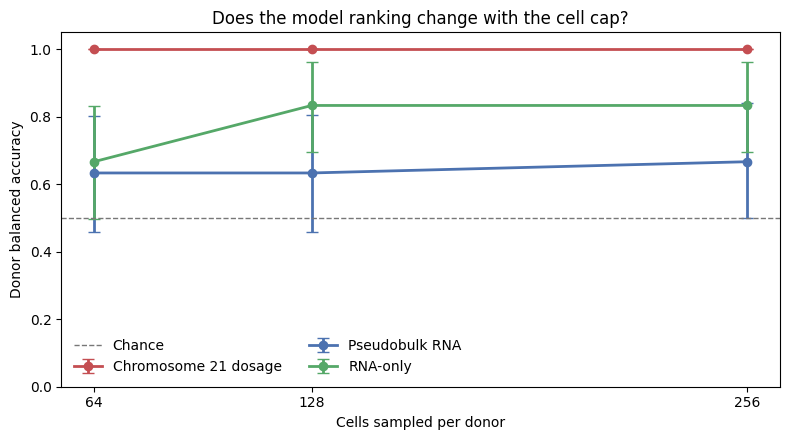

G6: PASS


In [8]:
fold0 = split_report.folds[0]
train_donors, test_donors = fold0.train_donors, fold0.test_donors
y, donors = synth_labels, np.asarray(synth.donor_ids, dtype=object)
rna, atac = synth.view_a, synth.view_b
train_idx, test_idx = fold0.train_index, fold0.test_index

baseline_rows = []
paired_deltas = []
same_cap_summary = {
    "status": "NOT_REAL_DATA",
    "conclusion": "Simulation checks implementation wiring only; no disease conclusion is drawn.",
}

if REAL_MODE_ACTIVE and mode.allow_model_fit and PROFESSOR_APPROVED and real_state.keep_mask is not None:
    print("Running real donor-held-out comparisons (this can take several minutes)...")
    print("Fair comparison caps:", sorted({PRIMARY_CAP, *SENSITIVITY_CAPS}), "cells per donor")
    print("ATAC branch:", real_state.atac_branch_label)
    run_real_model_comparison(h5ad_path, real_state, primary_cap=PRIMARY_CAP, n_features=2000)
    baseline_rows = real_state.metrics_rows
    paired_deltas = real_state.paired_deltas
    same_cap_summary = real_state.same_cap_summary
    g6_status = "PASS" if any(row.get("status") == "measured" for row in baseline_rows) else "BLOCKED"
    if real_state.split.get("donor_level_overlap", 0) != 0 or real_state.split.get("cell_level_overlap", 0) != 0:
        g6_status = "BLOCKED"
    board.set(make_gate("G6", g6_status, evidence={"metrics": baseline_rows, "paired_deltas": paired_deltas,
                                                    "atac_branch": real_state.atac_branch},
                        notes="real donor-held-out comparison; cheap baselines before gated fusion"))
    print("\nMAIN RESULT")
    print(same_cap_summary["conclusion"])
    print("Interpretation status:", same_cap_summary["status"])

    metric_frame = pd.DataFrame(baseline_rows)
    capped_frame = metric_frame[
        metric_frame["cap"].notna()
        & metric_frame["model"].isin(["chr21_dosage", "pseudobulk_rna_logistic", "rna_only"])
    ].copy()
    capped_frame["model"] = capped_frame["model"].map({
        "chr21_dosage": "Chromosome 21 dosage",
        "pseudobulk_rna_logistic": "Pseudobulk RNA",
        "rna_only": "RNA-only",
    })
    capped_columns = [
        "cap", "model", "donor_balanced_accuracy", "bootstrap_lower", "bootstrap_upper",
        "n_donors", "n_cells", "cells_per_donor_min", "cells_per_donor_median",
        "cells_per_donor_max",
    ]
    print("\nFAIR SAME-CELL RESULTS")
    from IPython.display import display
    display(capped_frame[capped_columns].sort_values(["cap", "model"]).reset_index(drop=True))
    sample_audit = (
        metric_frame[metric_frame["cap"].notna()]
        .groupby("cap", as_index=False)
        .agg(sample_row_sha256=("sample_row_sha256", "first"), unique_sample_hashes=("sample_row_sha256", "nunique"))
    )
    print("Same sampled-cell hash within each cap (unique_sample_hashes must equal 1):")
    display(sample_audit)
    if paired_deltas:
        delta_frame = pd.DataFrame(paired_deltas)
        delta_columns = [
            "cap", "model", "reference", "donor_balanced_accuracy_delta",
            "bootstrap_lower", "bootstrap_upper", "practical_margin", "comparison_result",
        ]
        print("\nPAIRED DIFFERENCES: RNA-ONLY MINUS BASELINE")
        display(delta_frame[delta_columns].sort_values(["cap", "reference"]).reset_index(drop=True))

    context_frame = metric_frame[metric_frame["cap"].isna()].copy()
    print("\nFULL-COHORT CONTEXT (NOT PART OF SAME-CAP RANKING)")
    display(context_frame[["model", "layer", "status", "donor_balanced_accuracy", "bootstrap_lower", "bootstrap_upper", "not_applicable"]].reset_index(drop=True))

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 4.5))
    colors = {"Chromosome 21 dosage": "#C44E52", "Pseudobulk RNA": "#4C72B0", "RNA-only": "#55A868"}
    for model_name, model_rows in capped_frame.groupby("model", sort=False):
        ordered = model_rows.sort_values("cap")
        scores = ordered["donor_balanced_accuracy"].astype(float).to_numpy()
        lower = ordered["bootstrap_lower"].astype(float).to_numpy()
        upper = ordered["bootstrap_upper"].astype(float).to_numpy()
        ax.errorbar(
            ordered["cap"], scores, yerr=[scores - lower, upper - scores], marker="o",
            linewidth=2, capsize=4, color=colors[model_name], label=model_name,
        )
    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1, label="Chance")
    ax.set(xlabel="Cells sampled per donor", ylabel="Donor balanced accuracy", ylim=(0, 1.05),
           title="Does the model ranking change with the cell cap?")
    ax.set_xticks(sorted(capped_frame["cap"].astype(int).unique()))
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()
    plt.show()
    for key, values in real_state.evidence_buckets.items():
        for item in values:
            if item not in EVIDENCE_BUCKETS[key]:
                EVIDENCE_BUCKETS[key].append(item)
    print("G6:", g6_status)
else:
    results = [
        majority_class_baseline(y, donors),
        chr21_dosage_baseline(None, y, donors, train_donors, test_donors),
        covariate_logistic_baseline(None, y, donors, train_donors, test_donors),
        pseudobulk_rna_logistic(rna, y, donors, train_donors, test_donors, n_features=16),
    ]

    def donor_bal_acc(matrix, name):
        scaler = StandardScaler()
        x_train = scaler.fit_transform(matrix[train_idx])
        x_test = scaler.transform(matrix[test_idx])
        model = LogisticRegression(max_iter=400, class_weight="balanced", random_state=MODEL_INIT_SEED)
        model.fit(x_train, y[train_idx])
        proba = model.predict_proba(x_test)[:, 1]
        agg = aggregate_donor_probabilities(proba, donors[test_idx], threshold=0.5)
        truth = (pd.DataFrame({"donor_id": donors[test_idx], "label": y[test_idx]})
                 .groupby("donor_id")["label"].agg(lambda s: int(s.mode().iloc[0])))
        merged = agg.merge(truth.rename("label"), on="donor_id")
        score = float(balanced_accuracy_score(merged["label"], merged["prediction"]))
        return BaselineResult(name=name, status="measured", donor_balanced_accuracy=score,
                              n_donors=int(merged.shape[0]), n_cells=int(test_idx.size),
                              detail={"layer": "synthetic_wiring", "cap_note": "not disease evidence"})

    results.append(donor_bal_acc(rna, "rna_only"))
    if atac_branch.multimodal_claim_allowed:
        results.append(donor_bal_acc(atac, "atac_only"))
        results.append(donor_bal_acc(np.hstack([rna, atac]), "rna_atac_concat"))
        results.append(blocked_baseline("gated_fusion", "gated fusion blocked without approved real model run"))
    else:
        reason = f"ATAC branch {atac_branch.branch}; multimodal claim not allowed"
        results.extend([
            not_applicable_baseline("atac_only", reason),
            not_applicable_baseline("rna_atac_concat", reason),
            not_applicable_baseline("gated_fusion", reason),
        ])
    baseline_rows = baseline_table(results)
    g6_status = "PASS" if mode.mode == MODE_SIMULATION else "BLOCKED"
    board.set(make_gate("G6", g6_status, evidence={"baselines": baseline_rows, "atac_branch": atac_branch.branch},
                        unknowns=("real-data baselines not run",) if REAL_MODE_ACTIVE else (),
                        notes="synthetic baseline wiring; not disease evidence"))
    print(pd.DataFrame(baseline_rows)[["name", "status", "donor_balanced_accuracy", "not_applicable"]].to_string(index=False))
    print("G6:", g6_status)
    EVIDENCE_BUCKETS["synthetic"].append("G6 named baseline wiring")


## G7 — Routing faithfulness (held-out only)

Real B2b path: RNA ablations/clamps/permutations. ATAC/gate interventions marked NOT_APPLICABLE. Gate values are routing signals, not explanations.


In [9]:
intervention_rows = []

if REAL_MODE_ACTIVE and mode.allow_model_fit and PROFESSOR_APPROVED and real_state.keep_mask is not None:
    run_real_interventions(h5ad_path, real_state, primary_cap=PRIMARY_CAP, n_features=64)
    intervention_rows = real_state.intervention_rows
    g7_status = "PASS" if any(row.get("status") == "measured" for row in intervention_rows) else "INCONCLUSIVE"
    board.set(make_gate("G7", g7_status, evidence={"interventions": intervention_rows},
                        notes="RNA-only held-out interventions; multimodal routing NA under B2b"))
    print(pd.DataFrame(intervention_rows).to_string(index=False)[:2000])
    for key, values in real_state.evidence_buckets.items():
        for item in values:
            if item not in EVIDENCE_BUCKETS[key]:
                EVIDENCE_BUCKETS[key].append(item)
    print("G7:", g7_status)
else:
    n_features = 16
    rna_scaler = StandardScaler().fit(rna[train_idx][:, :n_features])
    atac_scaler = StandardScaler().fit(atac[train_idx][:, :n_features])
    train_rna = rna_scaler.transform(rna[train_idx][:, :n_features])
    test_rna = rna_scaler.transform(rna[test_idx][:, :n_features])
    train_atac = atac_scaler.transform(atac[train_idx][:, :n_features])
    test_atac = atac_scaler.transform(atac[test_idx][:, :n_features])
    torch.manual_seed(MODEL_INIT_SEED)
    gated = GatedFusionModel(n_features_a=n_features, n_features_b=n_features, n_classes=2, embed_dim=16, hidden_dim=32)
    opt = torch.optim.Adam(gated.parameters(), lr=1e-2)
    xa = torch.tensor(train_rna, dtype=torch.float32)
    xb = torch.tensor(train_atac, dtype=torch.float32)
    yt = torch.tensor(y[train_idx], dtype=torch.int64)
    for _ in range(20):
        opt.zero_grad()
        out = gated(xa, xb)
        torch.nn.functional.cross_entropy(out.logits, yt).backward()
        opt.step()
    effects = run_all_interventions(
        gated,
        views={"view_a": test_rna, "view_b": test_atac},
        labels=y[test_idx],
        donor_ids=donors[test_idx],
        train_views={"view_a": train_rna, "view_b": train_atac},
        metric_name="balanced_accuracy",
        seed=SEED,
    )
    intervention_rows = intervention_table(effects)
    g7_status = "PASS" if mode.mode == MODE_SIMULATION else "BLOCKED"
    board.set(make_gate("G7", g7_status, evidence={"interventions": intervention_rows},
                        notes="synthetic intervention plumbing; routing signals only"))
    print(pd.DataFrame(intervention_rows).to_string(index=False))
    print("G7:", g7_status, "n_interventions=", len(INTERVENTIONS))
    EVIDENCE_BUCKETS["synthetic"].append("G7 routing interventions")


             intervention target         status  cell_flip_rate  donor_prediction_agreement  donor_balanced_accuracy_before  donor_balanced_accuracy_after  donor_balanced_accuracy_drop  n_cells  n_donors                                                 not_applicable                                                                                                                                                     evidence
 permute_rna_within_donor    rna       measured        0.436198                    1.000000                             0.5                            0.5                           0.0   1536.0       6.0                                                           None held-out intervention evidence under the stated manipulation on real cells; a routing signal is not an explanation and this is not a causal biological claim
  clamp_rna_to_train_mean    rna       measured        0.418620                    0.666667                             0.5                            0

## G8 / R5 — External validation + donor-limited scale

Frozen marker panels tested on held-out donors (internal evidence). GSE280175 is RNA-only validation candidate; matrix not auto-ingested. Independent multimodal validation remains UNKNOWN.


In [10]:
if REAL_MODE_ACTIVE and mode.allow_model_fit and PROFESSOR_APPROVED and real_state.keep_mask is not None:
    run_real_validation(h5ad_path, real_state)
    validation = type("V", (), {
        "status": real_state.validation.get("status"),
        "to_dict": lambda self=None: real_state.validation,
        "open_questions": tuple(real_state.validation.get("open_questions") or ()),
        "claim_boundary": real_state.validation.get("claim_boundary"),
        "resources": [],
    })()
    validation_rows = real_state.validation_rows
    for key, values in real_state.evidence_buckets.items():
        for item in values:
            if item not in EVIDENCE_BUCKETS[key]:
                EVIDENCE_BUCKETS[key].append(item)
else:
    validation = build_validation_report(
        marker_set=CHR21_DOSAGE_PANEL_NAME,
        findings_available=False,
        approval_present=PROFESSOR_APPROVED,
    )
    validation_rows = [item.to_dict() | {"gate_status": validation.status} for item in validation.resources]

board.set(make_gate("G8", validation.status if hasattr(validation, "status") else real_state.validation.get("status"),
                    evidence=validation.to_dict() if hasattr(validation, "to_dict") else real_state.validation,
                    unknowns=getattr(validation, "open_questions", tuple(real_state.validation.get("open_questions") or ())),
                    notes=getattr(validation, "claim_boundary", "bounded validation claims")))
scale_board.set(make_scale(
    "R5",
    "INCONCLUSIVE",
    evidence={
        "cell_level_scale": EXPECTED_CELLS,
        "inferential_scale_donors": EXPECTED_DONORS,
        "statement_cells": f"Real full cohort target contains {EXPECTED_CELLS} cells and {EXPECTED_DONORS} donors.",
        "statement_donors": "Inferential uncertainty is donor-limited; donor resampling and external cohort evidence required.",
        "off_ramps": getattr(adequacy, "off_ramp_options", {}),
        "validation": validation.to_dict() if hasattr(validation, "to_dict") else real_state.validation,
        "panels": getattr(real_state, "panel_rows", []),
    },
    notes="30 donors moderate; do not inflate via cell count",
))
print("G8:", getattr(validation, "status", real_state.validation.get("status")))
if REAL_MODE_ACTIVE and real_state.panel_rows:
    print(pd.DataFrame(real_state.panel_rows).to_string(index=False)[:1500])
else:
    EVIDENCE_BUCKETS["blocked_or_unknown"].append("G8 external validation not run in this mode")


G8: INCONCLUSIVE
                                          panel         expectation   status  n_genes_requested  n_genes_found  n_donors  median_log2_fold_change  n_genes_up_in_ds  fraction_up_in_ds  panel_p_value genes_missing  not_applicable                                    evidence_scope accession listed matrix_ingested                                                                                    reason
       HSA21 dosage-sensitive cortical panel v1    up_in_trisomy_21 measured               20.0           20.0       6.0                 0.676256              16.0               0.80       0.000210            []             NaN internal held-out donors; not external validation       NaN    NaN             NaN                                                                                       NaN
off-chromosome-21 housekeeping control panel v1 no_systematic_shift measured                8.0            8.0       6.0                -0.455981               2.0               0.2

,analysis,discovery_population,primary_labels,external_population,external_accession,external_sha256,expected_external_sha256,evidence_scope,execution_status,scientific_outcome,...,agreement_ci_low,agreement_ci_high,agreement_permutation_p_upper,agreement_permutation_p_lower,agreement_null_mean,bootstrap_shared_genes_min,bootstrap_shared_genes_max,reason,primary_cells,donor_ids
0,external_rna_direction_replication,RG,RG,oRG,GSE280175,ea0e5a0d96e122ce39ace8be29b65039c3f7775cc96699...,ea0e5a0d96e122ce39ace8be29b65039c3f7775cc96699...,published cell-level MAST summary effects (don...,completed,inconclusive,...,0.35,0.68,0.014985,0.990010,0.46858,8989,9051,completed frozen summary-effect direction comp...,16855,"[PCW13_CON_11928, PCW13_CON_15044, PCW13_DS_12..."
1,external_rna_direction_replication,RG,RG,vRG,GSE280175,ea0e5a0d96e122ce39ace8be29b65039c3f7775cc96699...,ea0e5a0d96e122ce39ace8be29b65039c3f7775cc96699...,published cell-level MAST summary effects (don...,completed,inconclusive,...,0.36,0.61,0.182817,0.874126,0.47884,8506,8572,completed frozen summary-effect direction comp...,16855,"[PCW13_CON_11928, PCW13_CON_15044, PCW13_DS_12..."
2,external_rna_direction_replication,cycling_progenitors,RG_prol|IPC_prol,CP,GSE280175,ea0e5a0d96e122ce39ace8be29b65039c3f7775cc96699...,ea0e5a0d96e122ce39ace8be29b65039c3f7775cc96699...,published cell-level MAST summary effects (don...,completed,inconclusive,...,0.43,0.73,0.040959,0.975025,0.49706,9044,9213,completed frozen summary-effect direction comp...,8417,"[PCW13_CON_11928, PCW13_CON_15044, PCW13_DS_12..."
3,external_rna_direction_replication,IPC,IPC,IP,GSE280175,ea0e5a0d96e122ce39ace8be29b65039c3f7775cc96699...,ea0e5a0d96e122ce39ace8be29b65039c3f7775cc96699...,published cell-level MAST summary effects (don...,completed,inconclusive,...,0.38,0.69,0.103896,0.922078,0.46728,7484,7857,completed frozen summary-effect direction comp...,10621,"[PCW13_CON_11928, PCW13_CON_15044, PCW13_DS_12..."


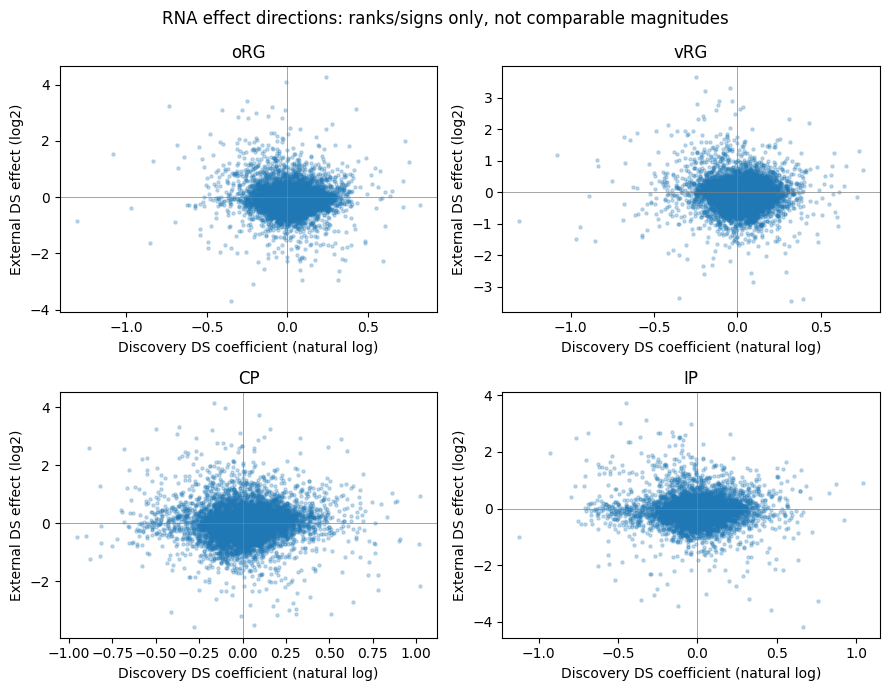

EXTERNAL RNA: completed | headline: inconclusive
Published cell-level MAST summary effects (donor covariate), not raw external reanalysis. Aggregate RNA direction only; no per-gene, classifier, ATAC, routing, multimodal, or causal claim. G8 remains INCONCLUSIVE: no external matrix ingested. Primary PCW 19 absent; nominal cell-label mappings; batch unmodelled. PCW18_DS_16545 has sub-quality tissue; PCW17_CON_14310 is thin near the cell floor. Natural-log discovery coefficients and external log2 effects compare by rank/sign, not magnitude.


In [11]:
# External RNA direction replication: summary effects, not predictive validation.
external_rna_limits = (
    "Published cell-level MAST summary effects (donor covariate), not raw external reanalysis. "
    "Aggregate RNA direction only; no per-gene, classifier, ATAC, routing, multimodal, or causal claim. "
    "G8 remains INCONCLUSIVE: no external matrix ingested. "
    "Primary PCW 19 absent; nominal cell-label mappings; batch unmodelled. "
    "PCW18_DS_16545 has sub-quality tissue; PCW17_CON_14310 is thin near the cell floor. "
    "Natural-log discovery coefficients and external log2 effects compare by rank/sign, not magnitude."
)
external_rna_result = {
    "execution_status": "blocked", "headline_outcome": None, "rows": [], "gene_tables": {},
    "reason": "Requires approved real mode, model fitting enabled, and retained-cell QC.",
}
external_rna_figure = None
if REAL_MODE_ACTIVE and mode.allow_model_fit and PROFESSOR_APPROVED and real_state.keep_mask is not None:
    import urllib.request
    external_xlsx = DATA_ROOT / "41467_2025_63752_MOESM4_ESM.xlsx"
    try:
        if not external_xlsx.exists():
            print("Downloading pinned Supplementary Data 2:", EXTERNAL_RNA_BYTES, "bytes")
            with urllib.request.urlopen(EXTERNAL_RNA_URL, timeout=60) as response:
                workbook_bytes = response.read(EXTERNAL_RNA_BYTES + 1)
            if len(workbook_bytes) != EXTERNAL_RNA_BYTES:
                raise ValueError("external workbook size mismatch")
            if hashlib.sha256(workbook_bytes).hexdigest() != EXTERNAL_RNA_SHA256:
                raise ValueError("external workbook SHA-256 mismatch")
            with external_xlsx.open("xb") as handle:
                handle.write(workbook_bytes)
            del workbook_bytes
        if external_xlsx.stat().st_size != EXTERNAL_RNA_BYTES or sha256_file(external_xlsx) != EXTERNAL_RNA_SHA256:
            raise ValueError("external workbook size or SHA-256 mismatch; cached file preserved")
        external_rna_result = run_external_rna_replication(
            h5ad_path, external_xlsx, state=real_state, approval_present=PROFESSOR_APPROVED,
        )
    except (OSError, ValueError) as exc:
        external_rna_result.update(execution_status="failed", reason=str(exc))
    if external_rna_result["execution_status"] == "completed":
        board.set(replace(
            board.get("G8"), evidence=dict(real_state.validation),
            notes="Processed Supplementary Data 2 verified and analyzed; raw external matrix not ingested. Predictive/multimodal validation remains unknown.",
        ))
    if external_rna_result["rows"]:
        from IPython.display import display
        display(pd.DataFrame(external_rna_result["rows"]))
    if external_rna_result["gene_tables"]:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(2, 2, figsize=(9, 7))
        for ax, population in zip(axes.flat, ("oRG", "vRG", "CP", "IP")):
            genes = pd.DataFrame(external_rna_result["gene_tables"].get(population, []))
            if not genes.empty:
                ax.scatter(genes["coefficient"], genes["avg_log2FC"], s=5, alpha=0.25, rasterized=True)
            ax.axhline(0, color="grey", linewidth=0.5)
            ax.axvline(0, color="grey", linewidth=0.5)
            ax.set(title=population, xlabel="Discovery DS coefficient (natural log)", ylabel="External DS effect (log2)")
        fig.suptitle("RNA effect directions: ranks/signs only, not comparable magnitudes")
        fig.tight_layout()
        external_rna_figure = OUTPUT_ROOT / "runs" / f"{mode.mode}_{SEED}" / "figures" / "external_rna_concordance.png"
        external_rna_figure.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(external_rna_figure, dpi=150)
        plt.show()
        plt.close(fig)
external_rna_record = {key: value for key, value in external_rna_result.items() if key != "gene_tables"}
external_rna_record["limitations"] = external_rna_limits
external_rna_record["figure"] = str(external_rna_figure) if external_rna_figure else None
print("EXTERNAL RNA:", external_rna_result["execution_status"], "| headline:", external_rna_result["headline_outcome"])
if external_rna_result.get("reason"):
    print("Reason:", external_rna_result["reason"])
print(external_rna_limits)


## G9 / R6 — Evidence package + handoff

Writes `manifest.json`, `metrics.csv`, `interventions.csv`, `validation.csv`, `figures/`, `SUMMARY.md`. Never overwrites source notebook.


In [12]:
def git_head() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"],
            cwd=PROJECT_ROOT,
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
    except Exception:
        return "unknown"

data_scale = data_scale_section(
    acquisition, census,
    primary_cap=PRIMARY_CAP,
    sensitivity_caps=SENSITIVITY_CAPS,
)
scale_board.set(make_scale("R6", "PASS", evidence=data_scale, notes="numeric data-scale section written"))

exact_command = (
    f"P22_NOTEBOOK_MODE={mode.mode} P22_RUN_REAL_DATA={int(RUN_REAL_DATA)} "
    f"P22_RUN_MODEL={int(RUN_MODEL)} P22_PROFESSOR_APPROVED={int(PROFESSOR_APPROVED)} "
    f"{sys.executable} -m jupyter nbconvert --to notebook --execute "
    f"{SOURCE_NOTEBOOK.name} --output-dir reports/generated/notebooks "
    f"--output P22_down_syndrome_all_in_one.executed.ipynb"
)

# Prefer real metrics when present
metrics_for_package = baseline_rows
interventions_for_package = intervention_rows
validation_for_package = validation_rows or [
    item.to_dict() | {"gate_status": getattr(validation, "status", None)}
    for item in getattr(validation, "resources", [])
]

package = EvidencePackage(
    run_dir=OUTPUT_ROOT / "runs" / f"{mode.mode}_{SEED}",
    manifest={
        "run_id": f"{mode.mode}_{SEED}",
        "commit": git_head(),
        "notebook_hash": notebook_hash(),
        "mode": mode.to_dict(),
        "dataset_id": DATASET_ID,
        "exact_command": exact_command,
        "flags": {"run_real_data": RUN_REAL_DATA, "run_model": RUN_MODEL, "in_colab": IN_COLAB,
                  "professor_approved_attestation": PROFESSOR_APPROVED},
        "catalog": catalog.to_dict(),
        "acquisition": acquisition.to_dict(),
        "census": census.to_dict(),
        "schema": real_state.schema or None,
        "qc": real_state.qc or None,
        "adequacy": adequacy.to_dict() if hasattr(adequacy, "to_dict") else real_state.adequacy,
        "resource": resource.to_dict() if hasattr(resource, "to_dict") else real_state.resource,
        "estimand": estimand_report.to_dict() if hasattr(estimand_report, "to_dict") else real_state.estimand,
        "split": real_state.split or split_report.to_dict(),
        "paired_deltas": paired_deltas if "paired_deltas" in dir() else [],
        "same_cap_summary": same_cap_summary if "same_cap_summary" in dir() else {},
        "external_rna_replication": external_rna_record,
        "gates": board.to_dict(),
        "data_size_stages": scale_board.to_dict(),
        "data_scale": data_scale,
        "approval_state": approvals.get("approval_state"),
        "approval_attestation": "P22_PROFESSOR_APPROVED env; date not recorded locally",
        "primary_cap": PRIMARY_CAP,
        "sensitivity_caps": list(SENSITIVITY_CAPS),
        "split_seeds_note": "split seed = base_seed + repeat; model_init_seed=0",
        "model_init_seed": MODEL_INIT_SEED,
        "data_layer_label": real_state.data_layer_label if real_state.data_layer_label != "unknown" else (
            "full_cohort_post_qc" if real_state.qc else "simulation_or_catalog"
        ),
        "atac_branch_label": real_state.atac_branch_label if real_state.atac_branch_label != "unknown" else atac_branch.branch,
        "headline": real_state.headline,
        "metric_rows": metrics_for_package,
        "evidence_buckets": EVIDENCE_BUCKETS,
        "limitations": [
            "Default/safe run is simulation or metadata; not disease evidence.",
            "ATAC peak block absent in H5AD; B2b RNA-only unless fragment build approved.",
            "Capped cell-level models are not the full dataset.",
            "Inferential unit is donor (n≈30), not cell (n≈248998).",
            "GSE280175 is RNA-only validation, not multimodal; matrix not auto-ingested.",
            "Routing weights/gate values are signals, not explanations.",
            "No approval date invented; attestation via P22_PROFESSOR_APPROVED.",
        ],
        "decision": (
            "continue" if REAL_MODE_ACTIVE and mode.allow_model_fit else
            ("revise" if real_state.headline else "stop")
        ),
        "next_decision_owner": "researcher",
        "next_decision": (
            "review real metrics and claim boundary"
            if REAL_MODE_ACTIVE and mode.allow_model_fit
            else "set real_analysis + P22_RUN_REAL_DATA=1 + P22_RUN_MODEL=1 + P22_PROFESSOR_APPROVED=1"
        ),
        "selected_off_ramp": None,
    },
    metrics_rows=metrics_for_package,
    intervention_rows=interventions_for_package,
    validation_rows=validation_for_package,
)
board.set(make_gate("G9", "PASS", evidence={"run_dir": str(package.run_dir)}, notes="lean package path prepared"))
package.manifest["gates"] = board.to_dict()
paths = package.write()
summary_path = write_human_summary(package.run_dir, package.manifest)
safe_write_text(summary_path, summary_path.read_text(encoding="utf-8") + (
    "\n## External RNA direction replication\n\n"
    f"Execution: {external_rna_record['execution_status']}. "
    f"Headline: {external_rna_record['headline_outcome']}.\n\n"
    f"Reason: {external_rna_record.get('reason') or 'none'}.\n\n"
    f"Comparison rows recorded: {len(external_rna_record['rows'])}; see validation.csv and manifest.json.\n\n"
    + external_rna_limits + "\n"
))
# Executed notebook copy is filled by the outer nbconvert runner when present.
executed_candidate = OUTPUT_BASE.parent / "notebooks" / "P22_down_syndrome_all_in_one.executed.ipynb"
copied = copy_executed_notebook(executed_candidate, package.run_dir)

# Shareable cap-sensitivity figure from the fair same-cell rows.
figures_dir = Path(paths["figures"])
try:
    import matplotlib.pyplot as plt
    frame = pd.DataFrame(metrics_for_package)
    if not frame.empty and "donor_balanced_accuracy" in frame.columns and "cap" in frame.columns:
        measured = frame[
            (frame["status"] == "measured")
            & frame["cap"].notna()
            & frame["model"].isin(["chr21_dosage", "pseudobulk_rna_logistic", "rna_only"])
        ].copy()
        if not measured.empty:
            labels = {"chr21_dosage": "Chromosome 21 dosage", "pseudobulk_rna_logistic": "Pseudobulk RNA", "rna_only": "RNA-only"}
            colors = {"chr21_dosage": "#C44E52", "pseudobulk_rna_logistic": "#4C72B0", "rna_only": "#55A868"}
            fig, ax = plt.subplots(figsize=(8, 4.5))
            for model_name, model_rows in measured.groupby("model", sort=False):
                ordered = model_rows.sort_values("cap")
                scores = ordered["donor_balanced_accuracy"].astype(float).to_numpy()
                lower = ordered["bootstrap_lower"].astype(float).to_numpy()
                upper = ordered["bootstrap_upper"].astype(float).to_numpy()
                ax.errorbar(ordered["cap"], scores, yerr=[scores - lower, upper - scores], marker="o", linewidth=2, capsize=4, color=colors[model_name], label=labels[model_name])
            ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1, label="Chance")
            ax.set(xlabel="Cells sampled per donor", ylabel="Donor balanced accuracy", ylim=(0, 1.05), title="Does the model ranking change with the cell cap?")
            ax.set_xticks(sorted(measured["cap"].astype(int).unique()))
            ax.legend(frameon=False, ncol=2)
            fig.tight_layout()
            fig.savefig(figures_dir / "same_cap_sensitivity.png", dpi=150)
            plt.close(fig)
except Exception as exc:  # noqa: BLE001 — figure is optional
    safe_write_text(figures_dir / "figure_error.txt", str(exc))

gate_df = pd.DataFrame(board.as_rows())
scale_df = pd.DataFrame(scale_board.as_rows())
final_summary = {
    "mode": mode.mode,
    "gates": board.status_map(),
    "data_size_stages": scale_board.status_map(),
    "catalog_cells": (catalog.summary or {}).get("cell_count"),
    "catalog_donors": (catalog.summary or {}).get("donor_count"),
    "raw_cells": census.n_cells_raw,
    "post_qc_cells": (real_state.qc or {}).get("n_cells_post_qc"),
    "post_qc_donors": (real_state.qc or {}).get("n_donors_post_qc"),
    "atac_branch": getattr(atac_branch, "branch", real_state.atac_branch_label),
    "approval_attestation": PROFESSOR_APPROVED,
    "decision": package.manifest["decision"],
    "artifact_paths": {**paths, "summary": str(summary_path), "executed_copy": None if copied is None else str(copied)},
    "evidence_buckets": EVIDENCE_BUCKETS,
    "headline": real_state.headline,
    "same_cap_summary": same_cap_summary if "same_cap_summary" in dir() else {},
    "external_rna_replication": external_rna_record,
    "claim_boundary": "Separate verified-real / synthetic / metadata-only / blocked.",
}
safe_write_text(OUTPUT_ROOT / "notebook_summary.json", json.dumps(final_summary, indent=2) + "\n")
safe_write_text(OUTPUT_ROOT / "gate_board.json", json.dumps(board.to_dict(), indent=2) + "\n")
safe_write_text(OUTPUT_ROOT / "scale_board.json", json.dumps(scale_board.to_dict(), indent=2) + "\n")
print("=== G0-G9 ===")
print(gate_df.to_string(index=False))
print("=== R1-R6 ===")
print(scale_df.to_string(index=False))
print(json.dumps(final_summary, indent=2))
assert board.get("G0") is not None and board.get("G9").status == "PASS"
assert len(scale_board.status_map()) == 6


=== G0-G9 ===
gate                                                             question       status next_owner                                                                                                                                     notes
  G0                Can researcher run notebook locally and save outputs?         PASS researcher                                                            outputs under reports/generated or /content/p22_output; never overwrite source
  G1                            Are we using the intended public dataset? INCONCLUSIVE researcher                                                                                                   same-nucleus pairing unknown until H5AD
  G2       Is dataset large enough at donor level, not merely cell level?         PASS researcher                                                                                     post-QC donor adequacy when H5AD loaded; else catalog
  G3          Can local machine process re